# Hybrid Machine Learning Framework for Gold Trend Forecasting

**Asset:** XAU/USD  
**Forecast horizon:** 20 trading days  
**Task:** Binary trend classification (Uptrend / Downtrend)  

This notebook contains the end-to-end research workflow used to develop and evaluate the final hybrid gold-trend forecasting model. It includes data auditing, technical indicator engineering, chronological validation, macroeconomic experiments, model selection, final untouched-test evaluation, interpretability analysis, reproducibility checks, and export of the locked model for the Streamlit research prototype.

The final selected technical hybrid combines **70% Logistic Regression** and **30% Gradient Boosting**. All model selection and threshold decisions are made using pre-test data only; the final test period remains untouched until final evaluation.

> **Research use only:** This project is an academic forecasting prototype and does not constitute financial or investment advice.


In [ ]:
# Upload the seven CSV datasets from your computer to Google Colab

from google.colab import files

uploaded = files.upload()

print("\nFiles successfully uploaded:")
for filename in uploaded.keys():
    print(f"- {filename}")

print(f"\nTotal files uploaded: {len(uploaded)}")

Saving CPIAUCSL (2).csv to CPIAUCSL (2).csv
Saving DGS10 (1).csv to DGS10 (1).csv
Saving DTWEXBGS (3).csv to DTWEXBGS (3).csv
Saving EFFR (1).csv to EFFR (1).csv
Saving PAYEMS (1).csv to PAYEMS (1).csv
Saving UNRATE (1).csv to UNRATE (1).csv
Saving xauusd_d1_clean_ohlc.csv to xauusd_d1_clean_ohlc.csv

Files successfully uploaded:
- CPIAUCSL (2).csv
- DGS10 (1).csv
- DTWEXBGS (3).csv
- EFFR (1).csv
- PAYEMS (1).csv
- UNRATE (1).csv
- xauusd_d1_clean_ohlc.csv

Total files uploaded: 7


In [ ]:
# Check the CSV files currently available in Google Colab

import glob
import os

csv_files = glob.glob("/content/*.csv")

print("CSV files found:")
for file_path in csv_files:
    print("-", os.path.basename(file_path))

print("\nTotal CSV files found:", len(csv_files))

CSV files found:
- EFFR (1).csv
- xauusd_d1_clean_ohlc.csv
- PAYEMS (1).csv
- DTWEXBGS (3).csv
- UNRATE (1).csv
- CPIAUCSL (2).csv
- DGS10 (1).csv

Total CSV files found: 7


In [ ]:
# ============================================================
# STAGE 2 — STEP 2
# Load the seven CSV datasets
# ============================================================

import pandas as pd
import glob
import os


# Find a CSV file using part of its filename
def find_file(keyword):
    csv_files = glob.glob("/content/*.csv")

    matches = [
        file_path
        for file_path in csv_files
        if keyword.lower() in os.path.basename(file_path).lower()
    ]

    if len(matches) == 0:
        raise FileNotFoundError(
            f"No CSV file containing '{keyword}' was found."
        )

    return matches[0]


# Load each dataset
gold = pd.read_csv(find_file("xauusd"))
cpi = pd.read_csv(find_file("CPIAUCSL"))
effr = pd.read_csv(find_file("EFFR"))
dgs10 = pd.read_csv(find_file("DGS10"))
dollar = pd.read_csv(find_file("DTWEXBGS"))
unrate = pd.read_csv(find_file("UNRATE"))
payems = pd.read_csv(find_file("PAYEMS"))


# Store them together for easy inspection
datasets = {
    "Gold": gold,
    "CPI": cpi,
    "EFFR": effr,
    "DGS10": dgs10,
    "Dollar Index": dollar,
    "Unemployment Rate": unrate,
    "Nonfarm Payrolls": payems
}


# Display dataset sizes and columns
for name, df in datasets.items():
    print("=" * 70)
    print(name)
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    print()

Gold
Shape: (3327, 8)
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'TickVolume', 'Volume', 'Spread']

CPI
Shape: (952, 2)
Columns: ['observation_date', 'CPIAUCSL']

EFFR
Shape: (2609, 2)
Columns: ['observation_date', 'EFFR']

DGS10
Shape: (2609, 2)
Columns: ['observation_date', 'DGS10']

Dollar Index
Shape: (2609, 2)
Columns: ['observation_date', 'DTWEXBGS']

Unemployment Rate
Shape: (940, 2)
Columns: ['observation_date', 'UNRATE']

Nonfarm Payrolls
Shape: (1048, 2)
Columns: ['observation_date', 'PAYEMS']



In [ ]:
# ============================================================
# STAGE 2 — STEP 3
# Inspect date formats and current data types
# ============================================================

for name, df in datasets.items():
    print("=" * 70)
    print(name)

    # Identify the date column
    date_column = "Date" if "Date" in df.columns else "observation_date"

    print("Date column:", date_column)
    print("First 3 date values:")
    print(df[date_column].head(3).tolist())

    print("Last 3 date values:")
    print(df[date_column].tail(3).tolist())

    print("\nData types:")
    print(df.dtypes)
    print()

Gold
Date column: Date
First 3 date values:
['2011-11-02', '2011-11-03', '2011-11-04']
Last 3 date values:
['2024-12-27', '2024-12-30', '2024-12-31']

Data types:
Date           object
Open          float64
High          float64
Low           float64
Close         float64
TickVolume      int64
Volume          int64
Spread          int64
dtype: object

CPI
Date column: observation_date
First 3 date values:
['1947-01-01', '1947-02-01', '1947-03-01']
Last 3 date values:
['2026-02-01', '2026-03-01', '2026-04-01']

Data types:
observation_date     object
CPIAUCSL            float64
dtype: object

EFFR
Date column: observation_date
First 3 date values:
['2015-01-02', '2015-01-05', '2015-01-06']
Last 3 date values:
['2024-12-30', '2024-12-31', '2025-01-01']

Data types:
observation_date     object
EFFR                float64
dtype: object

DGS10
Date column: observation_date
First 3 date values:
['2015-01-02', '2015-01-05', '2015-01-06']
Last 3 date values:
['2024-12-30', '2024-12-31', '2025-

In [ ]:
# Inspect the gold date format only

print("First 10 gold dates:")
print(gold["Date"].head(10).tolist())

print("\nLast 10 gold dates:")
print(gold["Date"].tail(10).tolist())

print("\nGold Date data type:")
print(gold["Date"].dtype)

First 10 gold dates:
['2011-11-02', '2011-11-03', '2011-11-04', '2011-11-07', '2011-11-08', '2011-11-09', '2011-11-10', '2011-11-11', '2011-11-14', '2011-11-15']

Last 10 gold dates:
['2024-12-17', '2024-12-18', '2024-12-19', '2024-12-20', '2024-12-23', '2024-12-24', '2024-12-26', '2024-12-27', '2024-12-30', '2024-12-31']

Gold Date data type:
object


In [ ]:
# ============================================================
# STAGE 2 — STEP 4
# Convert date columns to datetime and sort chronologically
# ============================================================

# Convert the gold date column
gold["Date"] = pd.to_datetime(
    gold["Date"],
    format="%Y-%m-%d",
    errors="raise"
)

# Convert the macroeconomic date columns
macro_datasets = [cpi, effr, dgs10, dollar, unrate, payems]

for df in macro_datasets:
    df["observation_date"] = pd.to_datetime(
        df["observation_date"],
        format="%Y-%m-%d",
        errors="raise"
    )

# Sort every dataset chronologically
gold = gold.sort_values("Date").reset_index(drop=True)

for df in macro_datasets:
    df.sort_values("observation_date", inplace=True)
    df.reset_index(drop=True, inplace=True)


# Verify the conversion
datasets = {
    "Gold": (gold, "Date"),
    "CPI": (cpi, "observation_date"),
    "EFFR": (effr, "observation_date"),
    "DGS10": (dgs10, "observation_date"),
    "Dollar Index": (dollar, "observation_date"),
    "Unemployment Rate": (unrate, "observation_date"),
    "Nonfarm Payrolls": (payems, "observation_date")
}

for name, (df, date_column) in datasets.items():
    print("=" * 65)
    print(name)
    print("Date type:", df[date_column].dtype)
    print("First date:", df[date_column].min())
    print("Last date:", df[date_column].max())
    print("Chronologically sorted:", df[date_column].is_monotonic_increasing)

Gold
Date type: datetime64[ns]
First date: 2011-11-02 00:00:00
Last date: 2024-12-31 00:00:00
Chronologically sorted: True
CPI
Date type: datetime64[ns]
First date: 1947-01-01 00:00:00
Last date: 2026-04-01 00:00:00
Chronologically sorted: True
EFFR
Date type: datetime64[ns]
First date: 2015-01-02 00:00:00
Last date: 2025-01-01 00:00:00
Chronologically sorted: True
DGS10
Date type: datetime64[ns]
First date: 2015-01-02 00:00:00
Last date: 2025-01-01 00:00:00
Chronologically sorted: True
Dollar Index
Date type: datetime64[ns]
First date: 2015-01-02 00:00:00
Last date: 2025-01-01 00:00:00
Chronologically sorted: True
Unemployment Rate
Date type: datetime64[ns]
First date: 1948-01-01 00:00:00
Last date: 2026-04-01 00:00:00
Chronologically sorted: True
Nonfarm Payrolls
Date type: datetime64[ns]
First date: 1939-01-01 00:00:00
Last date: 2026-04-01 00:00:00
Chronologically sorted: True


In [ ]:
# ============================================================
# STAGE 2 — STEP 5
# Gold dataset integrity checks
# ============================================================

print("GOLD DATASET INTEGRITY REPORT")
print("=" * 70)

# 1. Dataset dimensions
print("Rows:", gold.shape[0])
print("Columns:", gold.shape[1])

# 2. Duplicate dates
duplicate_dates = gold["Date"].duplicated().sum()
print("\nDuplicate dates:", duplicate_dates)

# 3. Missing values
print("\nMissing values by column:")
print(gold.isna().sum())

# 4. Data types
print("\nData types:")
print(gold.dtypes)

# 5. Invalid or non-positive prices
price_columns = ["Open", "High", "Low", "Close"]

for column in price_columns:
    invalid_count = (gold[column] <= 0).sum()
    print(f"\nNon-positive values in {column}: {invalid_count}")

# 6. Check daily OHLC relationships
invalid_high = (
    gold["High"] <
    gold[["Open", "Close", "Low"]].max(axis=1)
).sum()

invalid_low = (
    gold["Low"] >
    gold[["Open", "Close", "High"]].min(axis=1)
).sum()

print("\nRows where High is inconsistent:", invalid_high)
print("Rows where Low is inconsistent:", invalid_low)

# 7. Inspect volume information
print("\nTickVolume summary:")
print(gold["TickVolume"].describe())

print("\nVolume summary:")
print(gold["Volume"].describe())

print("\nNumber of zero TickVolume values:",
      (gold["TickVolume"] == 0).sum())

print("Number of zero Volume values:",
      (gold["Volume"] == 0).sum())

GOLD DATASET INTEGRITY REPORT
Rows: 3327
Columns: 8

Duplicate dates: 0

Missing values by column:
Date          0
Open          0
High          0
Low           0
Close         0
TickVolume    0
Volume        0
Spread        0
dtype: int64

Data types:
Date          datetime64[ns]
Open                 float64
High                 float64
Low                  float64
Close                float64
TickVolume             int64
Volume                 int64
Spread                 int64
dtype: object

Non-positive values in Open: 0

Non-positive values in High: 0

Non-positive values in Low: 0

Non-positive values in Close: 0

Rows where High is inconsistent: 0
Rows where Low is inconsistent: 0

TickVolume summary:
count      3327.000000
mean      98672.398858
std       53670.172351
min           1.000000
25%       64497.000000
50%       89710.000000
75%      116965.000000
max      655803.000000
Name: TickVolume, dtype: float64

Volume summary:
count    3327.0
mean        0.0
std         0.0


In [ ]:
# ============================================================
# STAGE 2 — STEP 6
# Inspect duplicate dates and the Spread column
# ============================================================

print("Duplicate gold dates:",
      gold["Date"].duplicated().sum())

print("\nSpread data type:")
print(gold["Spread"].dtype)

print("\nSpread summary:")
print(gold["Spread"].describe())

print("\nNumber of unique Spread values:")
print(gold["Spread"].nunique())

print("\nMost common Spread values:")
print(gold["Spread"].value_counts().head(10))

Duplicate gold dates: 0

Spread data type:
int64

Spread summary:
count    3327.000000
mean        4.932372
std         8.229418
min         0.000000
25%         0.000000
50%         0.000000
75%        15.000000
max        31.000000
Name: Spread, dtype: float64

Number of unique Spread values:
23

Most common Spread values:
Spread
0     2400
18     276
15     183
19     149
16     118
20      64
31      50
17      24
21      15
11       6
Name: count, dtype: int64


In [ ]:
# ============================================================
# STAGE 2 — STEP 7
# Create the clean working gold dataset
# ============================================================

gold_clean = gold[
    [
        "Date",
        "Open",
        "High",
        "Low",
        "Close",
        "TickVolume"
    ]
].copy()

# Confirm the resulting dataset
print("Clean gold dataset shape:", gold_clean.shape)
print("\nColumns:")
print(gold_clean.columns.tolist())

print("\nFirst 5 rows:")
display(gold_clean.head())

print("\nLast 5 rows:")
display(gold_clean.tail())

Clean gold dataset shape: (3327, 6)

Columns:
['Date', 'Open', 'High', 'Low', 'Close', 'TickVolume']

First 5 rows:


,Date,Open,High,Low,Close,TickVolume
0,2011-11-02,1719.79,1744.2,1714.30,1738.82,52311
1,2011-11-03,1736.95,1767.8,1722.60,1763.05,42013
2,2011-11-04,1764.40,1764.4,1748.75,1754.70,40379
3,2011-11-07,1753.94,1798.3,1753.01,1795.11,47625
4,2011-11-08,1793.99,1802.9,1776.90,1785.69,41195



Last 5 rows:


,Date,Open,High,Low,Close,TickVolume
3322,2024-12-24,2613.61,2621.44,2610.15,2616.53,118768
3323,2024-12-26,2620.03,2639.11,2615.08,2633.38,130112
3324,2024-12-27,2632.59,2638.18,2611.63,2621.80,146955
3325,2024-12-30,2619.93,2627.99,2596.12,2606.56,159566
3326,2024-12-31,2605.50,2627.47,2602.62,2624.53,145043


In [ ]:
# ============================================================
# STAGE 2 — STEP 8
# Create future gold-direction targets for horizons 1 to 20
# ============================================================

import pandas as pd

# Preserve the clean dataset
gold_targets = gold_clean.copy()

# Create targets for 1, 2, ..., 20 trading days
for horizon in range(1, 21):

    # Gold closing price 'horizon' trading days into the future
    future_close = gold_targets["Close"].shift(-horizon)

    # Start with missing values because the final rows do not
    # have enough future observations to construct a target
    target = pd.Series(
        pd.NA,
        index=gold_targets.index,
        dtype="Int64"
    )

    # Rows where a future closing price exists
    valid_rows = future_close.notna()

    # 1 = future closing price is higher than today's closing price
    # 0 = future closing price is equal to or lower than today's close
    target.loc[valid_rows] = (
        future_close.loc[valid_rows]
        > gold_targets.loc[valid_rows, "Close"]
    ).astype(int)

    gold_targets[f"Target_{horizon}D"] = target


# ------------------------------------------------------------
# Summarise the target distributions
# ------------------------------------------------------------

target_summary = []

for horizon in range(1, 21):

    column = f"Target_{horizon}D"
    valid_target = gold_targets[column].dropna()

    up_count = int((valid_target == 1).sum())
    down_count = int((valid_target == 0).sum())
    total = len(valid_target)

    up_percentage = (up_count / total) * 100
    down_percentage = (down_count / total) * 100

    majority_baseline = max(
        up_percentage,
        down_percentage
    )

    target_summary.append({
        "Horizon": horizon,
        "Valid rows": total,
        "Up count": up_count,
        "Down count": down_count,
        "Up %": round(up_percentage, 2),
        "Down %": round(down_percentage, 2),
        "Majority baseline %": round(majority_baseline, 2)
    })


target_summary = pd.DataFrame(target_summary)

print("TARGET DISTRIBUTION SUMMARY")
display(target_summary)

TARGET DISTRIBUTION SUMMARY


,Horizon,Valid rows,Up count,Down count,Up %,Down %,Majority baseline %
0,1,3326,1713,1613,51.50,48.50,51.50
1,2,3325,1703,1622,51.22,48.78,51.22
2,3,3324,1699,1625,51.11,48.89,51.11
3,4,3323,1728,1595,52.00,48.00,52.00
4,5,3322,1748,1574,52.62,47.38,52.62
5,6,3321,1746,1575,52.57,47.43,52.57
6,7,3320,1734,1586,52.23,47.77,52.23
7,8,3319,1757,1562,52.94,47.06,52.94
8,9,3318,1737,1581,52.35,47.65,52.35
9,10,3317,1720,1597,51.85,48.15,51.85


In [ ]:
# ============================================================
# STAGE 2 — STEP 9
# Manually verify selected future-direction targets
# ============================================================

# Select a few rows from different parts of the dataset
sample_indices = [0, 100, 500, 1000, 2000, 3000]

verification_rows = []

for index in sample_indices:

    current_date = gold_targets.loc[index, "Date"]
    current_close = gold_targets.loc[index, "Close"]

    row_result = {
        "Index": index,
        "Date": current_date,
        "Current Close": current_close
    }

    # Verify the main selected horizons
    for horizon in [1, 5, 10, 15, 20]:

        future_index = index + horizon
        future_close = gold_targets.loc[future_index, "Close"]

        expected_target = int(future_close > current_close)
        stored_target = gold_targets.loc[
            index,
            f"Target_{horizon}D"
        ]

        row_result[f"Future Close {horizon}D"] = future_close
        row_result[f"Expected {horizon}D"] = expected_target
        row_result[f"Stored {horizon}D"] = stored_target

    verification_rows.append(row_result)


verification_table = pd.DataFrame(verification_rows)

display(verification_table)

,Index,Date,Current Close,Future Close 1D,Expected 1D,Stored 1D,Future Close 5D,Expected 5D,Stored 5D,Future Close 10D,Expected 10D,Stored 10D,Future Close 15D,Expected 15D,Stored 15D,Future Close 20D,Expected 20D,Stored 20D
0,0,2011-11-02,1738.82,1763.05,1,1,1768.30,1,1,1762.24,1,1,1692.09,0,0,1749.03,1,1
1,100,2012-03-23,1661.59,1690.01,1,1,1668.03,1,1,1630.27,0,0,1658.10,0,0,1642.81,0,0
2,500,2013-10-09,1305.29,1286.93,0,0,1281.99,0,0,1332.85,1,1,1341.28,1,1,1317.67,1,1
3,1000,2015-09-15,1104.98,1119.38,1,1,1124.65,1,1,1127.27,1,1,1147.00,1,1,1168.57,1,1
4,2000,2019-07-31,1412.48,1444.43,1,1,1501.01,1,1,1516.28,1,1,1502.32,1,1,1539.00,1,1
5,3000,2023-09-26,1900.65,1874.89,0,0,1822.81,0,0,1860.07,0,0,1923.09,1,1,1970.91,1,1


In [ ]:
# ============================================================
# STAGE 2 — STEP 10
# Verify every target label across all 20 horizons
# ============================================================

verification_results = []

for horizon in range(1, 21):

    future_close = gold_targets["Close"].shift(-horizon)

    # Recalculate the expected target independently
    expected_target = (
        future_close > gold_targets["Close"]
    ).astype("Int64")

    # Final rows have no future closing price
    expected_target[future_close.isna()] = pd.NA

    stored_target = gold_targets[f"Target_{horizon}D"]

    # Compare only rows where a target should exist
    valid_rows = future_close.notna()

    mismatch_count = (
        expected_target[valid_rows]
        != stored_target[valid_rows]
    ).sum()

    verification_results.append({
        "Horizon": horizon,
        "Rows checked": int(valid_rows.sum()),
        "Mismatches": int(mismatch_count),
        "Status": "PASS" if mismatch_count == 0 else "FAIL"
    })


target_verification_summary = pd.DataFrame(verification_results)

display(target_verification_summary)

print(
    "\nOverall status:",
    "ALL TARGETS VERIFIED"
    if target_verification_summary["Mismatches"].sum() == 0
    else "TARGET ERRORS FOUND"
)

,Horizon,Rows checked,Mismatches,Status
0,1,3326,0,PASS
1,2,3325,0,PASS
2,3,3324,0,PASS
3,4,3323,0,PASS
4,5,3322,0,PASS
5,6,3321,0,PASS
6,7,3320,0,PASS
7,8,3319,0,PASS
8,9,3318,0,PASS
9,10,3317,0,PASS



Overall status: ALL TARGETS VERIFIED


In [ ]:
# ============================================================
# STAGE 3 — STEP 1
# Calculate Sadorsky-style 50-day and 200-day moving averages
# ============================================================

# Create a new working dataset containing prices and targets
gold_features = gold_targets.copy()

# Calculate simple moving averages using only current and past prices
gold_features["SMA_50"] = (
    gold_features["Close"]
    .rolling(window=50, min_periods=50)
    .mean()
)

gold_features["SMA_200"] = (
    gold_features["Close"]
    .rolling(window=200, min_periods=200)
    .mean()
)


# ------------------------------------------------------------
# Add price-relative versions
# These are useful because raw moving averages increase as
# the overall gold price level increases through time.
# ------------------------------------------------------------

gold_features["Close_to_SMA50"] = (
    gold_features["Close"] / gold_features["SMA_50"]
)

gold_features["Close_to_SMA200"] = (
    gold_features["Close"] / gold_features["SMA_200"]
)


# ------------------------------------------------------------
# Verification summary
# ------------------------------------------------------------

print("MOVING-AVERAGE FEATURE SUMMARY")
print("=" * 70)

print("\nMissing values:")
print(
    gold_features[
        [
            "SMA_50",
            "SMA_200",
            "Close_to_SMA50",
            "Close_to_SMA200"
        ]
    ].isna().sum()
)

print("\nFirst valid SMA-50 row:")
display(
    gold_features.loc[
        gold_features["SMA_50"].first_valid_index(),
        ["Date", "Close", "SMA_50", "Close_to_SMA50"]
    ]
)

print("\nFirst valid SMA-200 row:")
display(
    gold_features.loc[
        gold_features["SMA_200"].first_valid_index(),
        ["Date", "Close", "SMA_200", "Close_to_SMA200"]
    ]
)

print("\nLast 5 rows:")
display(
    gold_features[
        [
            "Date",
            "Close",
            "SMA_50",
            "SMA_200",
            "Close_to_SMA50",
            "Close_to_SMA200"
        ]
    ].tail()
)

MOVING-AVERAGE FEATURE SUMMARY

Missing values:
SMA_50              49
SMA_200            199
Close_to_SMA50      49
Close_to_SMA200    199
dtype: int64

First valid SMA-50 row:


,49
Date,2012-01-12 00:00:00
Close,1649.87
SMA_50,1679.2756
Close_to_SMA50,0.982489



First valid SMA-200 row:


,199
Date,2012-08-09 00:00:00
Close,1616.34
SMA_200,1651.58945
Close_to_SMA200,0.978657



Last 5 rows:


,Date,Close,SMA_50,SMA_200,Close_to_SMA50,Close_to_SMA200
3322,2024-12-24,2616.53,2667.5718,2476.76005,0.980866,1.056433
3323,2024-12-26,2633.38,2666.7662,2479.13940,0.987481,1.062215
3324,2024-12-27,2621.80,2665.3460,2481.31905,0.983662,1.056615
3325,2024-12-30,2606.56,2663.0398,2483.44755,0.978791,1.049573
3326,2024-12-31,2624.53,2661.1474,2485.74350,0.986240,1.055833


In [ ]:
# ============================================================
# STAGE 3 — STEP 2
# Calculate the 14-day Relative Strength Index (RSI)
# using Wilder's smoothing method
# ============================================================

rsi_period = 14

# Daily change in closing price
price_change = gold_features["Close"].diff()

# Separate upward and downward price movements
gains = price_change.clip(lower=0)
losses = -price_change.clip(upper=0)

# Wilder-style smoothed average gains and losses
average_gain = gains.ewm(
    alpha=1 / rsi_period,
    adjust=False,
    min_periods=rsi_period
).mean()

average_loss = losses.ewm(
    alpha=1 / rsi_period,
    adjust=False,
    min_periods=rsi_period
).mean()

# Relative strength
relative_strength = average_gain / average_loss

# Relative Strength Index
gold_features["RSI_14"] = 100 - (
    100 / (1 + relative_strength)
)

# Handle rare cases where average loss is zero
gold_features.loc[
    (average_loss == 0) & (average_gain > 0),
    "RSI_14"
] = 100

gold_features.loc[
    (average_loss == 0) & (average_gain == 0),
    "RSI_14"
] = 50


# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

print("RSI FEATURE SUMMARY")
print("=" * 70)

print("Missing RSI values:")
print(gold_features["RSI_14"].isna().sum())

print("\nMinimum RSI:")
print(gold_features["RSI_14"].min())

print("\nMaximum RSI:")
print(gold_features["RSI_14"].max())

print("\nValues outside the valid 0–100 range:")
invalid_rsi = (
    (gold_features["RSI_14"] < 0) |
    (gold_features["RSI_14"] > 100)
).sum()

print(invalid_rsi)

print("\nFirst valid RSI row:")
first_valid_rsi = gold_features["RSI_14"].first_valid_index()

display(
    gold_features.loc[
        first_valid_rsi,
        ["Date", "Close", "RSI_14"]
    ]
)

print("\nLast 5 RSI values:")
display(
    gold_features[
        ["Date", "Close", "RSI_14"]
    ].tail()
)

RSI FEATURE SUMMARY
Missing RSI values:
14

Minimum RSI:
15.123900336394726

Maximum RSI:
89.29931132471566

Values outside the valid 0–100 range:
0

First valid RSI row:


,14
Date,2011-11-22 00:00:00
Close,1698.95
RSI_14,61.626884



Last 5 RSI values:


,Date,Close,RSI_14
3322,2024-12-24,2616.53,45.277543
3323,2024-12-26,2633.38,48.534445
3324,2024-12-27,2621.80,46.486766
3325,2024-12-30,2606.56,43.863877
3326,2024-12-31,2624.53,47.616967


In [ ]:
# ============================================================
# STAGE 3 — STEP 3
# Calculate stochastic oscillator indicators
#
# Parameters:
# 14 periods for Fast %K
# 3 periods for Fast %D
# 3 periods for Slow %D
# ============================================================

stochastic_period = 14
fast_d_period = 3
slow_d_period = 3


# ------------------------------------------------------------
# Highest high and lowest low over the previous 14 trading days
# ------------------------------------------------------------

highest_high_14 = (
    gold_features["High"]
    .rolling(
        window=stochastic_period,
        min_periods=stochastic_period
    )
    .max()
)

lowest_low_14 = (
    gold_features["Low"]
    .rolling(
        window=stochastic_period,
        min_periods=stochastic_period
    )
    .min()
)


# ------------------------------------------------------------
# Fast %K
# ------------------------------------------------------------

price_range_14 = highest_high_14 - lowest_low_14

gold_features["Stoch_Fast_K"] = (
    100
    * (
        gold_features["Close"] - lowest_low_14
    )
    / price_range_14
)

# Prevent division-by-zero errors in rare flat-price windows
gold_features.loc[
    price_range_14 == 0,
    "Stoch_Fast_K"
] = 50


# ------------------------------------------------------------
# Fast %D: 3-period moving average of Fast %K
# ------------------------------------------------------------

gold_features["Stoch_Fast_D"] = (
    gold_features["Stoch_Fast_K"]
    .rolling(
        window=fast_d_period,
        min_periods=fast_d_period
    )
    .mean()
)


# ------------------------------------------------------------
# Slow %D: 3-period moving average of Fast %D
# ------------------------------------------------------------

gold_features["Stoch_Slow_D"] = (
    gold_features["Stoch_Fast_D"]
    .rolling(
        window=slow_d_period,
        min_periods=slow_d_period
    )
    .mean()
)


# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

stochastic_columns = [
    "Stoch_Fast_K",
    "Stoch_Fast_D",
    "Stoch_Slow_D"
]

print("STOCHASTIC OSCILLATOR SUMMARY")
print("=" * 70)

print("\nMissing values:")
print(
    gold_features[
        stochastic_columns
    ].isna().sum()
)

print("\nMinimum values:")
print(
    gold_features[
        stochastic_columns
    ].min()
)

print("\nMaximum values:")
print(
    gold_features[
        stochastic_columns
    ].max()
)

invalid_stochastic = (
    (
        gold_features[stochastic_columns] < 0
    )
    |
    (
        gold_features[stochastic_columns] > 100
    )
).sum()

print("\nValues outside the valid 0–100 range:")
print(invalid_stochastic)

print("\nFirst valid Slow %D row:")

first_valid_slow_d = (
    gold_features["Stoch_Slow_D"]
    .first_valid_index()
)

display(
    gold_features.loc[
        first_valid_slow_d,
        [
            "Date",
            "Close",
            "Stoch_Fast_K",
            "Stoch_Fast_D",
            "Stoch_Slow_D"
        ]
    ]
)

print("\nLast 5 stochastic values:")

display(
    gold_features[
        [
            "Date",
            "Close",
            "Stoch_Fast_K",
            "Stoch_Fast_D",
            "Stoch_Slow_D"
        ]
    ].tail()
)

STOCHASTIC OSCILLATOR SUMMARY

Missing values:
Stoch_Fast_K    13
Stoch_Fast_D    15
Stoch_Slow_D    17
dtype: int64

Minimum values:
Stoch_Fast_K    0.000000
Stoch_Fast_D    1.489509
Stoch_Slow_D    2.142445
dtype: float64

Maximum values:
Stoch_Fast_K    99.959188
Stoch_Fast_D    98.462606
Stoch_Slow_D    97.062907
dtype: float64

Values outside the valid 0–100 range:
Stoch_Fast_K    0
Stoch_Fast_D    0
Stoch_Slow_D    0
dtype: int64

First valid Slow %D row:


,17
Date,2011-11-25 00:00:00
Close,1679.6
Stoch_Fast_K,9.736457
Stoch_Fast_D,16.500732
Stoch_Slow_D,18.188547



Last 5 stochastic values:


,Date,Close,Stoch_Fast_K,Stoch_Fast_D,Stoch_Slow_D
3322,2024-12-24,2616.53,23.325409,24.127162,18.408248
3323,2024-12-26,2633.38,35.106978,26.488137,23.166923
3324,2024-12-27,2621.80,27.010208,28.480865,26.365388
3325,2024-12-30,2606.56,16.354356,26.157181,27.042061
3326,2024-12-31,2624.53,28.919032,24.094532,26.244193


In [ ]:
# ============================================================
# STAGE 3 — STEP 4
# Calculate percentage MACD and MACD signal line
#
# Parameters:
# Fast EMA   = 12 trading days
# Slow EMA   = 26 trading days
# Signal EMA = 9 trading days
# ============================================================

fast_period = 12
slow_period = 26
signal_period = 9


# ------------------------------------------------------------
# Calculate the fast and slow exponential moving averages
# ------------------------------------------------------------

ema_fast = (
    gold_features["Close"]
    .ewm(
        span=fast_period,
        adjust=False,
        min_periods=fast_period
    )
    .mean()
)

ema_slow = (
    gold_features["Close"]
    .ewm(
        span=slow_period,
        adjust=False,
        min_periods=slow_period
    )
    .mean()
)


# ------------------------------------------------------------
# Percentage MACD
#
# This corresponds closely to the default percentage form
# used by the R TTR package.
# ------------------------------------------------------------

gold_features["MACD"] = (
    100 * ((ema_fast / ema_slow) - 1)
)


# ------------------------------------------------------------
# MACD signal line
# ------------------------------------------------------------

gold_features["MACD_Signal"] = (
    gold_features["MACD"]
    .ewm(
        span=signal_period,
        adjust=False,
        min_periods=signal_period
    )
    .mean()
)


# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

macd_columns = [
    "MACD",
    "MACD_Signal"
]

print("MACD FEATURE SUMMARY")
print("=" * 70)

print("\nMissing values:")
print(
    gold_features[
        macd_columns
    ].isna().sum()
)

print("\nSummary statistics:")
print(
    gold_features[
        macd_columns
    ].describe()
)

print("\nFirst valid MACD row:")

first_valid_macd = (
    gold_features["MACD"]
    .first_valid_index()
)

display(
    gold_features.loc[
        first_valid_macd,
        [
            "Date",
            "Close",
            "MACD"
        ]
    ]
)

print("\nFirst valid MACD signal row:")

first_valid_signal = (
    gold_features["MACD_Signal"]
    .first_valid_index()
)

display(
    gold_features.loc[
        first_valid_signal,
        [
            "Date",
            "Close",
            "MACD",
            "MACD_Signal"
        ]
    ]
)

print("\nLast 5 MACD values:")

display(
    gold_features[
        [
            "Date",
            "Close",
            "MACD",
            "MACD_Signal"
        ]
    ].tail()
)

MACD FEATURE SUMMARY

Missing values:
MACD           25
MACD_Signal    33
dtype: int64

Summary statistics:
              MACD  MACD_Signal
count  3302.000000  3294.000000
mean      0.080249     0.081793
std       1.020043     0.958121
min      -3.662124    -3.138530
25%      -0.528724    -0.491342
50%      -0.023695    -0.027658
75%       0.742902     0.739181
max       3.921617     3.346233

First valid MACD row:


,25
Date,2011-12-07 00:00:00
Close,1742.45
MACD,-0.172001



First valid MACD signal row:


,33
Date,2011-12-19 00:00:00
Close,1594.25
MACD,-2.194501
MACD_Signal,-1.319881



Last 5 MACD values:


,Date,Close,MACD,MACD_Signal
3322,2024-12-24,2616.53,-0.406196,-0.227127
3323,2024-12-26,2633.38,-0.367624,-0.255227
3324,2024-12-27,2621.80,-0.368321,-0.277845
3325,2024-12-30,2606.56,-0.410957,-0.304468
3326,2024-12-31,2624.53,-0.385182,-0.320611


In [ ]:
# ============================================================
# STAGE 3 — STEP 5
# Calculate the one-day Price Rate of Change
#
# This follows the default TTR ROC configuration:
# n = 1
# type = "continuous"
# ============================================================

import numpy as np

gold_features["Price_Rate_Of_Change"] = np.log(
    gold_features["Close"]
    / gold_features["Close"].shift(1)
)


# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

print("PRICE RATE OF CHANGE SUMMARY")
print("=" * 70)

print("\nMissing values:")
print(
    gold_features["Price_Rate_Of_Change"]
    .isna()
    .sum()
)

print("\nInfinite values:")
print(
    np.isinf(
        gold_features["Price_Rate_Of_Change"]
    ).sum()
)

print("\nSummary statistics:")
print(
    gold_features["Price_Rate_Of_Change"]
    .describe()
)

print("\nFirst valid Rate of Change row:")

first_valid_roc = (
    gold_features["Price_Rate_Of_Change"]
    .first_valid_index()
)

display(
    gold_features.loc[
        first_valid_roc,
        [
            "Date",
            "Close",
            "Price_Rate_Of_Change"
        ]
    ]
)

print("\nLast 5 Rate of Change values:")

display(
    gold_features[
        [
            "Date",
            "Close",
            "Price_Rate_Of_Change"
        ]
    ].tail()
)

PRICE RATE OF CHANGE SUMMARY

Missing values:
1

Infinite values:
0

Summary statistics:
count    3326.000000
mean        0.000124
std         0.009349
min        -0.093549
25%        -0.004676
50%         0.000321
75%         0.004982
max         0.092186
Name: Price_Rate_Of_Change, dtype: float64

First valid Rate of Change row:


,1
Date,2011-11-03 00:00:00
Close,1763.05
Price_Rate_Of_Change,0.013839



Last 5 Rate of Change values:


,Date,Close,Price_Rate_Of_Change
3322,2024-12-24,2616.53,0.001254
3323,2024-12-26,2633.38,0.006419
3324,2024-12-27,2621.80,-0.004407
3325,2024-12-30,2606.56,-0.005830
3326,2024-12-31,2624.53,0.006870


In [ ]:
# ============================================================
# STAGE 3 — STEP 6
# Calculate On-Balance Volume using TickVolume
#
# TickVolume is being used as a proxy because the ordinary
# Volume column in the XAU/USD dataset contains only zeros.
# ============================================================

import numpy as np
import pandas as pd

# Change in closing price
close_change = gold_features["Close"].diff()

# Signed daily tick volume:
# Positive when price rises
# Negative when price falls
# Zero when price is unchanged
signed_tick_volume = np.where(
    close_change > 0,
    gold_features["TickVolume"],
    np.where(
        close_change < 0,
        -gold_features["TickVolume"],
        0
    )
)

# Match the TTR starting convention:
# The first OBV value equals the first period's volume
signed_tick_volume[0] = gold_features.loc[0, "TickVolume"]

# Cumulative On-Balance Volume
gold_features["OBV_Tick"] = pd.Series(
    signed_tick_volume,
    index=gold_features.index
).cumsum()


# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

print("ON-BALANCE VOLUME SUMMARY")
print("=" * 70)

print("\nMissing values:")
print(gold_features["OBV_Tick"].isna().sum())

print("\nFirst OBV equals first TickVolume:")
print(
    gold_features.loc[0, "OBV_Tick"]
    == gold_features.loc[0, "TickVolume"]
)

print("\nFirst TickVolume:")
print(gold_features.loc[0, "TickVolume"])

print("\nFirst OBV:")
print(gold_features.loc[0, "OBV_Tick"])

print("\nSummary statistics:")
print(gold_features["OBV_Tick"].describe())

print("\nFirst 10 OBV values:")
display(
    gold_features[
        [
            "Date",
            "Close",
            "TickVolume",
            "OBV_Tick"
        ]
    ].head(10)
)

print("\nLast 5 OBV values:")
display(
    gold_features[
        [
            "Date",
            "Close",
            "TickVolume",
            "OBV_Tick"
        ]
    ].tail()
)

ON-BALANCE VOLUME SUMMARY

Missing values:
0

First OBV equals first TickVolume:
True

First TickVolume:
52311

First OBV:
52311

Summary statistics:
count    3.327000e+03
mean     2.679268e+06
std      3.980385e+06
min     -2.845340e+06
25%     -4.444130e+05
50%      2.567120e+05
75%      7.164706e+06
max      1.099633e+07
Name: OBV_Tick, dtype: float64

First 10 OBV values:


,Date,Close,TickVolume,OBV_Tick
0,2011-11-02,1738.82,52311,52311
1,2011-11-03,1763.05,42013,94324
2,2011-11-04,1754.70,40379,53945
3,2011-11-07,1795.11,47625,101570
4,2011-11-08,1785.69,41195,60375
5,2011-11-09,1768.30,51194,9181
6,2011-11-10,1757.83,62600,-53419
7,2011-11-11,1788.05,54430,1011
8,2011-11-14,1780.03,56378,-55367
9,2011-11-15,1780.90,47725,-7642



Last 5 OBV values:


,Date,Close,TickVolume,OBV_Tick
3322,2024-12-24,2616.53,118768,10733088
3323,2024-12-26,2633.38,130112,10863200
3324,2024-12-27,2621.80,146955,10716245
3325,2024-12-30,2606.56,159566,10556679
3326,2024-12-31,2624.53,145043,10701722


In [ ]:
# ============================================================
# STAGE 3 — STEP 7
# Calculate the 14-day Money Flow Index using TickVolume
# ============================================================

import numpy as np
import pandas as pd

mfi_period = 14


# ------------------------------------------------------------
# 1. Typical price
# ------------------------------------------------------------

typical_price = (
    gold_features["High"]
    + gold_features["Low"]
    + gold_features["Close"]
) / 3


# ------------------------------------------------------------
# 2. Raw money flow
# ------------------------------------------------------------

raw_money_flow = (
    typical_price
    * gold_features["TickVolume"]
)


# ------------------------------------------------------------
# 3. Determine positive and negative money flow
# ------------------------------------------------------------

typical_price_change = typical_price.diff()

positive_money_flow = pd.Series(
    np.where(
        typical_price_change > 0,
        raw_money_flow,
        np.where(
            typical_price_change < 0,
            0,
            np.nan
        )
    ),
    index=gold_features.index
)

negative_money_flow = pd.Series(
    np.where(
        typical_price_change < 0,
        raw_money_flow,
        np.where(
            typical_price_change > 0,
            0,
            np.nan
        )
    ),
    index=gold_features.index
)


# ------------------------------------------------------------
# 4. Rolling 14-day positive and negative money-flow sums
# ------------------------------------------------------------

positive_flow_sum = positive_money_flow.rolling(
    window=mfi_period,
    min_periods=mfi_period
).sum()

negative_flow_sum = negative_money_flow.rolling(
    window=mfi_period,
    min_periods=mfi_period
).sum()


# ------------------------------------------------------------
# 5. Money Flow Index
# ------------------------------------------------------------

money_flow_ratio = (
    positive_flow_sum
    / negative_flow_sum
)

gold_features["MFI_14_Tick"] = (
    100
    - (
        100
        / (1 + money_flow_ratio)
    )
)


# Handle rare zero-flow cases
gold_features.loc[
    (negative_flow_sum == 0)
    & (positive_flow_sum > 0),
    "MFI_14_Tick"
] = 100

gold_features.loc[
    (negative_flow_sum == 0)
    & (positive_flow_sum == 0),
    "MFI_14_Tick"
] = 50


# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

print("MONEY FLOW INDEX SUMMARY")
print("=" * 70)

print("\nMissing values:")
print(
    gold_features["MFI_14_Tick"]
    .isna()
    .sum()
)

print("\nMinimum MFI:")
print(
    gold_features["MFI_14_Tick"]
    .min()
)

print("\nMaximum MFI:")
print(
    gold_features["MFI_14_Tick"]
    .max()
)

invalid_mfi = (
    (gold_features["MFI_14_Tick"] < 0)
    |
    (gold_features["MFI_14_Tick"] > 100)
).sum()

print("\nValues outside the valid 0–100 range:")
print(invalid_mfi)

print("\nFirst valid MFI row:")

first_valid_mfi = (
    gold_features["MFI_14_Tick"]
    .first_valid_index()
)

display(
    gold_features.loc[
        first_valid_mfi,
        [
            "Date",
            "High",
            "Low",
            "Close",
            "TickVolume",
            "MFI_14_Tick"
        ]
    ]
)

print("\nLast 5 MFI values:")

display(
    gold_features[
        [
            "Date",
            "Close",
            "TickVolume",
            "MFI_14_Tick"
        ]
    ].tail()
)

MONEY FLOW INDEX SUMMARY

Missing values:
14

Minimum MFI:
6.695539547228407

Maximum MFI:
94.29278084447226

Values outside the valid 0–100 range:
0

First valid MFI row:


,14
Date,2011-11-22 00:00:00
High,1705.47
Low,1667.45
Close,1698.95
TickVolume,63913
MFI_14_Tick,45.958218



Last 5 MFI values:


,Date,Close,TickVolume,MFI_14_Tick
3322,2024-12-24,2616.53,118768,36.079301
3323,2024-12-26,2633.38,130112,41.544748
3324,2024-12-27,2621.80,146955,42.170055
3325,2024-12-30,2606.56,159566,35.114891
3326,2024-12-31,2624.53,145043,34.207834


In [ ]:
# ============================================================
# STAGE 3 — STEP 8
# Calculate Williams Accumulation/Distribution
#
# This follows the TTR williamsAD calculation.
# It uses High, Low and Close prices, but no volume.
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Previous trading day's closing price
# ------------------------------------------------------------

previous_close = gold_features["Close"].shift(1)


# ------------------------------------------------------------
# 2. True High and True Low
#
# True High = greater of today's High and previous Close
# True Low  = smaller of today's Low and previous Close
# ------------------------------------------------------------

true_high = pd.concat(
    [
        gold_features["High"],
        previous_close
    ],
    axis=1
).max(axis=1)

true_low = pd.concat(
    [
        gold_features["Low"],
        previous_close
    ],
    axis=1
).min(axis=1)


# ------------------------------------------------------------
# 3. Change in closing price
# ------------------------------------------------------------

close_change = (
    gold_features["Close"]
    - previous_close
)


# ------------------------------------------------------------
# 4. Daily Williams A/D contribution
#
# Price rises:
# Close - True Low
#
# Price falls:
# Close - True High
#
# No price change:
# 0
# ------------------------------------------------------------

daily_williams_ad = pd.Series(
    np.select(
        [
            close_change > 0,
            close_change < 0,
            close_change == 0
        ],
        [
            gold_features["Close"] - true_low,
            gold_features["Close"] - true_high,
            0
        ],
        default=np.nan
    ),
    index=gold_features.index
)


# ------------------------------------------------------------
# 5. Cumulative Williams Accumulation/Distribution line
# ------------------------------------------------------------

gold_features["Williams_AD"] = (
    daily_williams_ad.cumsum()
)


# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

print("WILLIAMS ACCUMULATION/DISTRIBUTION SUMMARY")
print("=" * 70)

print("\nMissing values:")
print(
    gold_features["Williams_AD"]
    .isna()
    .sum()
)

print("\nInfinite values:")
print(
    np.isinf(
        gold_features["Williams_AD"]
    ).sum()
)

print("\nSummary statistics:")
print(
    gold_features["Williams_AD"]
    .describe()
)

print("\nFirst valid Williams A/D row:")

first_valid_wad = (
    gold_features["Williams_AD"]
    .first_valid_index()
)

display(
    gold_features.loc[
        first_valid_wad,
        [
            "Date",
            "High",
            "Low",
            "Close",
            "Williams_AD"
        ]
    ]
)

print("\nFirst 10 Williams A/D values:")

display(
    gold_features[
        [
            "Date",
            "High",
            "Low",
            "Close",
            "Williams_AD"
        ]
    ].head(10)
)

print("\nLast 5 Williams A/D values:")

display(
    gold_features[
        [
            "Date",
            "Close",
            "Williams_AD"
        ]
    ].tail()
)

WILLIAMS ACCUMULATION/DISTRIBUTION SUMMARY

Missing values:
1

Infinite values:
0

Summary statistics:
count    3326.000000
mean       13.493584
std       406.945291
min      -596.240000
25%      -345.962500
50%      -143.560000
75%       403.882500
max      1069.800000
Name: Williams_AD, dtype: float64

First valid Williams A/D row:


,1
Date,2011-11-03 00:00:00
High,1767.8
Low,1722.6
Close,1763.05
Williams_AD,40.45



First 10 Williams A/D values:


,Date,High,Low,Close,Williams_AD
0,2011-11-02,1744.2,1714.30,1738.82,NaN
1,2011-11-03,1767.8,1722.60,1763.05,40.45
2,2011-11-04,1764.4,1748.75,1754.70,30.75
3,2011-11-07,1798.3,1753.01,1795.11,72.85
4,2011-11-08,1802.9,1776.90,1785.69,55.64
5,2011-11-09,1799.6,1763.70,1768.30,24.34
6,2011-11-10,1775.3,1735.20,1757.83,6.87
7,2011-11-11,1789.1,1744.05,1788.05,50.87
8,2011-11-14,1796.1,1773.49,1780.03,34.80
9,2011-11-15,1785.7,1759.92,1780.90,55.78



Last 5 Williams A/D values:


,Date,Close,Williams_AD
3322,2024-12-24,2616.53,934.31
3323,2024-12-26,2633.38,952.61
3324,2024-12-27,2621.80,936.23
3325,2024-12-30,2606.56,914.80
3326,2024-12-31,2624.53,936.71


In [ ]:
# ============================================================
# STAGE 3 — STEP 9
# Consolidate and audit the strict Sadorsky-style feature set
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# Technical features that can be reproduced from our dataset
# ------------------------------------------------------------

sadorsky_features = [
    "RSI_14",
    "Stoch_Fast_K",
    "Stoch_Fast_D",
    "Stoch_Slow_D",
    "MACD",
    "MACD_Signal",
    "Price_Rate_Of_Change",
    "OBV_Tick",
    "SMA_50",
    "SMA_200",
    "MFI_14_Tick",
    "Williams_AD"
]


# ------------------------------------------------------------
# Check that every expected feature exists
# ------------------------------------------------------------

missing_columns = [
    column
    for column in sadorsky_features
    if column not in gold_features.columns
]

print("STRICT SADORSKY-STYLE FEATURE AUDIT")
print("=" * 70)

print("\nExpected feature count:")
print(len(sadorsky_features))

print("\nMissing feature columns:")
print(missing_columns)


# ------------------------------------------------------------
# Check missing and infinite values
# ------------------------------------------------------------

feature_audit = pd.DataFrame({
    "Feature": sadorsky_features,
    "Missing values": [
        gold_features[column].isna().sum()
        for column in sadorsky_features
    ],
    "Infinite values": [
        np.isinf(
            gold_features[column]
        ).sum()
        for column in sadorsky_features
    ],
    "Data type": [
        str(gold_features[column].dtype)
        for column in sadorsky_features
    ]
})

print("\nFeature audit table:")
display(feature_audit)


# ------------------------------------------------------------
# Determine the first row where all technical features exist
# ------------------------------------------------------------

complete_feature_rows = (
    gold_features[sadorsky_features]
    .notna()
    .all(axis=1)
)

first_complete_index = (
    complete_feature_rows[complete_feature_rows]
    .index[0]
)

print("\nFirst row with all strict features available:")
display(
    gold_features.loc[
        first_complete_index,
        ["Date", "Close"] + sadorsky_features
    ]
)

print("\nFirst complete feature date:")
print(
    gold_features.loc[
        first_complete_index,
        "Date"
    ]
)

print("\nNumber of rows with all strict features available:")
print(
    complete_feature_rows.sum()
)

print("\nUnavailable Sadorsky variable:")
print(
    "Advance–decline line: cannot be calculated from a single "
    "XAU/USD time series."
)

STRICT SADORSKY-STYLE FEATURE AUDIT

Expected feature count:
12

Missing feature columns:
[]

Feature audit table:


,Feature,Missing values,Infinite values,Data type
0,RSI_14,14,0,float64
1,Stoch_Fast_K,13,0,float64
2,Stoch_Fast_D,15,0,float64
3,Stoch_Slow_D,17,0,float64
4,MACD,25,0,float64
5,MACD_Signal,33,0,float64
6,Price_Rate_Of_Change,1,0,float64
7,OBV_Tick,0,0,int64
8,SMA_50,49,0,float64
9,SMA_200,199,0,float64



First row with all strict features available:


,199
Date,2012-08-09 00:00:00
Close,1616.34
RSI_14,57.166793
Stoch_Fast_K,80.594059
Stoch_Fast_D,75.531861
Stoch_Slow_D,72.102903
MACD,0.360111
MACD_Signal,0.253207
Price_Rate_Of_Change,0.002937
OBV_Tick,-309349



First complete feature date:
2012-08-09 00:00:00

Number of rows with all strict features available:
3128

Unavailable Sadorsky variable:
Advance–decline line: cannot be calculated from a single XAU/USD time series.


In [ ]:
# ============================================================
# STAGE 3 — STEP 10
# Create the strict Sadorsky-style technical modelling table
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# Target columns for horizons 1 through 20 trading days
# ------------------------------------------------------------

target_columns = [
    f"Target_{horizon}D"
    for horizon in range(1, 21)
]


# ------------------------------------------------------------
# Retain only rows where all strict technical features exist
#
# Date is retained for chronological splitting.
# Raw Close is not included as a model feature.
# ------------------------------------------------------------

complete_feature_mask = (
    gold_features[sadorsky_features]
    .notna()
    .all(axis=1)
)

technical_model_data = gold_features.loc[
    complete_feature_mask,
    ["Date"] + sadorsky_features + target_columns
].copy()

technical_model_data.reset_index(
    drop=True,
    inplace=True
)


# ------------------------------------------------------------
# Audit the completed modelling table
# ------------------------------------------------------------

print("STRICT TECHNICAL MODELLING TABLE")
print("=" * 70)

print("\nShape:")
print(technical_model_data.shape)

print("\nFirst date:")
print(technical_model_data["Date"].min())

print("\nLast date:")
print(technical_model_data["Date"].max())

print("\nMissing technical-feature values:")
print(
    technical_model_data[
        sadorsky_features
    ].isna().sum().sum()
)

print("\nInfinite technical-feature values:")
print(
    np.isinf(
        technical_model_data[
            sadorsky_features
        ].to_numpy(dtype=float)
    ).sum()
)


# ------------------------------------------------------------
# Check how many observations are available for each target
# ------------------------------------------------------------

target_availability = []

for horizon in range(1, 21):

    target_column = f"Target_{horizon}D"

    target_availability.append({
        "Horizon": horizon,
        "Available targets": (
            technical_model_data[target_column]
            .notna()
            .sum()
        ),
        "Missing final targets": (
            technical_model_data[target_column]
            .isna()
            .sum()
        )
    })

target_availability = pd.DataFrame(
    target_availability
)

print("\nTarget availability:")
display(target_availability)


print("\nFirst 3 modelling rows:")
display(
    technical_model_data.head(3)
)

STRICT TECHNICAL MODELLING TABLE

Shape:
(3128, 33)

First date:
2012-08-09 00:00:00

Last date:
2024-12-31 00:00:00

Missing technical-feature values:
0

Infinite technical-feature values:
0

Target availability:


,Horizon,Available targets,Missing final targets
0,1,3127,1
1,2,3126,2
2,3,3125,3
3,4,3124,4
4,5,3123,5
5,6,3122,6
6,7,3121,7
7,8,3120,8
8,9,3119,9
9,10,3118,10



First 3 modelling rows:


,Date,RSI_14,Stoch_Fast_K,Stoch_Fast_D,Stoch_Slow_D,MACD,MACD_Signal,Price_Rate_Of_Change,OBV_Tick,SMA_50,...,Target_11D,Target_12D,Target_13D,Target_14D,Target_15D,Target_16D,Target_17D,Target_18D,Target_19D,Target_20D
0,2012-08-09,57.166793,80.594059,75.531861,72.102903,0.360111,0.253207,0.002937,-309349,1597.6608,...,1,1,1,1,1,1,1,1,1,1
1,2012-08-10,58.412219,84.499086,79.489033,75.872667,0.401695,0.282905,0.002107,-265221,1597.5892,...,1,1,1,1,1,1,1,1,1,1
2,2012-08-13,53.369378,61.117717,75.403621,76.808172,0.378565,0.302037,-0.006373,-308988,1597.4148,...,1,1,1,1,1,1,1,1,1,1


In [ ]:
# ============================================================
# STAGE 4 — STEP 1
# Create the primary 20-trading-day modelling dataset
# ============================================================

primary_horizon = 20
primary_target = "Target_20D"

# Keep the date, strict technical features, and 20-day target
model_data_20d = technical_model_data[
    ["Date"] + sadorsky_features + [primary_target]
].copy()

# Remove the final 20 rows that have no future target
model_data_20d = model_data_20d.dropna(
    subset=[primary_target]
).reset_index(drop=True)

# Convert the target from nullable integer to standard integer
model_data_20d[primary_target] = (
    model_data_20d[primary_target]
    .astype(int)
)


# ------------------------------------------------------------
# Audit the resulting dataset
# ------------------------------------------------------------

print("20-DAY MODELLING DATASET")
print("=" * 70)

print("\nShape:")
print(model_data_20d.shape)

print("\nDate range:")
print(
    model_data_20d["Date"].min(),
    "to",
    model_data_20d["Date"].max()
)

print("\nMissing values:")
print(model_data_20d.isna().sum().sum())

print("\nTarget data type:")
print(model_data_20d[primary_target].dtype)


# ------------------------------------------------------------
# Target distribution
# ------------------------------------------------------------

target_counts_20d = (
    model_data_20d[primary_target]
    .value_counts()
    .sort_index()
)

target_percentages_20d = (
    model_data_20d[primary_target]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

distribution_20d = pd.DataFrame({
    "Class": ["Down or unchanged", "Up"],
    "Count": [
        target_counts_20d.get(0, 0),
        target_counts_20d.get(1, 0)
    ],
    "Percentage": [
        target_percentages_20d.get(0, 0),
        target_percentages_20d.get(1, 0)
    ]
})

print("\n20-day target distribution:")
display(distribution_20d)

majority_baseline_20d = (
    target_percentages_20d.max()
)

print(
    "\nMajority-class baseline accuracy:",
    round(majority_baseline_20d, 2),
    "%"
)

print("\nFirst 3 rows:")
display(model_data_20d.head(3))

print("\nLast 3 rows:")
display(model_data_20d.tail(3))

20-DAY MODELLING DATASET

Shape:
(3108, 14)

Date range:
2012-08-09 00:00:00 to 2024-12-02 00:00:00

Missing values:
0

Target data type:
int64

20-day target distribution:


,Class,Count,Percentage
0,Down or unchanged,1518,48.841699
1,Up,1590,51.158301



Majority-class baseline accuracy: 51.16 %

First 3 rows:


,Date,RSI_14,Stoch_Fast_K,Stoch_Fast_D,Stoch_Slow_D,MACD,MACD_Signal,Price_Rate_Of_Change,OBV_Tick,SMA_50,SMA_200,MFI_14_Tick,Williams_AD,Target_20D
0,2012-08-09,57.166793,80.594059,75.531861,72.102903,0.360111,0.253207,0.002937,-309349,1597.6608,1651.58945,56.538564,-40.70,1
1,2012-08-10,58.412219,84.499086,79.489033,75.872667,0.401695,0.282905,0.002107,-265221,1597.5892,1650.99410,62.384914,-26.43,1
2,2012-08-13,53.369378,61.117717,75.403621,76.808172,0.378565,0.302037,-0.006373,-308988,1597.4148,1650.22615,55.822016,-42.42,1



Last 3 rows:


,Date,RSI_14,Stoch_Fast_K,Stoch_Fast_D,Stoch_Slow_D,MACD,MACD_Signal,Price_Rate_Of_Change,OBV_Tick,SMA_50,SMA_200,MFI_14_Tick,Williams_AD,Target_20D
3105,2024-11-28,47.651375,54.727716,53.452542,53.911570,-0.350905,-0.345334,0.000842,10067013,2668.6216,2428.88000,48.409452,926.97,0
3106,2024-11-29,49.622742,61.549716,56.600741,53.048844,-0.304239,-0.337115,0.004762,10235920,2669.1824,2432.00845,55.189709,943.31,0
3107,2024-12-02,47.866531,55.377946,57.218459,55.757247,-0.298559,-0.329404,-0.004307,10020258,2669.3952,2435.02550,54.903479,928.72,0


In [ ]:
# ============================================================
# STAGE 4 — STEP 2
# Create chronological train, validation and test partitions
# with a 20-trading-day purge gap
# ============================================================

primary_horizon = 20
purge_gap = primary_horizon

total_rows = len(model_data_20d)

# Initial chronological boundaries:
# 70% training
# 15% validation
# 15% testing
train_boundary = int(total_rows * 0.70)
validation_boundary = int(total_rows * 0.85)


# ------------------------------------------------------------
# Apply a 20-row purge before validation and testing
#
# Purged rows are deliberately excluded so that future
# 20-day target windows cannot cross partition boundaries.
# ------------------------------------------------------------

train_data = model_data_20d.iloc[
    : train_boundary - purge_gap
].copy()

validation_data = model_data_20d.iloc[
    train_boundary : validation_boundary - purge_gap
].copy()

test_data = model_data_20d.iloc[
    validation_boundary :
].copy()


# Reset indices within each partition
train_data.reset_index(drop=True, inplace=True)
validation_data.reset_index(drop=True, inplace=True)
test_data.reset_index(drop=True, inplace=True)


# ------------------------------------------------------------
# Display the partition summary
# ------------------------------------------------------------

split_summary = pd.DataFrame({
    "Partition": [
        "Training",
        "Validation",
        "Test"
    ],
    "Rows": [
        len(train_data),
        len(validation_data),
        len(test_data)
    ],
    "Start date": [
        train_data["Date"].min(),
        validation_data["Date"].min(),
        test_data["Date"].min()
    ],
    "End date": [
        train_data["Date"].max(),
        validation_data["Date"].max(),
        test_data["Date"].max()
    ],
    "Up percentage": [
        train_data[primary_target].mean() * 100,
        validation_data[primary_target].mean() * 100,
        test_data[primary_target].mean() * 100
    ]
})

print("CHRONOLOGICAL SPLIT SUMMARY")
print("=" * 75)

display(split_summary)

print("\nPurged rows before validation:")
print(purge_gap)

print("\nPurged rows before test:")
print(purge_gap)

print("\nTotal modelling rows:")
print(total_rows)

print("\nRows used in the three partitions:")
print(
    len(train_data)
    + len(validation_data)
    + len(test_data)
)

print("\nRows deliberately excluded by purging:")
print(
    total_rows
    - (
        len(train_data)
        + len(validation_data)
        + len(test_data)
    )
)

CHRONOLOGICAL SPLIT SUMMARY


,Partition,Rows,Start date,End date,Up percentage
0,Training,2155,2012-08-09,2021-03-25,47.517401
1,Validation,446,2021-04-26,2023-01-13,54.035874
2,Test,467,2023-02-13,2024-12-02,65.096360



Purged rows before validation:
20

Purged rows before test:
20

Total modelling rows:
3108

Rows used in the three partitions:
3068

Rows deliberately excluded by purging:
40


In [ ]:
# ============================================================
# STAGE 4 — STEP 3
# Audit class distributions and naive baselines
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

partition_baselines = []

partitions = {
    "Training": train_data,
    "Validation": validation_data,
    "Test": test_data
}

for partition_name, partition_df in partitions.items():

    y_true = partition_df[primary_target].to_numpy()

    number_down = int((y_true == 0).sum())
    number_up = int((y_true == 1).sum())

    down_percentage = number_down / len(y_true) * 100
    up_percentage = number_up / len(y_true) * 100

    # Majority class is determined independently for each partition
    majority_class = int(number_up >= number_down)

    # Predict the majority class for every observation
    majority_predictions = [majority_class] * len(y_true)

    partition_baselines.append({
        "Partition": partition_name,
        "Rows": len(y_true),
        "Down count": number_down,
        "Up count": number_up,
        "Down %": round(down_percentage, 2),
        "Up %": round(up_percentage, 2),
        "Majority class": "Up" if majority_class == 1 else "Down",
        "Majority accuracy %": round(
            accuracy_score(y_true, majority_predictions) * 100,
            2
        ),
        "Majority balanced accuracy %": round(
            balanced_accuracy_score(
                y_true,
                majority_predictions
            ) * 100,
            2
        ),
        "Majority F1 %": round(
            f1_score(
                y_true,
                majority_predictions,
                zero_division=0
            ) * 100,
            2
        ),
        "Majority precision %": round(
            precision_score(
                y_true,
                majority_predictions,
                zero_division=0
            ) * 100,
            2
        ),
        "Majority recall %": round(
            recall_score(
                y_true,
                majority_predictions,
                zero_division=0
            ) * 100,
            2
        )
    })


partition_baseline_summary = pd.DataFrame(
    partition_baselines
)

print("PARTITION CLASS AND BASELINE AUDIT")
print("=" * 80)

display(partition_baseline_summary)

PARTITION CLASS AND BASELINE AUDIT


,Partition,Rows,Down count,Up count,Down %,Up %,Majority class,Majority accuracy %,Majority balanced accuracy %,Majority F1 %,Majority precision %,Majority recall %
0,Training,2155,1131,1024,52.48,47.52,Down,52.48,50.0,0.00,0.00,0.0
1,Validation,446,205,241,45.96,54.04,Up,54.04,50.0,70.16,54.04,100.0
2,Test,467,163,304,34.90,65.10,Up,65.10,50.0,78.86,65.10,100.0


In [ ]:
# ============================================================
# STAGE 4 — STEP 4
# Prepare feature matrices and target vectors
# ============================================================

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler


# ------------------------------------------------------------
# 1. Separate dates, features and targets
# ------------------------------------------------------------

train_dates = train_data["Date"].copy()
validation_dates = validation_data["Date"].copy()
test_dates = test_data["Date"].copy()

X_train = train_data[sadorsky_features].copy()
X_validation = validation_data[sadorsky_features].copy()
X_test = test_data[sadorsky_features].copy()

y_train = train_data[primary_target].copy()
y_validation = validation_data[primary_target].copy()
y_test = test_data[primary_target].copy()


# ------------------------------------------------------------
# 2. Check for constant features in the training set
# ------------------------------------------------------------

constant_features = [
    column
    for column in sadorsky_features
    if X_train[column].nunique() <= 1
]


# ------------------------------------------------------------
# 3. Scale features for models that require scaling
#
# The scaler is fitted on training data only.
# Validation and test data use the training parameters.
# ------------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_validation_scaled = scaler.transform(X_validation)

X_test_scaled = scaler.transform(X_test)


# Convert scaled arrays back to DataFrames
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=sadorsky_features,
    index=X_train.index
)

X_validation_scaled = pd.DataFrame(
    X_validation_scaled,
    columns=sadorsky_features,
    index=X_validation.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=sadorsky_features,
    index=X_test.index
)


# ------------------------------------------------------------
# 4. Verify the prepared model inputs
# ------------------------------------------------------------

print("MODEL INPUT PREPARATION SUMMARY")
print("=" * 75)

print("\nFeature count:")
print(len(sadorsky_features))

print("\nConstant training features:")
print(constant_features)

print("\nUnscaled feature shapes:")
print("Training:  ", X_train.shape)
print("Validation:", X_validation.shape)
print("Test:      ", X_test.shape)

print("\nTarget shapes:")
print("Training:  ", y_train.shape)
print("Validation:", y_validation.shape)
print("Test:      ", y_test.shape)

print("\nMissing feature values:")
print("Training:  ", X_train.isna().sum().sum())
print("Validation:", X_validation.isna().sum().sum())
print("Test:      ", X_test.isna().sum().sum())

print("\nInfinite feature values:")
print(
    "Training:  ",
    np.isinf(X_train.to_numpy(dtype=float)).sum()
)
print(
    "Validation:",
    np.isinf(X_validation.to_numpy(dtype=float)).sum()
)
print(
    "Test:      ",
    np.isinf(X_test.to_numpy(dtype=float)).sum()
)

print("\nScaled training means:")
print(
    X_train_scaled.mean()
    .round(6)
)

print("\nScaled training standard deviations:")
print(
    X_train_scaled.std(ddof=0)
    .round(6)
)

MODEL INPUT PREPARATION SUMMARY

Feature count:
12

Constant training features:
[]

Unscaled feature shapes:
Training:   (2155, 12)
Validation: (446, 12)
Test:       (467, 12)

Target shapes:
Training:   (2155,)
Validation: (446,)
Test:       (467,)

Missing feature values:
Training:   0
Validation: 0
Test:       0

Infinite feature values:
Training:   0
Validation: 0
Test:       0

Scaled training means:
RSI_14                 -0.0
Stoch_Fast_K           -0.0
Stoch_Fast_D            0.0
Stoch_Slow_D           -0.0
MACD                   -0.0
MACD_Signal             0.0
Price_Rate_Of_Change   -0.0
OBV_Tick                0.0
SMA_50                  0.0
SMA_200                 0.0
MFI_14_Tick            -0.0
Williams_AD            -0.0
dtype: float64

Scaled training standard deviations:
RSI_14                  1.0
Stoch_Fast_K            1.0
Stoch_Fast_D            1.0
Stoch_Slow_D            1.0
MACD                    1.0
MACD_Signal             1.0
Price_Rate_Of_Change    1.0
OBV_Ti

In [ ]:
# ============================================================
# STAGE 4 — STEP 5
# Train and evaluate the Logistic Regression baseline
#
# Important:
# The final test set is NOT used at this stage.
# ============================================================

import pandas as pd

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


# ------------------------------------------------------------
# 1. Create the baseline Logistic Regression model
# ------------------------------------------------------------

logistic_baseline = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    max_iter=5000,
    random_state=42
)


# ------------------------------------------------------------
# 2. Train using the scaled training data only
# ------------------------------------------------------------

logistic_baseline.fit(
    X_train_scaled,
    y_train
)


# ------------------------------------------------------------
# 3. Generate training and validation predictions
# ------------------------------------------------------------

train_predictions_logistic = (
    logistic_baseline.predict(
        X_train_scaled
    )
)

validation_predictions_logistic = (
    logistic_baseline.predict(
        X_validation_scaled
    )
)


# Probability that the direction is Up
train_probabilities_logistic = (
    logistic_baseline.predict_proba(
        X_train_scaled
    )[:, 1]
)

validation_probabilities_logistic = (
    logistic_baseline.predict_proba(
        X_validation_scaled
    )[:, 1]
)


# ------------------------------------------------------------
# 4. Evaluation function
# ------------------------------------------------------------

def calculate_classification_metrics(
    y_true,
    predictions,
    probabilities,
    dataset_name
):

    return {
        "Dataset": dataset_name,

        "Accuracy %": round(
            accuracy_score(
                y_true,
                predictions
            ) * 100,
            2
        ),

        "Balanced accuracy %": round(
            balanced_accuracy_score(
                y_true,
                predictions
            ) * 100,
            2
        ),

        "Precision %": round(
            precision_score(
                y_true,
                predictions,
                zero_division=0
            ) * 100,
            2
        ),

        "Recall %": round(
            recall_score(
                y_true,
                predictions,
                zero_division=0
            ) * 100,
            2
        ),

        "F1-score %": round(
            f1_score(
                y_true,
                predictions,
                zero_division=0
            ) * 100,
            2
        ),

        "ROC-AUC %": round(
            roc_auc_score(
                y_true,
                probabilities
            ) * 100,
            2
        )
    }


# ------------------------------------------------------------
# 5. Create the results table
# ------------------------------------------------------------

logistic_results = pd.DataFrame([
    calculate_classification_metrics(
        y_train,
        train_predictions_logistic,
        train_probabilities_logistic,
        "Training"
    ),

    calculate_classification_metrics(
        y_validation,
        validation_predictions_logistic,
        validation_probabilities_logistic,
        "Validation"
    )
])


print("LOGISTIC REGRESSION BASELINE RESULTS")
print("=" * 80)

display(logistic_results)


# ------------------------------------------------------------
# 6. Validation confusion matrix
#
# Matrix layout:
# [[True Down predicted Down, True Down predicted Up],
#  [True Up predicted Down,   True Up predicted Up]]
# ------------------------------------------------------------

validation_confusion_logistic = confusion_matrix(
    y_validation,
    validation_predictions_logistic
)

validation_confusion_logistic = pd.DataFrame(
    validation_confusion_logistic,
    index=[
        "Actual Down",
        "Actual Up"
    ],
    columns=[
        "Predicted Down",
        "Predicted Up"
    ]
)

print("\nVALIDATION CONFUSION MATRIX")
display(validation_confusion_logistic)


# ------------------------------------------------------------
# 7. Prediction distribution
# ------------------------------------------------------------

print("\nValidation prediction distribution:")

validation_prediction_distribution = pd.Series(
    validation_predictions_logistic
).value_counts().sort_index()

print(
    "Predicted Down:",
    validation_prediction_distribution.get(0, 0)
)

print(
    "Predicted Up:",
    validation_prediction_distribution.get(1, 0)
)

LOGISTIC REGRESSION BASELINE RESULTS


,Dataset,Accuracy %,Balanced accuracy %,Precision %,Recall %,F1-score %,ROC-AUC %
0,Training,60.56,60.35,58.91,56.15,57.5,64.38
1,Validation,45.96,50.00,0.00,0.00,0.0,74.46



VALIDATION CONFUSION MATRIX


,Predicted Down,Predicted Up
Actual Down,205,0
Actual Up,241,0



Validation prediction distribution:
Predicted Down: 446
Predicted Up: 0


In [ ]:
# ============================================================
# STAGE 4 — STEP 6
# Inspect Logistic Regression validation probabilities
# ============================================================

import pandas as pd
import numpy as np


# ------------------------------------------------------------
# Combine validation probabilities with actual classes
# ------------------------------------------------------------

probability_audit = pd.DataFrame({
    "Date": validation_dates.reset_index(drop=True),
    "Actual_Target": y_validation.reset_index(drop=True),
    "Predicted_Probability_Up": validation_probabilities_logistic
})


# ------------------------------------------------------------
# Overall probability summary
# ------------------------------------------------------------

print("VALIDATION PROBABILITY AUDIT")
print("=" * 75)

print("\nOverall probability summary:")
print(
    probability_audit["Predicted_Probability_Up"]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)


# ------------------------------------------------------------
# Probability summary by actual class
# ------------------------------------------------------------

print("\nProbability summary by actual class:")

class_probability_summary = (
    probability_audit
    .groupby("Actual_Target")[
        "Predicted_Probability_Up"
    ]
    .agg([
        "count",
        "mean",
        "median",
        "min",
        "max",
        "std"
    ])
)

display(class_probability_summary)


# ------------------------------------------------------------
# Number of probabilities above selected thresholds
# ------------------------------------------------------------

threshold_counts = []

for threshold in [
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.45,
    0.50
]:

    predicted_up_count = (
        validation_probabilities_logistic
        >= threshold
    ).sum()

    threshold_counts.append({
        "Threshold": threshold,
        "Predicted Down": (
            len(validation_probabilities_logistic)
            - predicted_up_count
        ),
        "Predicted Up": predicted_up_count,
        "Predicted Up %": round(
            predicted_up_count
            / len(validation_probabilities_logistic)
            * 100,
            2
        )
    })


threshold_count_table = pd.DataFrame(
    threshold_counts
)

print("\nPrediction counts at different thresholds:")
display(threshold_count_table)


# ------------------------------------------------------------
# Show observations with highest and lowest probabilities
# ------------------------------------------------------------

print("\nTen lowest predicted probabilities:")
display(
    probability_audit
    .sort_values(
        "Predicted_Probability_Up",
        ascending=True
    )
    .head(10)
)

print("\nTen highest predicted probabilities:")
display(
    probability_audit
    .sort_values(
        "Predicted_Probability_Up",
        ascending=False
    )
    .head(10)
)

VALIDATION PROBABILITY AUDIT

Overall probability summary:
count    446.000000
mean       0.298395
std        0.068659
min        0.149300
1%         0.166738
5%         0.197643
10%        0.213140
25%        0.243852
50%        0.295843
75%        0.341217
90%        0.392168
95%        0.420654
99%        0.470652
max        0.497983
Name: Predicted_Probability_Up, dtype: float64

Probability summary by actual class:


,count,mean,median,min,max,std
Actual_Target,,,,,,
0,205,0.266501,0.266898,0.149300,0.404706,0.056589
1,241,0.325525,0.325031,0.189577,0.497983,0.066413



Prediction counts at different thresholds:


,Threshold,Predicted Down,Predicted Up,Predicted Up %
0,0.20,26,420,94.17
1,0.25,126,320,71.75
2,0.30,230,216,48.43
3,0.35,353,93,20.85
4,0.40,410,36,8.07
5,0.45,436,10,2.24
6,0.50,446,0,0.00



Ten lowest predicted probabilities:


,Date,Actual_Target,Predicted_Probability_Up
249,2022-04-11,0,0.149300
250,2022-04-12,0,0.151518
225,2022-03-08,0,0.154088
251,2022-04-13,0,0.157067
248,2022-04-08,0,0.165116
253,2022-04-18,0,0.168720
247,2022-04-07,0,0.171062
245,2022-04-05,0,0.173281
244,2022-04-04,0,0.177131
254,2022-04-19,0,0.179335



Ten highest predicted probabilities:


,Date,Actual_Target,Predicted_Probability_Up
12,2021-05-12,1,0.497983
11,2021-05-11,1,0.489050
9,2021-05-07,1,0.483783
7,2021-05-05,1,0.482644
13,2021-05-13,1,0.471126
8,2021-05-06,1,0.470072
6,2021-05-04,1,0.465028
0,2021-04-26,1,0.457306
10,2021-05-10,1,0.454533
39,2021-06-18,1,0.451081


In [ ]:
# ============================================================
# STAGE 4 — STEP 7
# Select the Logistic Regression decision threshold
# using validation balanced accuracy
#
# The test set is NOT used.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


# ------------------------------------------------------------
# 1. Evaluate thresholds from 0.10 to 0.50
# ------------------------------------------------------------

threshold_results = []

threshold_values = np.arange(
    0.10,
    0.501,
    0.001
)

for threshold in threshold_values:

    predictions = (
        validation_probabilities_logistic
        >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_validation,
        predictions,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    threshold_results.append({
        "Threshold": round(threshold, 3),

        "Accuracy %": accuracy_score(
            y_validation,
            predictions
        ) * 100,

        "Balanced accuracy %":
            balanced_accuracy_score(
                y_validation,
                predictions
            ) * 100,

        "Precision %": precision_score(
            y_validation,
            predictions,
            zero_division=0
        ) * 100,

        "Recall / Sensitivity %": recall_score(
            y_validation,
            predictions,
            zero_division=0
        ) * 100,

        "Specificity %": specificity * 100,

        "F1-score %": f1_score(
            y_validation,
            predictions,
            zero_division=0
        ) * 100,

        "Predicted Down": int(
            (predictions == 0).sum()
        ),

        "Predicted Up": int(
            (predictions == 1).sum()
        )
    })


threshold_results = pd.DataFrame(
    threshold_results
)


# ------------------------------------------------------------
# 2. Rank thresholds
#
# Primary criterion:
# Balanced accuracy
#
# Tie-breakers:
# F1-score, then ordinary accuracy
# ------------------------------------------------------------

ranked_thresholds = (
    threshold_results
    .sort_values(
        by=[
            "Balanced accuracy %",
            "F1-score %",
            "Accuracy %"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)


print("TOP 15 VALIDATION THRESHOLDS")
print("=" * 90)

display(
    ranked_thresholds.head(15).round(2)
)


# ------------------------------------------------------------
# 3. Store the selected threshold
# ------------------------------------------------------------

best_logistic_threshold = float(
    ranked_thresholds.loc[0, "Threshold"]
)

print(
    "\nSelected Logistic Regression threshold:",
    best_logistic_threshold
)


# ------------------------------------------------------------
# 4. Evaluate the selected threshold
# ------------------------------------------------------------

validation_predictions_logistic_tuned = (
    validation_probabilities_logistic
    >= best_logistic_threshold
).astype(int)


best_threshold_metrics = (
    ranked_thresholds.iloc[[0]]
)

print("\nBEST VALIDATION THRESHOLD RESULTS")
display(
    best_threshold_metrics.round(2)
)


# ------------------------------------------------------------
# 5. Confusion matrix at the selected threshold
# ------------------------------------------------------------

tuned_confusion_matrix = confusion_matrix(
    y_validation,
    validation_predictions_logistic_tuned,
    labels=[0, 1]
)

tuned_confusion_matrix = pd.DataFrame(
    tuned_confusion_matrix,
    index=[
        "Actual Down",
        "Actual Up"
    ],
    columns=[
        "Predicted Down",
        "Predicted Up"
    ]
)

print("\nVALIDATION CONFUSION MATRIX AT SELECTED THRESHOLD")
display(tuned_confusion_matrix)

TOP 15 VALIDATION THRESHOLDS


,Threshold,Accuracy %,Balanced accuracy %,Precision %,Recall / Sensitivity %,Specificity %,F1-score %,Predicted Down,Predicted Up
0,0.28,69.28,68.84,70.47,74.27,63.41,72.32,192,254
1,0.29,68.83,68.58,70.90,71.78,65.37,71.34,202,244
2,0.28,69.06,68.49,69.73,75.52,61.46,72.51,185,261
3,0.29,68.83,68.47,70.40,73.03,63.90,71.69,196,250
4,0.28,69.06,68.38,69.29,76.76,60.00,72.83,179,267
5,0.28,68.83,68.36,69.92,74.27,62.44,72.03,190,256
6,0.29,68.61,68.33,70.61,71.78,64.88,71.19,201,245
7,0.28,68.83,68.28,69.62,75.10,61.46,72.26,186,260
8,0.28,68.83,68.25,69.47,75.52,60.98,72.37,184,262
9,0.29,68.39,68.23,71.01,70.12,66.34,70.56,208,238



Selected Logistic Regression threshold: 0.285

BEST VALIDATION THRESHOLD RESULTS


,Threshold,Accuracy %,Balanced accuracy %,Precision %,Recall / Sensitivity %,Specificity %,F1-score %,Predicted Down,Predicted Up
0,0.28,69.28,68.84,70.47,74.27,63.41,72.32,192,254



VALIDATION CONFUSION MATRIX AT SELECTED THRESHOLD


,Predicted Down,Predicted Up
Actual Down,130,75
Actual Up,62,179


In [ ]:
# ============================================================
# STAGE 4 — STEP 8
# Train and evaluate the Bagging classifier baseline
#
# The final test set remains untouched.
# Tree-based models use the unscaled feature matrices.
# ============================================================

import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


# ------------------------------------------------------------
# 1. Create the individual classification tree
# ------------------------------------------------------------

base_tree = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)


# ------------------------------------------------------------
# 2. Create the Bagging classifier
#
# 500 trees are used to remain close to the large tree
# ensembles used in the Sadorsky-style approach.
# ------------------------------------------------------------

bagging_baseline = BaggingClassifier(
    estimator=base_tree,
    n_estimators=500,
    max_samples=1.0,
    max_features=1.0,
    bootstrap=True,
    bootstrap_features=False,
    random_state=42,
    n_jobs=-1
)


# ------------------------------------------------------------
# 3. Train on the unscaled training features
# ------------------------------------------------------------

bagging_baseline.fit(
    X_train,
    y_train
)


# ------------------------------------------------------------
# 4. Generate predictions and probabilities
# ------------------------------------------------------------

train_predictions_bagging = (
    bagging_baseline.predict(X_train)
)

validation_predictions_bagging = (
    bagging_baseline.predict(X_validation)
)

train_probabilities_bagging = (
    bagging_baseline.predict_proba(X_train)[:, 1]
)

validation_probabilities_bagging = (
    bagging_baseline.predict_proba(X_validation)[:, 1]
)


# ------------------------------------------------------------
# 5. Calculate training and validation metrics
# ------------------------------------------------------------

bagging_results = pd.DataFrame([
    calculate_classification_metrics(
        y_train,
        train_predictions_bagging,
        train_probabilities_bagging,
        "Training"
    ),

    calculate_classification_metrics(
        y_validation,
        validation_predictions_bagging,
        validation_probabilities_bagging,
        "Validation"
    )
])


print("BAGGING CLASSIFIER BASELINE RESULTS")
print("=" * 80)

display(bagging_results)


# ------------------------------------------------------------
# 6. Validation confusion matrix
# ------------------------------------------------------------

validation_confusion_bagging = confusion_matrix(
    y_validation,
    validation_predictions_bagging,
    labels=[0, 1]
)

validation_confusion_bagging = pd.DataFrame(
    validation_confusion_bagging,
    index=[
        "Actual Down",
        "Actual Up"
    ],
    columns=[
        "Predicted Down",
        "Predicted Up"
    ]
)

print("\nVALIDATION CONFUSION MATRIX")
display(validation_confusion_bagging)


# ------------------------------------------------------------
# 7. Prediction distribution
# ------------------------------------------------------------

print("\nValidation prediction distribution:")

print(
    "Predicted Down:",
    int((validation_predictions_bagging == 0).sum())
)

print(
    "Predicted Up:",
    int((validation_predictions_bagging == 1).sum())
)


# ------------------------------------------------------------
# 8. Probability range
# ------------------------------------------------------------

print("\nValidation probability summary:")
print(
    pd.Series(
        validation_probabilities_bagging
    ).describe()
)

BAGGING CLASSIFIER BASELINE RESULTS


,Dataset,Accuracy %,Balanced accuracy %,Precision %,Recall %,F1-score %,ROC-AUC %
0,Training,100.00,100.00,100.00,100.0,100.00,100.00
1,Validation,58.97,60.72,72.31,39.0,50.67,70.64



VALIDATION CONFUSION MATRIX


,Predicted Down,Predicted Up
Actual Down,169,36
Actual Up,147,94



Validation prediction distribution:
Predicted Down: 316
Predicted Up: 130

Validation probability summary:
count    446.000000
mean       0.388439
std        0.213886
min        0.006000
25%        0.277000
50%        0.394000
75%        0.525500
max        0.924000
dtype: float64


In [ ]:
# ============================================================
# STAGE 4 — STEP 9
# Train a regularized Bagging classifier
#
# Objective:
# Reduce the severe overfitting observed in the unrestricted
# Bagging baseline.
#
# The test set remains untouched.
# ============================================================

import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import confusion_matrix


# ------------------------------------------------------------
# 1. Create a regularized base decision tree
#
# max_depth limits how complex each tree can become.
# min_samples_leaf prevents very small terminal groups.
# class_weight balances the two directional classes.
# ------------------------------------------------------------

regularized_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=6,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
)


# ------------------------------------------------------------
# 2. Create the regularized Bagging ensemble
#
# Each tree receives 80% of the training observations and
# 80% of the available features.
# ------------------------------------------------------------

bagging_regularized = BaggingClassifier(
    estimator=regularized_tree,
    n_estimators=500,
    max_samples=0.80,
    max_features=0.80,
    bootstrap=True,
    bootstrap_features=False,
    random_state=42,
    n_jobs=-1
)


# ------------------------------------------------------------
# 3. Train using the unscaled training data
# ------------------------------------------------------------

bagging_regularized.fit(
    X_train,
    y_train
)


# ------------------------------------------------------------
# 4. Generate predictions and probabilities
# ------------------------------------------------------------

train_predictions_bagging_reg = (
    bagging_regularized.predict(X_train)
)

validation_predictions_bagging_reg = (
    bagging_regularized.predict(X_validation)
)

train_probabilities_bagging_reg = (
    bagging_regularized.predict_proba(X_train)[:, 1]
)

validation_probabilities_bagging_reg = (
    bagging_regularized.predict_proba(X_validation)[:, 1]
)


# ------------------------------------------------------------
# 5. Calculate training and validation metrics
# ------------------------------------------------------------

bagging_regularized_results = pd.DataFrame([
    calculate_classification_metrics(
        y_train,
        train_predictions_bagging_reg,
        train_probabilities_bagging_reg,
        "Training"
    ),

    calculate_classification_metrics(
        y_validation,
        validation_predictions_bagging_reg,
        validation_probabilities_bagging_reg,
        "Validation"
    )
])


print("REGULARIZED BAGGING RESULTS")
print("=" * 80)

display(bagging_regularized_results)


# ------------------------------------------------------------
# 6. Validation confusion matrix
# ------------------------------------------------------------

validation_confusion_bagging_reg = confusion_matrix(
    y_validation,
    validation_predictions_bagging_reg,
    labels=[0, 1]
)

validation_confusion_bagging_reg = pd.DataFrame(
    validation_confusion_bagging_reg,
    index=[
        "Actual Down",
        "Actual Up"
    ],
    columns=[
        "Predicted Down",
        "Predicted Up"
    ]
)

print("\nVALIDATION CONFUSION MATRIX")
display(validation_confusion_bagging_reg)


# ------------------------------------------------------------
# 7. Compare the unrestricted and regularized versions
# ------------------------------------------------------------

bagging_comparison = pd.DataFrame([
    {
        "Model": "Unrestricted Bagging",
        "Training accuracy %":
            accuracy_score(
                y_train,
                train_predictions_bagging
            ) * 100,
        "Validation accuracy %":
            accuracy_score(
                y_validation,
                validation_predictions_bagging
            ) * 100,
        "Validation balanced accuracy %":
            balanced_accuracy_score(
                y_validation,
                validation_predictions_bagging
            ) * 100,
        "Validation ROC-AUC %":
            roc_auc_score(
                y_validation,
                validation_probabilities_bagging
            ) * 100
    },
    {
        "Model": "Regularized Bagging",
        "Training accuracy %":
            accuracy_score(
                y_train,
                train_predictions_bagging_reg
            ) * 100,
        "Validation accuracy %":
            accuracy_score(
                y_validation,
                validation_predictions_bagging_reg
            ) * 100,
        "Validation balanced accuracy %":
            balanced_accuracy_score(
                y_validation,
                validation_predictions_bagging_reg
            ) * 100,
        "Validation ROC-AUC %":
            roc_auc_score(
                y_validation,
                validation_probabilities_bagging_reg
            ) * 100
    }
])

print("\nBAGGING MODEL COMPARISON")
display(bagging_comparison.round(2))

REGULARIZED BAGGING RESULTS


,Dataset,Accuracy %,Balanced accuracy %,Precision %,Recall %,F1-score %,ROC-AUC %
0,Training,86.36,86.03,90.65,79.49,84.70,94.19
1,Validation,59.42,61.79,81.25,32.37,46.29,74.22



VALIDATION CONFUSION MATRIX


,Predicted Down,Predicted Up
Actual Down,187,18
Actual Up,163,78



BAGGING MODEL COMPARISON


,Model,Training accuracy %,Validation accuracy %,Validation balanced accuracy %,Validation ROC-AUC %
0,Unrestricted Bagging,100.00,58.97,60.72,70.64
1,Regularized Bagging,86.36,59.42,61.79,74.22


In [ ]:
# ============================================================
# STAGE 4 — STEP 10
# Train and evaluate a Sadorsky-style Random Forest
#
# The final test set remains untouched.
# ============================================================

import pandas as pd

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


# ------------------------------------------------------------
# 1. Create the Random Forest
#
# 500 trees:
#   Close to the ensemble size used in Sadorsky-style studies.
#
# max_features="sqrt":
#   Each split considers approximately the square root of the
#   available features.
#
# balanced_subsample:
#   Recalculates class weights for each bootstrap sample.
# ------------------------------------------------------------

random_forest_baseline = RandomForestClassifier(
    n_estimators=500,
    criterion="gini",
    max_features="sqrt",
    bootstrap=True,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)


# ------------------------------------------------------------
# 2. Train using unscaled training features
# ------------------------------------------------------------

random_forest_baseline.fit(
    X_train,
    y_train
)


# ------------------------------------------------------------
# 3. Generate predictions and probabilities
# ------------------------------------------------------------

train_predictions_rf = (
    random_forest_baseline.predict(X_train)
)

validation_predictions_rf = (
    random_forest_baseline.predict(X_validation)
)

train_probabilities_rf = (
    random_forest_baseline.predict_proba(X_train)[:, 1]
)

validation_probabilities_rf = (
    random_forest_baseline.predict_proba(
        X_validation
    )[:, 1]
)


# ------------------------------------------------------------
# 4. Calculate metrics
# ------------------------------------------------------------

random_forest_results = pd.DataFrame([
    calculate_classification_metrics(
        y_train,
        train_predictions_rf,
        train_probabilities_rf,
        "Training"
    ),

    calculate_classification_metrics(
        y_validation,
        validation_predictions_rf,
        validation_probabilities_rf,
        "Validation"
    )
])


print("RANDOM FOREST BASELINE RESULTS")
print("=" * 80)

display(random_forest_results)


# ------------------------------------------------------------
# 5. Validation confusion matrix
# ------------------------------------------------------------

validation_confusion_rf = confusion_matrix(
    y_validation,
    validation_predictions_rf,
    labels=[0, 1]
)

validation_confusion_rf = pd.DataFrame(
    validation_confusion_rf,
    index=[
        "Actual Down",
        "Actual Up"
    ],
    columns=[
        "Predicted Down",
        "Predicted Up"
    ]
)

print("\nVALIDATION CONFUSION MATRIX")
display(validation_confusion_rf)


# ------------------------------------------------------------
# 6. Prediction distribution
# ------------------------------------------------------------

print("\nValidation prediction distribution:")

print(
    "Predicted Down:",
    int((validation_predictions_rf == 0).sum())
)

print(
    "Predicted Up:",
    int((validation_predictions_rf == 1).sum())
)


# ------------------------------------------------------------
# 7. Validation probability summary
# ------------------------------------------------------------

print("\nValidation probability summary:")

print(
    pd.Series(
        validation_probabilities_rf
    ).describe()
)


# ------------------------------------------------------------
# 8. Compare current validation results
# ------------------------------------------------------------

current_model_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression — tuned threshold",
        "Validation accuracy %": 69.28,
        "Validation balanced accuracy %": 68.84,
        "Validation ROC-AUC %": 74.46
    },
    {
        "Model": "Regularized Bagging",
        "Validation accuracy %": 59.42,
        "Validation balanced accuracy %": 61.79,
        "Validation ROC-AUC %": 74.22
    },
    {
        "Model": "Random Forest — default threshold",
        "Validation accuracy %":
            accuracy_score(
                y_validation,
                validation_predictions_rf
            ) * 100,
        "Validation balanced accuracy %":
            balanced_accuracy_score(
                y_validation,
                validation_predictions_rf
            ) * 100,
        "Validation ROC-AUC %":
            roc_auc_score(
                y_validation,
                validation_probabilities_rf
            ) * 100
    }
])

print("\nCURRENT MODEL COMPARISON")
display(current_model_comparison.round(2))

RANDOM FOREST BASELINE RESULTS


,Dataset,Accuracy %,Balanced accuracy %,Precision %,Recall %,F1-score %,ROC-AUC %
0,Training,100.00,100.00,100.00,100.00,100.00,100.00
1,Validation,50.67,53.34,63.64,20.33,30.82,66.21



VALIDATION CONFUSION MATRIX


,Predicted Down,Predicted Up
Actual Down,177,28
Actual Up,192,49



Validation prediction distribution:
Predicted Down: 369
Predicted Up: 77

Validation probability summary:
count    446.000000
mean       0.310664
std        0.185092
min        0.024000
25%        0.176000
50%        0.263000
75%        0.436000
max        0.828000
dtype: float64

CURRENT MODEL COMPARISON


,Model,Validation accuracy %,Validation balanced accuracy %,Validation ROC-AUC %
0,Logistic Regression — tuned threshold,69.28,68.84,74.46
1,Regularized Bagging,59.42,61.79,74.22
2,Random Forest — default threshold,50.67,53.34,66.21


In [ ]:
# ============================================================
# STAGE 4 — STEP 11
# Train a regularized Random Forest
#
# Objective:
# Reduce overfitting and improve validation generalisation.
#
# The final test set remains untouched.
# ============================================================

import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    confusion_matrix
)


# ------------------------------------------------------------
# 1. Create a regularized Random Forest
#
# max_depth:
# Limits how deeply each tree can grow.
#
# min_samples_split:
# Requires at least 20 observations before a node can split.
#
# min_samples_leaf:
# Ensures every terminal leaf contains at least 10 samples.
#
# max_samples:
# Each tree receives 80% of the training observations.
# ------------------------------------------------------------

random_forest_regularized = RandomForestClassifier(
    n_estimators=500,
    criterion="gini",
    max_depth=6,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features="sqrt",
    max_samples=0.80,
    bootstrap=True,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)


# ------------------------------------------------------------
# 2. Train using the unscaled training features
# ------------------------------------------------------------

random_forest_regularized.fit(
    X_train,
    y_train
)


# ------------------------------------------------------------
# 3. Generate predictions and probabilities
# ------------------------------------------------------------

train_predictions_rf_reg = (
    random_forest_regularized.predict(X_train)
)

validation_predictions_rf_reg = (
    random_forest_regularized.predict(X_validation)
)

train_probabilities_rf_reg = (
    random_forest_regularized.predict_proba(
        X_train
    )[:, 1]
)

validation_probabilities_rf_reg = (
    random_forest_regularized.predict_proba(
        X_validation
    )[:, 1]
)


# ------------------------------------------------------------
# 4. Calculate metrics
# ------------------------------------------------------------

random_forest_regularized_results = pd.DataFrame([
    calculate_classification_metrics(
        y_train,
        train_predictions_rf_reg,
        train_probabilities_rf_reg,
        "Training"
    ),

    calculate_classification_metrics(
        y_validation,
        validation_predictions_rf_reg,
        validation_probabilities_rf_reg,
        "Validation"
    )
])


print("REGULARIZED RANDOM FOREST RESULTS")
print("=" * 80)

display(random_forest_regularized_results)


# ------------------------------------------------------------
# 5. Validation confusion matrix
# ------------------------------------------------------------

validation_confusion_rf_reg = confusion_matrix(
    y_validation,
    validation_predictions_rf_reg,
    labels=[0, 1]
)

validation_confusion_rf_reg = pd.DataFrame(
    validation_confusion_rf_reg,
    index=[
        "Actual Down",
        "Actual Up"
    ],
    columns=[
        "Predicted Down",
        "Predicted Up"
    ]
)

print("\nVALIDATION CONFUSION MATRIX")
display(validation_confusion_rf_reg)


# ------------------------------------------------------------
# 6. Compare unrestricted and regularized forests
# ------------------------------------------------------------

random_forest_comparison = pd.DataFrame([
    {
        "Model": "Unrestricted Random Forest",

        "Training accuracy %":
            accuracy_score(
                y_train,
                train_predictions_rf
            ) * 100,

        "Validation accuracy %":
            accuracy_score(
                y_validation,
                validation_predictions_rf
            ) * 100,

        "Validation balanced accuracy %":
            balanced_accuracy_score(
                y_validation,
                validation_predictions_rf
            ) * 100,

        "Validation ROC-AUC %":
            roc_auc_score(
                y_validation,
                validation_probabilities_rf
            ) * 100
    },

    {
        "Model": "Regularized Random Forest",

        "Training accuracy %":
            accuracy_score(
                y_train,
                train_predictions_rf_reg
            ) * 100,

        "Validation accuracy %":
            accuracy_score(
                y_validation,
                validation_predictions_rf_reg
            ) * 100,

        "Validation balanced accuracy %":
            balanced_accuracy_score(
                y_validation,
                validation_predictions_rf_reg
            ) * 100,

        "Validation ROC-AUC %":
            roc_auc_score(
                y_validation,
                validation_probabilities_rf_reg
            ) * 100
    }
])


print("\nRANDOM FOREST COMPARISON")
display(
    random_forest_comparison.round(2)
)


# ------------------------------------------------------------
# 7. Prediction distribution
# ------------------------------------------------------------

print("\nRegularized validation prediction distribution:")

print(
    "Predicted Down:",
    int((validation_predictions_rf_reg == 0).sum())
)

print(
    "Predicted Up:",
    int((validation_predictions_rf_reg == 1).sum())
)

REGULARIZED RANDOM FOREST RESULTS


,Dataset,Accuracy %,Balanced accuracy %,Precision %,Recall %,F1-score %,ROC-AUC %
0,Training,84.13,83.81,87.80,77.34,82.24,92.52
1,Validation,55.61,58.52,83.08,22.41,35.29,72.04



VALIDATION CONFUSION MATRIX


,Predicted Down,Predicted Up
Actual Down,194,11
Actual Up,187,54



RANDOM FOREST COMPARISON


,Model,Training accuracy %,Validation accuracy %,Validation balanced accuracy %,Validation ROC-AUC %
0,Unrestricted Random Forest,100.00,50.67,53.34,66.21
1,Regularized Random Forest,84.13,55.61,58.52,72.04



Regularized validation prediction distribution:
Predicted Down: 381
Predicted Up: 65


In [ ]:
# ============================================================
# STAGE 4 — STEP 12
# Tune the regularized Random Forest decision threshold
# using validation balanced accuracy
#
# The final test set remains untouched.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


# ------------------------------------------------------------
# 1. Test a wide range of probability thresholds
# ------------------------------------------------------------

rf_threshold_results = []

threshold_values = np.arange(
    0.05,
    0.951,
    0.001
)

for threshold in threshold_values:

    predictions = (
        validation_probabilities_rf_reg
        >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_validation,
        predictions,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    rf_threshold_results.append({
        "Threshold": round(threshold, 3),

        "Accuracy %": accuracy_score(
            y_validation,
            predictions
        ) * 100,

        "Balanced accuracy %":
            balanced_accuracy_score(
                y_validation,
                predictions
            ) * 100,

        "Precision %": precision_score(
            y_validation,
            predictions,
            zero_division=0
        ) * 100,

        "Recall / Sensitivity %": recall_score(
            y_validation,
            predictions,
            zero_division=0
        ) * 100,

        "Specificity %": specificity * 100,

        "F1-score %": f1_score(
            y_validation,
            predictions,
            zero_division=0
        ) * 100,

        "Predicted Down": int(
            (predictions == 0).sum()
        ),

        "Predicted Up": int(
            (predictions == 1).sum()
        )
    })


rf_threshold_results = pd.DataFrame(
    rf_threshold_results
)


# ------------------------------------------------------------
# 2. Rank thresholds
# ------------------------------------------------------------

ranked_rf_thresholds = (
    rf_threshold_results
    .sort_values(
        by=[
            "Balanced accuracy %",
            "F1-score %",
            "Accuracy %"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)


print("TOP 15 RANDOM FOREST VALIDATION THRESHOLDS")
print("=" * 95)

display(
    ranked_rf_thresholds.head(15).round(2)
)


# ------------------------------------------------------------
# 3. Store the best threshold
# ------------------------------------------------------------

best_rf_threshold = float(
    ranked_rf_thresholds.loc[0, "Threshold"]
)

print(
    "\nSelected Random Forest threshold:",
    best_rf_threshold
)


# ------------------------------------------------------------
# 4. Generate tuned validation predictions
# ------------------------------------------------------------

validation_predictions_rf_tuned = (
    validation_probabilities_rf_reg
    >= best_rf_threshold
).astype(int)


print("\nBEST RANDOM FOREST VALIDATION RESULTS")

display(
    ranked_rf_thresholds.iloc[[0]].round(2)
)


# ------------------------------------------------------------
# 5. Tuned confusion matrix
# ------------------------------------------------------------

rf_tuned_confusion = confusion_matrix(
    y_validation,
    validation_predictions_rf_tuned,
    labels=[0, 1]
)

rf_tuned_confusion = pd.DataFrame(
    rf_tuned_confusion,
    index=[
        "Actual Down",
        "Actual Up"
    ],
    columns=[
        "Predicted Down",
        "Predicted Up"
    ]
)

print("\nTUNED RANDOM FOREST CONFUSION MATRIX")

display(rf_tuned_confusion)


# ------------------------------------------------------------
# 6. Compare against Logistic Regression
# ------------------------------------------------------------

threshold_model_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Threshold": best_logistic_threshold,
        "Validation accuracy %": accuracy_score(
            y_validation,
            validation_predictions_logistic_tuned
        ) * 100,
        "Validation balanced accuracy %":
            balanced_accuracy_score(
                y_validation,
                validation_predictions_logistic_tuned
            ) * 100,
        "Validation F1-score %": f1_score(
            y_validation,
            validation_predictions_logistic_tuned
        ) * 100
    },

    {
        "Model": "Regularized Random Forest",
        "Threshold": best_rf_threshold,
        "Validation accuracy %": accuracy_score(
            y_validation,
            validation_predictions_rf_tuned
        ) * 100,
        "Validation balanced accuracy %":
            balanced_accuracy_score(
                y_validation,
                validation_predictions_rf_tuned
            ) * 100,
        "Validation F1-score %": f1_score(
            y_validation,
            validation_predictions_rf_tuned
        ) * 100
    }
])


print("\nTHRESHOLD-TUNED MODEL COMPARISON")

display(
    threshold_model_comparison.round(2)
)

TOP 15 RANDOM FOREST VALIDATION THRESHOLDS


,Threshold,Accuracy %,Balanced accuracy %,Precision %,Recall / Sensitivity %,Specificity %,F1-score %,Predicted Down,Predicted Up
0,0.30,67.94,67.05,67.63,78.01,56.10,72.45,168,278
1,0.32,67.49,66.97,68.60,73.44,60.49,70.94,188,258
2,0.30,67.71,66.85,67.51,77.59,56.10,72.20,169,277
3,0.31,67.71,66.85,67.51,77.59,56.10,72.20,169,277
4,0.32,67.26,66.83,68.77,72.20,61.46,70.45,193,253
5,0.30,67.71,66.77,67.26,78.42,55.12,72.41,165,281
6,0.32,67.26,66.69,68.20,73.86,59.51,70.92,185,261
7,0.31,67.49,66.67,67.52,76.76,56.59,71.84,172,274
8,0.31,67.49,66.64,67.39,77.18,56.10,71.95,170,276
9,0.32,67.04,66.62,68.65,71.78,61.46,70.18,194,252



Selected Random Forest threshold: 0.304

BEST RANDOM FOREST VALIDATION RESULTS


,Threshold,Accuracy %,Balanced accuracy %,Precision %,Recall / Sensitivity %,Specificity %,F1-score %,Predicted Down,Predicted Up
0,0.3,67.94,67.05,67.63,78.01,56.1,72.45,168,278



TUNED RANDOM FOREST CONFUSION MATRIX


,Predicted Down,Predicted Up
Actual Down,115,90
Actual Up,53,188



THRESHOLD-TUNED MODEL COMPARISON


,Model,Threshold,Validation accuracy %,Validation balanced accuracy %,Validation F1-score %
0,Logistic Regression,0.28,69.28,68.84,72.32
1,Regularized Random Forest,0.30,67.94,67.05,72.45


In [ ]:
# ============================================================
# STAGE 4 — STEP 13
# Tune the regularized Bagging decision threshold
# using validation balanced accuracy
#
# The final test set remains untouched.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)


# ------------------------------------------------------------
# 1. Test probability thresholds
# ------------------------------------------------------------

bagging_threshold_results = []

threshold_values = np.arange(
    0.05,
    0.951,
    0.001
)

for threshold in threshold_values:

    predictions = (
        validation_probabilities_bagging_reg
        >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_validation,
        predictions,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    bagging_threshold_results.append({
        "Threshold": round(threshold, 3),

        "Accuracy %": accuracy_score(
            y_validation,
            predictions
        ) * 100,

        "Balanced accuracy %":
            balanced_accuracy_score(
                y_validation,
                predictions
            ) * 100,

        "Precision %": precision_score(
            y_validation,
            predictions,
            zero_division=0
        ) * 100,

        "Recall / Sensitivity %": recall_score(
            y_validation,
            predictions,
            zero_division=0
        ) * 100,

        "Specificity %": specificity * 100,

        "F1-score %": f1_score(
            y_validation,
            predictions,
            zero_division=0
        ) * 100,

        "Predicted Down": int(
            (predictions == 0).sum()
        ),

        "Predicted Up": int(
            (predictions == 1).sum()
        )
    })


bagging_threshold_results = pd.DataFrame(
    bagging_threshold_results
)


# ------------------------------------------------------------
# 2. Rank the thresholds
# ------------------------------------------------------------

ranked_bagging_thresholds = (
    bagging_threshold_results
    .sort_values(
        by=[
            "Balanced accuracy %",
            "F1-score %",
            "Accuracy %"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)


print("TOP 15 BAGGING VALIDATION THRESHOLDS")
print("=" * 95)

display(
    ranked_bagging_thresholds.head(15).round(2)
)


# ------------------------------------------------------------
# 3. Store the selected threshold
# ------------------------------------------------------------

best_bagging_threshold = float(
    ranked_bagging_thresholds.loc[
        0,
        "Threshold"
    ]
)

print(
    "\nSelected Bagging threshold:",
    best_bagging_threshold
)


# ------------------------------------------------------------
# 4. Generate tuned predictions
# ------------------------------------------------------------

validation_predictions_bagging_tuned = (
    validation_probabilities_bagging_reg
    >= best_bagging_threshold
).astype(int)


print("\nBEST BAGGING VALIDATION RESULTS")

display(
    ranked_bagging_thresholds.iloc[[0]].round(2)
)


# ------------------------------------------------------------
# 5. Confusion matrix
# ------------------------------------------------------------

bagging_tuned_confusion = confusion_matrix(
    y_validation,
    validation_predictions_bagging_tuned,
    labels=[0, 1]
)

bagging_tuned_confusion = pd.DataFrame(
    bagging_tuned_confusion,
    index=[
        "Actual Down",
        "Actual Up"
    ],
    columns=[
        "Predicted Down",
        "Predicted Up"
    ]
)

print("\nTUNED BAGGING CONFUSION MATRIX")

display(bagging_tuned_confusion)


# ------------------------------------------------------------
# 6. Compare all three threshold-tuned models
# ------------------------------------------------------------

tuned_model_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Threshold": best_logistic_threshold,

        "Validation accuracy %":
            accuracy_score(
                y_validation,
                validation_predictions_logistic_tuned
            ) * 100,

        "Validation balanced accuracy %":
            balanced_accuracy_score(
                y_validation,
                validation_predictions_logistic_tuned
            ) * 100,

        "Validation F1-score %":
            f1_score(
                y_validation,
                validation_predictions_logistic_tuned
            ) * 100,

        "Validation ROC-AUC %":
            roc_auc_score(
                y_validation,
                validation_probabilities_logistic
            ) * 100
    },

    {
        "Model": "Regularized Bagging",
        "Threshold": best_bagging_threshold,

        "Validation accuracy %":
            accuracy_score(
                y_validation,
                validation_predictions_bagging_tuned
            ) * 100,

        "Validation balanced accuracy %":
            balanced_accuracy_score(
                y_validation,
                validation_predictions_bagging_tuned
            ) * 100,

        "Validation F1-score %":
            f1_score(
                y_validation,
                validation_predictions_bagging_tuned
            ) * 100,

        "Validation ROC-AUC %":
            roc_auc_score(
                y_validation,
                validation_probabilities_bagging_reg
            ) * 100
    },

    {
        "Model": "Regularized Random Forest",
        "Threshold": best_rf_threshold,

        "Validation accuracy %":
            accuracy_score(
                y_validation,
                validation_predictions_rf_tuned
            ) * 100,

        "Validation balanced accuracy %":
            balanced_accuracy_score(
                y_validation,
                validation_predictions_rf_tuned
            ) * 100,

        "Validation F1-score %":
            f1_score(
                y_validation,
                validation_predictions_rf_tuned
            ) * 100,

        "Validation ROC-AUC %":
            roc_auc_score(
                y_validation,
                validation_probabilities_rf_reg
            ) * 100
    }
])


print("\nCURRENT TUNED MODEL COMPARISON")

display(
    tuned_model_comparison
    .sort_values(
        "Validation balanced accuracy %",
        ascending=False
    )
    .round(2)
)

TOP 15 BAGGING VALIDATION THRESHOLDS


,Threshold,Accuracy %,Balanced accuracy %,Precision %,Recall / Sensitivity %,Specificity %,F1-score %,Predicted Down,Predicted Up
0,0.34,69.28,69.06,71.49,71.78,66.34,71.64,204,242
1,0.34,69.28,69.06,71.49,71.78,66.34,71.64,204,242
2,0.33,69.28,68.99,71.14,72.61,65.37,71.87,200,246
3,0.33,69.28,68.99,71.14,72.61,65.37,71.87,200,246
4,0.33,69.06,68.78,71.02,72.20,65.37,71.60,201,245
5,0.33,69.06,68.71,70.68,73.03,64.39,71.84,197,249
6,0.34,68.83,68.68,71.43,70.54,66.83,70.98,208,238
7,0.28,70.40,68.61,66.57,90.87,46.34,76.84,117,329
8,0.34,68.61,68.59,71.86,68.88,68.29,70.34,215,231
9,0.34,68.83,68.58,70.90,71.78,65.37,71.34,202,244



Selected Bagging threshold: 0.336

BEST BAGGING VALIDATION RESULTS


,Threshold,Accuracy %,Balanced accuracy %,Precision %,Recall / Sensitivity %,Specificity %,F1-score %,Predicted Down,Predicted Up
0,0.34,69.28,69.06,71.49,71.78,66.34,71.64,204,242



TUNED BAGGING CONFUSION MATRIX


,Predicted Down,Predicted Up
Actual Down,136,69
Actual Up,68,173



CURRENT TUNED MODEL COMPARISON


,Model,Threshold,Validation accuracy %,Validation balanced accuracy %,Validation F1-score %,Validation ROC-AUC %
1,Regularized Bagging,0.34,69.28,69.06,71.64,74.22
0,Logistic Regression,0.28,69.28,68.84,72.32,74.46
2,Regularized Random Forest,0.30,67.94,67.05,72.45,72.04


In [ ]:
# ============================================================
# STAGE 4 — STEP 14
# Train a regularized Stochastic Gradient Boosting classifier
#
# The final test set remains untouched.
# ============================================================

import pandas as pd

from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


# ------------------------------------------------------------
# 1. Create the Stochastic Gradient Boosting model
#
# n_estimators:
# Number of sequential decision trees.
#
# learning_rate:
# Controls how strongly each new tree affects the model.
#
# subsample=0.80:
# Each tree uses a random 80% of the training observations,
# making this stochastic gradient boosting.
#
# max_depth=2:
# Uses relatively shallow trees to reduce overfitting.
#
# min_samples_leaf=10:
# Prevents very small terminal groups.
# ------------------------------------------------------------

gradient_boosting_baseline = GradientBoostingClassifier(
    n_estimators=500,
    learning_rate=0.03,
    subsample=0.80,
    max_depth=2,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features=None,
    random_state=42
)


# ------------------------------------------------------------
# 2. Train using the unscaled training data
# ------------------------------------------------------------

gradient_boosting_baseline.fit(
    X_train,
    y_train
)


# ------------------------------------------------------------
# 3. Generate predictions
# ------------------------------------------------------------

train_predictions_gb = (
    gradient_boosting_baseline.predict(
        X_train
    )
)

validation_predictions_gb = (
    gradient_boosting_baseline.predict(
        X_validation
    )
)


# ------------------------------------------------------------
# 4. Generate probability estimates
# ------------------------------------------------------------

train_probabilities_gb = (
    gradient_boosting_baseline.predict_proba(
        X_train
    )[:, 1]
)

validation_probabilities_gb = (
    gradient_boosting_baseline.predict_proba(
        X_validation
    )[:, 1]
)


# ------------------------------------------------------------
# 5. Calculate training and validation metrics
# ------------------------------------------------------------

gradient_boosting_results = pd.DataFrame([
    calculate_classification_metrics(
        y_train,
        train_predictions_gb,
        train_probabilities_gb,
        "Training"
    ),

    calculate_classification_metrics(
        y_validation,
        validation_predictions_gb,
        validation_probabilities_gb,
        "Validation"
    )
])


print("STOCHASTIC GRADIENT BOOSTING RESULTS")
print("=" * 85)

display(
    gradient_boosting_results
)


# ------------------------------------------------------------
# 6. Validation confusion matrix
# ------------------------------------------------------------

validation_confusion_gb = confusion_matrix(
    y_validation,
    validation_predictions_gb,
    labels=[0, 1]
)

validation_confusion_gb = pd.DataFrame(
    validation_confusion_gb,
    index=[
        "Actual Down",
        "Actual Up"
    ],
    columns=[
        "Predicted Down",
        "Predicted Up"
    ]
)

print("\nVALIDATION CONFUSION MATRIX")

display(
    validation_confusion_gb
)


# ------------------------------------------------------------
# 7. Prediction distribution
# ------------------------------------------------------------

print("\nValidation prediction distribution:")

print(
    "Predicted Down:",
    int(
        (validation_predictions_gb == 0).sum()
    )
)

print(
    "Predicted Up:",
    int(
        (validation_predictions_gb == 1).sum()
    )
)


# ------------------------------------------------------------
# 8. Probability summary
# ------------------------------------------------------------

print("\nValidation probability summary:")

print(
    pd.Series(
        validation_probabilities_gb
    ).describe()
)


# ------------------------------------------------------------
# 9. Add the default-threshold result to our comparison
# ------------------------------------------------------------

gradient_boosting_comparison = pd.DataFrame([
    {
        "Model": "Regularized Bagging — tuned",
        "Threshold": best_bagging_threshold,
        "Validation accuracy %": 69.28,
        "Validation balanced accuracy %": 69.06,
        "Validation ROC-AUC %": 74.22
    },

    {
        "Model": "Logistic Regression — tuned",
        "Threshold": best_logistic_threshold,
        "Validation accuracy %": 69.28,
        "Validation balanced accuracy %": 68.84,
        "Validation ROC-AUC %": 74.46
    },

    {
        "Model": "Regularized Random Forest — tuned",
        "Threshold": best_rf_threshold,
        "Validation accuracy %": 67.94,
        "Validation balanced accuracy %": 67.05,
        "Validation ROC-AUC %": 72.04
    },

    {
        "Model": "Stochastic Gradient Boosting — default",
        "Threshold": 0.50,

        "Validation accuracy %":
            accuracy_score(
                y_validation,
                validation_predictions_gb
            ) * 100,

        "Validation balanced accuracy %":
            balanced_accuracy_score(
                y_validation,
                validation_predictions_gb
            ) * 100,

        "Validation ROC-AUC %":
            roc_auc_score(
                y_validation,
                validation_probabilities_gb
            ) * 100
    }
])


print("\nCURRENT MODEL COMPARISON")

display(
    gradient_boosting_comparison
    .sort_values(
        "Validation balanced accuracy %",
        ascending=False
    )
    .round(2)
)

STOCHASTIC GRADIENT BOOSTING RESULTS


,Dataset,Accuracy %,Balanced accuracy %,Precision %,Recall %,F1-score %,ROC-AUC %
0,Training,86.36,86.14,88.58,81.84,85.08,93.40
1,Validation,67.49,68.46,77.27,56.43,65.23,79.16



VALIDATION CONFUSION MATRIX


,Predicted Down,Predicted Up
Actual Down,165,40
Actual Up,105,136



Validation prediction distribution:
Predicted Down: 270
Predicted Up: 176

Validation probability summary:
count    446.000000
mean       0.407971
std        0.219793
min        0.026338
25%        0.237316
50%        0.459148
75%        0.526107
max        0.938794
dtype: float64

CURRENT MODEL COMPARISON


,Model,Threshold,Validation accuracy %,Validation balanced accuracy %,Validation ROC-AUC %
0,Regularized Bagging — tuned,0.34,69.28,69.06,74.22
1,Logistic Regression — tuned,0.28,69.28,68.84,74.46
3,Stochastic Gradient Boosting — default,0.50,67.49,68.46,79.16
2,Regularized Random Forest — tuned,0.30,67.94,67.05,72.04


In [ ]:
# ============================================================
# STAGE 4 — STEP 15
# Tune the Stochastic Gradient Boosting decision threshold
# using validation balanced accuracy
#
# The final test set remains untouched.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)


# ------------------------------------------------------------
# 1. Test probability thresholds
# ------------------------------------------------------------

gb_threshold_results = []

threshold_values = np.arange(
    0.05,
    0.951,
    0.001
)

for threshold in threshold_values:

    predictions = (
        validation_probabilities_gb
        >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_validation,
        predictions,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    gb_threshold_results.append({
        "Threshold": round(threshold, 3),

        "Accuracy %": accuracy_score(
            y_validation,
            predictions
        ) * 100,

        "Balanced accuracy %":
            balanced_accuracy_score(
                y_validation,
                predictions
            ) * 100,

        "Precision %": precision_score(
            y_validation,
            predictions,
            zero_division=0
        ) * 100,

        "Recall / Sensitivity %": recall_score(
            y_validation,
            predictions,
            zero_division=0
        ) * 100,

        "Specificity %": specificity * 100,

        "F1-score %": f1_score(
            y_validation,
            predictions,
            zero_division=0
        ) * 100,

        "Predicted Down": int(
            (predictions == 0).sum()
        ),

        "Predicted Up": int(
            (predictions == 1).sum()
        )
    })


gb_threshold_results = pd.DataFrame(
    gb_threshold_results
)


# ------------------------------------------------------------
# 2. Rank thresholds
# ------------------------------------------------------------

ranked_gb_thresholds = (
    gb_threshold_results
    .sort_values(
        by=[
            "Balanced accuracy %",
            "F1-score %",
            "Accuracy %"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)


print("TOP 15 GRADIENT BOOSTING VALIDATION THRESHOLDS")
print("=" * 100)

display(
    ranked_gb_thresholds.head(15).round(2)
)


# ------------------------------------------------------------
# 3. Store the selected threshold
# ------------------------------------------------------------

best_gb_threshold = float(
    ranked_gb_thresholds.loc[
        0,
        "Threshold"
    ]
)

print(
    "\nSelected Gradient Boosting threshold:",
    best_gb_threshold
)


# ------------------------------------------------------------
# 4. Generate tuned validation predictions
# ------------------------------------------------------------

validation_predictions_gb_tuned = (
    validation_probabilities_gb
    >= best_gb_threshold
).astype(int)


print("\nBEST GRADIENT BOOSTING VALIDATION RESULTS")

display(
    ranked_gb_thresholds.iloc[[0]].round(2)
)


# ------------------------------------------------------------
# 5. Tuned confusion matrix
# ------------------------------------------------------------

gb_tuned_confusion = confusion_matrix(
    y_validation,
    validation_predictions_gb_tuned,
    labels=[0, 1]
)

gb_tuned_confusion = pd.DataFrame(
    gb_tuned_confusion,
    index=[
        "Actual Down",
        "Actual Up"
    ],
    columns=[
        "Predicted Down",
        "Predicted Up"
    ]
)

print("\nTUNED GRADIENT BOOSTING CONFUSION MATRIX")

display(gb_tuned_confusion)


# ------------------------------------------------------------
# 6. Compare all threshold-tuned models
# ------------------------------------------------------------

all_tuned_models = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Threshold": best_logistic_threshold,

        "Validation accuracy %":
            accuracy_score(
                y_validation,
                validation_predictions_logistic_tuned
            ) * 100,

        "Validation balanced accuracy %":
            balanced_accuracy_score(
                y_validation,
                validation_predictions_logistic_tuned
            ) * 100,

        "Validation F1-score %":
            f1_score(
                y_validation,
                validation_predictions_logistic_tuned
            ) * 100,

        "Validation ROC-AUC %":
            roc_auc_score(
                y_validation,
                validation_probabilities_logistic
            ) * 100
    },

    {
        "Model": "Regularized Bagging",
        "Threshold": best_bagging_threshold,

        "Validation accuracy %":
            accuracy_score(
                y_validation,
                validation_predictions_bagging_tuned
            ) * 100,

        "Validation balanced accuracy %":
            balanced_accuracy_score(
                y_validation,
                validation_predictions_bagging_tuned
            ) * 100,

        "Validation F1-score %":
            f1_score(
                y_validation,
                validation_predictions_bagging_tuned
            ) * 100,

        "Validation ROC-AUC %":
            roc_auc_score(
                y_validation,
                validation_probabilities_bagging_reg
            ) * 100
    },

    {
        "Model": "Regularized Random Forest",
        "Threshold": best_rf_threshold,

        "Validation accuracy %":
            accuracy_score(
                y_validation,
                validation_predictions_rf_tuned
            ) * 100,

        "Validation balanced accuracy %":
            balanced_accuracy_score(
                y_validation,
                validation_predictions_rf_tuned
            ) * 100,

        "Validation F1-score %":
            f1_score(
                y_validation,
                validation_predictions_rf_tuned
            ) * 100,

        "Validation ROC-AUC %":
            roc_auc_score(
                y_validation,
                validation_probabilities_rf_reg
            ) * 100
    },

    {
        "Model": "Stochastic Gradient Boosting",
        "Threshold": best_gb_threshold,

        "Validation accuracy %":
            accuracy_score(
                y_validation,
                validation_predictions_gb_tuned
            ) * 100,

        "Validation balanced accuracy %":
            balanced_accuracy_score(
                y_validation,
                validation_predictions_gb_tuned
            ) * 100,

        "Validation F1-score %":
            f1_score(
                y_validation,
                validation_predictions_gb_tuned
            ) * 100,

        "Validation ROC-AUC %":
            roc_auc_score(
                y_validation,
                validation_probabilities_gb
            ) * 100
    }
])


print("\nALL THRESHOLD-TUNED MODEL RESULTS")

display(
    all_tuned_models
    .sort_values(
        "Validation balanced accuracy %",
        ascending=False
    )
    .round(2)
)

TOP 15 GRADIENT BOOSTING VALIDATION THRESHOLDS


,Threshold,Accuracy %,Balanced accuracy %,Precision %,Recall / Sensitivity %,Specificity %,F1-score %,Predicted Down,Predicted Up
0,0.36,76.46,75.48,73.78,87.55,63.41,80.08,160,286
1,0.37,76.46,75.48,73.78,87.55,63.41,80.08,160,286
2,0.37,76.23,75.31,73.85,86.72,63.90,79.77,163,283
3,0.37,76.23,75.31,73.85,86.72,63.90,79.77,163,283
4,0.38,76.23,75.31,73.85,86.72,63.90,79.77,163,283
5,0.38,76.23,75.31,73.85,86.72,63.90,79.77,163,283
6,0.38,76.23,75.31,73.85,86.72,63.90,79.77,163,283
7,0.37,76.23,75.28,73.68,87.14,63.41,79.85,161,285
8,0.35,76.23,75.24,73.52,87.55,62.93,79.92,159,287
9,0.36,76.23,75.24,73.52,87.55,62.93,79.92,159,287



Selected Gradient Boosting threshold: 0.365

BEST GRADIENT BOOSTING VALIDATION RESULTS


,Threshold,Accuracy %,Balanced accuracy %,Precision %,Recall / Sensitivity %,Specificity %,F1-score %,Predicted Down,Predicted Up
0,0.36,76.46,75.48,73.78,87.55,63.41,80.08,160,286



TUNED GRADIENT BOOSTING CONFUSION MATRIX


,Predicted Down,Predicted Up
Actual Down,130,75
Actual Up,30,211



ALL THRESHOLD-TUNED MODEL RESULTS


,Model,Threshold,Validation accuracy %,Validation balanced accuracy %,Validation F1-score %,Validation ROC-AUC %
3,Stochastic Gradient Boosting,0.36,76.46,75.48,80.08,79.16
1,Regularized Bagging,0.34,69.28,69.06,71.64,74.22
0,Logistic Regression,0.28,69.28,68.84,72.32,74.46
2,Regularized Random Forest,0.30,67.94,67.05,72.45,72.04


In [ ]:
# ============================================================
# STAGE 4 — STEP 16
# Define expanding-window rolling validation folds
#
# The final test period remains completely untouched.
# ============================================================

import pandas as pd


# ------------------------------------------------------------
# 1. Construct the pre-test dataset
#
# Only observations ending on or before the final date of the
# original validation partition are included.
# ------------------------------------------------------------

pretest_end_date = validation_data["Date"].max()

pretest_data = (
    model_data_20d[
        model_data_20d["Date"] <= pretest_end_date
    ]
    .copy()
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 2. Rolling-validation configuration
# ------------------------------------------------------------

number_of_folds = 4
validation_size = 300
purge_gap = 20

total_pretest_rows = len(pretest_data)

first_validation_start = (
    total_pretest_rows
    - number_of_folds * validation_size
)

if first_validation_start <= purge_gap:
    raise ValueError(
        "There are not enough observations to create "
        "the requested rolling folds."
    )


# ------------------------------------------------------------
# 3. Create expanding-window folds
#
# Each later fold contains more training observations.
# A 20-row purge separates training and validation.
# ------------------------------------------------------------

rolling_folds = []
rolling_fold_summary = []

for fold_number in range(number_of_folds):

    validation_start = (
        first_validation_start
        + fold_number * validation_size
    )

    validation_end = (
        validation_start
        + validation_size
    )

    training_end = (
        validation_start
        - purge_gap
    )

    fold_training_data = (
        pretest_data.iloc[:training_end]
        .copy()
        .reset_index(drop=True)
    )

    fold_validation_data = (
        pretest_data.iloc[
            validation_start:validation_end
        ]
        .copy()
        .reset_index(drop=True)
    )

    rolling_folds.append({
        "Fold": fold_number + 1,
        "Training data": fold_training_data,
        "Validation data": fold_validation_data
    })

    validation_up_percentage = (
        fold_validation_data[primary_target].mean()
        * 100
    )

    validation_majority_baseline = max(
        validation_up_percentage,
        100 - validation_up_percentage
    )

    rolling_fold_summary.append({
        "Fold": fold_number + 1,

        "Training rows":
            len(fold_training_data),

        "Training start":
            fold_training_data["Date"].min(),

        "Training end":
            fold_training_data["Date"].max(),

        "Purged rows":
            purge_gap,

        "Validation rows":
            len(fold_validation_data),

        "Validation start":
            fold_validation_data["Date"].min(),

        "Validation end":
            fold_validation_data["Date"].max(),

        "Validation Up %":
            round(validation_up_percentage, 2),

        "Validation majority baseline %":
            round(validation_majority_baseline, 2)
    })


rolling_fold_summary = pd.DataFrame(
    rolling_fold_summary
)


# ------------------------------------------------------------
# 4. Display and verify the fold structure
# ------------------------------------------------------------

print("ROLLING VALIDATION FOLD SUMMARY")
print("=" * 100)

display(rolling_fold_summary)

print("\nPre-test date range:")
print(
    pretest_data["Date"].min(),
    "to",
    pretest_data["Date"].max()
)

print("\nPre-test rows:")
print(len(pretest_data))

print("\nNumber of rolling folds:")
print(len(rolling_folds))

print("\nValidation observations per fold:")
print(validation_size)

print("\nPurge gap per fold:")
print(purge_gap)

print("\nFinal untouched test period:")
print(
    test_data["Date"].min(),
    "to",
    test_data["Date"].max()
)

ROLLING VALIDATION FOLD SUMMARY


,Fold,Training rows,Training start,Training end,Purged rows,Validation rows,Validation start,Validation end,Validation Up %,Validation majority baseline %
0,1,1401,2012-08-09,2018-01-10,20,300,2018-02-08,2019-04-08,42.67,57.33
1,2,1701,2012-08-09,2019-03-11,20,300,2019-04-09,2020-09-16,64.33,64.33
2,3,2001,2012-08-09,2020-08-19,20,300,2020-09-17,2021-11-15,47.00,53.00
3,4,2301,2012-08-09,2021-10-18,20,300,2021-11-16,2023-01-13,55.33,55.33



Pre-test date range:
2012-08-09 00:00:00 to 2023-01-13 00:00:00

Pre-test rows:
2621

Number of rolling folds:
4

Validation observations per fold:
300

Purge gap per fold:
20

Final untouched test period:
2023-02-13 00:00:00 to 2024-12-02 00:00:00


In [ ]:
# ============================================================
# STAGE 4 — STEP 17
# Evaluate Stochastic Gradient Boosting across the four
# rolling chronological validation folds
#
# Threshold tuning is NOT performed in this step.
# We first collect genuine out-of-fold probabilities.
#
# The final test set remains untouched.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


# ------------------------------------------------------------
# Storage for fold results and out-of-fold predictions
# ------------------------------------------------------------

rolling_gb_results = []
rolling_gb_oof_predictions = []


# ------------------------------------------------------------
# Train and evaluate one model for each rolling fold
# ------------------------------------------------------------

for fold_information in rolling_folds:

    fold_number = fold_information["Fold"]

    fold_train = fold_information["Training data"]
    fold_validation = fold_information["Validation data"]


    # --------------------------------------------------------
    # Separate features and target
    # --------------------------------------------------------

    X_fold_train = fold_train[sadorsky_features]
    y_fold_train = fold_train[primary_target].astype(int)

    X_fold_validation = fold_validation[sadorsky_features]
    y_fold_validation = (
        fold_validation[primary_target]
        .astype(int)
    )


    # --------------------------------------------------------
    # Create a fresh model for this fold
    # --------------------------------------------------------

    fold_gb_model = GradientBoostingClassifier(
        n_estimators=500,
        learning_rate=0.03,
        subsample=0.80,
        max_depth=2,
        min_samples_split=20,
        min_samples_leaf=10,
        max_features=None,
        random_state=42
    )


    # --------------------------------------------------------
    # Train using only the fold's historical training data
    # --------------------------------------------------------

    fold_gb_model.fit(
        X_fold_train,
        y_fold_train
    )


    # --------------------------------------------------------
    # Generate probabilities
    # --------------------------------------------------------

    fold_train_probabilities = (
        fold_gb_model.predict_proba(
            X_fold_train
        )[:, 1]
    )

    fold_validation_probabilities = (
        fold_gb_model.predict_proba(
            X_fold_validation
        )[:, 1]
    )


    # --------------------------------------------------------
    # Default-threshold predictions
    # --------------------------------------------------------

    fold_train_predictions = (
        fold_train_probabilities >= 0.50
    ).astype(int)

    fold_validation_predictions = (
        fold_validation_probabilities >= 0.50
    ).astype(int)


    # --------------------------------------------------------
    # Confusion-matrix components
    # --------------------------------------------------------

    tn, fp, fn, tp = confusion_matrix(
        y_fold_validation,
        fold_validation_predictions,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )


    # --------------------------------------------------------
    # Fold class distribution and majority baseline
    # --------------------------------------------------------

    validation_up_percentage = (
        y_fold_validation.mean() * 100
    )

    majority_baseline = max(
        validation_up_percentage,
        100 - validation_up_percentage
    )


    # --------------------------------------------------------
    # Save the fold metrics
    # --------------------------------------------------------

    rolling_gb_results.append({

        "Fold": fold_number,

        "Training rows":
            len(fold_train),

        "Validation start":
            fold_validation["Date"].min(),

        "Validation end":
            fold_validation["Date"].max(),

        "Validation Up %":
            validation_up_percentage,

        "Majority baseline %":
            majority_baseline,

        "Training accuracy %":
            accuracy_score(
                y_fold_train,
                fold_train_predictions
            ) * 100,

        "Validation accuracy %":
            accuracy_score(
                y_fold_validation,
                fold_validation_predictions
            ) * 100,

        "Validation balanced accuracy %":
            balanced_accuracy_score(
                y_fold_validation,
                fold_validation_predictions
            ) * 100,

        "Validation precision %":
            precision_score(
                y_fold_validation,
                fold_validation_predictions,
                zero_division=0
            ) * 100,

        "Validation recall %":
            recall_score(
                y_fold_validation,
                fold_validation_predictions,
                zero_division=0
            ) * 100,

        "Validation specificity %":
            specificity * 100,

        "Validation F1-score %":
            f1_score(
                y_fold_validation,
                fold_validation_predictions,
                zero_division=0
            ) * 100,

        "Validation ROC-AUC %":
            roc_auc_score(
                y_fold_validation,
                fold_validation_probabilities
            ) * 100,

        "Predicted Down":
            int(
                (fold_validation_predictions == 0)
                .sum()
            ),

        "Predicted Up":
            int(
                (fold_validation_predictions == 1)
                .sum()
            )
    })


    # --------------------------------------------------------
    # Save genuine out-of-fold probabilities
    #
    # Every probability comes from a model that was trained
    # only on observations occurring before that validation
    # period.
    # --------------------------------------------------------

    fold_oof_table = pd.DataFrame({

        "Fold": fold_number,

        "Date":
            fold_validation["Date"]
            .reset_index(drop=True),

        "Actual Target":
            y_fold_validation
            .reset_index(drop=True),

        "Probability Up":
            fold_validation_probabilities
    })

    rolling_gb_oof_predictions.append(
        fold_oof_table
    )


# ------------------------------------------------------------
# Combine results
# ------------------------------------------------------------

rolling_gb_results = pd.DataFrame(
    rolling_gb_results
)

rolling_gb_oof_predictions = pd.concat(
    rolling_gb_oof_predictions,
    ignore_index=True
)


# ------------------------------------------------------------
# Display fold-level results
# ------------------------------------------------------------

print("ROLLING GRADIENT BOOSTING RESULTS — DEFAULT THRESHOLD")
print("=" * 110)

display(
    rolling_gb_results.round(2)
)


# ------------------------------------------------------------
# Summarise performance across folds
# ------------------------------------------------------------

rolling_metric_columns = [
    "Validation accuracy %",
    "Validation balanced accuracy %",
    "Validation F1-score %",
    "Validation ROC-AUC %"
]

rolling_gb_summary = pd.DataFrame({

    "Metric": rolling_metric_columns,

    "Mean": [
        rolling_gb_results[column].mean()
        for column in rolling_metric_columns
    ],

    "Standard deviation": [
        rolling_gb_results[column].std()
        for column in rolling_metric_columns
    ],

    "Minimum": [
        rolling_gb_results[column].min()
        for column in rolling_metric_columns
    ],

    "Maximum": [
        rolling_gb_results[column].max()
        for column in rolling_metric_columns
    ]
})


print("\nROLLING PERFORMANCE SUMMARY")
print("=" * 90)

display(
    rolling_gb_summary.round(2)
)


# ------------------------------------------------------------
# Verify out-of-fold prediction table
# ------------------------------------------------------------

print("\nOUT-OF-FOLD PREDICTION AUDIT")
print("=" * 90)

print(
    "Total out-of-fold predictions:",
    len(rolling_gb_oof_predictions)
)

print(
    "Expected predictions:",
    number_of_folds * validation_size
)

print(
    "Duplicate date predictions:",
    rolling_gb_oof_predictions["Date"]
    .duplicated()
    .sum()
)

print(
    "Missing probabilities:",
    rolling_gb_oof_predictions["Probability Up"]
    .isna()
    .sum()
)

print(
    "Probability minimum:",
    rolling_gb_oof_predictions["Probability Up"]
    .min()
)

print(
    "Probability maximum:",
    rolling_gb_oof_predictions["Probability Up"]
    .max()
)

ROLLING GRADIENT BOOSTING RESULTS — DEFAULT THRESHOLD


,Fold,Training rows,Validation start,Validation end,Validation Up %,Majority baseline %,Training accuracy %,Validation accuracy %,Validation balanced accuracy %,Validation precision %,Validation recall %,Validation specificity %,Validation F1-score %,Validation ROC-AUC %,Predicted Down,Predicted Up
0,1,1401,2018-02-08,2019-04-08,42.67,57.33,90.44,54.00,56.09,47.37,70.31,41.86,56.60,60.05,110,190
1,2,1701,2019-04-09,2020-09-16,64.33,64.33,88.36,38.33,51.24,75.00,6.22,96.26,11.48,66.67,284,16
2,3,2001,2020-09-17,2021-11-15,47.00,53.00,86.86,63.67,63.56,61.27,61.70,65.41,61.48,69.54,158,142
3,4,2301,2021-11-16,2023-01-13,55.33,55.33,86.35,58.67,61.36,76.92,36.14,86.57,49.18,76.85,222,78



ROLLING PERFORMANCE SUMMARY


,Metric,Mean,Standard deviation,Minimum,Maximum
0,Validation accuracy %,53.67,10.96,38.33,63.67
1,Validation balanced accuracy %,58.06,5.52,51.24,63.56
2,Validation F1-score %,44.69,22.71,11.48,61.48
3,Validation ROC-AUC %,68.28,6.96,60.05,76.85



OUT-OF-FOLD PREDICTION AUDIT
Total out-of-fold predictions: 1200
Expected predictions: 1200
Duplicate date predictions: 0
Missing probabilities: 0
Probability minimum: 0.0339634542696542
Probability maximum: 0.9683864207062878


In [ ]:
# ============================================================
# STAGE 4 — STEP 18
# Select one global Gradient Boosting threshold using all
# genuine rolling out-of-fold predictions
#
# This threshold is selected entirely from pre-test data.
# The final test set remains untouched.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


# ------------------------------------------------------------
# 1. Extract pooled out-of-fold targets and probabilities
# ------------------------------------------------------------

oof_actual = (
    rolling_gb_oof_predictions["Actual Target"]
    .astype(int)
    .to_numpy()
)

oof_probabilities = (
    rolling_gb_oof_predictions["Probability Up"]
    .to_numpy()
)


# ------------------------------------------------------------
# 2. Evaluate candidate thresholds
# ------------------------------------------------------------

oof_threshold_results = []

candidate_thresholds = np.arange(
    0.05,
    0.951,
    0.001
)

for threshold in candidate_thresholds:

    oof_predictions = (
        oof_probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        oof_actual,
        oof_predictions,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    oof_threshold_results.append({

        "Threshold": round(threshold, 3),

        "Accuracy %":
            accuracy_score(
                oof_actual,
                oof_predictions
            ) * 100,

        "Balanced accuracy %":
            balanced_accuracy_score(
                oof_actual,
                oof_predictions
            ) * 100,

        "Precision %":
            precision_score(
                oof_actual,
                oof_predictions,
                zero_division=0
            ) * 100,

        "Recall / Sensitivity %":
            recall_score(
                oof_actual,
                oof_predictions,
                zero_division=0
            ) * 100,

        "Specificity %":
            specificity * 100,

        "F1-score %":
            f1_score(
                oof_actual,
                oof_predictions,
                zero_division=0
            ) * 100,

        "Predicted Down":
            int((oof_predictions == 0).sum()),

        "Predicted Up":
            int((oof_predictions == 1).sum())
    })


oof_threshold_results = pd.DataFrame(
    oof_threshold_results
)


# ------------------------------------------------------------
# 3. Rank thresholds
#
# Main criterion:
# Balanced accuracy
#
# Tie-breakers:
# F1-score, then ordinary accuracy
# ------------------------------------------------------------

ranked_oof_thresholds = (
    oof_threshold_results
    .sort_values(
        by=[
            "Balanced accuracy %",
            "F1-score %",
            "Accuracy %"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)


print("TOP 15 GLOBAL OUT-OF-FOLD THRESHOLDS")
print("=" * 100)

display(
    ranked_oof_thresholds
    .head(15)
    .round(2)
)


# ------------------------------------------------------------
# 4. Store the selected global threshold
# ------------------------------------------------------------

best_gb_oof_threshold = float(
    ranked_oof_thresholds.loc[
        0,
        "Threshold"
    ]
)

print(
    "\nSelected global out-of-fold threshold:",
    best_gb_oof_threshold
)


# ------------------------------------------------------------
# 5. Pooled out-of-fold predictions using the selected threshold
# ------------------------------------------------------------

oof_predictions_tuned = (
    oof_probabilities
    >= best_gb_oof_threshold
).astype(int)


print("\nPOOLED OUT-OF-FOLD RESULTS")

display(
    ranked_oof_thresholds
    .iloc[[0]]
    .round(2)
)

print(
    "\nPooled out-of-fold ROC-AUC:",
    round(
        roc_auc_score(
            oof_actual,
            oof_probabilities
        ) * 100,
        2
    ),
    "%"
)


# ------------------------------------------------------------
# 6. Pooled confusion matrix
# ------------------------------------------------------------

oof_confusion = confusion_matrix(
    oof_actual,
    oof_predictions_tuned,
    labels=[0, 1]
)

oof_confusion = pd.DataFrame(
    oof_confusion,
    index=[
        "Actual Down",
        "Actual Up"
    ],
    columns=[
        "Predicted Down",
        "Predicted Up"
    ]
)

print("\nPOOLED OUT-OF-FOLD CONFUSION MATRIX")

display(oof_confusion)


# ------------------------------------------------------------
# 7. Apply the SAME selected threshold to every fold
# ------------------------------------------------------------

tuned_fold_results = []

for fold_number in sorted(
    rolling_gb_oof_predictions["Fold"].unique()
):

    fold_oof = rolling_gb_oof_predictions[
        rolling_gb_oof_predictions["Fold"]
        == fold_number
    ].copy()

    fold_actual = (
        fold_oof["Actual Target"]
        .astype(int)
        .to_numpy()
    )

    fold_probabilities = (
        fold_oof["Probability Up"]
        .to_numpy()
    )

    fold_predictions = (
        fold_probabilities
        >= best_gb_oof_threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        fold_actual,
        fold_predictions,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    tuned_fold_results.append({

        "Fold": fold_number,

        "Accuracy %":
            accuracy_score(
                fold_actual,
                fold_predictions
            ) * 100,

        "Balanced accuracy %":
            balanced_accuracy_score(
                fold_actual,
                fold_predictions
            ) * 100,

        "Precision %":
            precision_score(
                fold_actual,
                fold_predictions,
                zero_division=0
            ) * 100,

        "Recall %":
            recall_score(
                fold_actual,
                fold_predictions,
                zero_division=0
            ) * 100,

        "Specificity %":
            specificity * 100,

        "F1-score %":
            f1_score(
                fold_actual,
                fold_predictions,
                zero_division=0
            ) * 100,

        "ROC-AUC %":
            roc_auc_score(
                fold_actual,
                fold_probabilities
            ) * 100,

        "Predicted Down":
            int((fold_predictions == 0).sum()),

        "Predicted Up":
            int((fold_predictions == 1).sum())
    })


tuned_fold_results = pd.DataFrame(
    tuned_fold_results
)


print("\nFOLD RESULTS USING ONE GLOBAL THRESHOLD")
print("=" * 100)

display(
    tuned_fold_results.round(2)
)


# ------------------------------------------------------------
# 8. Summarise tuned performance across folds
# ------------------------------------------------------------

tuned_metric_columns = [
    "Accuracy %",
    "Balanced accuracy %",
    "F1-score %",
    "ROC-AUC %"
]

tuned_rolling_summary = pd.DataFrame({

    "Metric": tuned_metric_columns,

    "Mean": [
        tuned_fold_results[column].mean()
        for column in tuned_metric_columns
    ],

    "Standard deviation": [
        tuned_fold_results[column].std()
        for column in tuned_metric_columns
    ],

    "Minimum": [
        tuned_fold_results[column].min()
        for column in tuned_metric_columns
    ],

    "Maximum": [
        tuned_fold_results[column].max()
        for column in tuned_metric_columns
    ]
})


print("\nTUNED ROLLING PERFORMANCE SUMMARY")
print("=" * 90)

display(
    tuned_rolling_summary.round(2)
)

TOP 15 GLOBAL OUT-OF-FOLD THRESHOLDS


,Threshold,Accuracy %,Balanced accuracy %,Precision %,Recall / Sensitivity %,Specificity %,F1-score %,Predicted Down,Predicted Up
0,0.27,57.83,57.27,58.16,69.27,45.28,63.23,452,748
1,0.27,57.75,57.20,58.12,68.95,45.45,63.07,455,745
2,0.22,57.92,57.20,57.79,72.61,41.78,64.36,411,789
3,0.22,57.92,57.20,57.79,72.61,41.78,64.36,411,789
4,0.22,57.92,57.19,57.77,72.77,41.61,64.41,409,791
5,0.22,57.92,57.18,57.76,72.93,41.43,64.46,407,793
6,0.24,57.83,57.13,57.78,72.13,42.13,64.16,416,784
7,0.24,57.83,57.13,57.78,72.13,42.13,64.16,416,784
8,0.23,57.83,57.12,57.74,72.45,41.78,64.27,412,788
9,0.27,57.67,57.10,58.00,69.27,44.93,63.13,450,750



Selected global out-of-fold threshold: 0.273

POOLED OUT-OF-FOLD RESULTS


,Threshold,Accuracy %,Balanced accuracy %,Precision %,Recall / Sensitivity %,Specificity %,F1-score %,Predicted Down,Predicted Up
0,0.27,57.83,57.27,58.16,69.27,45.28,63.23,452,748



Pooled out-of-fold ROC-AUC: 58.03 %

POOLED OUT-OF-FOLD CONFUSION MATRIX


,Predicted Down,Predicted Up
Actual Down,259,313
Actual Up,193,435



FOLD RESULTS USING ONE GLOBAL THRESHOLD


,Fold,Accuracy %,Balanced accuracy %,Precision %,Recall %,Specificity %,F1-score %,ROC-AUC %,Predicted Down,Predicted Up
0,1,53.33,58.90,47.69,96.88,20.93,63.92,60.05,40,260
1,2,45.67,55.48,78.85,21.24,89.72,33.47,66.67,248,52
2,3,58.00,60.22,52.90,97.16,23.27,68.50,69.54,41,259
3,4,74.33,73.64,75.14,80.12,67.16,77.55,76.85,123,177



TUNED ROLLING PERFORMANCE SUMMARY


,Metric,Mean,Standard deviation,Minimum,Maximum
0,Accuracy %,57.83,12.12,45.67,74.33
1,Balanced accuracy %,62.06,7.97,55.48,73.64
2,F1-score %,60.86,19.12,33.47,77.55
3,ROC-AUC %,68.28,6.96,60.05,76.85


In [ ]:
# ============================================================
# STAGE 4 — STEP 19
# Nested rolling evaluation of Gradient Boosting
#
# Each outer fold:
# 1. Splits its historical training data into:
#       - inner training
#       - 20-day purge
#       - inner validation
# 2. Selects the threshold using inner validation only
# 3. Evaluates on the unseen outer validation period
#
# The final test set remains untouched.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

inner_validation_size = 300
inner_purge_gap = 20

candidate_thresholds = np.arange(
    0.05,
    0.951,
    0.001
)


nested_gb_results = []


# ------------------------------------------------------------
# Process every outer rolling fold
# ------------------------------------------------------------

for fold_information in rolling_folds:

    fold_number = fold_information["Fold"]

    outer_training_data = (
        fold_information["Training data"]
        .copy()
        .reset_index(drop=True)
    )

    outer_validation_data = (
        fold_information["Validation data"]
        .copy()
        .reset_index(drop=True)
    )


    # --------------------------------------------------------
    # 1. Create the inner training and validation periods
    # --------------------------------------------------------

    inner_validation_start = (
        len(outer_training_data)
        - inner_validation_size
    )

    inner_training_end = (
        inner_validation_start
        - inner_purge_gap
    )

    if inner_training_end <= 0:
        raise ValueError(
            f"Fold {fold_number} does not contain enough "
            "observations for nested validation."
        )


    inner_training_data = (
        outer_training_data.iloc[
            :inner_training_end
        ]
        .copy()
        .reset_index(drop=True)
    )

    inner_validation_data = (
        outer_training_data.iloc[
            inner_validation_start:
        ]
        .copy()
        .reset_index(drop=True)
    )


    # --------------------------------------------------------
    # 2. Separate features and targets
    # --------------------------------------------------------

    X_inner_train = inner_training_data[
        sadorsky_features
    ]

    y_inner_train = inner_training_data[
        primary_target
    ].astype(int)


    X_inner_validation = inner_validation_data[
        sadorsky_features
    ]

    y_inner_validation = inner_validation_data[
        primary_target
    ].astype(int)


    X_outer_validation = outer_validation_data[
        sadorsky_features
    ]

    y_outer_validation = outer_validation_data[
        primary_target
    ].astype(int)


    # --------------------------------------------------------
    # 3. Train the model using inner training data only
    # --------------------------------------------------------

    nested_gb_model = GradientBoostingClassifier(
        n_estimators=500,
        learning_rate=0.03,
        subsample=0.80,
        max_depth=2,
        min_samples_split=20,
        min_samples_leaf=10,
        max_features=None,
        random_state=42
    )

    nested_gb_model.fit(
        X_inner_train,
        y_inner_train
    )


    # --------------------------------------------------------
    # 4. Obtain inner-validation probabilities
    # --------------------------------------------------------

    inner_validation_probabilities = (
        nested_gb_model.predict_proba(
            X_inner_validation
        )[:, 1]
    )


    # --------------------------------------------------------
    # 5. Select the threshold using inner validation only
    # --------------------------------------------------------

    inner_threshold_results = []

    for threshold in candidate_thresholds:

        inner_predictions = (
            inner_validation_probabilities
            >= threshold
        ).astype(int)

        inner_threshold_results.append({

            "Threshold": round(
                threshold,
                3
            ),

            "Balanced accuracy":
                balanced_accuracy_score(
                    y_inner_validation,
                    inner_predictions
                ),

            "F1-score":
                f1_score(
                    y_inner_validation,
                    inner_predictions,
                    zero_division=0
                ),

            "Accuracy":
                accuracy_score(
                    y_inner_validation,
                    inner_predictions
                )
        })


    inner_threshold_results = pd.DataFrame(
        inner_threshold_results
    )

    ranked_inner_thresholds = (
        inner_threshold_results
        .sort_values(
            by=[
                "Balanced accuracy",
                "F1-score",
                "Accuracy"
            ],
            ascending=False
        )
        .reset_index(drop=True)
    )


    selected_threshold = float(
        ranked_inner_thresholds.loc[
            0,
            "Threshold"
        ]
    )


    # --------------------------------------------------------
    # 6. Apply the selected threshold to the unseen
    #    outer validation period
    # --------------------------------------------------------

    outer_validation_probabilities = (
        nested_gb_model.predict_proba(
            X_outer_validation
        )[:, 1]
    )

    outer_validation_predictions = (
        outer_validation_probabilities
        >= selected_threshold
    ).astype(int)


    # --------------------------------------------------------
    # 7. Calculate outer-validation metrics
    # --------------------------------------------------------

    tn, fp, fn, tp = confusion_matrix(
        y_outer_validation,
        outer_validation_predictions,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    outer_up_percentage = (
        y_outer_validation.mean() * 100
    )

    outer_majority_baseline = max(
        outer_up_percentage,
        100 - outer_up_percentage
    )


    nested_gb_results.append({

        "Fold": fold_number,

        "Inner training rows":
            len(inner_training_data),

        "Inner validation rows":
            len(inner_validation_data),

        "Inner validation start":
            inner_validation_data["Date"].min(),

        "Inner validation end":
            inner_validation_data["Date"].max(),

        "Selected threshold":
            selected_threshold,

        "Inner balanced accuracy %":
            ranked_inner_thresholds.loc[
                0,
                "Balanced accuracy"
            ] * 100,

        "Outer validation start":
            outer_validation_data["Date"].min(),

        "Outer validation end":
            outer_validation_data["Date"].max(),

        "Outer majority baseline %":
            outer_majority_baseline,

        "Outer accuracy %":
            accuracy_score(
                y_outer_validation,
                outer_validation_predictions
            ) * 100,

        "Outer balanced accuracy %":
            balanced_accuracy_score(
                y_outer_validation,
                outer_validation_predictions
            ) * 100,

        "Outer precision %":
            precision_score(
                y_outer_validation,
                outer_validation_predictions,
                zero_division=0
            ) * 100,

        "Outer recall %":
            recall_score(
                y_outer_validation,
                outer_validation_predictions,
                zero_division=0
            ) * 100,

        "Outer specificity %":
            specificity * 100,

        "Outer F1-score %":
            f1_score(
                y_outer_validation,
                outer_validation_predictions,
                zero_division=0
            ) * 100,

        "Outer ROC-AUC %":
            roc_auc_score(
                y_outer_validation,
                outer_validation_probabilities
            ) * 100,

        "Predicted Down":
            int(
                (outer_validation_predictions == 0)
                .sum()
            ),

        "Predicted Up":
            int(
                (outer_validation_predictions == 1)
                .sum()
            )
    })


# ------------------------------------------------------------
# Combine and display fold results
# ------------------------------------------------------------

nested_gb_results = pd.DataFrame(
    nested_gb_results
)

print("NESTED ROLLING GRADIENT BOOSTING RESULTS")
print("=" * 120)

display(
    nested_gb_results.round(2)
)


# ------------------------------------------------------------
# Summarise outer-validation performance
# ------------------------------------------------------------

nested_metric_columns = [
    "Outer accuracy %",
    "Outer balanced accuracy %",
    "Outer F1-score %",
    "Outer ROC-AUC %"
]

nested_gb_summary = pd.DataFrame({

    "Metric": nested_metric_columns,

    "Mean": [
        nested_gb_results[column].mean()
        for column in nested_metric_columns
    ],

    "Standard deviation": [
        nested_gb_results[column].std()
        for column in nested_metric_columns
    ],

    "Minimum": [
        nested_gb_results[column].min()
        for column in nested_metric_columns
    ],

    "Maximum": [
        nested_gb_results[column].max()
        for column in nested_metric_columns
    ]
})


print("\nNESTED ROLLING PERFORMANCE SUMMARY")
print("=" * 90)

display(
    nested_gb_summary.round(2)
)


# ------------------------------------------------------------
# Display selected thresholds separately
# ------------------------------------------------------------

print("\nTHRESHOLDS SELECTED USING PAST DATA ONLY")
print("=" * 90)

display(
    nested_gb_results[
        [
            "Fold",
            "Inner validation start",
            "Inner validation end",
            "Selected threshold",
            "Inner balanced accuracy %",
            "Outer balanced accuracy %"
        ]
    ].round(3)
)

NESTED ROLLING GRADIENT BOOSTING RESULTS


,Fold,Inner training rows,Inner validation rows,Inner validation start,Inner validation end,Selected threshold,Inner balanced accuracy %,Outer validation start,Outer validation end,Outer majority baseline %,Outer accuracy %,Outer balanced accuracy %,Outer precision %,Outer recall %,Outer specificity %,Outer F1-score %,Outer ROC-AUC %,Predicted Down,Predicted Up
0,1,1081,300,2016-11-11,2018-01-10,0.68,66.92,2018-02-08,2019-04-08,57.33,62.00,61.06,55.56,54.69,67.44,55.12,65.21,174,126
1,2,1381,300,2018-01-11,2019-03-11,0.52,61.97,2019-04-09,2020-09-16,64.33,35.33,49.53,0.00,0.00,99.07,0.00,64.00,299,1
2,3,1681,300,2019-03-12,2020-08-19,0.08,58.64,2020-09-17,2021-11-15,53.00,54.67,52.13,60.87,9.93,94.34,17.07,55.24,277,23
3,4,1981,300,2020-08-20,2021-10-18,0.86,55.48,2021-11-16,2023-01-13,55.33,47.33,50.47,56.45,21.08,79.85,30.70,59.76,238,62



NESTED ROLLING PERFORMANCE SUMMARY


,Metric,Mean,Standard deviation,Minimum,Maximum
0,Outer accuracy %,49.83,11.37,35.33,62.00
1,Outer balanced accuracy %,53.30,5.29,49.53,61.06
2,Outer F1-score %,25.72,23.28,0.00,55.12
3,Outer ROC-AUC %,61.05,4.52,55.24,65.21



THRESHOLDS SELECTED USING PAST DATA ONLY


,Fold,Inner validation start,Inner validation end,Selected threshold,Inner balanced accuracy %,Outer balanced accuracy %
0,1,2016-11-11,2018-01-10,0.680,66.923,61.065
1,2,2018-01-11,2019-03-11,0.517,61.972,49.533
2,3,2019-03-12,2020-08-19,0.081,58.644,52.134
3,4,2020-08-20,2021-10-18,0.864,55.479,50.468


In [ ]:
# ============================================================
# STAGE 4 — STEP 20
# Audit technical-feature distribution drift across the
# chronological rolling folds
#
# No model is trained and the final test set remains untouched.
# ============================================================

import numpy as np
import pandas as pd

from scipy.stats import ks_2samp


# ------------------------------------------------------------
# Store feature-drift results for every rolling fold
# ------------------------------------------------------------

feature_drift_results = []


for fold_information in rolling_folds:

    fold_number = fold_information["Fold"]

    fold_train = (
        fold_information["Training data"]
        .copy()
    )

    fold_validation = (
        fold_information["Validation data"]
        .copy()
    )


    for feature in sadorsky_features:

        training_values = (
            fold_train[feature]
            .dropna()
            .astype(float)
        )

        validation_values = (
            fold_validation[feature]
            .dropna()
            .astype(float)
        )


        # ----------------------------------------------------
        # Training and validation descriptive statistics
        # ----------------------------------------------------

        training_mean = training_values.mean()
        validation_mean = validation_values.mean()

        training_std = training_values.std(ddof=0)

        training_median = training_values.median()
        validation_median = validation_values.median()

        training_min = training_values.min()
        training_max = training_values.max()


        # ----------------------------------------------------
        # Standardized shift in the mean
        #
        # A value around:
        # 0   = little mean movement
        # 1   = validation mean shifted by one training SD
        # 2+  = substantial distribution movement
        # ----------------------------------------------------

        if training_std > 0:

            standardized_mean_shift = abs(
                validation_mean - training_mean
            ) / training_std

        else:

            standardized_mean_shift = np.nan


        # ----------------------------------------------------
        # Kolmogorov–Smirnov statistic
        #
        # Higher values indicate greater distribution change.
        # ----------------------------------------------------

        ks_statistic, ks_p_value = ks_2samp(
            training_values,
            validation_values
        )


        # ----------------------------------------------------
        # Percentage of validation observations outside the
        # complete training range
        # ----------------------------------------------------

        outside_training_range = (
            (validation_values < training_min)
            |
            (validation_values > training_max)
        )

        outside_range_percentage = (
            outside_training_range.mean()
            * 100
        )


        feature_drift_results.append({

            "Fold": fold_number,

            "Feature": feature,

            "Training mean":
                training_mean,

            "Validation mean":
                validation_mean,

            "Training median":
                training_median,

            "Validation median":
                validation_median,

            "Standardized mean shift":
                standardized_mean_shift,

            "KS statistic":
                ks_statistic,

            "KS p-value":
                ks_p_value,

            "Validation outside training range %":
                outside_range_percentage
        })


# ------------------------------------------------------------
# Combine all fold-feature results
# ------------------------------------------------------------

feature_drift_results = pd.DataFrame(
    feature_drift_results
)


# ------------------------------------------------------------
# Summarise drift by feature across all folds
# ------------------------------------------------------------

feature_drift_summary = (
    feature_drift_results
    .groupby("Feature")
    .agg(
        Mean_standardized_shift=(
            "Standardized mean shift",
            "mean"
        ),

        Maximum_standardized_shift=(
            "Standardized mean shift",
            "max"
        ),

        Mean_KS_statistic=(
            "KS statistic",
            "mean"
        ),

        Maximum_KS_statistic=(
            "KS statistic",
            "max"
        ),

        Mean_outside_range_percentage=(
            "Validation outside training range %",
            "mean"
        ),

        Maximum_outside_range_percentage=(
            "Validation outside training range %",
            "max"
        )
    )
    .reset_index()
)


# Rank mainly by average KS statistic
feature_drift_summary = (
    feature_drift_summary
    .sort_values(
        by=[
            "Mean_KS_statistic",
            "Mean_standardized_shift"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)


print("FEATURE DRIFT SUMMARY")
print("=" * 110)

display(
    feature_drift_summary.round(3)
)


# ------------------------------------------------------------
# Display fold-specific results for the most drifting features
# ------------------------------------------------------------

top_drifting_features = (
    feature_drift_summary
    .head(6)["Feature"]
    .tolist()
)

print("\nTOP SIX DRIFTING FEATURES")
print(top_drifting_features)


print("\nFOLD-SPECIFIC DRIFT FOR THE TOP FEATURES")
print("=" * 110)

display(
    feature_drift_results[
        feature_drift_results["Feature"]
        .isin(top_drifting_features)
    ]
    .sort_values(
        by=[
            "Feature",
            "Fold"
        ]
    )
    [
        [
            "Fold",
            "Feature",
            "Training mean",
            "Validation mean",
            "Standardized mean shift",
            "KS statistic",
            "Validation outside training range %"
        ]
    ]
    .round(3)
)

FEATURE DRIFT SUMMARY


,Feature,Mean_standardized_shift,Maximum_standardized_shift,Mean_KS_statistic,Maximum_KS_statistic,Mean_outside_range_percentage,Maximum_outside_range_percentage
0,OBV_Tick,3.162,4.281,0.851,0.990,31.750,57.667
1,SMA_200,1.537,3.260,0.685,1.000,25.667,100.000
2,Williams_AD,1.962,3.509,0.679,0.981,5.167,20.000
3,SMA_50,1.643,3.074,0.658,0.988,12.750,35.667
4,MACD_Signal,0.358,1.065,0.199,0.364,1.917,7.667
5,MACD,0.330,1.004,0.183,0.340,1.417,5.667
6,MFI_14_Tick,0.201,0.527,0.120,0.228,0.000,0.000
7,RSI_14,0.218,0.720,0.118,0.266,0.333,1.333
8,Stoch_Slow_D,0.112,0.342,0.105,0.213,0.000,0.000
9,Stoch_Fast_D,0.112,0.338,0.099,0.205,0.167,0.333



TOP SIX DRIFTING FEATURES
['OBV_Tick', 'SMA_200', 'Williams_AD', 'SMA_50', 'MACD_Signal', 'MACD']

FOLD-SPECIFIC DRIFT FOR THE TOP FEATURES


,Fold,Feature,Training mean,Validation mean,Standardized mean shift,KS statistic,Validation outside training range %
4,1,MACD,-0.119,-0.036,0.078,0.144,0.000
16,2,MACD,-0.090,0.910,1.004,0.340,5.667
28,3,MACD,0.053,-0.189,0.226,0.161,0.000
40,4,MACD,0.022,0.010,0.012,0.087,0.000
5,1,MACD_Signal,-0.120,-0.022,0.100,0.150,0.000
17,2,MACD_Signal,-0.090,0.903,1.065,0.364,7.667
29,3,MACD_Signal,0.049,-0.196,0.243,0.188,0.000
41,4,MACD_Signal,0.023,0.001,0.023,0.096,0.000
7,1,OBV_Tick,-700921.119,513120.397,1.696,0.575,25.667
19,2,OBV_Tick,-476034.573,3297457.600,4.237,0.896,57.667


In [ ]:
# ============================================================
# STAGE 4 — STEP 21
# Create scale-independent replacements for the most
# non-stationary Sadorsky-style technical features
#
# No future observations are used.
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Price distance from the moving averages
#
# These replace the raw SMA values, which follow the absolute
# gold-price level through time.
#
# Positive value:
# Close is above the moving average.
#
# Negative value:
# Close is below the moving average.
# ------------------------------------------------------------

gold_features["Distance_SMA50_Pct"] = (
    (
        gold_features["Close"]
        / gold_features["SMA_50"]
    )
    - 1
) * 100

gold_features["Distance_SMA200_Pct"] = (
    (
        gold_features["Close"]
        / gold_features["SMA_200"]
    )
    - 1
) * 100


# ------------------------------------------------------------
# 2. Normalized 20-day On-Balance Volume flow
#
# The cumulative OBV level is replaced by its change over the
# previous 20 trading days, divided by the total tick volume
# during the same period.
#
# The result is approximately bounded between -1 and +1.
# ------------------------------------------------------------

obv_change_20 = (
    gold_features["OBV_Tick"]
    - gold_features["OBV_Tick"].shift(20)
)

total_tick_volume_20 = (
    gold_features["TickVolume"]
    .rolling(
        window=20,
        min_periods=20
    )
    .sum()
)

gold_features["OBV_Flow_20"] = (
    obv_change_20
    / total_tick_volume_20
)


# ------------------------------------------------------------
# 3. Calculate True Range
# ------------------------------------------------------------

previous_close = (
    gold_features["Close"]
    .shift(1)
)

true_range = pd.concat(
    [
        gold_features["High"]
        - gold_features["Low"],

        (
            gold_features["High"]
            - previous_close
        ).abs(),

        (
            gold_features["Low"]
            - previous_close
        ).abs()
    ],
    axis=1
).max(axis=1)


# ------------------------------------------------------------
# 4. Normalized 20-day Williams A/D flow
#
# Williams_AD is cumulative, so we first recover its daily
# contribution and then compare the 20-day accumulation with
# the total True Range during the same period.
# ------------------------------------------------------------

daily_williams_ad = (
    gold_features["Williams_AD"]
    .diff()
)

williams_change_20 = (
    daily_williams_ad
    .rolling(
        window=20,
        min_periods=20
    )
    .sum()
)

true_range_sum_20 = (
    true_range
    .rolling(
        window=20,
        min_periods=20
    )
    .sum()
)

gold_features["Williams_AD_Flow_20"] = (
    williams_change_20
    / true_range_sum_20
)


# ------------------------------------------------------------
# 5. Define the scale-independent feature set
#
# MACD and MACD_Signal remain because they were already
# calculated as percentage indicators.
# ------------------------------------------------------------

stationary_technical_features = [
    "RSI_14",
    "Stoch_Fast_K",
    "Stoch_Fast_D",
    "Stoch_Slow_D",
    "MACD",
    "MACD_Signal",
    "Price_Rate_Of_Change",
    "OBV_Flow_20",
    "Distance_SMA50_Pct",
    "Distance_SMA200_Pct",
    "MFI_14_Tick",
    "Williams_AD_Flow_20"
]


# ------------------------------------------------------------
# 6. Audit the new features
# ------------------------------------------------------------

stationary_feature_audit = pd.DataFrame({
    "Feature": stationary_technical_features,

    "Missing values": [
        gold_features[column]
        .isna()
        .sum()
        for column in stationary_technical_features
    ],

    "Infinite values": [
        np.isinf(
            gold_features[column]
        ).sum()
        for column in stationary_technical_features
    ],

    "Minimum": [
        gold_features[column]
        .min()
        for column in stationary_technical_features
    ],

    "Maximum": [
        gold_features[column]
        .max()
        for column in stationary_technical_features
    ]
})


print("SCALE-INDEPENDENT TECHNICAL FEATURE AUDIT")
print("=" * 90)

display(
    stationary_feature_audit.round(4)
)


# ------------------------------------------------------------
# 7. Determine complete observations
# ------------------------------------------------------------

stationary_complete_mask = (
    gold_features[
        stationary_technical_features
    ]
    .notna()
    .all(axis=1)
)

first_stationary_index = (
    stationary_complete_mask[
        stationary_complete_mask
    ].index[0]
)

print("\nFeature count:")
print(len(stationary_technical_features))

print("\nFirst row with all stationary features:")
display(
    gold_features.loc[
        first_stationary_index,
        ["Date", "Close"]
        + stationary_technical_features
    ]
)

print("\nFirst complete date:")
print(
    gold_features.loc[
        first_stationary_index,
        "Date"
    ]
)

print("\nRows with all stationary features:")
print(
    stationary_complete_mask.sum()
)

print("\nTotal infinite values:")
print(
    stationary_feature_audit[
        "Infinite values"
    ].sum()
)

SCALE-INDEPENDENT TECHNICAL FEATURE AUDIT


,Feature,Missing values,Infinite values,Minimum,Maximum
0,RSI_14,14,0,15.1239,89.2993
1,Stoch_Fast_K,13,0,0.0000,99.9592
2,Stoch_Fast_D,15,0,1.4895,98.4626
3,Stoch_Slow_D,17,0,2.1424,97.0629
4,MACD,25,0,-3.6621,3.9216
5,MACD_Signal,33,0,-3.1385,3.3462
6,Price_Rate_Of_Change,1,0,-0.0935,0.0922
7,OBV_Flow_20,20,0,-0.8297,0.7547
8,Distance_SMA50_Pct,49,0,-15.3193,14.2043
9,Distance_SMA200_Pct,199,0,-24.9156,28.0163



Feature count:
12

First row with all stationary features:


,199
Date,2012-08-09 00:00:00
Close,1616.34
RSI_14,57.166793
Stoch_Fast_K,80.594059
Stoch_Fast_D,75.531861
Stoch_Slow_D,72.102903
MACD,0.360111
MACD_Signal,0.253207
Price_Rate_Of_Change,0.002937
OBV_Flow_20,0.1796



First complete date:
2012-08-09 00:00:00

Rows with all stationary features:
3128

Total infinite values:
0


In [ ]:
# ============================================================
# STAGE 4 — STEP 22
# Create the stationary 20-day technical modelling dataset
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Keep only rows with all stationary technical features
# ------------------------------------------------------------

stationary_complete_mask = (
    gold_features[stationary_technical_features]
    .notna()
    .all(axis=1)
)


stationary_model_data_20d = gold_features.loc[
    stationary_complete_mask,
    ["Date"]
    + stationary_technical_features
    + [primary_target]
].copy()


# ------------------------------------------------------------
# 2. Remove the final 20 rows without a future target
# ------------------------------------------------------------

stationary_model_data_20d = (
    stationary_model_data_20d
    .dropna(subset=[primary_target])
    .reset_index(drop=True)
)

stationary_model_data_20d[primary_target] = (
    stationary_model_data_20d[primary_target]
    .astype(int)
)


# ------------------------------------------------------------
# 3. Audit the resulting dataset
# ------------------------------------------------------------

print("STATIONARY 20-DAY MODELLING DATASET")
print("=" * 80)

print("\nShape:")
print(stationary_model_data_20d.shape)

print("\nDate range:")
print(
    stationary_model_data_20d["Date"].min(),
    "to",
    stationary_model_data_20d["Date"].max()
)

print("\nFeature count:")
print(len(stationary_technical_features))

print("\nMissing feature values:")
print(
    stationary_model_data_20d[
        stationary_technical_features
    ].isna().sum().sum()
)

print("\nInfinite feature values:")
print(
    np.isinf(
        stationary_model_data_20d[
            stationary_technical_features
        ].to_numpy(dtype=float)
    ).sum()
)

print("\nTarget distribution:")
display(
    stationary_model_data_20d[
        primary_target
    ]
    .value_counts()
    .sort_index()
    .rename_axis("Class")
    .reset_index(name="Count")
)

print("\nFirst 3 rows:")
display(
    stationary_model_data_20d.head(3)
)

print("\nLast 3 rows:")
display(
    stationary_model_data_20d.tail(3)
)

STATIONARY 20-DAY MODELLING DATASET

Shape:
(3108, 14)

Date range:
2012-08-09 00:00:00 to 2024-12-02 00:00:00

Feature count:
12

Missing feature values:
0

Infinite feature values:
0

Target distribution:


,Class,Count
0,0,1518
1,1,1590



First 3 rows:


,Date,RSI_14,Stoch_Fast_K,Stoch_Fast_D,Stoch_Slow_D,MACD,MACD_Signal,Price_Rate_Of_Change,OBV_Flow_20,Distance_SMA50_Pct,Distance_SMA200_Pct,MFI_14_Tick,Williams_AD_Flow_20,Target_20D
0,2012-08-09,57.166793,80.594059,75.531861,72.102903,0.360111,0.253207,0.002937,0.179600,1.169159,-2.134274,56.538564,0.104891,1
1,2012-08-10,58.412219,84.499086,79.489033,75.872667,0.401695,0.282905,0.002107,0.185347,1.387140,-1.892442,62.384914,0.084242,1
2,2012-08-13,53.369378,61.117717,75.403621,76.808172,0.378565,0.302037,-0.006373,0.178130,0.754043,-2.470337,55.822016,0.057194,1



Last 3 rows:


,Date,RSI_14,Stoch_Fast_K,Stoch_Fast_D,Stoch_Slow_D,MACD,MACD_Signal,Price_Rate_Of_Change,OBV_Flow_20,Distance_SMA50_Pct,Distance_SMA200_Pct,MFI_14_Tick,Williams_AD_Flow_20,Target_20D
3105,2024-11-28,47.651375,54.727716,53.452542,53.911570,-0.350905,-0.345334,0.000842,0.010477,-1.155713,8.600672,48.409452,-0.109245,0
3106,2024-11-29,49.622742,61.549716,56.600741,53.048844,-0.304239,-0.337115,0.004762,0.101791,-0.704800,8.978651,55.189709,-0.060859,0
3107,2024-12-02,47.866531,55.377946,57.218459,55.757247,-0.298559,-0.329404,-0.004307,0.004209,-1.139404,8.375867,54.903479,-0.082698,0


In [ ]:
# ============================================================
# STAGE 4 — STEP 23
# Create chronological partitions for the stationary dataset
#
# We use exactly the same row boundaries and 20-day purge gaps
# as the strict Sadorsky-style dataset for a fair comparison.
# ============================================================

import pandas as pd

primary_horizon = 20
purge_gap = primary_horizon

total_stationary_rows = len(stationary_model_data_20d)

# Same 70% and 85% chronological boundaries
stationary_train_boundary = int(
    total_stationary_rows * 0.70
)

stationary_validation_boundary = int(
    total_stationary_rows * 0.85
)


# ------------------------------------------------------------
# Create the three partitions
# ------------------------------------------------------------

stationary_train_data = (
    stationary_model_data_20d.iloc[
        :stationary_train_boundary - purge_gap
    ]
    .copy()
    .reset_index(drop=True)
)

stationary_validation_data = (
    stationary_model_data_20d.iloc[
        stationary_train_boundary:
        stationary_validation_boundary - purge_gap
    ]
    .copy()
    .reset_index(drop=True)
)

stationary_test_data = (
    stationary_model_data_20d.iloc[
        stationary_validation_boundary:
    ]
    .copy()
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Summarise the partitions
# ------------------------------------------------------------

stationary_split_summary = pd.DataFrame({
    "Partition": [
        "Training",
        "Validation",
        "Test"
    ],

    "Rows": [
        len(stationary_train_data),
        len(stationary_validation_data),
        len(stationary_test_data)
    ],

    "Start date": [
        stationary_train_data["Date"].min(),
        stationary_validation_data["Date"].min(),
        stationary_test_data["Date"].min()
    ],

    "End date": [
        stationary_train_data["Date"].max(),
        stationary_validation_data["Date"].max(),
        stationary_test_data["Date"].max()
    ],

    "Up percentage": [
        stationary_train_data[primary_target].mean() * 100,
        stationary_validation_data[primary_target].mean() * 100,
        stationary_test_data[primary_target].mean() * 100
    ]
})


print("STATIONARY DATASET CHRONOLOGICAL SPLIT")
print("=" * 85)

display(
    stationary_split_summary.round(2)
)


# ------------------------------------------------------------
# Confirm that these partitions match the original strict
# feature partitions exactly by date
# ------------------------------------------------------------

split_match_audit = pd.DataFrame({
    "Partition": [
        "Training",
        "Validation",
        "Test"
    ],

    "Rows match": [
        len(stationary_train_data) == len(train_data),
        len(stationary_validation_data) == len(validation_data),
        len(stationary_test_data) == len(test_data)
    ],

    "Start dates match": [
        stationary_train_data["Date"].min()
        == train_data["Date"].min(),

        stationary_validation_data["Date"].min()
        == validation_data["Date"].min(),

        stationary_test_data["Date"].min()
        == test_data["Date"].min()
    ],

    "End dates match": [
        stationary_train_data["Date"].max()
        == train_data["Date"].max(),

        stationary_validation_data["Date"].max()
        == validation_data["Date"].max(),

        stationary_test_data["Date"].max()
        == test_data["Date"].max()
    ],

    "Targets match": [
        stationary_train_data[primary_target]
        .equals(train_data[primary_target]),

        stationary_validation_data[primary_target]
        .equals(validation_data[primary_target]),

        stationary_test_data[primary_target]
        .equals(test_data[primary_target])
    ]
})


print("\nSPLIT MATCH AUDIT")
print("=" * 85)

display(split_match_audit)


print("\nRows deliberately excluded by purging:")
print(
    total_stationary_rows
    - (
        len(stationary_train_data)
        + len(stationary_validation_data)
        + len(stationary_test_data)
    )
)

STATIONARY DATASET CHRONOLOGICAL SPLIT


,Partition,Rows,Start date,End date,Up percentage
0,Training,2155,2012-08-09,2021-03-25,47.52
1,Validation,446,2021-04-26,2023-01-13,54.04
2,Test,467,2023-02-13,2024-12-02,65.10



SPLIT MATCH AUDIT


,Partition,Rows match,Start dates match,End dates match,Targets match
0,Training,True,True,True,True
1,Validation,True,True,True,True
2,Test,True,True,True,True



Rows deliberately excluded by purging:
40


In [ ]:
# ============================================================
# STAGE 4 — STEP 24
# Compare chronological feature drift between:
#
# 1. Strict Sadorsky-style features
# 2. Scale-independent technical features
#
# The same rolling folds and dates are used.
# The final test set remains untouched.
# ============================================================

import numpy as np
import pandas as pd

from scipy.stats import ks_2samp


# ------------------------------------------------------------
# 1. Recreate the same rolling folds using the stationary data
# ------------------------------------------------------------

stationary_pretest_data = (
    stationary_model_data_20d[
        stationary_model_data_20d["Date"]
        <= pretest_end_date
    ]
    .copy()
    .reset_index(drop=True)
)


stationary_rolling_folds = []

for fold_number in range(number_of_folds):

    validation_start = (
        first_validation_start
        + fold_number * validation_size
    )

    validation_end = (
        validation_start
        + validation_size
    )

    training_end = (
        validation_start
        - purge_gap
    )

    fold_training_data = (
        stationary_pretest_data.iloc[
            :training_end
        ]
        .copy()
        .reset_index(drop=True)
    )

    fold_validation_data = (
        stationary_pretest_data.iloc[
            validation_start:validation_end
        ]
        .copy()
        .reset_index(drop=True)
    )

    stationary_rolling_folds.append({
        "Fold": fold_number + 1,
        "Training data": fold_training_data,
        "Validation data": fold_validation_data
    })


# ------------------------------------------------------------
# 2. Calculate drift for each stationary feature
# ------------------------------------------------------------

stationary_drift_results = []


for fold_information in stationary_rolling_folds:

    fold_number = fold_information["Fold"]

    fold_train = fold_information["Training data"]
    fold_validation = fold_information["Validation data"]


    for feature in stationary_technical_features:

        training_values = (
            fold_train[feature]
            .dropna()
            .astype(float)
        )

        validation_values = (
            fold_validation[feature]
            .dropna()
            .astype(float)
        )


        training_mean = training_values.mean()
        validation_mean = validation_values.mean()

        training_std = training_values.std(ddof=0)

        training_min = training_values.min()
        training_max = training_values.max()


        if training_std > 0:

            standardized_mean_shift = abs(
                validation_mean - training_mean
            ) / training_std

        else:

            standardized_mean_shift = np.nan


        ks_statistic, ks_p_value = ks_2samp(
            training_values,
            validation_values
        )


        outside_training_range = (
            (validation_values < training_min)
            |
            (validation_values > training_max)
        )

        outside_range_percentage = (
            outside_training_range.mean()
            * 100
        )


        stationary_drift_results.append({

            "Fold": fold_number,

            "Feature": feature,

            "Training mean":
                training_mean,

            "Validation mean":
                validation_mean,

            "Standardized mean shift":
                standardized_mean_shift,

            "KS statistic":
                ks_statistic,

            "KS p-value":
                ks_p_value,

            "Validation outside training range %":
                outside_range_percentage
        })


stationary_drift_results = pd.DataFrame(
    stationary_drift_results
)


# ------------------------------------------------------------
# 3. Summarise stationary-feature drift across folds
# ------------------------------------------------------------

stationary_drift_summary = (
    stationary_drift_results
    .groupby("Feature")
    .agg(

        Mean_standardized_shift=(
            "Standardized mean shift",
            "mean"
        ),

        Maximum_standardized_shift=(
            "Standardized mean shift",
            "max"
        ),

        Mean_KS_statistic=(
            "KS statistic",
            "mean"
        ),

        Maximum_KS_statistic=(
            "KS statistic",
            "max"
        ),

        Mean_outside_range_percentage=(
            "Validation outside training range %",
            "mean"
        ),

        Maximum_outside_range_percentage=(
            "Validation outside training range %",
            "max"
        )
    )
    .reset_index()
    .sort_values(
        by=[
            "Mean_KS_statistic",
            "Mean_standardized_shift"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)


print("STATIONARY FEATURE DRIFT SUMMARY")
print("=" * 110)

display(
    stationary_drift_summary.round(3)
)


# ------------------------------------------------------------
# 4. Compare each transformed feature with the raw feature
#    it replaced
# ------------------------------------------------------------

replacement_pairs = {
    "SMA_50": "Distance_SMA50_Pct",
    "SMA_200": "Distance_SMA200_Pct",
    "OBV_Tick": "OBV_Flow_20",
    "Williams_AD": "Williams_AD_Flow_20"
}


replacement_comparison = []


for raw_feature, transformed_feature in replacement_pairs.items():

    raw_row = feature_drift_summary[
        feature_drift_summary["Feature"]
        == raw_feature
    ].iloc[0]

    transformed_row = stationary_drift_summary[
        stationary_drift_summary["Feature"]
        == transformed_feature
    ].iloc[0]


    raw_ks = raw_row["Mean_KS_statistic"]
    transformed_ks = transformed_row["Mean_KS_statistic"]

    raw_shift = raw_row["Mean_standardized_shift"]
    transformed_shift = (
        transformed_row["Mean_standardized_shift"]
    )


    ks_reduction = (
        (raw_ks - transformed_ks)
        / raw_ks
        * 100
        if raw_ks != 0
        else np.nan
    )

    shift_reduction = (
        (raw_shift - transformed_shift)
        / raw_shift
        * 100
        if raw_shift != 0
        else np.nan
    )


    replacement_comparison.append({

        "Raw feature":
            raw_feature,

        "Transformed feature":
            transformed_feature,

        "Raw mean KS":
            raw_ks,

        "Transformed mean KS":
            transformed_ks,

        "KS reduction %":
            ks_reduction,

        "Raw mean standardized shift":
            raw_shift,

        "Transformed mean standardized shift":
            transformed_shift,

        "Mean-shift reduction %":
            shift_reduction,

        "Drift improved":
            (
                transformed_ks < raw_ks
                and transformed_shift < raw_shift
            )
    })


replacement_comparison = pd.DataFrame(
    replacement_comparison
)


print("\nRAW VERSUS TRANSFORMED FEATURE DRIFT")
print("=" * 110)

display(
    replacement_comparison.round(3)
)


# ------------------------------------------------------------
# 5. Compare average drift across the complete feature sets
# ------------------------------------------------------------

overall_drift_comparison = pd.DataFrame({

    "Feature set": [
        "Strict Sadorsky-style",
        "Scale-independent"
    ],

    "Average mean KS statistic": [
        feature_drift_summary[
            "Mean_KS_statistic"
        ].mean(),

        stationary_drift_summary[
            "Mean_KS_statistic"
        ].mean()
    ],

    "Average standardized mean shift": [
        feature_drift_summary[
            "Mean_standardized_shift"
        ].mean(),

        stationary_drift_summary[
            "Mean_standardized_shift"
        ].mean()
    ],

    "Average outside-range percentage": [
        feature_drift_summary[
            "Mean_outside_range_percentage"
        ].mean(),

        stationary_drift_summary[
            "Mean_outside_range_percentage"
        ].mean()
    ]
})


print("\nOVERALL FEATURE-SET DRIFT COMPARISON")
print("=" * 110)

display(
    overall_drift_comparison.round(3)
)

STATIONARY FEATURE DRIFT SUMMARY


,Feature,Mean_standardized_shift,Maximum_standardized_shift,Mean_KS_statistic,Maximum_KS_statistic,Mean_outside_range_percentage,Maximum_outside_range_percentage
0,Distance_SMA200_Pct,0.597,2.057,0.281,0.704,7.833,31.333
1,MACD_Signal,0.358,1.065,0.199,0.364,1.917,7.667
2,Distance_SMA50_Pct,0.338,1.034,0.184,0.363,0.250,1.000
3,MACD,0.330,1.004,0.183,0.340,1.417,5.667
4,OBV_Flow_20,0.234,0.755,0.153,0.344,0.167,0.667
5,Williams_AD_Flow_20,0.193,0.642,0.140,0.274,0.167,0.667
6,MFI_14_Tick,0.201,0.527,0.120,0.228,0.000,0.000
7,RSI_14,0.218,0.720,0.118,0.266,0.333,1.333
8,Stoch_Slow_D,0.112,0.342,0.105,0.213,0.000,0.000
9,Stoch_Fast_D,0.112,0.338,0.099,0.205,0.167,0.333



RAW VERSUS TRANSFORMED FEATURE DRIFT


,Raw feature,Transformed feature,Raw mean KS,Transformed mean KS,KS reduction %,Raw mean standardized shift,Transformed mean standardized shift,Mean-shift reduction %,Drift improved
0,SMA_50,Distance_SMA50_Pct,0.658,0.184,72.063,1.643,0.338,79.449,True
1,SMA_200,Distance_SMA200_Pct,0.685,0.281,59.017,1.537,0.597,61.139,True
2,OBV_Tick,OBV_Flow_20,0.851,0.153,82.043,3.162,0.234,92.611,True
3,Williams_AD,Williams_AD_Flow_20,0.679,0.140,79.355,1.962,0.193,90.170,True



OVERALL FEATURE-SET DRIFT COMPARISON


,Feature set,Average mean KS statistic,Average standardized mean shift,Average outside-range percentage
0,Strict Sadorsky-style,0.322,0.816,6.604
1,Scale-independent,0.145,0.238,1.028


In [ ]:
# ============================================================
# STAGE 4 — STEP 25
# Evaluate the same Stochastic Gradient Boosting model using
# the scale-independent technical features
#
# Everything except the feature representation remains the same:
# - Same dates
# - Same targets
# - Same rolling folds
# - Same purge gaps
# - Same model parameters
# - Same default probability threshold of 0.50
#
# The final test set remains untouched.
# ============================================================

import pandas as pd

from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


# ------------------------------------------------------------
# Storage for fold results and genuine out-of-fold predictions
# ------------------------------------------------------------

stationary_rolling_gb_results = []
stationary_rolling_gb_oof = []


# ------------------------------------------------------------
# Train and evaluate one model for every rolling fold
# ------------------------------------------------------------

for fold_information in stationary_rolling_folds:

    fold_number = fold_information["Fold"]

    fold_train = (
        fold_information["Training data"]
        .copy()
    )

    fold_validation = (
        fold_information["Validation data"]
        .copy()
    )


    # --------------------------------------------------------
    # Separate scale-independent features and targets
    # --------------------------------------------------------

    X_fold_train = fold_train[
        stationary_technical_features
    ]

    y_fold_train = (
        fold_train[primary_target]
        .astype(int)
    )

    X_fold_validation = fold_validation[
        stationary_technical_features
    ]

    y_fold_validation = (
        fold_validation[primary_target]
        .astype(int)
    )


    # --------------------------------------------------------
    # Create a fresh model for this fold
    # --------------------------------------------------------

    stationary_fold_model = GradientBoostingClassifier(
        n_estimators=500,
        learning_rate=0.03,
        subsample=0.80,
        max_depth=2,
        min_samples_split=20,
        min_samples_leaf=10,
        max_features=None,
        random_state=42
    )


    # --------------------------------------------------------
    # Train using historical data only
    # --------------------------------------------------------

    stationary_fold_model.fit(
        X_fold_train,
        y_fold_train
    )


    # --------------------------------------------------------
    # Generate probabilities
    # --------------------------------------------------------

    training_probabilities = (
        stationary_fold_model.predict_proba(
            X_fold_train
        )[:, 1]
    )

    validation_probabilities = (
        stationary_fold_model.predict_proba(
            X_fold_validation
        )[:, 1]
    )


    # --------------------------------------------------------
    # Default-threshold predictions
    # --------------------------------------------------------

    training_predictions = (
        training_probabilities >= 0.50
    ).astype(int)

    validation_predictions = (
        validation_probabilities >= 0.50
    ).astype(int)


    # --------------------------------------------------------
    # Confusion-matrix components
    # --------------------------------------------------------

    tn, fp, fn, tp = confusion_matrix(
        y_fold_validation,
        validation_predictions,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )


    # --------------------------------------------------------
    # Fold class distribution and naive baseline
    # --------------------------------------------------------

    validation_up_percentage = (
        y_fold_validation.mean() * 100
    )

    majority_baseline = max(
        validation_up_percentage,
        100 - validation_up_percentage
    )


    # --------------------------------------------------------
    # Save fold metrics
    # --------------------------------------------------------

    stationary_rolling_gb_results.append({

        "Fold": fold_number,

        "Training rows":
            len(fold_train),

        "Validation start":
            fold_validation["Date"].min(),

        "Validation end":
            fold_validation["Date"].max(),

        "Validation Up %":
            validation_up_percentage,

        "Majority baseline %":
            majority_baseline,

        "Training accuracy %":
            accuracy_score(
                y_fold_train,
                training_predictions
            ) * 100,

        "Validation accuracy %":
            accuracy_score(
                y_fold_validation,
                validation_predictions
            ) * 100,

        "Validation balanced accuracy %":
            balanced_accuracy_score(
                y_fold_validation,
                validation_predictions
            ) * 100,

        "Validation precision %":
            precision_score(
                y_fold_validation,
                validation_predictions,
                zero_division=0
            ) * 100,

        "Validation recall %":
            recall_score(
                y_fold_validation,
                validation_predictions,
                zero_division=0
            ) * 100,

        "Validation specificity %":
            specificity * 100,

        "Validation F1-score %":
            f1_score(
                y_fold_validation,
                validation_predictions,
                zero_division=0
            ) * 100,

        "Validation ROC-AUC %":
            roc_auc_score(
                y_fold_validation,
                validation_probabilities
            ) * 100,

        "Predicted Down":
            int((validation_predictions == 0).sum()),

        "Predicted Up":
            int((validation_predictions == 1).sum())
    })


    # --------------------------------------------------------
    # Save genuine out-of-fold probabilities
    # --------------------------------------------------------

    fold_oof = pd.DataFrame({

        "Fold": fold_number,

        "Date":
            fold_validation["Date"]
            .reset_index(drop=True),

        "Actual Target":
            y_fold_validation
            .reset_index(drop=True),

        "Probability Up":
            validation_probabilities
    })

    stationary_rolling_gb_oof.append(
        fold_oof
    )


# ------------------------------------------------------------
# Combine all results
# ------------------------------------------------------------

stationary_rolling_gb_results = pd.DataFrame(
    stationary_rolling_gb_results
)

stationary_rolling_gb_oof = pd.concat(
    stationary_rolling_gb_oof,
    ignore_index=True
)


# ------------------------------------------------------------
# Display stationary fold results
# ------------------------------------------------------------

print(
    "ROLLING GRADIENT BOOSTING RESULTS — "
    "SCALE-INDEPENDENT FEATURES"
)

print("=" * 115)

display(
    stationary_rolling_gb_results.round(2)
)


# ------------------------------------------------------------
# Summarise stationary performance across folds
# ------------------------------------------------------------

stationary_metric_columns = [
    "Validation accuracy %",
    "Validation balanced accuracy %",
    "Validation F1-score %",
    "Validation ROC-AUC %"
]

stationary_rolling_summary = pd.DataFrame({

    "Metric": stationary_metric_columns,

    "Mean": [
        stationary_rolling_gb_results[column].mean()
        for column in stationary_metric_columns
    ],

    "Standard deviation": [
        stationary_rolling_gb_results[column].std()
        for column in stationary_metric_columns
    ],

    "Minimum": [
        stationary_rolling_gb_results[column].min()
        for column in stationary_metric_columns
    ],

    "Maximum": [
        stationary_rolling_gb_results[column].max()
        for column in stationary_metric_columns
    ]
})


print("\nSTATIONARY ROLLING PERFORMANCE SUMMARY")
print("=" * 90)

display(
    stationary_rolling_summary.round(2)
)


# ------------------------------------------------------------
# Compare strict and scale-independent representations
# ------------------------------------------------------------

feature_set_performance_comparison = pd.DataFrame({

    "Metric": [
        "Mean accuracy %",
        "Mean balanced accuracy %",
        "Mean F1-score %",
        "Mean ROC-AUC %"
    ],

    "Strict Sadorsky-style": [
        rolling_gb_results[
            "Validation accuracy %"
        ].mean(),

        rolling_gb_results[
            "Validation balanced accuracy %"
        ].mean(),

        rolling_gb_results[
            "Validation F1-score %"
        ].mean(),

        rolling_gb_results[
            "Validation ROC-AUC %"
        ].mean()
    ],

    "Scale-independent": [
        stationary_rolling_gb_results[
            "Validation accuracy %"
        ].mean(),

        stationary_rolling_gb_results[
            "Validation balanced accuracy %"
        ].mean(),

        stationary_rolling_gb_results[
            "Validation F1-score %"
        ].mean(),

        stationary_rolling_gb_results[
            "Validation ROC-AUC %"
        ].mean()
    ]
})


feature_set_performance_comparison[
    "Difference"
] = (
    feature_set_performance_comparison[
        "Scale-independent"
    ]
    -
    feature_set_performance_comparison[
        "Strict Sadorsky-style"
    ]
)


print("\nFEATURE-REPRESENTATION PERFORMANCE COMPARISON")
print("=" * 100)

display(
    feature_set_performance_comparison.round(2)
)


# ------------------------------------------------------------
# Out-of-fold audit
# ------------------------------------------------------------

print("\nSTATIONARY OUT-OF-FOLD AUDIT")
print("=" * 90)

print(
    "Total predictions:",
    len(stationary_rolling_gb_oof)
)

print(
    "Duplicate dates:",
    stationary_rolling_gb_oof["Date"]
    .duplicated()
    .sum()
)

print(
    "Missing probabilities:",
    stationary_rolling_gb_oof[
        "Probability Up"
    ].isna().sum()
)

ROLLING GRADIENT BOOSTING RESULTS — SCALE-INDEPENDENT FEATURES


,Fold,Training rows,Validation start,Validation end,Validation Up %,Majority baseline %,Training accuracy %,Validation accuracy %,Validation balanced accuracy %,Validation precision %,Validation recall %,Validation specificity %,Validation F1-score %,Validation ROC-AUC %,Predicted Down,Predicted Up
0,1,1401,2018-02-08,2019-04-08,42.67,57.33,81.44,56.33,54.52,48.65,42.19,66.86,45.19,55.80,189,111
1,2,1701,2019-04-09,2020-09-16,64.33,64.33,80.83,43.33,49.50,63.53,27.98,71.03,38.85,45.18,215,85
2,3,2001,2020-09-17,2021-11-15,47.00,53.00,80.46,61.67,60.71,63.00,44.68,76.73,52.28,65.04,200,100
3,4,2301,2021-11-16,2023-01-13,55.33,55.33,79.36,52.33,53.48,59.66,42.77,64.18,49.82,53.40,181,119



STATIONARY ROLLING PERFORMANCE SUMMARY


,Metric,Mean,Standard deviation,Minimum,Maximum
0,Validation accuracy %,53.42,7.73,43.33,61.67
1,Validation balanced accuracy %,54.55,4.64,49.50,60.71
2,Validation F1-score %,46.54,5.91,38.85,52.28
3,Validation ROC-AUC %,54.86,8.17,45.18,65.04



FEATURE-REPRESENTATION PERFORMANCE COMPARISON


,Metric,Strict Sadorsky-style,Scale-independent,Difference
0,Mean accuracy %,53.67,53.42,-0.25
1,Mean balanced accuracy %,58.06,54.55,-3.51
2,Mean F1-score %,44.69,46.54,1.85
3,Mean ROC-AUC %,68.28,54.86,-13.42



STATIONARY OUT-OF-FOLD AUDIT
Total predictions: 1200
Duplicate dates: 0
Missing probabilities: 0


In [ ]:
# ============================================================
# STAGE 4 — STEP 26
# Screen forecasting horizons from 1 to 20 trading days
#
# Model:
# Stochastic Gradient Boosting
#
# Features:
# Strict Sadorsky-style technical indicators
#
# Evaluation:
# Four expanding-window chronological folds
#
# Important:
# - The same dates are used for every horizon.
# - A conservative 20-day purge is used for every horizon.
# - The final 2023–2024 test period remains untouched.
# - ROC-AUC is the primary horizon-selection metric.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score
)


# ------------------------------------------------------------
# 1. Create one common pre-test dataset
#
# This contains all strict features and all targets from
# Target_1D through Target_20D.
# ------------------------------------------------------------

common_pretest_data = (
    technical_model_data[
        technical_model_data["Date"] <= pretest_end_date
    ]
    .copy()
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 2. Confirm that every target is available over this period
# ------------------------------------------------------------

all_target_columns = [
    f"Target_{horizon}D"
    for horizon in range(1, 21)
]

missing_pretest_targets = (
    common_pretest_data[all_target_columns]
    .isna()
    .sum()
)

print("MISSING PRE-TEST TARGETS")
print("=" * 70)

print(missing_pretest_targets)

if missing_pretest_targets.sum() != 0:
    raise ValueError(
        "Some target values are missing within the common "
        "pre-test period."
    )


# ------------------------------------------------------------
# 3. Define identical rolling-fold settings for every horizon
# ------------------------------------------------------------

number_of_horizon_folds = 4
horizon_validation_size = 300

# We use a fixed 20-day purge for every horizon.
# This is conservative for shorter horizons and ensures that
# every horizon uses identical training and validation dates.
horizon_purge_gap = 20

total_common_pretest_rows = len(common_pretest_data)

first_horizon_validation_start = (
    total_common_pretest_rows
    - number_of_horizon_folds
    * horizon_validation_size
)


# ------------------------------------------------------------
# 4. Storage for horizon-by-fold results
# ------------------------------------------------------------

horizon_fold_results = []


# ------------------------------------------------------------
# 5. Evaluate every forecasting horizon
# ------------------------------------------------------------

for horizon in range(1, 21):

    target_column = f"Target_{horizon}D"

    for fold_index in range(number_of_horizon_folds):

        fold_number = fold_index + 1

        validation_start = (
            first_horizon_validation_start
            + fold_index * horizon_validation_size
        )

        validation_end = (
            validation_start
            + horizon_validation_size
        )

        training_end = (
            validation_start
            - horizon_purge_gap
        )


        # ----------------------------------------------------
        # Create the chronological fold
        # ----------------------------------------------------

        fold_train = (
            common_pretest_data.iloc[
                :training_end
            ]
            .copy()
        )

        fold_validation = (
            common_pretest_data.iloc[
                validation_start:validation_end
            ]
            .copy()
        )


        # ----------------------------------------------------
        # Separate features and target
        # ----------------------------------------------------

        X_fold_train = fold_train[
            sadorsky_features
        ]

        y_fold_train = (
            fold_train[target_column]
            .astype(int)
        )

        X_fold_validation = fold_validation[
            sadorsky_features
        ]

        y_fold_validation = (
            fold_validation[target_column]
            .astype(int)
        )


        # ----------------------------------------------------
        # Create a fresh Gradient Boosting model
        # ----------------------------------------------------

        horizon_model = GradientBoostingClassifier(
            n_estimators=500,
            learning_rate=0.03,
            subsample=0.80,
            max_depth=2,
            min_samples_split=20,
            min_samples_leaf=10,
            max_features=None,
            random_state=42
        )


        # ----------------------------------------------------
        # Train using historical observations only
        # ----------------------------------------------------

        horizon_model.fit(
            X_fold_train,
            y_fold_train
        )


        # ----------------------------------------------------
        # Generate validation probabilities and predictions
        # ----------------------------------------------------

        validation_probabilities = (
            horizon_model.predict_proba(
                X_fold_validation
            )[:, 1]
        )

        validation_predictions = (
            validation_probabilities >= 0.50
        ).astype(int)


        # ----------------------------------------------------
        # Calculate the fold's majority-class baseline
        # ----------------------------------------------------

        validation_up_percentage = (
            y_fold_validation.mean()
            * 100
        )

        majority_baseline = max(
            validation_up_percentage,
            100 - validation_up_percentage
        )


        # ----------------------------------------------------
        # Save fold results
        # ----------------------------------------------------

        horizon_fold_results.append({

            "Horizon": horizon,

            "Fold": fold_number,

            "Training rows":
                len(fold_train),

            "Validation start":
                fold_validation["Date"].min(),

            "Validation end":
                fold_validation["Date"].max(),

            "Validation Up %":
                validation_up_percentage,

            "Majority baseline %":
                majority_baseline,

            "Accuracy %":
                accuracy_score(
                    y_fold_validation,
                    validation_predictions
                ) * 100,

            "Balanced accuracy %":
                balanced_accuracy_score(
                    y_fold_validation,
                    validation_predictions
                ) * 100,

            "F1-score %":
                f1_score(
                    y_fold_validation,
                    validation_predictions,
                    zero_division=0
                ) * 100,

            "ROC-AUC %":
                roc_auc_score(
                    y_fold_validation,
                    validation_probabilities
                ) * 100,

            "Predicted Down":
                int(
                    (validation_predictions == 0)
                    .sum()
                ),

            "Predicted Up":
                int(
                    (validation_predictions == 1)
                    .sum()
                )
        })


# ------------------------------------------------------------
# 6. Combine all horizon-fold results
# ------------------------------------------------------------

horizon_fold_results = pd.DataFrame(
    horizon_fold_results
)


# ------------------------------------------------------------
# 7. Summarise performance for each horizon
# ------------------------------------------------------------

horizon_screening_summary = (
    horizon_fold_results
    .groupby("Horizon")
    .agg(

        Mean_accuracy=(
            "Accuracy %",
            "mean"
        ),

        Mean_balanced_accuracy=(
            "Balanced accuracy %",
            "mean"
        ),

        Mean_F1=(
            "F1-score %",
            "mean"
        ),

        Mean_ROC_AUC=(
            "ROC-AUC %",
            "mean"
        ),

        ROC_AUC_standard_deviation=(
            "ROC-AUC %",
            "std"
        ),

        Minimum_ROC_AUC=(
            "ROC-AUC %",
            "min"
        ),

        Maximum_ROC_AUC=(
            "ROC-AUC %",
            "max"
        ),

        Mean_majority_baseline=(
            "Majority baseline %",
            "mean"
        ),

        Folds_above_50_ROC_AUC=(
            "ROC-AUC %",
            lambda values: int(
                (values > 50).sum()
            )
        )
    )
    .reset_index()
)


# ------------------------------------------------------------
# 8. Rank horizons
#
# Main ranking:
# 1. Highest mean ROC-AUC
# 2. Highest minimum ROC-AUC
# 3. Highest mean balanced accuracy
# ------------------------------------------------------------

horizon_screening_summary = (
    horizon_screening_summary
    .sort_values(
        by=[
            "Mean_ROC_AUC",
            "Minimum_ROC_AUC",
            "Mean_balanced_accuracy"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)


print("\nHORIZON SCREENING SUMMARY")
print("=" * 115)

display(
    horizon_screening_summary.round(2)
)


# ------------------------------------------------------------
# 9. Display the five strongest horizons
# ------------------------------------------------------------

print("\nTOP FIVE FORECASTING HORIZONS")
print("=" * 100)

display(
    horizon_screening_summary
    .head(5)
    .round(2)
)


# ------------------------------------------------------------
# 10. Show fold results for the three strongest horizons
# ------------------------------------------------------------

top_three_horizons = (
    horizon_screening_summary
    .head(3)["Horizon"]
    .tolist()
)

print("\nTOP THREE HORIZONS:")
print(top_three_horizons)

print("\nFOLD RESULTS FOR THE TOP THREE HORIZONS")
print("=" * 115)

display(
    horizon_fold_results[
        horizon_fold_results["Horizon"]
        .isin(top_three_horizons)
    ]
    .sort_values(
        by=[
            "Horizon",
            "Fold"
        ]
    )
    .round(2)
)


# ------------------------------------------------------------
# 11. Confirm that the final test period was not used
# ------------------------------------------------------------

print("\nFINAL TEST PERIOD REMAINS UNTOUCHED")
print(
    stationary_test_data["Date"].min(),
    "to",
    stationary_test_data["Date"].max()
)

MISSING PRE-TEST TARGETS
Target_1D     0
Target_2D     0
Target_3D     0
Target_4D     0
Target_5D     0
Target_6D     0
Target_7D     0
Target_8D     0
Target_9D     0
Target_10D    0
Target_11D    0
Target_12D    0
Target_13D    0
Target_14D    0
Target_15D    0
Target_16D    0
Target_17D    0
Target_18D    0
Target_19D    0
Target_20D    0
dtype: int64

HORIZON SCREENING SUMMARY


,Horizon,Mean_accuracy,Mean_balanced_accuracy,Mean_F1,Mean_ROC_AUC,ROC_AUC_standard_deviation,Minimum_ROC_AUC,Maximum_ROC_AUC,Mean_majority_baseline,Folds_above_50_ROC_AUC
0,19,55.08,58.83,44.45,68.48,6.30,63.17,77.33,57.50,4
1,20,53.67,58.06,44.69,68.28,6.96,60.05,76.85,57.50,4
2,18,53.25,57.17,43.94,67.36,4.92,60.43,71.44,57.17,4
3,14,53.42,56.97,46.85,66.83,5.04,62.05,71.90,56.50,4
4,16,54.17,58.02,45.93,66.72,8.04,58.55,76.01,56.83,4
5,17,54.58,57.85,44.60,66.09,7.09,58.95,72.85,56.67,4
6,13,53.50,56.23,51.53,65.06,3.92,60.53,69.84,56.33,4
7,15,52.92,56.15,42.58,65.04,2.89,60.99,67.60,56.42,4
8,12,53.42,55.83,54.65,63.44,3.69,59.18,67.89,55.50,4
9,11,53.25,55.63,52.94,62.66,5.53,58.73,70.47,55.50,4



TOP FIVE FORECASTING HORIZONS


,Horizon,Mean_accuracy,Mean_balanced_accuracy,Mean_F1,Mean_ROC_AUC,ROC_AUC_standard_deviation,Minimum_ROC_AUC,Maximum_ROC_AUC,Mean_majority_baseline,Folds_above_50_ROC_AUC
0,19,55.08,58.83,44.45,68.48,6.30,63.17,77.33,57.50,4
1,20,53.67,58.06,44.69,68.28,6.96,60.05,76.85,57.50,4
2,18,53.25,57.17,43.94,67.36,4.92,60.43,71.44,57.17,4
3,14,53.42,56.97,46.85,66.83,5.04,62.05,71.90,56.50,4
4,16,54.17,58.02,45.93,66.72,8.04,58.55,76.01,56.83,4



TOP THREE HORIZONS:
[19, 20, 18]

FOLD RESULTS FOR THE TOP THREE HORIZONS


,Horizon,Fold,Training rows,Validation start,Validation end,Validation Up %,Majority baseline %,Accuracy %,Balanced accuracy %,F1-score %,ROC-AUC %,Predicted Down,Predicted Up
68,18,1,1401,2018-02-08,2019-04-08,45.00,55.00,57.33,57.24,54.29,60.43,155,145
69,18,2,1701,2019-04-09,2020-09-16,66.67,66.67,36.67,50.50,15.93,67.37,274,26
70,18,3,2001,2020-09-17,2021-11-15,48.00,52.00,63.33,63.01,58.96,70.19,176,124
71,18,4,2301,2021-11-16,2023-01-13,55.00,55.00,55.67,57.95,46.59,71.44,216,84
72,19,1,1401,2018-02-08,2019-04-08,41.33,58.67,60.00,60.31,56.20,64.91,150,150
73,19,2,1701,2019-04-09,2020-09-16,64.67,64.67,40.00,52.75,16.67,63.17,278,22
74,19,3,2001,2020-09-17,2021-11-15,47.67,52.33,62.67,62.34,58.52,68.49,173,127
75,19,4,2301,2021-11-16,2023-01-13,54.33,54.33,57.67,59.94,46.41,77.33,226,74
76,20,1,1401,2018-02-08,2019-04-08,42.67,57.33,54.00,56.09,56.60,60.05,110,190
77,20,2,1701,2019-04-09,2020-09-16,64.33,64.33,38.33,51.24,11.48,66.67,284,16



FINAL TEST PERIOD REMAINS UNTOUCHED
2023-02-13 00:00:00 to 2024-12-02 00:00:00


In [ ]:
# ============================================================
# STAGE 4 — STEP 27
# Compare four Sadorsky-style model families across the five
# strongest forecasting horizons.
#
# Horizons: 14, 16, 18, 19 and 20 trading days
#
# Models:
# 1. Logistic Regression
# 2. Regularized Bagging
# 3. Regularized Random Forest
# 4. Stochastic Gradient Boosting
#
# Evaluation:
# Four chronological rolling folds with a 20-day purge.
#
# Primary comparison metric:
# ROC-AUC
#
# The final 2023–2024 test period remains untouched.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score
)


# ------------------------------------------------------------
# 1. Candidate horizons identified during screening
# ------------------------------------------------------------

candidate_horizons = [14, 16, 18, 19, 20]


# ------------------------------------------------------------
# 2. Storage for fold-level results
# ------------------------------------------------------------

model_horizon_fold_results = []


# ------------------------------------------------------------
# 3. Evaluate every horizon across the same four folds
# ------------------------------------------------------------

for horizon in candidate_horizons:

    target_column = f"Target_{horizon}D"

    for fold_index in range(number_of_horizon_folds):

        fold_number = fold_index + 1

        validation_start = (
            first_horizon_validation_start
            + fold_index * horizon_validation_size
        )

        validation_end = (
            validation_start
            + horizon_validation_size
        )

        training_end = (
            validation_start
            - horizon_purge_gap
        )


        # ----------------------------------------------------
        # Chronological training and validation periods
        # ----------------------------------------------------

        fold_train = (
            common_pretest_data.iloc[:training_end]
            .copy()
        )

        fold_validation = (
            common_pretest_data.iloc[
                validation_start:validation_end
            ]
            .copy()
        )


        # ----------------------------------------------------
        # Features and targets
        # ----------------------------------------------------

        X_fold_train = fold_train[
            sadorsky_features
        ].copy()

        X_fold_validation = fold_validation[
            sadorsky_features
        ].copy()

        y_fold_train = (
            fold_train[target_column]
            .astype(int)
        )

        y_fold_validation = (
            fold_validation[target_column]
            .astype(int)
        )


        # ----------------------------------------------------
        # Scale data for Logistic Regression only
        # ----------------------------------------------------

        fold_scaler = StandardScaler()

        X_fold_train_scaled = (
            fold_scaler.fit_transform(
                X_fold_train
            )
        )

        X_fold_validation_scaled = (
            fold_scaler.transform(
                X_fold_validation
            )
        )


        # ----------------------------------------------------
        # Model 1: Logistic Regression
        # ----------------------------------------------------

        logistic_model = LogisticRegression(
            penalty="l2",
            C=1.0,
            solver="lbfgs",
            class_weight="balanced",
            max_iter=5000,
            random_state=42
        )

        logistic_model.fit(
            X_fold_train_scaled,
            y_fold_train
        )

        logistic_probabilities = (
            logistic_model.predict_proba(
                X_fold_validation_scaled
            )[:, 1]
        )


        # ----------------------------------------------------
        # Model 2: Regularized Bagging
        # ----------------------------------------------------

        bagging_tree = DecisionTreeClassifier(
            criterion="gini",
            max_depth=6,
            min_samples_split=20,
            min_samples_leaf=10,
            class_weight="balanced",
            random_state=42
        )

        bagging_model = BaggingClassifier(
            estimator=bagging_tree,
            n_estimators=500,
            max_samples=0.80,
            max_features=0.80,
            bootstrap=True,
            bootstrap_features=False,
            random_state=42,
            n_jobs=-1
        )

        bagging_model.fit(
            X_fold_train,
            y_fold_train
        )

        bagging_probabilities = (
            bagging_model.predict_proba(
                X_fold_validation
            )[:, 1]
        )


        # ----------------------------------------------------
        # Model 3: Regularized Random Forest
        # ----------------------------------------------------

        random_forest_model = RandomForestClassifier(
            n_estimators=500,
            criterion="gini",
            max_depth=6,
            min_samples_split=20,
            min_samples_leaf=10,
            max_features="sqrt",
            max_samples=0.80,
            bootstrap=True,
            class_weight="balanced_subsample",
            random_state=42,
            n_jobs=-1
        )

        random_forest_model.fit(
            X_fold_train,
            y_fold_train
        )

        random_forest_probabilities = (
            random_forest_model.predict_proba(
                X_fold_validation
            )[:, 1]
        )


        # ----------------------------------------------------
        # Model 4: Stochastic Gradient Boosting
        # ----------------------------------------------------

        gradient_boosting_model = (
            GradientBoostingClassifier(
                n_estimators=500,
                learning_rate=0.03,
                subsample=0.80,
                max_depth=2,
                min_samples_split=20,
                min_samples_leaf=10,
                max_features=None,
                random_state=42
            )
        )

        gradient_boosting_model.fit(
            X_fold_train,
            y_fold_train
        )

        gradient_boosting_probabilities = (
            gradient_boosting_model.predict_proba(
                X_fold_validation
            )[:, 1]
        )


        # ----------------------------------------------------
        # Store the models and their probabilities together
        # ----------------------------------------------------

        fold_models = {
            "Logistic Regression":
                logistic_probabilities,

            "Regularized Bagging":
                bagging_probabilities,

            "Regularized Random Forest":
                random_forest_probabilities,

            "Stochastic Gradient Boosting":
                gradient_boosting_probabilities
        }


        # ----------------------------------------------------
        # Calculate fold-level metrics for every model
        # ----------------------------------------------------

        for model_name, probabilities in fold_models.items():

            default_predictions = (
                probabilities >= 0.50
            ).astype(int)

            model_horizon_fold_results.append({

                "Horizon": horizon,

                "Fold": fold_number,

                "Model": model_name,

                "Validation start":
                    fold_validation["Date"].min(),

                "Validation end":
                    fold_validation["Date"].max(),

                "Accuracy %":
                    accuracy_score(
                        y_fold_validation,
                        default_predictions
                    ) * 100,

                "Balanced accuracy %":
                    balanced_accuracy_score(
                        y_fold_validation,
                        default_predictions
                    ) * 100,

                "F1-score %":
                    f1_score(
                        y_fold_validation,
                        default_predictions,
                        zero_division=0
                    ) * 100,

                "ROC-AUC %":
                    roc_auc_score(
                        y_fold_validation,
                        probabilities
                    ) * 100
            })


    print(f"Completed horizon {horizon}")


# ------------------------------------------------------------
# 4. Combine fold-level results
# ------------------------------------------------------------

model_horizon_fold_results = pd.DataFrame(
    model_horizon_fold_results
)


# ------------------------------------------------------------
# 5. Summarise each model-horizon combination
# ------------------------------------------------------------

model_horizon_summary = (
    model_horizon_fold_results
    .groupby(
        [
            "Horizon",
            "Model"
        ]
    )
    .agg(

        Mean_ROC_AUC=(
            "ROC-AUC %",
            "mean"
        ),

        ROC_AUC_standard_deviation=(
            "ROC-AUC %",
            "std"
        ),

        Minimum_ROC_AUC=(
            "ROC-AUC %",
            "min"
        ),

        Maximum_ROC_AUC=(
            "ROC-AUC %",
            "max"
        ),

        Mean_balanced_accuracy=(
            "Balanced accuracy %",
            "mean"
        ),

        Mean_accuracy=(
            "Accuracy %",
            "mean"
        ),

        Folds_above_50_ROC_AUC=(
            "ROC-AUC %",
            lambda values: int(
                (values > 50).sum()
            )
        )
    )
    .reset_index()
)


print("\nMODEL–HORIZON SUMMARY")
print("=" * 120)

display(
    model_horizon_summary
    .sort_values(
        by=[
            "Mean_ROC_AUC",
            "Minimum_ROC_AUC"
        ],
        ascending=False
    )
    .round(2)
)


# ------------------------------------------------------------
# 6. Calculate consensus performance for each horizon
#
# This averages the rolling results across all four model
# families, making horizon selection less dependent on one
# particular algorithm.
# ------------------------------------------------------------

horizon_consensus_summary = (
    model_horizon_summary
    .groupby("Horizon")
    .agg(

        Average_model_ROC_AUC=(
            "Mean_ROC_AUC",
            "mean"
        ),

        Minimum_model_mean_ROC_AUC=(
            "Mean_ROC_AUC",
            "min"
        ),

        Maximum_model_mean_ROC_AUC=(
            "Mean_ROC_AUC",
            "max"
        ),

        Average_model_balanced_accuracy=(
            "Mean_balanced_accuracy",
            "mean"
        ),

        Models_with_all_folds_above_50=(
            "Folds_above_50_ROC_AUC",
            lambda values: int(
                (values == 4).sum()
            )
        )
    )
    .reset_index()
    .sort_values(
        by=[
            "Average_model_ROC_AUC",
            "Minimum_model_mean_ROC_AUC",
            "Average_model_balanced_accuracy"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)


print("\nHORIZON CONSENSUS ACROSS ALL FOUR MODELS")
print("=" * 110)

display(
    horizon_consensus_summary.round(2)
)


# ------------------------------------------------------------
# 7. Display the strongest model at each horizon
# ------------------------------------------------------------

best_model_per_horizon = (
    model_horizon_summary
    .sort_values(
        by=[
            "Horizon",
            "Mean_ROC_AUC",
            "Minimum_ROC_AUC"
        ],
        ascending=[
            True,
            False,
            False
        ]
    )
    .groupby("Horizon")
    .head(1)
    .reset_index(drop=True)
)


print("\nBEST MODEL FOR EACH HORIZON")
print("=" * 110)

display(
    best_model_per_horizon[
        [
            "Horizon",
            "Model",
            "Mean_ROC_AUC",
            "ROC_AUC_standard_deviation",
            "Minimum_ROC_AUC",
            "Mean_balanced_accuracy"
        ]
    ].round(2)
)


print("\nFinal test period remains untouched:")
print(
    test_data["Date"].min(),
    "to",
    test_data["Date"].max()
)

Completed horizon 14
Completed horizon 16
Completed horizon 18
Completed horizon 19
Completed horizon 20

MODEL–HORIZON SUMMARY


,Horizon,Model,Mean_ROC_AUC,ROC_AUC_standard_deviation,Minimum_ROC_AUC,Maximum_ROC_AUC,Mean_balanced_accuracy,Mean_accuracy,Folds_above_50_ROC_AUC
16,20,Logistic Regression,72.02,6.04,66.11,78.89,55.94,51.50,4
12,19,Logistic Regression,71.00,6.53,64.13,79.00,56.55,51.58,4
8,18,Logistic Regression,70.94,4.91,66.70,76.90,56.87,52.00,4
4,16,Logistic Regression,69.57,6.41,63.93,76.47,54.01,48.58,4
17,20,Regularized Bagging,68.65,5.62,63.47,76.64,56.65,52.17,4
15,19,Stochastic Gradient Boosting,68.48,6.30,63.17,77.33,58.83,55.08,4
19,20,Stochastic Gradient Boosting,68.28,6.96,60.05,76.85,58.06,53.67,4
13,19,Regularized Bagging,67.88,5.83,63.64,76.10,55.65,51.58,4
11,18,Stochastic Gradient Boosting,67.36,4.92,60.43,71.44,57.17,53.25,4
14,19,Regularized Random Forest,67.10,3.36,62.06,68.97,58.10,54.00,4



HORIZON CONSENSUS ACROSS ALL FOUR MODELS


,Horizon,Average_model_ROC_AUC,Minimum_model_mean_ROC_AUC,Maximum_model_mean_ROC_AUC,Average_model_balanced_accuracy,Models_with_all_folds_above_50
0,20,68.74,66.01,72.02,57.34,4
1,19,68.61,67.10,71.00,57.28,4
2,18,67.61,65.67,70.94,56.26,4
3,16,66.62,64.07,69.57,56.51,4
4,14,65.08,63.32,66.83,55.80,4



BEST MODEL FOR EACH HORIZON


,Horizon,Model,Mean_ROC_AUC,ROC_AUC_standard_deviation,Minimum_ROC_AUC,Mean_balanced_accuracy
0,14,Stochastic Gradient Boosting,66.83,5.04,62.05,56.97
1,16,Logistic Regression,69.57,6.41,63.93,54.01
2,18,Logistic Regression,70.94,4.91,66.70,56.87
3,19,Logistic Regression,71.00,6.53,64.13,56.55
4,20,Logistic Regression,72.02,6.04,66.11,55.94



Final test period remains untouched:
2023-02-13 00:00:00 to 2024-12-02 00:00:00


In [ ]:
# ============================================================
# STAGE 4 — STEP 28
# Generate genuine rolling out-of-fold probabilities for the
# four technical models at the selected 20-day horizon
#
# These probabilities will later be used to:
# - compare model stability;
# - measure model complementarity;
# - develop the hybrid ensemble.
#
# The final test set remains untouched.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score
)


# ------------------------------------------------------------
# 1. Selected target
# ------------------------------------------------------------

selected_horizon = 20
selected_target = "Target_20D"


# ------------------------------------------------------------
# 2. Storage
# ------------------------------------------------------------

technical_oof_tables = []
technical_fold_metrics = []


# ------------------------------------------------------------
# 3. Train the four models across the same rolling folds
# ------------------------------------------------------------

for fold_index in range(number_of_horizon_folds):

    fold_number = fold_index + 1

    validation_start = (
        first_horizon_validation_start
        + fold_index * horizon_validation_size
    )

    validation_end = (
        validation_start
        + horizon_validation_size
    )

    training_end = (
        validation_start
        - horizon_purge_gap
    )


    # --------------------------------------------------------
    # Chronological fold data
    # --------------------------------------------------------

    fold_train = (
        common_pretest_data.iloc[:training_end]
        .copy()
        .reset_index(drop=True)
    )

    fold_validation = (
        common_pretest_data.iloc[
            validation_start:validation_end
        ]
        .copy()
        .reset_index(drop=True)
    )


    # --------------------------------------------------------
    # Features and target
    # --------------------------------------------------------

    X_fold_train = fold_train[
        sadorsky_features
    ].copy()

    X_fold_validation = fold_validation[
        sadorsky_features
    ].copy()

    y_fold_train = (
        fold_train[selected_target]
        .astype(int)
    )

    y_fold_validation = (
        fold_validation[selected_target]
        .astype(int)
    )


    # ========================================================
    # MODEL 1: LOGISTIC REGRESSION
    # ========================================================

    fold_scaler = StandardScaler()

    X_fold_train_scaled = (
        fold_scaler.fit_transform(
            X_fold_train
        )
    )

    X_fold_validation_scaled = (
        fold_scaler.transform(
            X_fold_validation
        )
    )

    logistic_model = LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="lbfgs",
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    )

    logistic_model.fit(
        X_fold_train_scaled,
        y_fold_train
    )

    probability_logistic = (
        logistic_model.predict_proba(
            X_fold_validation_scaled
        )[:, 1]
    )


    # ========================================================
    # MODEL 2: REGULARIZED BAGGING
    # ========================================================

    bagging_tree = DecisionTreeClassifier(
        criterion="gini",
        max_depth=6,
        min_samples_split=20,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42
    )

    bagging_model = BaggingClassifier(
        estimator=bagging_tree,
        n_estimators=500,
        max_samples=0.80,
        max_features=0.80,
        bootstrap=True,
        bootstrap_features=False,
        random_state=42,
        n_jobs=-1
    )

    bagging_model.fit(
        X_fold_train,
        y_fold_train
    )

    probability_bagging = (
        bagging_model.predict_proba(
            X_fold_validation
        )[:, 1]
    )


    # ========================================================
    # MODEL 3: REGULARIZED RANDOM FOREST
    # ========================================================

    random_forest_model = RandomForestClassifier(
        n_estimators=500,
        criterion="gini",
        max_depth=6,
        min_samples_split=20,
        min_samples_leaf=10,
        max_features="sqrt",
        max_samples=0.80,
        bootstrap=True,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    )

    random_forest_model.fit(
        X_fold_train,
        y_fold_train
    )

    probability_random_forest = (
        random_forest_model.predict_proba(
            X_fold_validation
        )[:, 1]
    )


    # ========================================================
    # MODEL 4: STOCHASTIC GRADIENT BOOSTING
    # ========================================================

    gradient_boosting_model = GradientBoostingClassifier(
        n_estimators=500,
        learning_rate=0.03,
        subsample=0.80,
        max_depth=2,
        min_samples_split=20,
        min_samples_leaf=10,
        max_features=None,
        random_state=42
    )

    gradient_boosting_model.fit(
        X_fold_train,
        y_fold_train
    )

    probability_gradient_boosting = (
        gradient_boosting_model.predict_proba(
            X_fold_validation
        )[:, 1]
    )


    # --------------------------------------------------------
    # Store all out-of-fold probabilities
    # --------------------------------------------------------

    fold_oof_table = pd.DataFrame({

        "Fold": fold_number,

        "Date":
            fold_validation["Date"],

        "Actual_Target":
            y_fold_validation,

        "Probability_Logistic":
            probability_logistic,

        "Probability_Bagging":
            probability_bagging,

        "Probability_Random_Forest":
            probability_random_forest,

        "Probability_Gradient_Boosting":
            probability_gradient_boosting
    })

    technical_oof_tables.append(
        fold_oof_table
    )


    # --------------------------------------------------------
    # Calculate fold-level metrics for each model
    # --------------------------------------------------------

    model_probabilities = {

        "Logistic Regression":
            probability_logistic,

        "Regularized Bagging":
            probability_bagging,

        "Regularized Random Forest":
            probability_random_forest,

        "Stochastic Gradient Boosting":
            probability_gradient_boosting
    }


    for model_name, probabilities in model_probabilities.items():

        predictions = (
            probabilities >= 0.50
        ).astype(int)

        technical_fold_metrics.append({

            "Fold": fold_number,

            "Model": model_name,

            "Validation start":
                fold_validation["Date"].min(),

            "Validation end":
                fold_validation["Date"].max(),

            "Accuracy %":
                accuracy_score(
                    y_fold_validation,
                    predictions
                ) * 100,

            "Balanced accuracy %":
                balanced_accuracy_score(
                    y_fold_validation,
                    predictions
                ) * 100,

            "F1-score %":
                f1_score(
                    y_fold_validation,
                    predictions,
                    zero_division=0
                ) * 100,

            "ROC-AUC %":
                roc_auc_score(
                    y_fold_validation,
                    probabilities
                ) * 100
        })


    print(f"Completed fold {fold_number}")


# ------------------------------------------------------------
# 4. Combine out-of-fold results
# ------------------------------------------------------------

technical_oof_predictions = pd.concat(
    technical_oof_tables,
    ignore_index=True
)

technical_fold_metrics = pd.DataFrame(
    technical_fold_metrics
)


# ------------------------------------------------------------
# 5. Summarise performance by model
# ------------------------------------------------------------

technical_model_summary = (
    technical_fold_metrics
    .groupby("Model")
    .agg(

        Mean_accuracy=(
            "Accuracy %",
            "mean"
        ),

        Mean_balanced_accuracy=(
            "Balanced accuracy %",
            "mean"
        ),

        Mean_F1=(
            "F1-score %",
            "mean"
        ),

        Mean_ROC_AUC=(
            "ROC-AUC %",
            "mean"
        ),

        ROC_AUC_standard_deviation=(
            "ROC-AUC %",
            "std"
        ),

        Minimum_ROC_AUC=(
            "ROC-AUC %",
            "min"
        ),

        Maximum_ROC_AUC=(
            "ROC-AUC %",
            "max"
        )
    )
    .reset_index()
    .sort_values(
        by="Mean_ROC_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)


print("\n20-DAY TECHNICAL MODEL SUMMARY")
print("=" * 110)

display(
    technical_model_summary.round(2)
)


# ------------------------------------------------------------
# 6. Display fold-level results
# ------------------------------------------------------------

print("\nFOLD-LEVEL TECHNICAL MODEL RESULTS")
print("=" * 110)

display(
    technical_fold_metrics
    .sort_values(
        by=[
            "Model",
            "Fold"
        ]
    )
    .round(2)
)


# ------------------------------------------------------------
# 7. Measure probability correlation
#
# Lower correlation suggests that models may contain
# complementary information useful for a hybrid ensemble.
# ------------------------------------------------------------

probability_columns = [
    "Probability_Logistic",
    "Probability_Bagging",
    "Probability_Random_Forest",
    "Probability_Gradient_Boosting"
]

probability_correlation = (
    technical_oof_predictions[
        probability_columns
    ]
    .corr(method="spearman")
)


print("\nSPEARMAN CORRELATION BETWEEN MODEL PROBABILITIES")
print("=" * 110)

display(
    probability_correlation.round(3)
)


# ------------------------------------------------------------
# 8. Out-of-fold audit
# ------------------------------------------------------------

print("\nTECHNICAL OUT-OF-FOLD AUDIT")
print("=" * 80)

print(
    "Total predictions:",
    len(technical_oof_predictions)
)

print(
    "Expected predictions:",
    number_of_horizon_folds
    * horizon_validation_size
)

print(
    "Duplicate dates:",
    technical_oof_predictions["Date"]
    .duplicated()
    .sum()
)

print(
    "Missing probabilities:",
    technical_oof_predictions[
        probability_columns
    ].isna().sum().sum()
)

print(
    "Earliest prediction date:",
    technical_oof_predictions["Date"].min()
)

print(
    "Latest prediction date:",
    technical_oof_predictions["Date"].max()
)

print(
    "\nFinal test period remains untouched:",
    test_data["Date"].min(),
    "to",
    test_data["Date"].max()
)

Completed fold 1
Completed fold 2
Completed fold 3
Completed fold 4

20-DAY TECHNICAL MODEL SUMMARY


,Model,Mean_accuracy,Mean_balanced_accuracy,Mean_F1,Mean_ROC_AUC,ROC_AUC_standard_deviation,Minimum_ROC_AUC,Maximum_ROC_AUC
0,Logistic Regression,51.50,55.94,29.05,72.02,6.04,66.11,78.89
1,Regularized Bagging,52.17,56.65,49.79,68.65,5.62,63.47,76.64
2,Stochastic Gradient Boosting,53.67,58.06,44.69,68.28,6.96,60.05,76.85
3,Regularized Random Forest,55.00,58.70,42.92,66.01,2.69,63.02,68.84



FOLD-LEVEL TECHNICAL MODEL RESULTS


,Fold,Model,Validation start,Validation end,Accuracy %,Balanced accuracy %,F1-score %,ROC-AUC %
0,1,Logistic Regression,2018-02-08,2019-04-08,57.33,60.19,61.45,66.11
4,2,Logistic Regression,2019-04-09,2020-09-16,37.67,51.55,6.03,67.90
8,3,Logistic Regression,2020-09-17,2021-11-15,55.67,52.88,11.92,78.89
12,4,Logistic Regression,2021-11-16,2023-01-13,55.33,59.14,36.79,75.20
1,1,Regularized Bagging,2018-02-08,2019-04-08,55.33,56.95,56.49,67.47
5,2,Regularized Bagging,2019-04-09,2020-09-16,44.00,55.02,27.59,63.47
9,3,Regularized Bagging,2020-09-17,2021-11-15,51.33,54.09,65.89,76.64
13,4,Regularized Bagging,2021-11-16,2023-01-13,58.00,60.54,49.19,67.01
2,1,Regularized Random Forest,2018-02-08,2019-04-08,63.00,63.34,60.22,68.84
6,2,Regularized Random Forest,2019-04-09,2020-09-16,40.67,53.68,15.24,64.57



SPEARMAN CORRELATION BETWEEN MODEL PROBABILITIES


,Probability_Logistic,Probability_Bagging,Probability_Random_Forest,Probability_Gradient_Boosting
Probability_Logistic,1.000,0.574,0.671,0.712
Probability_Bagging,0.574,1.000,0.937,0.874
Probability_Random_Forest,0.671,0.937,1.000,0.896
Probability_Gradient_Boosting,0.712,0.874,0.896,1.000



TECHNICAL OUT-OF-FOLD AUDIT
Total predictions: 1200
Expected predictions: 1200
Duplicate dates: 0
Missing probabilities: 0
Earliest prediction date: 2018-02-08 00:00:00
Latest prediction date: 2023-01-13 00:00:00

Final test period remains untouched: 2023-02-13 00:00:00 to 2024-12-02 00:00:00


In [ ]:
# ============================================================
# STAGE 4 — STEP 29
# Evaluate predefined technical probability ensembles
#
# Purpose:
# Determine whether combining the complementary Logistic
# Regression model with tree-based models improves rolling
# out-of-fold performance.
#
# No weights are optimised using the final test set.
# The final test period remains untouched.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score
)


# ------------------------------------------------------------
# 1. Copy the genuine out-of-fold prediction table
# ------------------------------------------------------------

technical_ensemble_oof = (
    technical_oof_predictions.copy()
)


# ------------------------------------------------------------
# 2. Create the average probability from the three tree models
# ------------------------------------------------------------

technical_ensemble_oof["Probability_Tree_Average"] = (
    technical_ensemble_oof[
        [
            "Probability_Bagging",
            "Probability_Random_Forest",
            "Probability_Gradient_Boosting"
        ]
    ]
    .mean(axis=1)
)


# ------------------------------------------------------------
# 3. Define a small number of predefined ensembles
#
# These combinations are selected from model-complementarity
# logic rather than an exhaustive weight search.
# ------------------------------------------------------------

technical_ensemble_oof[
    "Ensemble_All_Four_Equal"
] = (
    technical_ensemble_oof[
        [
            "Probability_Logistic",
            "Probability_Bagging",
            "Probability_Random_Forest",
            "Probability_Gradient_Boosting"
        ]
    ]
    .mean(axis=1)
)


technical_ensemble_oof[
    "Ensemble_Logistic_Bagging"
] = (
    0.50
    * technical_ensemble_oof[
        "Probability_Logistic"
    ]
    +
    0.50
    * technical_ensemble_oof[
        "Probability_Bagging"
    ]
)


technical_ensemble_oof[
    "Ensemble_Logistic_Random_Forest"
] = (
    0.50
    * technical_ensemble_oof[
        "Probability_Logistic"
    ]
    +
    0.50
    * technical_ensemble_oof[
        "Probability_Random_Forest"
    ]
)


technical_ensemble_oof[
    "Ensemble_Logistic_Gradient_Boosting"
] = (
    0.50
    * technical_ensemble_oof[
        "Probability_Logistic"
    ]
    +
    0.50
    * technical_ensemble_oof[
        "Probability_Gradient_Boosting"
    ]
)


technical_ensemble_oof[
    "Ensemble_Logistic_Tree_Average_50_50"
] = (
    0.50
    * technical_ensemble_oof[
        "Probability_Logistic"
    ]
    +
    0.50
    * technical_ensemble_oof[
        "Probability_Tree_Average"
    ]
)


technical_ensemble_oof[
    "Ensemble_Logistic_Tree_Average_60_40"
] = (
    0.60
    * technical_ensemble_oof[
        "Probability_Logistic"
    ]
    +
    0.40
    * technical_ensemble_oof[
        "Probability_Tree_Average"
    ]
)


# ------------------------------------------------------------
# 4. Include the individual models for direct comparison
# ------------------------------------------------------------

candidate_probability_columns = {

    "Logistic Regression":
        "Probability_Logistic",

    "Regularized Bagging":
        "Probability_Bagging",

    "Regularized Random Forest":
        "Probability_Random_Forest",

    "Stochastic Gradient Boosting":
        "Probability_Gradient_Boosting",

    "Tree Average":
        "Probability_Tree_Average",

    "All Four — Equal Average":
        "Ensemble_All_Four_Equal",

    "Logistic + Bagging":
        "Ensemble_Logistic_Bagging",

    "Logistic + Random Forest":
        "Ensemble_Logistic_Random_Forest",

    "Logistic + Gradient Boosting":
        "Ensemble_Logistic_Gradient_Boosting",

    "Logistic + Tree Average 50/50":
        "Ensemble_Logistic_Tree_Average_50_50",

    "Logistic + Tree Average 60/40":
        "Ensemble_Logistic_Tree_Average_60_40"
}


# ------------------------------------------------------------
# 5. Calculate fold-level performance
# ------------------------------------------------------------

technical_ensemble_fold_results = []


for model_name, probability_column in (
    candidate_probability_columns.items()
):

    for fold_number in sorted(
        technical_ensemble_oof["Fold"].unique()
    ):

        fold_data = technical_ensemble_oof[
            technical_ensemble_oof["Fold"]
            == fold_number
        ].copy()

        y_true = (
            fold_data["Actual_Target"]
            .astype(int)
            .to_numpy()
        )

        probabilities = (
            fold_data[probability_column]
            .to_numpy()
        )

        predictions = (
            probabilities >= 0.50
        ).astype(int)


        technical_ensemble_fold_results.append({

            "Model": model_name,

            "Fold": fold_number,

            "Accuracy %":
                accuracy_score(
                    y_true,
                    predictions
                ) * 100,

            "Balanced accuracy %":
                balanced_accuracy_score(
                    y_true,
                    predictions
                ) * 100,

            "F1-score %":
                f1_score(
                    y_true,
                    predictions,
                    zero_division=0
                ) * 100,

            "ROC-AUC %":
                roc_auc_score(
                    y_true,
                    probabilities
                ) * 100
        })


technical_ensemble_fold_results = pd.DataFrame(
    technical_ensemble_fold_results
)


# ------------------------------------------------------------
# 6. Summarise every individual model and ensemble
# ------------------------------------------------------------

technical_ensemble_summary = (
    technical_ensemble_fold_results
    .groupby("Model")
    .agg(

        Mean_ROC_AUC=(
            "ROC-AUC %",
            "mean"
        ),

        ROC_AUC_standard_deviation=(
            "ROC-AUC %",
            "std"
        ),

        Minimum_ROC_AUC=(
            "ROC-AUC %",
            "min"
        ),

        Maximum_ROC_AUC=(
            "ROC-AUC %",
            "max"
        ),

        Mean_balanced_accuracy=(
            "Balanced accuracy %",
            "mean"
        ),

        Mean_accuracy=(
            "Accuracy %",
            "mean"
        ),

        Mean_F1=(
            "F1-score %",
            "mean"
        ),

        Folds_above_50_ROC_AUC=(
            "ROC-AUC %",
            lambda values: int(
                (values > 50).sum()
            )
        )
    )
    .reset_index()
    .sort_values(
        by=[
            "Mean_ROC_AUC",
            "Minimum_ROC_AUC",
            "Mean_balanced_accuracy"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)


print("TECHNICAL MODEL AND ENSEMBLE SUMMARY")
print("=" * 120)

display(
    technical_ensemble_summary.round(2)
)


# ------------------------------------------------------------
# 7. Store the strongest candidate
# ------------------------------------------------------------

best_technical_ensemble_name = (
    technical_ensemble_summary.loc[
        0,
        "Model"
    ]
)

print(
    "\nBest candidate by mean ROC-AUC:",
    best_technical_ensemble_name
)


# ------------------------------------------------------------
# 8. Display fold-level results for the top three candidates
# ------------------------------------------------------------

top_three_technical_candidates = (
    technical_ensemble_summary
    .head(3)["Model"]
    .tolist()
)


print("\nTOP THREE TECHNICAL CANDIDATES")
print(
    top_three_technical_candidates
)


print("\nFOLD RESULTS FOR TOP THREE CANDIDATES")
print("=" * 110)

display(
    technical_ensemble_fold_results[
        technical_ensemble_fold_results["Model"]
        .isin(top_three_technical_candidates)
    ]
    .sort_values(
        by=[
            "Model",
            "Fold"
        ]
    )
    .round(2)
)


# ------------------------------------------------------------
# 9. Confirm that the test period is still untouched
# ------------------------------------------------------------

print("\nFINAL TEST PERIOD REMAINS UNTOUCHED")

print(
    test_data["Date"].min(),
    "to",
    test_data["Date"].max()
)

TECHNICAL MODEL AND ENSEMBLE SUMMARY


,Model,Mean_ROC_AUC,ROC_AUC_standard_deviation,Minimum_ROC_AUC,Maximum_ROC_AUC,Mean_balanced_accuracy,Mean_accuracy,Mean_F1,Folds_above_50_ROC_AUC
0,Logistic Regression,72.02,6.04,66.11,78.89,55.94,51.50,29.05,4
1,Logistic + Bagging,71.43,5.74,66.48,79.73,62.65,58.67,48.65,4
2,Logistic + Tree Average 60/40,71.35,4.93,67.11,77.88,60.62,56.67,41.94,4
3,Logistic + Tree Average 50/50,70.82,4.64,66.97,76.97,60.88,56.92,43.77,4
4,Logistic + Gradient Boosting,70.25,6.10,64.07,76.55,59.66,55.25,42.47,4
5,Logistic + Random Forest,70.24,4.02,67.36,76.17,59.53,55.83,38.98,4
6,All Four — Equal Average,69.65,3.66,66.02,74.29,60.06,56.00,45.85,4
7,Regularized Bagging,68.65,5.62,63.47,76.64,56.65,52.17,49.79,4
8,Tree Average,68.44,2.85,65.53,71.77,59.38,55.25,47.35,4
9,Stochastic Gradient Boosting,68.28,6.96,60.05,76.85,58.06,53.67,44.69,4



Best candidate by mean ROC-AUC: Logistic Regression

TOP THREE TECHNICAL CANDIDATES
['Logistic Regression', 'Logistic + Bagging', 'Logistic + Tree Average 60/40']

FOLD RESULTS FOR TOP THREE CANDIDATES


,Model,Fold,Accuracy %,Balanced accuracy %,F1-score %,ROC-AUC %
24,Logistic + Bagging,1,60.00,61.22,59.73,69.71
25,Logistic + Bagging,2,42.00,54.30,20.18,66.48
26,Logistic + Bagging,3,73.33,72.55,67.74,79.73
27,Logistic + Bagging,4,59.33,62.53,46.96,69.83
40,Logistic + Tree Average 60/40,1,61.33,62.58,61.07,68.02
41,Logistic + Tree Average 60/40,2,40.00,53.16,13.46,67.11
42,Logistic + Tree Average 60/40,3,67.33,65.41,48.96,77.88
43,Logistic + Tree Average 60/40,4,58.00,61.33,44.25,72.39
0,Logistic Regression,1,57.33,60.19,61.45,66.11
1,Logistic Regression,2,37.67,51.55,6.03,67.90



FINAL TEST PERIOD REMAINS UNTOUCHED
2023-02-13 00:00:00 to 2024-12-02 00:00:00


In [ ]:
# ============================================================
# STAGE 4 — STEP 30
# Save all important technical-model outputs as one ZIP file
# ============================================================

import os
import zipfile
from google.colab import files


# ------------------------------------------------------------
# 1. Create a folder for the checkpoint files
# ------------------------------------------------------------

checkpoint_folder = "/content/gold_technical_checkpoint"

os.makedirs(
    checkpoint_folder,
    exist_ok=True
)


# ------------------------------------------------------------
# 2. Save the engineered dataset
# ------------------------------------------------------------

gold_features.to_csv(
    os.path.join(
        checkpoint_folder,
        "gold_engineered_features.csv"
    ),
    index=False
)


# ------------------------------------------------------------
# 3. Save target and horizon-analysis results
# ------------------------------------------------------------

target_summary.to_csv(
    os.path.join(
        checkpoint_folder,
        "target_distribution_summary.csv"
    ),
    index=False
)

horizon_screening_summary.to_csv(
    os.path.join(
        checkpoint_folder,
        "horizon_screening_summary.csv"
    ),
    index=False
)

model_horizon_summary.to_csv(
    os.path.join(
        checkpoint_folder,
        "model_horizon_summary.csv"
    ),
    index=False
)

horizon_consensus_summary.to_csv(
    os.path.join(
        checkpoint_folder,
        "horizon_consensus_summary.csv"
    ),
    index=False
)

best_model_per_horizon.to_csv(
    os.path.join(
        checkpoint_folder,
        "best_model_per_horizon.csv"
    ),
    index=False
)


# ------------------------------------------------------------
# 4. Save technical-model rolling results
# ------------------------------------------------------------

technical_oof_predictions.to_csv(
    os.path.join(
        checkpoint_folder,
        "technical_out_of_fold_probabilities.csv"
    ),
    index=False
)

technical_fold_metrics.to_csv(
    os.path.join(
        checkpoint_folder,
        "technical_fold_metrics.csv"
    ),
    index=False
)

technical_model_summary.to_csv(
    os.path.join(
        checkpoint_folder,
        "technical_model_summary.csv"
    ),
    index=False
)


# ------------------------------------------------------------
# 5. Save technical-ensemble results
# ------------------------------------------------------------

technical_ensemble_oof.to_csv(
    os.path.join(
        checkpoint_folder,
        "technical_ensemble_probabilities.csv"
    ),
    index=False
)

technical_ensemble_fold_results.to_csv(
    os.path.join(
        checkpoint_folder,
        "technical_ensemble_fold_results.csv"
    ),
    index=False
)

technical_ensemble_summary.to_csv(
    os.path.join(
        checkpoint_folder,
        "technical_ensemble_summary.csv"
    ),
    index=False
)


# ------------------------------------------------------------
# 6. Save feature lists for future reference
# ------------------------------------------------------------

feature_list_table = pd.DataFrame({
    "Strict_Sadorsky_Features": sadorsky_features,
    "Scale_Independent_Features": stationary_technical_features
})

feature_list_table.to_csv(
    os.path.join(
        checkpoint_folder,
        "technical_feature_lists.csv"
    ),
    index=False
)


# ------------------------------------------------------------
# 7. Compress everything into one ZIP archive
# ------------------------------------------------------------

zip_path = "/content/gold_technical_checkpoint.zip"

with zipfile.ZipFile(
    zip_path,
    mode="w",
    compression=zipfile.ZIP_DEFLATED
) as zip_file:

    for filename in os.listdir(checkpoint_folder):

        full_path = os.path.join(
            checkpoint_folder,
            filename
        )

        zip_file.write(
            full_path,
            arcname=filename
        )


# ------------------------------------------------------------
# 8. Verify the saved files
# ------------------------------------------------------------

saved_files = sorted(
    os.listdir(checkpoint_folder)
)

print("TECHNICAL CHECKPOINT CREATED")
print("=" * 75)

for filename in saved_files:
    print("-", filename)

print("\nNumber of files saved:")
print(len(saved_files))

print("\nZIP file:")
print(zip_path)

print("\nZIP size in megabytes:")
print(
    round(
        os.path.getsize(zip_path)
        / (1024 * 1024),
        2
    )
)


# ------------------------------------------------------------
# 9. Download the ZIP file
# ------------------------------------------------------------

files.download(zip_path)

TECHNICAL CHECKPOINT CREATED
- best_model_per_horizon.csv
- gold_engineered_features.csv
- horizon_consensus_summary.csv
- horizon_screening_summary.csv
- model_horizon_summary.csv
- target_distribution_summary.csv
- technical_ensemble_fold_results.csv
- technical_ensemble_probabilities.csv
- technical_ensemble_summary.csv
- technical_feature_lists.csv
- technical_fold_metrics.csv
- technical_model_summary.csv
- technical_out_of_fold_probabilities.csv

Number of files saved:
13

ZIP file:
/content/gold_technical_checkpoint.zip

ZIP size in megabytes:
0.72


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# STAGE 5 — STEP 1
# Audit the three daily macroeconomic datasets
#
# No values are changed in this step.
# ============================================================

import pandas as pd
import numpy as np


# ------------------------------------------------------------
# Store the daily datasets and their value columns
# ------------------------------------------------------------

daily_macro_datasets = {
    "Effective Federal Funds Rate": {
        "data": effr,
        "value_column": "EFFR"
    },

    "10-Year Treasury Yield": {
        "data": dgs10,
        "value_column": "DGS10"
    },

    "Broad US Dollar Index": {
        "data": dollar,
        "value_column": "DTWEXBGS"
    }
}


# ------------------------------------------------------------
# Audit each dataset
# ------------------------------------------------------------

daily_macro_audit = []


for dataset_name, information in daily_macro_datasets.items():

    df = information["data"]
    value_column = information["value_column"]

    # Convert temporarily for auditing only.
    # Invalid values such as "." become missing.
    numeric_values = pd.to_numeric(
        df[value_column],
        errors="coerce"
    )

    non_numeric_count = (
        numeric_values.isna().sum()
        - df[value_column].isna().sum()
    )

    daily_macro_audit.append({

        "Dataset": dataset_name,

        "Rows": len(df),

        "First date":
            df["observation_date"].min(),

        "Last date":
            df["observation_date"].max(),

        "Duplicate dates":
            df["observation_date"]
            .duplicated()
            .sum(),

        "Original data type":
            str(df[value_column].dtype),

        "Original missing values":
            df[value_column]
            .isna()
            .sum(),

        "Non-numeric placeholders":
            int(non_numeric_count),

        "Missing after numeric conversion":
            numeric_values
            .isna()
            .sum(),

        "Minimum valid value":
            numeric_values.min(),

        "Maximum valid value":
            numeric_values.max()
    })


daily_macro_audit = pd.DataFrame(
    daily_macro_audit
)


# ------------------------------------------------------------
# Display the audit
# ------------------------------------------------------------

print("DAILY MACROECONOMIC DATA AUDIT")
print("=" * 100)

display(daily_macro_audit)


# ------------------------------------------------------------
# Display examples of non-numeric values
# ------------------------------------------------------------

for dataset_name, information in daily_macro_datasets.items():

    df = information["data"]
    value_column = information["value_column"]

    numeric_values = pd.to_numeric(
        df[value_column],
        errors="coerce"
    )

    invalid_rows = df[
        numeric_values.isna()
    ][
        [
            "observation_date",
            value_column
        ]
    ]

    print("\n" + "=" * 75)
    print(dataset_name)
    print("Rows that cannot currently be interpreted as numeric:")
    display(invalid_rows.head(10))

DAILY MACROECONOMIC DATA AUDIT


,Dataset,Rows,First date,Last date,Duplicate dates,Original data type,Original missing values,Non-numeric placeholders,Missing after numeric conversion,Minimum valid value,Maximum valid value
0,Effective Federal Funds Rate,2609,2015-01-02,2025-01-01,0,float64,97,0,97,0.0400,5.3300
1,10-Year Treasury Yield,2609,2015-01-02,2025-01-01,0,float64,108,0,108,0.5200,4.9800
2,Broad US Dollar Index,2609,2015-01-02,2025-01-01,0,float64,118,0,118,102.9027,129.2775



Effective Federal Funds Rate
Rows that cannot currently be interpreted as numeric:


,observation_date,EFFR
11,2015-01-19,NaN
31,2015-02-16,NaN
101,2015-05-25,NaN
176,2015-09-07,NaN
201,2015-10-12,NaN
223,2015-11-11,NaN
234,2015-11-26,NaN
255,2015-12-25,NaN
260,2016-01-01,NaN
271,2016-01-18,NaN



10-Year Treasury Yield
Rows that cannot currently be interpreted as numeric:


,observation_date,DGS10
11,2015-01-19,NaN
31,2015-02-16,NaN
101,2015-05-25,NaN
130,2015-07-03,NaN
176,2015-09-07,NaN
201,2015-10-12,NaN
223,2015-11-11,NaN
234,2015-11-26,NaN
255,2015-12-25,NaN
260,2016-01-01,NaN



Broad US Dollar Index
Rows that cannot currently be interpreted as numeric:


,observation_date,DTWEXBGS
11,2015-01-19,NaN
31,2015-02-16,NaN
32,2015-02-17,NaN
44,2015-03-05,NaN
101,2015-05-25,NaN
130,2015-07-03,NaN
176,2015-09-07,NaN
201,2015-10-12,NaN
223,2015-11-11,NaN
234,2015-11-26,NaN


In [ ]:
# ============================================================
# STAGE 5 — STEP 2
# Clean the three daily macroeconomic series
#
# Method:
# - Preserve the original missing-value flags
# - Forward-fill using only the latest previously known value
# - Do not backward-fill from future observations
# ============================================================

import pandas as pd
import numpy as np


# ------------------------------------------------------------
# 1. Create independent copies
# ------------------------------------------------------------

effr_clean = effr.copy()
dgs10_clean = dgs10.copy()
dollar_clean = dollar.copy()


# ------------------------------------------------------------
# 2. Ensure the value columns are numeric
# ------------------------------------------------------------

effr_clean["EFFR"] = pd.to_numeric(
    effr_clean["EFFR"],
    errors="coerce"
)

dgs10_clean["DGS10"] = pd.to_numeric(
    dgs10_clean["DGS10"],
    errors="coerce"
)

dollar_clean["DTWEXBGS"] = pd.to_numeric(
    dollar_clean["DTWEXBGS"],
    errors="coerce"
)


# ------------------------------------------------------------
# 3. Record whether each original observation was missing
#
# These flags may later help identify non-reporting days.
# ------------------------------------------------------------

effr_clean["EFFR_Was_Missing"] = (
    effr_clean["EFFR"].isna().astype(int)
)

dgs10_clean["DGS10_Was_Missing"] = (
    dgs10_clean["DGS10"].isna().astype(int)
)

dollar_clean["DTWEXBGS_Was_Missing"] = (
    dollar_clean["DTWEXBGS"].isna().astype(int)
)


# ------------------------------------------------------------
# 4. Forward-fill using previously available information only
# ------------------------------------------------------------

effr_clean["EFFR"] = (
    effr_clean["EFFR"].ffill()
)

dgs10_clean["DGS10"] = (
    dgs10_clean["DGS10"].ffill()
)

dollar_clean["DTWEXBGS"] = (
    dollar_clean["DTWEXBGS"].ffill()
)


# ------------------------------------------------------------
# 5. Audit the cleaned series
# ------------------------------------------------------------

daily_cleaning_summary = pd.DataFrame({

    "Series": [
        "EFFR",
        "DGS10",
        "DTWEXBGS"
    ],

    "Original missing values": [
        effr_clean["EFFR_Was_Missing"].sum(),
        dgs10_clean["DGS10_Was_Missing"].sum(),
        dollar_clean["DTWEXBGS_Was_Missing"].sum()
    ],

    "Missing after forward fill": [
        effr_clean["EFFR"].isna().sum(),
        dgs10_clean["DGS10"].isna().sum(),
        dollar_clean["DTWEXBGS"].isna().sum()
    ],

    "First valid date": [
        effr_clean.loc[
            effr_clean["EFFR"].first_valid_index(),
            "observation_date"
        ],

        dgs10_clean.loc[
            dgs10_clean["DGS10"].first_valid_index(),
            "observation_date"
        ],

        dollar_clean.loc[
            dollar_clean["DTWEXBGS"].first_valid_index(),
            "observation_date"
        ]
    ],

    "Last valid date": [
        effr_clean.loc[
            effr_clean["EFFR"].last_valid_index(),
            "observation_date"
        ],

        dgs10_clean.loc[
            dgs10_clean["DGS10"].last_valid_index(),
            "observation_date"
        ],

        dollar_clean.loc[
            dollar_clean["DTWEXBGS"].last_valid_index(),
            "observation_date"
        ]
    ]
})


print("DAILY MACROECONOMIC CLEANING SUMMARY")
print("=" * 90)

display(daily_cleaning_summary)


# ------------------------------------------------------------
# 6. Show examples where forward filling occurred
# ------------------------------------------------------------

print("\nEFFR forward-filled examples:")
display(
    effr_clean[
        effr_clean["EFFR_Was_Missing"] == 1
    ].head(10)
)

print("\nDGS10 forward-filled examples:")
display(
    dgs10_clean[
        dgs10_clean["DGS10_Was_Missing"] == 1
    ].head(10)
)

print("\nDollar Index forward-filled examples:")
display(
    dollar_clean[
        dollar_clean["DTWEXBGS_Was_Missing"] == 1
    ].head(10)
)

DAILY MACROECONOMIC CLEANING SUMMARY


,Series,Original missing values,Missing after forward fill,First valid date,Last valid date
0,EFFR,97,0,2015-01-02,2025-01-01
1,DGS10,108,0,2015-01-02,2025-01-01
2,DTWEXBGS,118,0,2015-01-02,2025-01-01



EFFR forward-filled examples:


,observation_date,EFFR,EFFR_Was_Missing
11,2015-01-19,0.13,1
31,2015-02-16,0.12,1
101,2015-05-25,0.13,1
176,2015-09-07,0.14,1
201,2015-10-12,0.13,1
223,2015-11-11,0.12,1
234,2015-11-26,0.12,1
255,2015-12-25,0.36,1
260,2016-01-01,0.20,1
271,2016-01-18,0.36,1



DGS10 forward-filled examples:


,observation_date,DGS10,DGS10_Was_Missing
11,2015-01-19,1.83,1
31,2015-02-16,2.02,1
101,2015-05-25,2.21,1
130,2015-07-03,2.40,1
176,2015-09-07,2.13,1
201,2015-10-12,2.12,1
223,2015-11-11,2.32,1
234,2015-11-26,2.23,1
255,2015-12-25,2.25,1
260,2016-01-01,2.27,1



Dollar Index forward-filled examples:


,observation_date,DTWEXBGS,DTWEXBGS_Was_Missing
11,2015-01-19,103.2189,1
31,2015-02-16,104.8452,1
32,2015-02-17,104.8452,1
44,2015-03-05,106.1333,1
101,2015-05-25,105.8487,1
130,2015-07-03,106.9106,1
176,2015-09-07,111.1018,1
201,2015-10-12,109.0782,1
223,2015-11-11,111.9919,1
234,2015-11-26,111.8936,1


In [ ]:
# ============================================================
# STAGE 5 — STEP 3
# Merge EFFR, DGS10 and the Broad US Dollar Index
# into one daily macroeconomic table
# ============================================================

import pandas as pd


# ------------------------------------------------------------
# 1. Select and rename the required columns
# ------------------------------------------------------------

effr_daily = effr_clean[
    [
        "observation_date",
        "EFFR",
        "EFFR_Was_Missing"
    ]
].copy()

dgs10_daily = dgs10_clean[
    [
        "observation_date",
        "DGS10",
        "DGS10_Was_Missing"
    ]
].copy()

dollar_daily = dollar_clean[
    [
        "observation_date",
        "DTWEXBGS",
        "DTWEXBGS_Was_Missing"
    ]
].copy()


# ------------------------------------------------------------
# 2. Merge using the common observation date
#
# validate="one_to_one" confirms that no date appears more
# than once in any of the datasets.
# ------------------------------------------------------------

daily_macro = effr_daily.merge(
    dgs10_daily,
    on="observation_date",
    how="inner",
    validate="one_to_one"
)

daily_macro = daily_macro.merge(
    dollar_daily,
    on="observation_date",
    how="inner",
    validate="one_to_one"
)


# Rename the date column for consistency with the gold dataset
daily_macro = daily_macro.rename(
    columns={
        "observation_date": "Date"
    }
)


# Sort chronologically
daily_macro = (
    daily_macro
    .sort_values("Date")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 3. Audit the merged daily table
# ------------------------------------------------------------

print("MERGED DAILY MACROECONOMIC TABLE")
print("=" * 85)

print("\nShape:")
print(daily_macro.shape)

print("\nColumns:")
print(daily_macro.columns.tolist())

print("\nDate range:")
print(
    daily_macro["Date"].min(),
    "to",
    daily_macro["Date"].max()
)

print("\nDuplicate dates:")
print(
    daily_macro["Date"]
    .duplicated()
    .sum()
)

print("\nMissing values:")
print(
    daily_macro.isna().sum()
)

print("\nChronologically sorted:")
print(
    daily_macro["Date"]
    .is_monotonic_increasing
)

print("\nFirst 5 rows:")
display(
    daily_macro.head()
)

print("\nLast 5 rows:")
display(
    daily_macro.tail()
)

MERGED DAILY MACROECONOMIC TABLE

Shape:
(2609, 7)

Columns:
['Date', 'EFFR', 'EFFR_Was_Missing', 'DGS10', 'DGS10_Was_Missing', 'DTWEXBGS', 'DTWEXBGS_Was_Missing']

Date range:
2015-01-02 00:00:00 to 2025-01-01 00:00:00

Duplicate dates:
0

Missing values:
Date                    0
EFFR                    0
EFFR_Was_Missing        0
DGS10                   0
DGS10_Was_Missing       0
DTWEXBGS                0
DTWEXBGS_Was_Missing    0
dtype: int64

Chronologically sorted:
True

First 5 rows:


,Date,EFFR,EFFR_Was_Missing,DGS10,DGS10_Was_Missing,DTWEXBGS,DTWEXBGS_Was_Missing
0,2015-01-02,0.12,0,2.12,0,102.9027,0
1,2015-01-05,0.12,0,2.04,0,103.4976,0
2,2015-01-06,0.12,0,1.97,0,103.2938,0
3,2015-01-07,0.12,0,1.96,0,103.6316,0
4,2015-01-08,0.12,0,2.03,0,103.2799,0



Last 5 rows:


,Date,EFFR,EFFR_Was_Missing,DGS10,DGS10_Was_Missing,DTWEXBGS,DTWEXBGS_Was_Missing
2604,2024-12-26,4.33,0,4.58,0,128.3329,0
2605,2024-12-27,4.33,0,4.62,0,128.4500,0
2606,2024-12-30,4.33,0,4.55,0,128.8205,0
2607,2024-12-31,4.33,0,4.58,0,129.2775,0
2608,2025-01-01,4.33,1,4.58,1,129.2775,1


In [ ]:
# ============================================================
# STAGE 5 — STEP 4
# Engineer leakage-safe daily macroeconomic features
#
# All features are shifted by one row so that information from
# the current date is never used to predict from that same date.
# ============================================================

import numpy as np
import pandas as pd


# Create a separate feature table
daily_macro_features = daily_macro[["Date"]].copy()


# ------------------------------------------------------------
# 1. Effective Federal Funds Rate features
#
# Changes are expressed in basis points:
# 1 percentage point = 100 basis points
# ------------------------------------------------------------

daily_macro_features["EFFR_Level_Lag1"] = (
    daily_macro["EFFR"].shift(1)
)

daily_macro_features["EFFR_Change_1D_bps_Lag1"] = (
    daily_macro["EFFR"].diff(1) * 100
).shift(1)

daily_macro_features["EFFR_Change_20D_bps_Lag1"] = (
    daily_macro["EFFR"].diff(20) * 100
).shift(1)


# ------------------------------------------------------------
# 2. Ten-Year Treasury Yield features
#
# Changes are also expressed in basis points.
# ------------------------------------------------------------

daily_macro_features["DGS10_Level_Lag1"] = (
    daily_macro["DGS10"].shift(1)
)

daily_macro_features["DGS10_Change_1D_bps_Lag1"] = (
    daily_macro["DGS10"].diff(1) * 100
).shift(1)

daily_macro_features["DGS10_Change_20D_bps_Lag1"] = (
    daily_macro["DGS10"].diff(20) * 100
).shift(1)


# ------------------------------------------------------------
# 3. Broad US Dollar Index features
#
# Returns are expressed as percentages.
# ------------------------------------------------------------

daily_macro_features["Dollar_Level_Lag1"] = (
    daily_macro["DTWEXBGS"].shift(1)
)

daily_macro_features["Dollar_Return_1D_Pct_Lag1"] = (
    (
        daily_macro["DTWEXBGS"]
        / daily_macro["DTWEXBGS"].shift(1)
        - 1
    ) * 100
).shift(1)

daily_macro_features["Dollar_Return_20D_Pct_Lag1"] = (
    (
        daily_macro["DTWEXBGS"]
        / daily_macro["DTWEXBGS"].shift(20)
        - 1
    ) * 100
).shift(1)


# ------------------------------------------------------------
# 4. List the resulting daily macroeconomic features
# ------------------------------------------------------------

daily_macro_feature_columns = [
    "EFFR_Level_Lag1",
    "EFFR_Change_1D_bps_Lag1",
    "EFFR_Change_20D_bps_Lag1",
    "DGS10_Level_Lag1",
    "DGS10_Change_1D_bps_Lag1",
    "DGS10_Change_20D_bps_Lag1",
    "Dollar_Level_Lag1",
    "Dollar_Return_1D_Pct_Lag1",
    "Dollar_Return_20D_Pct_Lag1"
]


# ------------------------------------------------------------
# 5. Audit the engineered features
# ------------------------------------------------------------

daily_macro_feature_audit = pd.DataFrame({
    "Feature": daily_macro_feature_columns,

    "Missing values": [
        daily_macro_features[column].isna().sum()
        for column in daily_macro_feature_columns
    ],

    "Infinite values": [
        np.isinf(
            daily_macro_features[column]
        ).sum()
        for column in daily_macro_feature_columns
    ],

    "Minimum": [
        daily_macro_features[column].min()
        for column in daily_macro_feature_columns
    ],

    "Maximum": [
        daily_macro_features[column].max()
        for column in daily_macro_feature_columns
    ]
})


print("DAILY MACROECONOMIC FEATURE AUDIT")
print("=" * 100)

display(
    daily_macro_feature_audit.round(4)
)

print("\nFeature count:")
print(len(daily_macro_feature_columns))

print("\nFirst 25 rows:")
display(
    daily_macro_features.head(25)
)

print("\nLast 5 rows:")
display(
    daily_macro_features.tail()
)

print("\nTotal infinite values:")
print(
    daily_macro_feature_audit[
        "Infinite values"
    ].sum()
)

DAILY MACROECONOMIC FEATURE AUDIT


,Feature,Missing values,Infinite values,Minimum,Maximum
0,EFFR_Level_Lag1,1,0,0.0400,5.3300
1,EFFR_Change_1D_bps_Lag1,2,0,-85.0000,75.0000
2,EFFR_Change_20D_bps_Lag1,21,0,-151.0000,75.0000
3,DGS10_Level_Lag1,1,0,0.5200,4.9800
4,DGS10_Change_1D_bps_Lag1,2,0,-30.0000,29.0000
5,DGS10_Change_20D_bps_Lag1,21,0,-102.0000,86.0000
6,Dollar_Level_Lag1,1,0,102.9027,129.2775
7,Dollar_Return_1D_Pct_Lag1,2,0,-2.0668,1.8924
8,Dollar_Return_20D_Pct_Lag1,21,0,-4.8136,7.4312



Feature count:
9

First 25 rows:


,Date,EFFR_Level_Lag1,EFFR_Change_1D_bps_Lag1,EFFR_Change_20D_bps_Lag1,DGS10_Level_Lag1,DGS10_Change_1D_bps_Lag1,DGS10_Change_20D_bps_Lag1,Dollar_Level_Lag1,Dollar_Return_1D_Pct_Lag1,Dollar_Return_20D_Pct_Lag1
0,2015-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-05,0.12,NaN,NaN,2.12,NaN,NaN,102.9027,NaN,NaN
2,2015-01-06,0.12,0.0,NaN,2.04,-8.0,NaN,103.4976,0.578119,NaN
3,2015-01-07,0.12,0.0,NaN,1.97,-7.0,NaN,103.2938,-0.196913,NaN
4,2015-01-08,0.12,0.0,NaN,1.96,-1.0,NaN,103.6316,0.327028,NaN
5,2015-01-09,0.12,0.0,NaN,2.03,7.0,NaN,103.2799,-0.339375,NaN
6,2015-01-12,0.12,0.0,NaN,1.98,-5.0,NaN,103.1213,-0.153563,NaN
7,2015-01-13,0.12,0.0,NaN,1.92,-6.0,NaN,103.2372,0.112392,NaN
8,2015-01-14,0.12,0.0,NaN,1.91,-1.0,NaN,103.2700,0.031771,NaN
9,2015-01-15,0.12,0.0,NaN,1.86,-5.0,NaN,103.0903,-0.174010,NaN



Last 5 rows:


,Date,EFFR_Level_Lag1,EFFR_Change_1D_bps_Lag1,EFFR_Change_20D_bps_Lag1,DGS10_Level_Lag1,DGS10_Change_1D_bps_Lag1,DGS10_Change_20D_bps_Lag1,Dollar_Level_Lag1,Dollar_Return_1D_Pct_Lag1,Dollar_Return_20D_Pct_Lag1
2604,2024-12-26,4.33,0.0,-25.0,4.59,0.0,34.0,128.3377,0.000000,1.196337
2605,2024-12-27,4.33,0.0,-25.0,4.58,-1.0,33.0,128.3329,-0.003740,1.192552
2606,2024-12-30,4.33,0.0,-25.0,4.62,4.0,44.0,128.4500,0.091247,1.477487
2607,2024-12-31,4.33,0.0,-25.0,4.55,-7.0,36.0,128.8205,0.288439,1.331973
2608,2025-01-01,4.33,0.0,-25.0,4.58,3.0,35.0,129.2775,0.354757,1.828185



Total infinite values:
0


In [ ]:
# ============================================================
# STAGE 5 — STEP 5
# Align the daily macroeconomic features with gold trading dates
#
# Method:
# merge_asof with direction="backward"
#
# This guarantees that a gold observation never receives a
# macroeconomic row dated after the gold observation.
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Prepare the technical 20-day dataset
# ------------------------------------------------------------

gold_technical_20d = technical_model_data[
    ["Date"]
    + sadorsky_features
    + [primary_target]
].copy()

gold_technical_20d = (
    gold_technical_20d
    .dropna(subset=[primary_target])
    .sort_values("Date")
    .reset_index(drop=True)
)

gold_technical_20d[primary_target] = (
    gold_technical_20d[primary_target]
    .astype(int)
)


# ------------------------------------------------------------
# 2. Prepare the daily macroeconomic feature table
#
# Macro_Source_Date is retained so that we can verify exactly
# which macroeconomic row was assigned to every gold date.
# ------------------------------------------------------------

daily_macro_for_merge = daily_macro_features[
    ["Date"] + daily_macro_feature_columns
].copy()

daily_macro_for_merge = (
    daily_macro_for_merge
    .sort_values("Date")
    .reset_index(drop=True)
)

daily_macro_for_merge = (
    daily_macro_for_merge
    .rename(
        columns={
            "Date": "Macro_Source_Date"
        }
    )
)


# ------------------------------------------------------------
# 3. Perform the backward as-of merge
#
# left_on:
# Gold trading date
#
# right_on:
# Most recent available macroeconomic date
#
# tolerance:
# Prevents a very old macroeconomic observation from being
# carried forward for more than seven calendar days.
# ------------------------------------------------------------

technical_daily_macro_data = pd.merge_asof(
    gold_technical_20d,
    daily_macro_for_merge,
    left_on="Date",
    right_on="Macro_Source_Date",
    direction="backward",
    tolerance=pd.Timedelta(days=7)
)


# ------------------------------------------------------------
# 4. Calculate the age of the matched macroeconomic row
# ------------------------------------------------------------

technical_daily_macro_data["Macro_Age_Days"] = (
    technical_daily_macro_data["Date"]
    - technical_daily_macro_data["Macro_Source_Date"]
).dt.days


# ------------------------------------------------------------
# 5. Audit the alignment before removing incomplete rows
# ------------------------------------------------------------

future_macro_rows = (
    technical_daily_macro_data["Macro_Source_Date"]
    > technical_daily_macro_data["Date"]
).sum()

print("DAILY MACROECONOMIC ALIGNMENT AUDIT")
print("=" * 95)

print("\nMerged shape before dropping incomplete rows:")
print(technical_daily_macro_data.shape)

print("\nGold date range:")
print(
    technical_daily_macro_data["Date"].min(),
    "to",
    technical_daily_macro_data["Date"].max()
)

print("\nFuture-dated macroeconomic rows:")
print(future_macro_rows)

print("\nMacro source-date age summary:")
print(
    technical_daily_macro_data[
        "Macro_Age_Days"
    ].describe()
)

print("\nMissing values in daily macroeconomic features:")
print(
    technical_daily_macro_data[
        daily_macro_feature_columns
    ].isna().sum()
)


# ------------------------------------------------------------
# 6. Keep only observations where all daily macro features exist
# ------------------------------------------------------------

technical_daily_macro_complete = (
    technical_daily_macro_data
    .dropna(
        subset=daily_macro_feature_columns
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 7. Audit the complete common-period dataset
# ------------------------------------------------------------

print("\nCOMPLETE TECHNICAL + DAILY MACRO DATASET")
print("=" * 95)

print("\nShape:")
print(technical_daily_macro_complete.shape)

print("\nDate range:")
print(
    technical_daily_macro_complete["Date"].min(),
    "to",
    technical_daily_macro_complete["Date"].max()
)

print("\nMissing technical values:")
print(
    technical_daily_macro_complete[
        sadorsky_features
    ].isna().sum().sum()
)

print("\nMissing daily macroeconomic values:")
print(
    technical_daily_macro_complete[
        daily_macro_feature_columns
    ].isna().sum().sum()
)

print("\nFuture-dated macroeconomic rows after cleaning:")
print(
    (
        technical_daily_macro_complete["Macro_Source_Date"]
        > technical_daily_macro_complete["Date"]
    ).sum()
)

print("\nMaximum macroeconomic information age:")
print(
    technical_daily_macro_complete[
        "Macro_Age_Days"
    ].max()
)

print("\nFirst 5 aligned rows:")
display(
    technical_daily_macro_complete[
        [
            "Date",
            "Macro_Source_Date",
            "Macro_Age_Days",
            "EFFR_Level_Lag1",
            "DGS10_Level_Lag1",
            "Dollar_Level_Lag1",
            primary_target
        ]
    ].head()
)

print("\nLast 5 aligned rows:")
display(
    technical_daily_macro_complete[
        [
            "Date",
            "Macro_Source_Date",
            "Macro_Age_Days",
            "EFFR_Level_Lag1",
            "DGS10_Level_Lag1",
            "Dollar_Level_Lag1",
            primary_target
        ]
    ].tail()
)

DAILY MACROECONOMIC ALIGNMENT AUDIT

Merged shape before dropping incomplete rows:
(3108, 25)

Gold date range:
2012-08-09 00:00:00 to 2024-12-02 00:00:00

Future-dated macroeconomic rows:
0

Macro source-date age summary:
count    2488.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: Macro_Age_Days, dtype: float64

Missing values in daily macroeconomic features:
EFFR_Level_Lag1               621
EFFR_Change_1D_bps_Lag1       622
EFFR_Change_20D_bps_Lag1      641
DGS10_Level_Lag1              621
DGS10_Change_1D_bps_Lag1      622
DGS10_Change_20D_bps_Lag1     641
Dollar_Level_Lag1             621
Dollar_Return_1D_Pct_Lag1     622
Dollar_Return_20D_Pct_Lag1    641
dtype: int64

COMPLETE TECHNICAL + DAILY MACRO DATASET

Shape:
(2467, 25)

Date range:
2015-02-02 00:00:00 to 2024-12-02 00:00:00

Missing technical values:
0

Missing daily macroeconomic values:
0

Future-dated macroeconomic rows after cleaning:
0

Maximum

,Date,Macro_Source_Date,Macro_Age_Days,EFFR_Level_Lag1,DGS10_Level_Lag1,Dollar_Level_Lag1,Target_20D
0,2015-02-02,2015-02-02,0.0,0.06,1.68,105.5884,0
1,2015-02-03,2015-02-03,0.0,0.12,1.68,105.2058,0
2,2015-02-04,2015-02-04,0.0,0.12,1.79,104.6063,0
3,2015-02-05,2015-02-05,0.0,0.11,1.81,104.7850,0
4,2015-02-06,2015-02-06,0.0,0.12,1.83,104.4915,0



Last 5 aligned rows:


,Date,Macro_Source_Date,Macro_Age_Days,EFFR_Level_Lag1,DGS10_Level_Lag1,Dollar_Level_Lag1,Target_20D
2462,2024-11-26,2024-11-26,0.0,4.58,4.27,126.9948,0
2463,2024-11-27,2024-11-27,0.0,4.58,4.30,127.4301,0
2464,2024-11-28,2024-11-28,0.0,4.58,4.25,126.8205,0
2465,2024-11-29,2024-11-29,0.0,4.58,4.25,126.8205,0
2466,2024-12-02,2024-12-02,0.0,4.58,4.18,126.5798,0


In [ ]:
# ============================================================
# STAGE 5 — STEP 6
# Audit the three monthly macroeconomic datasets
#
# Datasets:
# - Consumer Price Index
# - Unemployment Rate
# - Nonfarm Payrolls
#
# No values or dates are changed in this step.
# ============================================================

import pandas as pd
import numpy as np


# ------------------------------------------------------------
# 1. Store the monthly datasets and value columns
# ------------------------------------------------------------

monthly_macro_datasets = {
    "Consumer Price Index": {
        "data": cpi,
        "value_column": "CPIAUCSL"
    },

    "Unemployment Rate": {
        "data": unrate,
        "value_column": "UNRATE"
    },

    "Nonfarm Payrolls": {
        "data": payems,
        "value_column": "PAYEMS"
    }
}


# ------------------------------------------------------------
# 2. Audit every monthly dataset
# ------------------------------------------------------------

monthly_macro_audit = []


for dataset_name, information in monthly_macro_datasets.items():

    df = information["data"].copy()
    value_column = information["value_column"]

    numeric_values = pd.to_numeric(
        df[value_column],
        errors="coerce"
    )

    date_differences = (
        df["observation_date"]
        .sort_values()
        .diff()
        .dt.days
    )

    monthly_macro_audit.append({

        "Dataset": dataset_name,

        "Rows": len(df),

        "First date":
            df["observation_date"].min(),

        "Last date":
            df["observation_date"].max(),

        "Duplicate dates":
            df["observation_date"]
            .duplicated()
            .sum(),

        "Original data type":
            str(df[value_column].dtype),

        "Missing values":
            numeric_values.isna().sum(),

        "Minimum value":
            numeric_values.min(),

        "Maximum value":
            numeric_values.max(),

        "Median days between observations":
            date_differences.median(),

        "Minimum days between observations":
            date_differences.min(),

        "Maximum days between observations":
            date_differences.max()
    })


monthly_macro_audit = pd.DataFrame(
    monthly_macro_audit
)


print("MONTHLY MACROECONOMIC DATA AUDIT")
print("=" * 105)

display(monthly_macro_audit)


# ------------------------------------------------------------
# 3. Inspect the study-period observations only
# ------------------------------------------------------------

study_start = pd.Timestamp("2011-01-01")
study_end = pd.Timestamp("2024-12-31")


for dataset_name, information in monthly_macro_datasets.items():

    df = information["data"].copy()
    value_column = information["value_column"]

    study_period_data = df[
        (df["observation_date"] >= study_start)
        &
        (df["observation_date"] <= study_end)
    ].copy()

    print("\n" + "=" * 80)
    print(dataset_name)

    print("Study-period rows:")
    print(len(study_period_data))

    print("\nFirst 5 study-period observations:")
    display(
        study_period_data.head()
    )

    print("\nLast 5 study-period observations:")
    display(
        study_period_data.tail()
    )

    print("\nMissing values during 2011–2024:")
    print(
        pd.to_numeric(
            study_period_data[value_column],
            errors="coerce"
        ).isna().sum()
    )

MONTHLY MACROECONOMIC DATA AUDIT


,Dataset,Rows,First date,Last date,Duplicate dates,Original data type,Missing values,Minimum value,Maximum value,Median days between observations,Minimum days between observations,Maximum days between observations
0,Consumer Price Index,952,1947-01-01,2026-04-01,0,float64,1,21.48,332.407,31.0,28.0,31.0
1,Unemployment Rate,940,1948-01-01,2026-04-01,0,float64,1,2.50,14.800,31.0,28.0,31.0
2,Nonfarm Payrolls,1048,1939-01-01,2026-04-01,0,int64,0,29923.00,158736.000,31.0,28.0,31.0



Consumer Price Index
Study-period rows:
168

First 5 study-period observations:


,observation_date,CPIAUCSL
768,2011-01-01,221.187
769,2011-02-01,221.898
770,2011-03-01,223.046
771,2011-04-01,224.093
772,2011-05-01,224.806



Last 5 study-period observations:


...


Missing values during 2011–2024:
0

Nonfarm Payrolls
Study-period rows:
168

First 5 study-period observations:


,observation_date,PAYEMS
864,2011-01-01,130837
865,2011-02-01,131057
866,2011-03-01,131283
867,2011-04-01,131597
868,2011-05-01,131703



Last 5 study-period observations:


,observation_date,PAYEMS
1027,2024-08-01,157757
1028,2024-09-01,157912
1029,2024-10-01,157945
1030,2024-11-01,158079
1031,2024-12-01,158316



Missing values during 2011–2024:
0


In [ ]:
# ============================================================
# STAGE 5 — STEP 7
# Assign conservative availability dates to monthly data
#
# CPI:
# Available on the 15th of the following month
#
# Unemployment and Payrolls:
# Available on the 10th of the following month
#
# Weekend dates are moved forward to the next business day.
# ============================================================

import pandas as pd


# ------------------------------------------------------------
# Helper function:
# Move Saturday or Sunday to the next business day
# ------------------------------------------------------------

def roll_forward_to_business_day(date_value):

    return pd.offsets.BDay().rollforward(
        pd.Timestamp(date_value)
    )


# ------------------------------------------------------------
# 1. Create clean independent copies
# ------------------------------------------------------------

cpi_monthly = cpi[
    [
        "observation_date",
        "CPIAUCSL"
    ]
].copy()

unrate_monthly = unrate[
    [
        "observation_date",
        "UNRATE"
    ]
].copy()

payems_monthly = payems[
    [
        "observation_date",
        "PAYEMS"
    ]
].copy()


# ------------------------------------------------------------
# 2. Ensure values are numeric
# ------------------------------------------------------------

cpi_monthly["CPIAUCSL"] = pd.to_numeric(
    cpi_monthly["CPIAUCSL"],
    errors="coerce"
)

unrate_monthly["UNRATE"] = pd.to_numeric(
    unrate_monthly["UNRATE"],
    errors="coerce"
)

payems_monthly["PAYEMS"] = pd.to_numeric(
    payems_monthly["PAYEMS"],
    errors="coerce"
)


# ------------------------------------------------------------
# 3. Assign CPI availability dates
#
# Example:
# January CPI observation -> February 15
# ------------------------------------------------------------

cpi_monthly["Availability_Date"] = (
    cpi_monthly["observation_date"]
    + pd.offsets.MonthBegin(1)
    + pd.Timedelta(days=14)
)

cpi_monthly["Availability_Date"] = (
    cpi_monthly["Availability_Date"]
    .apply(roll_forward_to_business_day)
)


# ------------------------------------------------------------
# 4. Assign unemployment availability dates
#
# Example:
# January unemployment observation -> February 10
# ------------------------------------------------------------

unrate_monthly["Availability_Date"] = (
    unrate_monthly["observation_date"]
    + pd.offsets.MonthBegin(1)
    + pd.Timedelta(days=9)
)

unrate_monthly["Availability_Date"] = (
    unrate_monthly["Availability_Date"]
    .apply(roll_forward_to_business_day)
)


# ------------------------------------------------------------
# 5. Assign payroll availability dates
# ------------------------------------------------------------

payems_monthly["Availability_Date"] = (
    payems_monthly["observation_date"]
    + pd.offsets.MonthBegin(1)
    + pd.Timedelta(days=9)
)

payems_monthly["Availability_Date"] = (
    payems_monthly["Availability_Date"]
    .apply(roll_forward_to_business_day)
)


# ------------------------------------------------------------
# 6. Audit the assigned dates
# ------------------------------------------------------------

monthly_availability_audit = []


monthly_tables = {
    "CPI": cpi_monthly,
    "Unemployment": unrate_monthly,
    "Payrolls": payems_monthly
}


for series_name, dataframe in monthly_tables.items():

    availability_delay = (
        dataframe["Availability_Date"]
        - dataframe["observation_date"]
    ).dt.days

    monthly_availability_audit.append({

        "Series": series_name,

        "Rows": len(dataframe),

        "Duplicate observation dates":
            dataframe["observation_date"]
            .duplicated()
            .sum(),

        "Duplicate availability dates":
            dataframe["Availability_Date"]
            .duplicated()
            .sum(),

        "Availability before observation":
            (
                dataframe["Availability_Date"]
                <= dataframe["observation_date"]
            ).sum(),

        "Minimum delay days":
            availability_delay.min(),

        "Maximum delay days":
            availability_delay.max(),

        "First observation":
            dataframe["observation_date"].min(),

        "First availability date":
            dataframe["Availability_Date"].min(),

        "Last observation":
            dataframe["observation_date"].max(),

        "Last availability date":
            dataframe["Availability_Date"].max()
    })


monthly_availability_audit = pd.DataFrame(
    monthly_availability_audit
)


print("MONTHLY AVAILABILITY-DATE AUDIT")
print("=" * 110)

display(monthly_availability_audit)


# ------------------------------------------------------------
# 7. Show examples from the study period
# ------------------------------------------------------------

study_start = pd.Timestamp("2011-01-01")
study_end = pd.Timestamp("2024-12-31")


print("\nCPI availability-date examples:")

display(
    cpi_monthly[
        (
            cpi_monthly["observation_date"]
            >= study_start
        )
        &
        (
            cpi_monthly["observation_date"]
            <= study_end
        )
    ].head(12)
)


print("\nUnemployment availability-date examples:")

display(
    unrate_monthly[
        (
            unrate_monthly["observation_date"]
            >= study_start
        )
        &
        (
            unrate_monthly["observation_date"]
            <= study_end
        )
    ].head(12)
)


print("\nPayroll availability-date examples:")

display(
    payems_monthly[
        (
            payems_monthly["observation_date"]
            >= study_start
        )
        &
        (
            payems_monthly["observation_date"]
            <= study_end
        )
    ].head(12)
)

MONTHLY AVAILABILITY-DATE AUDIT


,Series,Rows,Duplicate observation dates,Duplicate availability dates,Availability before observation,Minimum delay days,Maximum delay days,First observation,First availability date,Last observation,Last availability date
0,CPI,952,0,0,0,42,47,1947-01-01,1947-02-17,2026-04-01,2026-05-15
1,Unemployment,940,0,0,0,37,42,1948-01-01,1948-02-10,2026-04-01,2026-05-11
2,Payrolls,1048,0,0,0,37,42,1939-01-01,1939-02-10,2026-04-01,2026-05-11



CPI availability-date examples:


,observation_date,CPIAUCSL,Availability_Date
768,2011-01-01,221.187,2011-02-15
769,2011-02-01,221.898,2011-03-15
770,2011-03-01,223.046,2011-04-15
771,2011-04-01,224.093,2011-05-16
772,2011-05-01,224.806,2011-06-15
773,2011-06-01,224.806,2011-07-15
774,2011-07-01,225.395,2011-08-15
775,2011-08-01,226.106,2011-09-15
776,2011-09-01,226.597,2011-10-17
777,2011-10-01,226.750,2011-11-15



Unemployment availability-date examples:


,observation_date,UNRATE,Availability_Date
756,2011-01-01,9.1,2011-02-10
757,2011-02-01,9.0,2011-03-10
758,2011-03-01,9.0,2011-04-11
759,2011-04-01,9.1,2011-05-10
760,2011-05-01,9.0,2011-06-10
761,2011-06-01,9.1,2011-07-11
762,2011-07-01,9.0,2011-08-10
763,2011-08-01,9.0,2011-09-12
764,2011-09-01,9.0,2011-10-10
765,2011-10-01,8.8,2011-11-10



Payroll availability-date examples:


,observation_date,PAYEMS,Availability_Date
864,2011-01-01,130837,2011-02-10
865,2011-02-01,131057,2011-03-10
866,2011-03-01,131283,2011-04-11
867,2011-04-01,131597,2011-05-10
868,2011-05-01,131703,2011-06-10
869,2011-06-01,131931,2011-07-11
870,2011-07-01,131992,2011-08-10
871,2011-08-01,132125,2011-09-12
872,2011-09-01,132344,2011-10-10
873,2011-10-01,132553,2011-11-10


In [ ]:
# ============================================================
# STAGE 5 — STEP 8
# Engineer monthly macroeconomic features on their conservative
# availability dates
#
# No future monthly observation is used.
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# 1. CPI FEATURES
# ============================================================

cpi_features = cpi_monthly.copy()

# Current CPI level
cpi_features["CPI_Level"] = (
    cpi_features["CPIAUCSL"]
)

# Month-to-month inflation rate
cpi_features["CPI_Monthly_Change_Pct"] = (
    cpi_features["CPIAUCSL"]
    .pct_change(periods=1)
    * 100
)

# Year-over-year inflation rate
cpi_features["CPI_Annual_Change_Pct"] = (
    cpi_features["CPIAUCSL"]
    .pct_change(periods=12)
    * 100
)

# Retain only the release/availability date and engineered features
cpi_features = cpi_features[
    [
        "Availability_Date",
        "CPI_Level",
        "CPI_Monthly_Change_Pct",
        "CPI_Annual_Change_Pct"
    ]
].copy()


# ============================================================
# 2. UNEMPLOYMENT FEATURES
# ============================================================

unrate_features = unrate_monthly.copy()

# Current unemployment rate
unrate_features["Unemployment_Level"] = (
    unrate_features["UNRATE"]
)

# Change from the previous month, in percentage points
unrate_features[
    "Unemployment_Change_1M_Points"
] = (
    unrate_features["UNRATE"]
    .diff(periods=1)
)

# Change from the same month one year earlier
unrate_features[
    "Unemployment_Change_12M_Points"
] = (
    unrate_features["UNRATE"]
    .diff(periods=12)
)

unrate_features = unrate_features[
    [
        "Availability_Date",
        "Unemployment_Level",
        "Unemployment_Change_1M_Points",
        "Unemployment_Change_12M_Points"
    ]
].copy()


# ============================================================
# 3. NONFARM PAYROLL FEATURES
# ============================================================

payems_features = payems_monthly.copy()

# Current payroll employment level
payems_features["Payroll_Level"] = (
    payems_features["PAYEMS"]
)

# Monthly employment change
payems_features["Payroll_Change_1M"] = (
    payems_features["PAYEMS"]
    .diff(periods=1)
)

# Employment change from one year earlier
payems_features["Payroll_Change_12M"] = (
    payems_features["PAYEMS"]
    .diff(periods=12)
)

# Year-over-year payroll growth rate
payems_features["Payroll_Growth_12M_Pct"] = (
    payems_features["PAYEMS"]
    .pct_change(periods=12)
    * 100
)

payems_features = payems_features[
    [
        "Availability_Date",
        "Payroll_Level",
        "Payroll_Change_1M",
        "Payroll_Change_12M",
        "Payroll_Growth_12M_Pct"
    ]
].copy()


# ============================================================
# 4. Define the monthly feature names
# ============================================================

monthly_macro_feature_columns = [
    "CPI_Level",
    "CPI_Monthly_Change_Pct",
    "CPI_Annual_Change_Pct",
    "Unemployment_Level",
    "Unemployment_Change_1M_Points",
    "Unemployment_Change_12M_Points",
    "Payroll_Level",
    "Payroll_Change_1M",
    "Payroll_Change_12M",
    "Payroll_Growth_12M_Pct"
]


# ============================================================
# 5. Audit each monthly feature table
# ============================================================

monthly_feature_audit_rows = []

monthly_feature_tables = {
    "CPI": cpi_features,
    "Unemployment": unrate_features,
    "Payrolls": payems_features
}


for table_name, dataframe in monthly_feature_tables.items():

    feature_columns = [
        column
        for column in dataframe.columns
        if column != "Availability_Date"
    ]

    for feature in feature_columns:

        monthly_feature_audit_rows.append({

            "Source": table_name,

            "Feature": feature,

            "Missing values":
                dataframe[feature]
                .isna()
                .sum(),

            "Infinite values":
                np.isinf(
                    dataframe[feature]
                ).sum(),

            "Minimum":
                dataframe[feature]
                .min(),

            "Maximum":
                dataframe[feature]
                .max()
        })


monthly_feature_audit = pd.DataFrame(
    monthly_feature_audit_rows
)


print("MONTHLY MACROECONOMIC FEATURE AUDIT")
print("=" * 100)

display(
    monthly_feature_audit.round(4)
)


print("\nMonthly feature count:")
print(len(monthly_macro_feature_columns))

print("\nCPI feature examples:")
display(
    cpi_features[
        cpi_features["Availability_Date"]
        .between(
            "2011-01-01",
            "2012-12-31"
        )
    ].head(12)
)

print("\nUnemployment feature examples:")
display(
    unrate_features[
        unrate_features["Availability_Date"]
        .between(
            "2011-01-01",
            "2012-12-31"
        )
    ].head(12)
)

print("\nPayroll feature examples:")
display(
    payems_features[
        payems_features["Availability_Date"]
        .between(
            "2011-01-01",
            "2012-12-31"
        )
    ].head(12)
)

print("\nTotal infinite values:")
print(
    monthly_feature_audit[
        "Infinite values"
    ].sum()
)

MONTHLY MACROECONOMIC FEATURE AUDIT


/tmp/ipykernel_501/2329556432.py:27: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  .pct_change(periods=1)
/tmp/ipykernel_501/2329556432.py:34: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  .pct_change(periods=12)


,Source,Feature,Missing values,Infinite values,Minimum,Maximum
0,CPI,CPI_Level,1,0,21.4800,332.4070
1,CPI,CPI_Monthly_Change_Pct,1,0,-1.7705,1.9643
2,CPI,CPI_Annual_Change_Pct,12,0,-2.9881,14.5923
3,Unemployment,Unemployment_Level,1,0,2.5000,14.8000
4,Unemployment,Unemployment_Change_1M_Points,3,0,-2.2000,10.4000
5,Unemployment,Unemployment_Change_12M_Points,13,0,-8.7000,11.1000
6,Payrolls,Payroll_Level,0,0,29923.0000,158736.0000
7,Payrolls,Payroll_Change_1M,1,0,-20469.0000,4631.0000
8,Payrolls,Payroll_Change_12M,12,0,-20165.0000,14161.0000
9,Payrolls,Payroll_Growth_12M_Pct,12,0,-13.3906,16.2639



Monthly feature count:
10

CPI feature examples:


,Availability_Date,CPI_Level,CPI_Monthly_Change_Pct,CPI_Annual_Change_Pct
767,2011-01-17,220.472,0.401658,1.437793
768,2011-02-15,221.187,0.324304,1.700783
769,2011-03-15,221.898,0.321447,2.124898
770,2011-04-15,223.046,0.517355,2.619242
771,2011-05-16,224.093,0.469410,3.077234
772,2011-06-15,224.806,0.318171,3.458972
773,2011-07-15,224.806,0.000000,3.502318
774,2011-08-15,225.395,0.262004,3.579881
775,2011-09-15,226.106,0.315446,3.754996
776,2011-10-17,226.597,0.217155,3.812622



Unemployment feature examples:


,Availability_Date,Unemployment_Level,Unemployment_Change_1M_Points,Unemployment_Change_12M_Points
755,2011-01-10,9.3,-0.5,-0.6
756,2011-02-10,9.1,-0.2,-0.7
757,2011-03-10,9.0,-0.1,-0.8
758,2011-04-11,9.0,0.0,-0.9
759,2011-05-10,9.1,0.1,-0.8
760,2011-06-10,9.0,-0.1,-0.6
761,2011-07-11,9.1,0.1,-0.3
762,2011-08-10,9.0,-0.1,-0.4
763,2011-09-12,9.0,0.0,-0.5
764,2011-10-10,9.0,0.0,-0.5



Payroll feature examples:


,Availability_Date,Payroll_Level,Payroll_Change_1M,Payroll_Change_12M,Payroll_Growth_12M_Pct
863,2011-01-10,130830,81.0,1022.0,0.787317
864,2011-02-10,130837,7.0,1035.0,0.797368
865,2011-03-10,131057,220.0,1351.0,1.041586
866,2011-04-11,131283,226.0,1417.0,1.091125
867,2011-05-10,131597,314.0,1477.0,1.135106
868,2011-06-10,131703,106.0,1061.0,0.812143
869,2011-07-11,131931,228.0,1421.0,1.088805
870,2011-08-10,131992,61.0,1577.0,1.209217
871,2011-09-12,132125,133.0,1710.0,1.311199
872,2011-10-10,132344,219.0,2003.0,1.536738



Total infinite values:
0


In [ ]:
# ============================================================
# STAGE 5 — STEP 8A
# Recalculate percentage-change features without automatic
# filling of missing monthly observations
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. CPI features
# ------------------------------------------------------------

cpi_features = cpi_monthly.copy()

cpi_features["CPI_Level"] = (
    cpi_features["CPIAUCSL"]
)

cpi_features["CPI_Monthly_Change_Pct"] = (
    cpi_features["CPIAUCSL"]
    .pct_change(
        periods=1,
        fill_method=None
    )
    * 100
)

cpi_features["CPI_Annual_Change_Pct"] = (
    cpi_features["CPIAUCSL"]
    .pct_change(
        periods=12,
        fill_method=None
    )
    * 100
)

cpi_features = cpi_features[
    [
        "Availability_Date",
        "CPI_Level",
        "CPI_Monthly_Change_Pct",
        "CPI_Annual_Change_Pct"
    ]
].copy()


# ------------------------------------------------------------
# 2. Unemployment features
# ------------------------------------------------------------

unrate_features = unrate_monthly.copy()

unrate_features["Unemployment_Level"] = (
    unrate_features["UNRATE"]
)

unrate_features[
    "Unemployment_Change_1M_Points"
] = (
    unrate_features["UNRATE"]
    .diff(periods=1)
)

unrate_features[
    "Unemployment_Change_12M_Points"
] = (
    unrate_features["UNRATE"]
    .diff(periods=12)
)

unrate_features = unrate_features[
    [
        "Availability_Date",
        "Unemployment_Level",
        "Unemployment_Change_1M_Points",
        "Unemployment_Change_12M_Points"
    ]
].copy()


# ------------------------------------------------------------
# 3. Payroll features
# ------------------------------------------------------------

payems_features = payems_monthly.copy()

payems_features["Payroll_Level"] = (
    payems_features["PAYEMS"]
)

payems_features["Payroll_Change_1M"] = (
    payems_features["PAYEMS"]
    .diff(periods=1)
)

payems_features["Payroll_Change_12M"] = (
    payems_features["PAYEMS"]
    .diff(periods=12)
)

payems_features["Payroll_Growth_12M_Pct"] = (
    payems_features["PAYEMS"]
    .pct_change(
        periods=12,
        fill_method=None
    )
    * 100
)

payems_features = payems_features[
    [
        "Availability_Date",
        "Payroll_Level",
        "Payroll_Change_1M",
        "Payroll_Change_12M",
        "Payroll_Growth_12M_Pct"
    ]
].copy()


# ------------------------------------------------------------
# 4. Audit only the 2011–2024 values that our study may use
# ------------------------------------------------------------

availability_start = pd.Timestamp("2011-01-01")
availability_end = pd.Timestamp("2025-12-31")

study_feature_tables = {
    "CPI": cpi_features,
    "Unemployment": unrate_features,
    "Payrolls": payems_features
}

audit_rows = []

for source, dataframe in study_feature_tables.items():

    study_rows = dataframe[
        dataframe["Availability_Date"].between(
            availability_start,
            availability_end
        )
    ].copy()

    feature_columns = [
        column
        for column in study_rows.columns
        if column != "Availability_Date"
    ]

    for feature in feature_columns:

        audit_rows.append({
            "Source": source,
            "Feature": feature,
            "Study-period rows": len(study_rows),
            "Missing values": study_rows[feature].isna().sum(),
            "Infinite values": np.isinf(
                study_rows[feature]
            ).sum(),
            "Minimum": study_rows[feature].min(),
            "Maximum": study_rows[feature].max()
        })


corrected_monthly_feature_audit = pd.DataFrame(
    audit_rows
)

print("CORRECTED MONTHLY FEATURE AUDIT")
print("=" * 100)

display(
    corrected_monthly_feature_audit.round(4)
)

print("\nTotal infinite values:")
print(
    corrected_monthly_feature_audit[
        "Infinite values"
    ].sum()
)

CORRECTED MONTHLY FEATURE AUDIT


,Source,Feature,Study-period rows,Missing values,Infinite values,Minimum,Maximum
0,CPI,CPI_Level,180,1,0,220.4720,325.0630
1,CPI,CPI_Monthly_Change_Pct,180,2,0,-0.7920,1.2561
2,CPI,CPI_Annual_Change_Pct,180,1,0,-0.2299,8.9794
3,Unemployment,Unemployment_Level,180,1,0,3.4000,14.8000
4,Unemployment,Unemployment_Change_1M_Points,180,2,0,-2.2000,10.4000
5,Unemployment,Unemployment_Change_12M_Points,180,1,0,-8.7000,11.1000
6,Payrolls,Payroll_Level,180,0,0,130426.0000,158548.0000
7,Payrolls,Payroll_Change_1M,180,0,0,-20469.0000,4631.0000
8,Payrolls,Payroll_Change_12M,180,0,0,-20165.0000,14161.0000
9,Payrolls,Payroll_Growth_12M_Pct,180,0,0,-13.3906,10.8575



Total infinite values:
0


In [ ]:
# ============================================================
# STAGE 5 — STEP 9
# Align monthly macroeconomic features with gold trading dates
#
# Each gold date receives only the latest monthly observation
# whose conservative availability date is on or before it.
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Begin with the completed technical + daily macro dataset
# ------------------------------------------------------------

technical_full_macro_data = (
    technical_daily_macro_complete
    .sort_values("Date")
    .reset_index(drop=True)
    .copy()
)


# ------------------------------------------------------------
# Helper function for leakage-safe monthly alignment
# ------------------------------------------------------------

def merge_monthly_features(
    left_data,
    monthly_data,
    prefix,
    feature_columns
):
    """
    Align monthly features to daily gold observations using
    only information available on or before each gold date.
    """

    source_date_column = f"{prefix}_Source_Date"

    right_data = monthly_data[
        ["Availability_Date"] + feature_columns
    ].copy()

    right_data = (
        right_data
        .rename(
            columns={
                "Availability_Date":
                    source_date_column
            }
        )
        .sort_values(source_date_column)
        .reset_index(drop=True)
    )

    merged_data = pd.merge_asof(
        left_data.sort_values("Date"),
        right_data,
        left_on="Date",
        right_on=source_date_column,
        direction="backward",

        # Monthly values should normally be superseded within
        # approximately one month. Sixty-two days provides a
        # conservative maximum without carrying very stale data.
        tolerance=pd.Timedelta(days=62)
    )

    merged_data[f"{prefix}_Age_Days"] = (
        merged_data["Date"]
        - merged_data[source_date_column]
    ).dt.days

    return merged_data


# ------------------------------------------------------------
# 2. Align CPI features
# ------------------------------------------------------------

cpi_feature_columns = [
    "CPI_Level",
    "CPI_Monthly_Change_Pct",
    "CPI_Annual_Change_Pct"
]

technical_full_macro_data = merge_monthly_features(
    left_data=technical_full_macro_data,
    monthly_data=cpi_features,
    prefix="CPI",
    feature_columns=cpi_feature_columns
)


# ------------------------------------------------------------
# 3. Align unemployment features
# ------------------------------------------------------------

unemployment_feature_columns = [
    "Unemployment_Level",
    "Unemployment_Change_1M_Points",
    "Unemployment_Change_12M_Points"
]

technical_full_macro_data = merge_monthly_features(
    left_data=technical_full_macro_data,
    monthly_data=unrate_features,
    prefix="Unemployment",
    feature_columns=unemployment_feature_columns
)


# ------------------------------------------------------------
# 4. Align payroll features
# ------------------------------------------------------------

payroll_feature_columns = [
    "Payroll_Level",
    "Payroll_Change_1M",
    "Payroll_Change_12M",
    "Payroll_Growth_12M_Pct"
]

technical_full_macro_data = merge_monthly_features(
    left_data=technical_full_macro_data,
    monthly_data=payems_features,
    prefix="Payroll",
    feature_columns=payroll_feature_columns
)


# ------------------------------------------------------------
# 5. Combine the monthly feature names
# ------------------------------------------------------------

monthly_macro_feature_columns = (
    cpi_feature_columns
    + unemployment_feature_columns
    + payroll_feature_columns
)


# ------------------------------------------------------------
# 6. Check for future-dated monthly information
# ------------------------------------------------------------

monthly_source_columns = [
    "CPI_Source_Date",
    "Unemployment_Source_Date",
    "Payroll_Source_Date"
]

future_date_audit = {
    source_column: int(
        (
            technical_full_macro_data[source_column]
            > technical_full_macro_data["Date"]
        ).sum()
    )
    for source_column in monthly_source_columns
}


# ------------------------------------------------------------
# 7. Audit the alignment before dropping anything
# ------------------------------------------------------------

print("MONTHLY MACROECONOMIC ALIGNMENT AUDIT")
print("=" * 100)

print("\nShape before removing incomplete rows:")
print(technical_full_macro_data.shape)

print("\nDate range:")
print(
    technical_full_macro_data["Date"].min(),
    "to",
    technical_full_macro_data["Date"].max()
)

print("\nFuture-dated monthly source rows:")
print(future_date_audit)

print("\nMissing values by monthly feature:")
print(
    technical_full_macro_data[
        monthly_macro_feature_columns
    ].isna().sum()
)

print("\nMonthly information-age summary:")
display(
    technical_full_macro_data[
        [
            "CPI_Age_Days",
            "Unemployment_Age_Days",
            "Payroll_Age_Days"
        ]
    ].describe()
)


# ------------------------------------------------------------
# 8. Retain rows with all monthly features available
# ------------------------------------------------------------

technical_full_macro_complete = (
    technical_full_macro_data
    .dropna(
        subset=monthly_macro_feature_columns
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 9. Audit the completed technical + full macro dataset
# ------------------------------------------------------------

print("\nCOMPLETE TECHNICAL + FULL MACRO DATASET")
print("=" * 100)

print("\nShape:")
print(technical_full_macro_complete.shape)

print("\nDate range:")
print(
    technical_full_macro_complete["Date"].min(),
    "to",
    technical_full_macro_complete["Date"].max()
)

print("\nMissing monthly feature values:")
print(
    technical_full_macro_complete[
        monthly_macro_feature_columns
    ].isna().sum().sum()
)

print("\nFuture-dated monthly source rows:")
print(
    sum(
        (
            technical_full_macro_complete[column]
            > technical_full_macro_complete["Date"]
        ).sum()
        for column in monthly_source_columns
    )
)

print("\nMaximum information age by series:")
print(
    technical_full_macro_complete[
        [
            "CPI_Age_Days",
            "Unemployment_Age_Days",
            "Payroll_Age_Days"
        ]
    ].max()
)

print("\nFirst 5 aligned rows:")
display(
    technical_full_macro_complete[
        [
            "Date",
            "CPI_Source_Date",
            "CPI_Age_Days",
            "CPI_Level",
            "Unemployment_Source_Date",
            "Unemployment_Age_Days",
            "Unemployment_Level",
            "Payroll_Source_Date",
            "Payroll_Age_Days",
            "Payroll_Change_1M",
            primary_target
        ]
    ].head()
)

print("\nLast 5 aligned rows:")
display(
    technical_full_macro_complete[
        [
            "Date",
            "CPI_Source_Date",
            "CPI_Age_Days",
            "CPI_Level",
            "Unemployment_Source_Date",
            "Unemployment_Age_Days",
            "Unemployment_Level",
            "Payroll_Source_Date",
            "Payroll_Age_Days",
            "Payroll_Change_1M",
            primary_target
        ]
    ].tail()
)

MONTHLY MACROECONOMIC ALIGNMENT AUDIT

Shape before removing incomplete rows:
(2467, 41)

Date range:
2015-02-02 00:00:00 to 2024-12-02 00:00:00

Future-dated monthly source rows:
{'CPI_Source_Date': 0, 'Unemployment_Source_Date': 0, 'Payroll_Source_Date': 0}

Missing values by monthly feature:
CPI_Level                         0
CPI_Monthly_Change_Pct            0
CPI_Annual_Change_Pct             0
Unemployment_Level                0
Unemployment_Change_1M_Points     0
Unemployment_Change_12M_Points    0
Payroll_Level                     0
Payroll_Change_1M                 0
Payroll_Change_12M                0
Payroll_Growth_12M_Pct            0
dtype: int64

Monthly information-age summary:


,CPI_Age_Days,Unemployment_Age_Days,Payroll_Age_Days
count,2467.000000,2467.00000,2467.00000
mean,14.376571,14.31739,14.31739
std,8.842388,8.85241,8.85241
min,0.000000,0.00000,0.00000
25%,7.000000,7.00000,7.00000
50%,14.000000,14.00000,14.00000
75%,22.000000,22.00000,22.00000
max,30.000000,30.00000,30.00000



COMPLETE TECHNICAL + FULL MACRO DATASET

Shape:
(2467, 41)

Date range:
2015-02-02 00:00:00 to 2024-12-02 00:00:00

Missing monthly feature values:
0

Future-dated monthly source rows:
0

Maximum information age by series:
CPI_Age_Days             30
Unemployment_Age_Days    30
Payroll_Age_Days         30
dtype: int64

First 5 aligned rows:


,Date,CPI_Source_Date,CPI_Age_Days,CPI_Level,Unemployment_Source_Date,Unemployment_Age_Days,Unemployment_Level,Payroll_Source_Date,Payroll_Age_Days,Payroll_Change_1M,Target_20D
0,2015-02-02,2015-01-15,18,236.252,2015-01-12,21,5.6,2015-01-12,21,275.0,0
1,2015-02-03,2015-01-15,19,236.252,2015-01-12,22,5.6,2015-01-12,22,275.0,0
2,2015-02-04,2015-01-15,20,236.252,2015-01-12,23,5.6,2015-01-12,23,275.0,0
3,2015-02-05,2015-01-15,21,236.252,2015-01-12,24,5.6,2015-01-12,24,275.0,0
4,2015-02-06,2015-01-15,22,236.252,2015-01-12,25,5.6,2015-01-12,25,275.0,0



Last 5 aligned rows:


,Date,CPI_Source_Date,CPI_Age_Days,CPI_Level,Unemployment_Source_Date,Unemployment_Age_Days,Unemployment_Level,Payroll_Source_Date,Payroll_Age_Days,Payroll_Change_1M,Target_20D
2462,2024-11-26,2024-11-15,11,315.631,2024-11-11,15,4.1,2024-11-11,15,33.0,0
2463,2024-11-27,2024-11-15,12,315.631,2024-11-11,16,4.1,2024-11-11,16,33.0,0
2464,2024-11-28,2024-11-15,13,315.631,2024-11-11,17,4.1,2024-11-11,17,33.0,0
2465,2024-11-29,2024-11-15,14,315.631,2024-11-11,18,4.1,2024-11-11,18,33.0,0
2466,2024-12-02,2024-11-15,17,315.631,2024-11-11,21,4.1,2024-11-11,21,33.0,0


In [ ]:
# ============================================================
# STAGE 5 — STEP 10
# Create monthly macroeconomic release-event features
#
# A release is identified whenever the monthly source date
# changes from the previous gold-trading observation.
#
# This is more reliable than simply checking Age_Days == 0,
# because a release could occur when gold has no matching row.
# ============================================================

import numpy as np
import pandas as pd


# Create a separate working copy
macro_event_data = technical_full_macro_complete.copy()


# ------------------------------------------------------------
# 1. CPI release features
# ------------------------------------------------------------

macro_event_data["CPI_Release_Flag"] = (
    macro_event_data["CPI_Source_Date"]
    .ne(
        macro_event_data["CPI_Source_Date"].shift(1)
    )
    .astype(int)
)

# The first dataset row is not treated as a new release
macro_event_data.loc[0, "CPI_Release_Flag"] = 0


# CPI changes appear only on the first trading observation
# associated with the new release.
macro_event_data["CPI_Monthly_Change_Event"] = np.where(
    macro_event_data["CPI_Release_Flag"] == 1,
    macro_event_data["CPI_Monthly_Change_Pct"],
    0
)

macro_event_data["CPI_Annual_Change_Event"] = np.where(
    macro_event_data["CPI_Release_Flag"] == 1,
    macro_event_data["CPI_Annual_Change_Pct"],
    0
)


# ------------------------------------------------------------
# 2. Unemployment release features
# ------------------------------------------------------------

macro_event_data["Unemployment_Release_Flag"] = (
    macro_event_data["Unemployment_Source_Date"]
    .ne(
        macro_event_data[
            "Unemployment_Source_Date"
        ].shift(1)
    )
    .astype(int)
)

macro_event_data.loc[
    0,
    "Unemployment_Release_Flag"
] = 0


macro_event_data[
    "Unemployment_Change_1M_Event"
] = np.where(
    macro_event_data[
        "Unemployment_Release_Flag"
    ] == 1,

    macro_event_data[
        "Unemployment_Change_1M_Points"
    ],

    0
)


macro_event_data[
    "Unemployment_Change_12M_Event"
] = np.where(
    macro_event_data[
        "Unemployment_Release_Flag"
    ] == 1,

    macro_event_data[
        "Unemployment_Change_12M_Points"
    ],

    0
)


# ------------------------------------------------------------
# 3. Payroll release features
# ------------------------------------------------------------

macro_event_data["Payroll_Release_Flag"] = (
    macro_event_data["Payroll_Source_Date"]
    .ne(
        macro_event_data["Payroll_Source_Date"].shift(1)
    )
    .astype(int)
)

macro_event_data.loc[
    0,
    "Payroll_Release_Flag"
] = 0


macro_event_data["Payroll_Change_1M_Event"] = np.where(
    macro_event_data["Payroll_Release_Flag"] == 1,
    macro_event_data["Payroll_Change_1M"],
    0
)

macro_event_data["Payroll_Change_12M_Event"] = np.where(
    macro_event_data["Payroll_Release_Flag"] == 1,
    macro_event_data["Payroll_Change_12M"],
    0
)


# ------------------------------------------------------------
# 4. List the new release-event features
# ------------------------------------------------------------

monthly_event_feature_columns = [
    "CPI_Release_Flag",
    "CPI_Monthly_Change_Event",
    "CPI_Annual_Change_Event",
    "Unemployment_Release_Flag",
    "Unemployment_Change_1M_Event",
    "Unemployment_Change_12M_Event",
    "Payroll_Release_Flag",
    "Payroll_Change_1M_Event",
    "Payroll_Change_12M_Event"
]


# ------------------------------------------------------------
# 5. Audit the release features
# ------------------------------------------------------------

release_event_audit = pd.DataFrame({

    "Series": [
        "CPI",
        "Unemployment",
        "Payrolls"
    ],

    "Release observations": [
        macro_event_data[
            "CPI_Release_Flag"
        ].sum(),

        macro_event_data[
            "Unemployment_Release_Flag"
        ].sum(),

        macro_event_data[
            "Payroll_Release_Flag"
        ].sum()
    ],

    "First detected release": [
        macro_event_data.loc[
            macro_event_data[
                "CPI_Release_Flag"
            ] == 1,
            "Date"
        ].min(),

        macro_event_data.loc[
            macro_event_data[
                "Unemployment_Release_Flag"
            ] == 1,
            "Date"
        ].min(),

        macro_event_data.loc[
            macro_event_data[
                "Payroll_Release_Flag"
            ] == 1,
            "Date"
        ].min()
    ],

    "Last detected release": [
        macro_event_data.loc[
            macro_event_data[
                "CPI_Release_Flag"
            ] == 1,
            "Date"
        ].max(),

        macro_event_data.loc[
            macro_event_data[
                "Unemployment_Release_Flag"
            ] == 1,
            "Date"
        ].max(),

        macro_event_data.loc[
            macro_event_data[
                "Payroll_Release_Flag"
            ] == 1,
            "Date"
        ].max()
    ]
})


print("MONTHLY RELEASE-EVENT AUDIT")
print("=" * 90)

display(release_event_audit)


# ------------------------------------------------------------
# 6. Confirm event values are zero on non-release dates
# ------------------------------------------------------------

event_zero_checks = pd.DataFrame({

    "Event feature": [
        "CPI_Monthly_Change_Event",
        "CPI_Annual_Change_Event",
        "Unemployment_Change_1M_Event",
        "Unemployment_Change_12M_Event",
        "Payroll_Change_1M_Event",
        "Payroll_Change_12M_Event"
    ],

    "Non-zero values on non-release dates": [

        (
            (
                macro_event_data[
                    "CPI_Release_Flag"
                ] == 0
            )
            &
            (
                macro_event_data[
                    "CPI_Monthly_Change_Event"
                ] != 0
            )
        ).sum(),

        (
            (
                macro_event_data[
                    "CPI_Release_Flag"
                ] == 0
            )
            &
            (
                macro_event_data[
                    "CPI_Annual_Change_Event"
                ] != 0
            )
        ).sum(),

        (
            (
                macro_event_data[
                    "Unemployment_Release_Flag"
                ] == 0
            )
            &
            (
                macro_event_data[
                    "Unemployment_Change_1M_Event"
                ] != 0
            )
        ).sum(),

        (
            (
                macro_event_data[
                    "Unemployment_Release_Flag"
                ] == 0
            )
            &
            (
                macro_event_data[
                    "Unemployment_Change_12M_Event"
                ] != 0
            )
        ).sum(),

        (
            (
                macro_event_data[
                    "Payroll_Release_Flag"
                ] == 0
            )
            &
            (
                macro_event_data[
                    "Payroll_Change_1M_Event"
                ] != 0
            )
        ).sum(),

        (
            (
                macro_event_data[
                    "Payroll_Release_Flag"
                ] == 0
            )
            &
            (
                macro_event_data[
                    "Payroll_Change_12M_Event"
                ] != 0
            )
        ).sum()
    ]
})


print("\nNON-RELEASE-DAY EVENT AUDIT")
print("=" * 90)

display(event_zero_checks)


# ------------------------------------------------------------
# 7. Display sample release observations
# ------------------------------------------------------------

print("\nSample CPI release observations:")

display(
    macro_event_data[
        macro_event_data["CPI_Release_Flag"] == 1
    ][
        [
            "Date",
            "CPI_Source_Date",
            "CPI_Level",
            "CPI_Monthly_Change_Pct",
            "CPI_Monthly_Change_Event",
            "CPI_Release_Flag"
        ]
    ].head(10)
)


print("\nSample unemployment and payroll release observations:")

display(
    macro_event_data[
        (
            macro_event_data[
                "Unemployment_Release_Flag"
            ] == 1
        )
        |
        (
            macro_event_data[
                "Payroll_Release_Flag"
            ] == 1
        )
    ][
        [
            "Date",
            "Unemployment_Change_1M_Event",
            "Unemployment_Release_Flag",
            "Payroll_Change_1M_Event",
            "Payroll_Release_Flag"
        ]
    ].head(10)
)

MONTHLY RELEASE-EVENT AUDIT


,Series,Release observations,First detected release,Last detected release
0,CPI,116,2015-02-16,2024-11-15
1,Unemployment,116,2015-02-10,2024-11-11
2,Payrolls,116,2015-02-10,2024-11-11



NON-RELEASE-DAY EVENT AUDIT


,Event feature,Non-zero values on non-release dates
0,CPI_Monthly_Change_Event,0
1,CPI_Annual_Change_Event,0
2,Unemployment_Change_1M_Event,0
3,Unemployment_Change_12M_Event,0
4,Payroll_Change_1M_Event,0
5,Payroll_Change_12M_Event,0



Sample CPI release observations:


,Date,CPI_Source_Date,CPI_Level,CPI_Monthly_Change_Pct,CPI_Monthly_Change_Event,CPI_Release_Flag
10,2015-02-16,2015-02-16,234.747,-0.637032,-0.637032,1
30,2015-03-16,2015-03-16,235.342,0.253464,0.253464,1
51,2015-04-15,2015-04-15,235.976,0.269395,0.269395,1
73,2015-05-15,2015-05-15,236.222,0.104248,0.104248,1
94,2015-06-15,2015-06-15,237.001,0.329775,0.329775,1
116,2015-07-15,2015-07-15,237.657,0.276792,0.276792,1
139,2015-08-17,2015-08-17,238.034,0.158632,0.158632,1
160,2015-09-15,2015-09-15,238.033,-0.000420,-0.000420,1
182,2015-10-15,2015-10-15,237.498,-0.224759,-0.224759,1
204,2015-11-16,2015-11-16,237.733,0.098948,0.098948,1



Sample unemployment and payroll release observations:


,Date,Unemployment_Change_1M_Event,Unemployment_Release_Flag,Payroll_Change_1M_Event,Payroll_Release_Flag
6,2015-02-10,0.1,1,204.0,1
26,2015-03-10,-0.2,1,259.0,1
48,2015-04-10,-0.1,1,96.0,1
69,2015-05-11,0.0,1,273.0,1
91,2015-06-10,0.2,1,342.0,1
113,2015-07-10,-0.3,1,171.0,1
134,2015-08-10,-0.1,1,282.0,1
157,2015-09-10,-0.1,1,134.0,1
179,2015-10-12,-0.1,1,150.0,1
200,2015-11-10,0.0,1,304.0,1


In [ ]:
# ============================================================
# STAGE 5 — STEP 11
# Define and audit the final modelling feature groups
#
# Feature groups:
# 1. Technical only
# 2. Macroeconomic state only
# 3. Full macroeconomic features
# 4. Combined technical + full macroeconomic features
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Technical feature group
# ------------------------------------------------------------

technical_feature_columns = sadorsky_features.copy()


# ------------------------------------------------------------
# 2. Monthly macroeconomic state features
#
# These represent the latest known economic condition.
# ------------------------------------------------------------

monthly_state_feature_columns = [
    "CPI_Level",
    "CPI_Monthly_Change_Pct",
    "CPI_Annual_Change_Pct",
    "Unemployment_Level",
    "Unemployment_Change_1M_Points",
    "Unemployment_Change_12M_Points",
    "Payroll_Level",
    "Payroll_Change_1M",
    "Payroll_Change_12M",
    "Payroll_Growth_12M_Pct"
]


# ------------------------------------------------------------
# 3. Macroeconomic state feature group
#
# Daily financial/macro variables plus latest monthly states.
# Release-event features are not included here.
# ------------------------------------------------------------

macro_state_feature_columns = (
    daily_macro_feature_columns
    + monthly_state_feature_columns
)


# ------------------------------------------------------------
# 4. Full macroeconomic feature group
#
# Includes both:
# - the latest known economic state;
# - release-day event information.
# ------------------------------------------------------------

full_macro_feature_columns = (
    macro_state_feature_columns
    + monthly_event_feature_columns
)


# ------------------------------------------------------------
# 5. Combined technical and macroeconomic feature group
# ------------------------------------------------------------

combined_feature_columns = (
    technical_feature_columns
    + full_macro_feature_columns
)


# ------------------------------------------------------------
# 6. Create the final common modelling dataset
#
# Source dates and information-age columns are retained in
# macro_event_data for auditing, but they are not model inputs.
# ------------------------------------------------------------

full_model_data = macro_event_data[
    ["Date"]
    + combined_feature_columns
    + [primary_target]
].copy()

full_model_data = (
    full_model_data
    .sort_values("Date")
    .reset_index(drop=True)
)

full_model_data[primary_target] = (
    full_model_data[primary_target]
    .astype(int)
)


# ------------------------------------------------------------
# 7. Audit each feature group
# ------------------------------------------------------------

feature_groups = {
    "Technical only":
        technical_feature_columns,

    "Macro state only":
        macro_state_feature_columns,

    "Full macro":
        full_macro_feature_columns,

    "Technical + full macro":
        combined_feature_columns
}


feature_group_audit = []


for group_name, feature_list in feature_groups.items():

    duplicated_features = (
        pd.Series(feature_list)
        .duplicated()
        .sum()
    )

    missing_columns = [
        feature
        for feature in feature_list
        if feature not in full_model_data.columns
    ]

    if len(missing_columns) == 0:

        feature_values = full_model_data[
            feature_list
        ]

        missing_values = (
            feature_values
            .isna()
            .sum()
            .sum()
        )

        infinite_values = np.isinf(
            feature_values.to_numpy(dtype=float)
        ).sum()

        constant_features = [
            feature
            for feature in feature_list
            if feature_values[feature].nunique(
                dropna=True
            ) <= 1
        ]

    else:

        missing_values = np.nan
        infinite_values = np.nan
        constant_features = []


    feature_group_audit.append({

        "Feature group": group_name,

        "Number of features":
            len(feature_list),

        "Duplicate feature names":
            int(duplicated_features),

        "Missing columns":
            len(missing_columns),

        "Missing values":
            missing_values,

        "Infinite values":
            infinite_values,

        "Constant features":
            len(constant_features)
    })


feature_group_audit = pd.DataFrame(
    feature_group_audit
)


print("MODELLING FEATURE-GROUP AUDIT")
print("=" * 100)

display(feature_group_audit)


# ------------------------------------------------------------
# 8. Display the features belonging to each group
# ------------------------------------------------------------

for group_name, feature_list in feature_groups.items():

    print("\n" + "=" * 85)
    print(group_name)
    print("Feature count:", len(feature_list))

    for feature_number, feature_name in enumerate(
        feature_list,
        start=1
    ):
        print(
            f"{feature_number:2d}. {feature_name}"
        )


# ------------------------------------------------------------
# 9. Audit the final common dataset
# ------------------------------------------------------------

print("\nFINAL COMMON MODELLING DATASET")
print("=" * 100)

print("\nShape:")
print(full_model_data.shape)

print("\nDate range:")
print(
    full_model_data["Date"].min(),
    "to",
    full_model_data["Date"].max()
)

print("\nDuplicate dates:")
print(
    full_model_data["Date"]
    .duplicated()
    .sum()
)

print("\nMissing values:")
print(
    full_model_data
    .isna()
    .sum()
    .sum()
)

print("\nTarget distribution:")
display(
    full_model_data[primary_target]
    .value_counts()
    .sort_index()
    .rename_axis("Class")
    .reset_index(name="Count")
)

print("\nChronologically sorted:")
print(
    full_model_data["Date"]
    .is_monotonic_increasing
)

MODELLING FEATURE-GROUP AUDIT


,Feature group,Number of features,Duplicate feature names,Missing columns,Missing values,Infinite values,Constant features
0,Technical only,12,0,0,0,0,0
1,Macro state only,19,0,0,0,0,0
2,Full macro,28,0,0,0,0,0
3,Technical + full macro,40,0,0,0,0,0



Technical only
Feature count: 12
 1. RSI_14
 2. Stoch_Fast_K
 3. Stoch_Fast_D
 4. Stoch_Slow_D
 5. MACD
 6. MACD_Signal
 7. Price_Rate_Of_Change
 8. OBV_Tick
 9. SMA_50
10. SMA_200
11. MFI_14_Tick
12. Williams_AD

Macro state only
Feature count: 19
 1. EFFR_Level_Lag1
 2. EFFR_Change_1D_bps_Lag1
 3. EFFR_Change_20D_bps_Lag1
 4. DGS10_Level_Lag1
 5. DGS10_Change_1D_bps_Lag1
 6. DGS10_Change_20D_bps_Lag1
 7. Dollar_Level_Lag1
 8. Dollar_Return_1D_Pct_Lag1
 9. Dollar_Return_20D_Pct_Lag1
10. CPI_Level
11. CPI_Monthly_Change_Pct
12. CPI_Annual_Change_Pct
13. Unemployment_Level
14. Unemployment_Change_1M_Points
15. Unemployment_Change_12M_Points
16. Payroll_Level
17. Payroll_Change_1M
18. Payroll_Change_12M
19. Payroll_Growth_12M_Pct

Full macro
Feature count: 28
 1. EFFR_Level_Lag1
 2. EFFR_Change_1D_bps_Lag1
 3. EFFR_Change_20D_bps_Lag1
 4. DGS10_Level_Lag1
 5. DGS10_Change_1D_bps_Lag1
 6. DGS10_Change_20D_bps_Lag1
 7. Dollar_Level_Lag1
 8. Dollar_Return_1D_Pct_Lag1
 9. Dollar_Return_20D_

,Class,Count
0,0,1132
1,1,1335



Chronologically sorted:
True


In [ ]:
# ============================================================
# STAGE 5 — STEP 12
# Create identical chronological folds for comparing:
#
# 1. Technical only
# 2. Macro state only
# 3. Full macro
# 4. Technical + full macro
#
# The validation periods will match the earlier technical
# experiment exactly.
#
# The final test period remains untouched.
# ============================================================

import pandas as pd


# ------------------------------------------------------------
# 1. Reuse the original pre-test and final-test boundaries
# ------------------------------------------------------------

common_pretest_end_date = (
    validation_data["Date"].max()
)

common_test_start_date = (
    test_data["Date"].min()
)


# ------------------------------------------------------------
# 2. Create the common pre-test dataset
#
# This contains only observations available before the final
# untouched test period.
# ------------------------------------------------------------

common_full_pretest_data = (
    full_model_data[
        full_model_data["Date"]
        <= common_pretest_end_date
    ]
    .copy()
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 3. Create the common final test dataset
# ------------------------------------------------------------

common_full_test_data = (
    full_model_data[
        full_model_data["Date"]
        >= common_test_start_date
    ]
    .copy()
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 4. Identify the observations deliberately excluded between
#    the pre-test period and final test period
#
# These form the 20-trading-day purge gap.
# ------------------------------------------------------------

common_final_purge_data = (
    full_model_data[
        (
            full_model_data["Date"]
            > common_pretest_end_date
        )
        &
        (
            full_model_data["Date"]
            < common_test_start_date
        )
    ]
    .copy()
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 5. Rolling-validation configuration
#
# Four validation folds of 300 observations are retained so
# their dates match the previous technical-only experiment.
# ------------------------------------------------------------

common_number_of_folds = 4
common_validation_size = 300
common_purge_gap = 20

total_common_pretest_rows = len(
    common_full_pretest_data
)

first_common_validation_start = (
    total_common_pretest_rows
    - (
        common_number_of_folds
        * common_validation_size
    )
)


if first_common_validation_start <= common_purge_gap:

    raise ValueError(
        "There are not enough observations to create "
        "the requested rolling folds."
    )


# ------------------------------------------------------------
# 6. Create expanding-window rolling folds
# ------------------------------------------------------------

common_rolling_folds = []
common_rolling_fold_summary = []


for fold_index in range(common_number_of_folds):

    fold_number = fold_index + 1

    validation_start = (
        first_common_validation_start
        + fold_index * common_validation_size
    )

    validation_end = (
        validation_start
        + common_validation_size
    )

    training_end = (
        validation_start
        - common_purge_gap
    )


    # Historical training observations
    fold_training_data = (
        common_full_pretest_data.iloc[
            :training_end
        ]
        .copy()
        .reset_index(drop=True)
    )


    # Twenty deliberately excluded observations
    fold_purge_data = (
        common_full_pretest_data.iloc[
            training_end:validation_start
        ]
        .copy()
        .reset_index(drop=True)
    )


    # Unseen chronological validation observations
    fold_validation_data = (
        common_full_pretest_data.iloc[
            validation_start:validation_end
        ]
        .copy()
        .reset_index(drop=True)
    )


    common_rolling_folds.append({

        "Fold": fold_number,

        "Training data":
            fold_training_data,

        "Purge data":
            fold_purge_data,

        "Validation data":
            fold_validation_data
    })


    validation_up_percentage = (
        fold_validation_data[
            primary_target
        ].mean()
        * 100
    )

    validation_majority_baseline = max(
        validation_up_percentage,
        100 - validation_up_percentage
    )


    common_rolling_fold_summary.append({

        "Fold": fold_number,

        "Training rows":
            len(fold_training_data),

        "Training start":
            fold_training_data["Date"].min(),

        "Training end":
            fold_training_data["Date"].max(),

        "Purged rows":
            len(fold_purge_data),

        "Purge start":
            fold_purge_data["Date"].min(),

        "Purge end":
            fold_purge_data["Date"].max(),

        "Validation rows":
            len(fold_validation_data),

        "Validation start":
            fold_validation_data["Date"].min(),

        "Validation end":
            fold_validation_data["Date"].max(),

        "Validation Up %":
            validation_up_percentage,

        "Majority baseline %":
            validation_majority_baseline
    })


common_rolling_fold_summary = pd.DataFrame(
    common_rolling_fold_summary
)


# ------------------------------------------------------------
# 7. Audit the pre-test, purge and final test periods
# ------------------------------------------------------------

common_period_summary = pd.DataFrame({

    "Period": [
        "Pre-test modelling period",
        "Final purge gap",
        "Final untouched test period"
    ],

    "Rows": [
        len(common_full_pretest_data),
        len(common_final_purge_data),
        len(common_full_test_data)
    ],

    "Start date": [
        common_full_pretest_data["Date"].min(),
        common_final_purge_data["Date"].min(),
        common_full_test_data["Date"].min()
    ],

    "End date": [
        common_full_pretest_data["Date"].max(),
        common_final_purge_data["Date"].max(),
        common_full_test_data["Date"].max()
    ],

    "Up percentage": [
        common_full_pretest_data[
            primary_target
        ].mean() * 100,

        common_final_purge_data[
            primary_target
        ].mean() * 100,

        common_full_test_data[
            primary_target
        ].mean() * 100
    ]
})


print("COMMON PERIOD SUMMARY")
print("=" * 110)

display(
    common_period_summary.round(2)
)


print("\nCOMMON ROLLING-VALIDATION FOLDS")
print("=" * 120)

display(
    common_rolling_fold_summary.round(2)
)


# ------------------------------------------------------------
# 8. Confirm validation dates match the previous technical
#    rolling-validation experiment
# ------------------------------------------------------------

validation_date_match_results = []


for fold_index in range(common_number_of_folds):

    common_fold = common_rolling_folds[
        fold_index
    ]["Validation data"]

    original_fold = rolling_folds[
        fold_index
    ]["Validation data"]


    validation_date_match_results.append({

        "Fold": fold_index + 1,

        "Rows match":
            len(common_fold)
            == len(original_fold),

        "Start dates match":
            common_fold["Date"].min()
            == original_fold["Date"].min(),

        "End dates match":
            common_fold["Date"].max()
            == original_fold["Date"].max(),

        "Targets match":
            common_fold[
                primary_target
            ].reset_index(drop=True).equals(

                original_fold[
                    primary_target
                ].reset_index(drop=True)
            )
    })


validation_date_match_audit = pd.DataFrame(
    validation_date_match_results
)


print("\nVALIDATION-DATE MATCH AUDIT")
print("=" * 100)

display(validation_date_match_audit)


# ------------------------------------------------------------
# 9. Final integrity checks
# ------------------------------------------------------------

print("\nINTEGRITY CHECKS")
print("=" * 80)

print(
    "Number of rolling folds:",
    len(common_rolling_folds)
)

print(
    "Observations per validation fold:",
    common_validation_size
)

print(
    "Purge observations per fold:",
    common_purge_gap
)

print(
    "Final purge observations:",
    len(common_final_purge_data)
)

print(
    "Final test observations:",
    len(common_full_test_data)
)

print(
    "Final test date range:",
    common_full_test_data["Date"].min(),
    "to",
    common_full_test_data["Date"].max()
)

COMMON PERIOD SUMMARY


,Period,Rows,Start date,End date,Up percentage
0,Pre-test modelling period,1980,2015-02-02,2023-01-13,52.02
1,Final purge gap,20,2023-01-16,2023-02-10,5.00
2,Final untouched test period,467,2023-02-13,2024-12-02,65.10



COMMON ROLLING-VALIDATION FOLDS


,Fold,Training rows,Training start,Training end,Purged rows,Purge start,Purge end,Validation rows,Validation start,Validation end,Validation Up %,Majority baseline %
0,1,760,2015-02-02,2018-01-10,20,2018-01-11,2018-02-07,300,2018-02-08,2019-04-08,42.67,57.33
1,2,1060,2015-02-02,2019-03-11,20,2019-03-12,2019-04-08,300,2019-04-09,2020-09-16,64.33,64.33
2,3,1360,2015-02-02,2020-08-19,20,2020-08-20,2020-09-16,300,2020-09-17,2021-11-15,47.00,53.00
3,4,1660,2015-02-02,2021-10-18,20,2021-10-19,2021-11-15,300,2021-11-16,2023-01-13,55.33,55.33



VALIDATION-DATE MATCH AUDIT


,Fold,Rows match,Start dates match,End dates match,Targets match
0,1,True,True,True,True
1,2,True,True,True,True
2,3,True,True,True,True
3,4,True,True,True,True



INTEGRITY CHECKS
Number of rolling folds: 4
Observations per validation fold: 300
Purge observations per fold: 20
Final purge observations: 20
Final test observations: 467
Final test date range: 2023-02-13 00:00:00 to 2024-12-02 00:00:00


In [ ]:
# ============================================================
# STAGE 5 — STEP 13
# Compare the four feature groups using Logistic Regression
#
# Feature groups:
# 1. Technical only
# 2. Macro state only
# 3. Full macro, including release events
# 4. Technical + full macro
#
# The final test set remains untouched.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


# ------------------------------------------------------------
# Storage for fold metrics and genuine out-of-fold probabilities
# ------------------------------------------------------------

feature_group_fold_results = []
feature_group_oof_tables = []


# ------------------------------------------------------------
# Train every feature group on every chronological fold
# ------------------------------------------------------------

for group_name, feature_list in feature_groups.items():

    for fold_information in common_rolling_folds:

        fold_number = fold_information["Fold"]

        fold_train = (
            fold_information["Training data"]
            .copy()
        )

        fold_validation = (
            fold_information["Validation data"]
            .copy()
        )


        # ----------------------------------------------------
        # Separate features and targets
        # ----------------------------------------------------

        X_fold_train = (
            fold_train[feature_list]
            .copy()
        )

        X_fold_validation = (
            fold_validation[feature_list]
            .copy()
        )

        y_fold_train = (
            fold_train[primary_target]
            .astype(int)
        )

        y_fold_validation = (
            fold_validation[primary_target]
            .astype(int)
        )


        # ----------------------------------------------------
        # Check whether any feature is constant within this
        # particular training fold
        # ----------------------------------------------------

        constant_fold_features = [
            feature
            for feature in feature_list
            if X_fold_train[feature].nunique(
                dropna=True
            ) <= 1
        ]


        # ----------------------------------------------------
        # Fit the scaler using training observations only
        # ----------------------------------------------------

        fold_scaler = StandardScaler()

        X_fold_train_scaled = (
            fold_scaler.fit_transform(
                X_fold_train
            )
        )

        X_fold_validation_scaled = (
            fold_scaler.transform(
                X_fold_validation
            )
        )


        # ----------------------------------------------------
        # Create and train Logistic Regression
        # ----------------------------------------------------

        fold_logistic_model = LogisticRegression(
            penalty="l2",
            C=1.0,
            solver="lbfgs",
            class_weight="balanced",
            max_iter=5000,
            random_state=42
        )

        fold_logistic_model.fit(
            X_fold_train_scaled,
            y_fold_train
        )


        # ----------------------------------------------------
        # Generate validation probabilities
        # ----------------------------------------------------

        validation_probabilities = (
            fold_logistic_model.predict_proba(
                X_fold_validation_scaled
            )[:, 1]
        )

        # Default threshold is retained for this initial
        # comparison. ROC-AUC is the primary metric.
        validation_predictions = (
            validation_probabilities >= 0.50
        ).astype(int)


        # ----------------------------------------------------
        # Confusion-matrix components
        # ----------------------------------------------------

        tn, fp, fn, tp = confusion_matrix(
            y_fold_validation,
            validation_predictions,
            labels=[0, 1]
        ).ravel()

        specificity = (
            tn / (tn + fp)
            if (tn + fp) > 0
            else 0
        )


        # ----------------------------------------------------
        # Store fold metrics
        # ----------------------------------------------------

        feature_group_fold_results.append({

            "Feature group": group_name,

            "Fold": fold_number,

            "Feature count":
                len(feature_list),

            "Constant training features":
                len(constant_fold_features),

            "Training rows":
                len(fold_train),

            "Validation start":
                fold_validation["Date"].min(),

            "Validation end":
                fold_validation["Date"].max(),

            "Accuracy %":
                accuracy_score(
                    y_fold_validation,
                    validation_predictions
                ) * 100,

            "Balanced accuracy %":
                balanced_accuracy_score(
                    y_fold_validation,
                    validation_predictions
                ) * 100,

            "Precision %":
                precision_score(
                    y_fold_validation,
                    validation_predictions,
                    zero_division=0
                ) * 100,

            "Recall %":
                recall_score(
                    y_fold_validation,
                    validation_predictions,
                    zero_division=0
                ) * 100,

            "Specificity %":
                specificity * 100,

            "F1-score %":
                f1_score(
                    y_fold_validation,
                    validation_predictions,
                    zero_division=0
                ) * 100,

            "ROC-AUC %":
                roc_auc_score(
                    y_fold_validation,
                    validation_probabilities
                ) * 100,

            "Predicted Down":
                int(
                    (validation_predictions == 0)
                    .sum()
                ),

            "Predicted Up":
                int(
                    (validation_predictions == 1)
                    .sum()
                )
        })


        # ----------------------------------------------------
        # Store genuine out-of-fold probabilities
        # ----------------------------------------------------

        fold_oof_table = pd.DataFrame({

            "Feature_Group": group_name,

            "Fold": fold_number,

            "Date":
                fold_validation["Date"]
                .reset_index(drop=True),

            "Actual_Target":
                y_fold_validation
                .reset_index(drop=True),

            "Probability_Up":
                validation_probabilities
        })

        feature_group_oof_tables.append(
            fold_oof_table
        )


    print(f"Completed: {group_name}")


# ------------------------------------------------------------
# Combine results
# ------------------------------------------------------------

feature_group_fold_results = pd.DataFrame(
    feature_group_fold_results
)

feature_group_oof_predictions = pd.concat(
    feature_group_oof_tables,
    ignore_index=True
)


# ------------------------------------------------------------
# Summarise each feature group across the four folds
# ------------------------------------------------------------

feature_group_logistic_summary = (
    feature_group_fold_results
    .groupby("Feature group")
    .agg(

        Feature_count=(
            "Feature count",
            "first"
        ),

        Mean_accuracy=(
            "Accuracy %",
            "mean"
        ),

        Mean_balanced_accuracy=(
            "Balanced accuracy %",
            "mean"
        ),

        Mean_F1=(
            "F1-score %",
            "mean"
        ),

        Mean_ROC_AUC=(
            "ROC-AUC %",
            "mean"
        ),

        ROC_AUC_standard_deviation=(
            "ROC-AUC %",
            "std"
        ),

        Minimum_ROC_AUC=(
            "ROC-AUC %",
            "min"
        ),

        Maximum_ROC_AUC=(
            "ROC-AUC %",
            "max"
        ),

        Folds_above_50_ROC_AUC=(
            "ROC-AUC %",
            lambda values: int(
                (values > 50).sum()
            )
        ),

        Maximum_constant_features=(
            "Constant training features",
            "max"
        )
    )
    .reset_index()
    .sort_values(
        by=[
            "Mean_ROC_AUC",
            "Minimum_ROC_AUC",
            "Mean_balanced_accuracy"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)


print("\nLOGISTIC REGRESSION FEATURE-GROUP SUMMARY")
print("=" * 120)

display(
    feature_group_logistic_summary.round(2)
)


# ------------------------------------------------------------
# Display fold-level results
# ------------------------------------------------------------

print("\nFOLD-LEVEL FEATURE-GROUP RESULTS")
print("=" * 120)

display(
    feature_group_fold_results[
        [
            "Feature group",
            "Fold",
            "Training rows",
            "Validation start",
            "Validation end",
            "Accuracy %",
            "Balanced accuracy %",
            "F1-score %",
            "ROC-AUC %",
            "Predicted Down",
            "Predicted Up"
        ]
    ]
    .sort_values(
        by=[
            "Feature group",
            "Fold"
        ]
    )
    .round(2)
)


# ------------------------------------------------------------
# Compare technical-only performance on the common 2015+
# sample with its earlier 2012+ performance
# ------------------------------------------------------------

common_technical_row = (
    feature_group_logistic_summary[
        feature_group_logistic_summary[
            "Feature group"
        ] == "Technical only"
    ]
    .iloc[0]
)

technical_sample_comparison = pd.DataFrame([
    {
        "Experiment":
            "Earlier technical sample — starts 2012",

        "Mean ROC-AUC %":
            technical_model_summary.loc[
                technical_model_summary[
                    "Model"
                ] == "Logistic Regression",
                "Mean_ROC_AUC"
            ].iloc[0],

        "Mean balanced accuracy %":
            technical_model_summary.loc[
                technical_model_summary[
                    "Model"
                ] == "Logistic Regression",
                "Mean_balanced_accuracy"
            ].iloc[0]
    },

    {
        "Experiment":
            "Common technical sample — starts 2015",

        "Mean ROC-AUC %":
            common_technical_row[
                "Mean_ROC_AUC"
            ],

        "Mean balanced accuracy %":
            common_technical_row[
                "Mean_balanced_accuracy"
            ]
    }
])


print("\nTECHNICAL-SAMPLE COMPARISON")
print("=" * 100)

display(
    technical_sample_comparison.round(2)
)


# ------------------------------------------------------------
# Out-of-fold audit
# ------------------------------------------------------------

print("\nFEATURE-GROUP OUT-OF-FOLD AUDIT")
print("=" * 90)

print(
    "Total predictions:",
    len(feature_group_oof_predictions)
)

print(
    "Expected predictions:",
    len(feature_groups)
    * common_number_of_folds
    * common_validation_size
)

print(
    "Missing probabilities:",
    feature_group_oof_predictions[
        "Probability_Up"
    ].isna().sum()
)

print(
    "Predictions per feature group:"
)

print(
    feature_group_oof_predictions[
        "Feature_Group"
    ].value_counts()
)

print(
    "\nFinal test period remains untouched:",
    common_full_test_data["Date"].min(),
    "to",
    common_full_test_data["Date"].max()
)

Completed: Technical only
Completed: Macro state only
Completed: Full macro
Completed: Technical + full macro

LOGISTIC REGRESSION FEATURE-GROUP SUMMARY


,Feature group,Feature_count,Mean_accuracy,Mean_balanced_accuracy,Mean_F1,Mean_ROC_AUC,ROC_AUC_standard_deviation,Minimum_ROC_AUC,Maximum_ROC_AUC,Folds_above_50_ROC_AUC,Maximum_constant_features
0,Technical only,12,56.25,59.12,33.49,72.99,9.20,65.70,85.88,4,0
1,Technical + full macro,40,59.42,59.84,53.19,64.10,11.76,49.45,75.21,3,0
2,Macro state only,19,50.42,50.25,58.72,55.45,1.99,53.36,57.30,4,0
3,Full macro,28,50.33,50.14,58.73,54.85,2.39,51.90,56.83,4,0



FOLD-LEVEL FEATURE-GROUP RESULTS


,Feature group,Fold,Training rows,Validation start,Validation end,Accuracy %,Balanced accuracy %,F1-score %,ROC-AUC %,Predicted Down,Predicted Up
8,Full macro,1,760,2018-02-08,2019-04-08,43.33,48.18,55.03,56.83,50,250
9,Full macro,2,1060,2019-04-09,2020-09-16,59.67,56.78,68.07,53.92,114,186
10,Full macro,3,1360,2020-09-17,2021-11-15,49.00,49.28,49.84,51.90,136,164
11,Full macro,4,1660,2021-11-16,2023-01-13,49.33,46.30,62.00,56.77,66,234
4,Macro state only,1,760,2018-02-08,2019-04-08,43.33,48.08,54.79,56.99,52,248
5,Macro state only,2,1060,2019-04-09,2020-09-16,59.33,56.73,67.55,54.16,117,183
6,Macro state only,3,1360,2020-09-17,2021-11-15,49.00,49.28,49.84,53.36,136,164
7,Macro state only,4,1660,2021-11-16,2023-01-13,50.00,46.91,62.69,57.30,64,236
12,Technical + full macro,1,760,2018-02-08,2019-04-08,61.00,61.99,60.07,59.96,135,165
13,Technical + full macro,2,1060,2019-04-09,2020-09-16,53.33,54.15,58.58,49.45,155,145



TECHNICAL-SAMPLE COMPARISON


,Experiment,Mean ROC-AUC %,Mean balanced accuracy %
0,Earlier technical sample — starts 2012,72.02,55.94
1,Common technical sample — starts 2015,72.99,59.12



FEATURE-GROUP OUT-OF-FOLD AUDIT
Total predictions: 4800
Expected predictions: 4800
Missing probabilities: 0
Predictions per feature group:
Feature_Group
Technical only            1200
Macro state only          1200
Full macro                1200
Technical + full macro    1200
Name: count, dtype: int64

Final test period remains untouched: 2023-02-13 00:00:00 to 2024-12-02 00:00:00


In [ ]:
# ============================================================
# STAGE 5 — STEP 14
# Audit complementarity between technical and macroeconomic
# model predictions
#
# This prepares the out-of-fold probabilities for a late-fusion
# hybrid model.
#
# The final test set remains untouched.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score


# ------------------------------------------------------------
# 1. Confirm that each feature group has one prediction for
#    every fold and validation date
# ------------------------------------------------------------

prediction_count_audit = (
    feature_group_oof_predictions
    .groupby(
        [
            "Feature_Group",
            "Fold"
        ]
    )
    .size()
    .reset_index(name="Predictions")
)


print("OUT-OF-FOLD PREDICTION COUNT AUDIT")
print("=" * 90)

display(prediction_count_audit)


# ------------------------------------------------------------
# 2. Convert the long probability table to a wide table
#
# Each row represents one genuine out-of-fold observation.
# Each feature group receives its own probability column.
# ------------------------------------------------------------

feature_group_probability_wide = (
    feature_group_oof_predictions
    .pivot_table(
        index=[
            "Fold",
            "Date",
            "Actual_Target"
        ],
        columns="Feature_Group",
        values="Probability_Up",
        aggfunc="first"
    )
    .reset_index()
)


# Remove the pivot-table column label
feature_group_probability_wide.columns.name = None


# ------------------------------------------------------------
# 3. Rename probability columns for easier reference
# ------------------------------------------------------------

feature_group_probability_wide = (
    feature_group_probability_wide
    .rename(
        columns={
            "Technical only":
                "Probability_Technical",

            "Macro state only":
                "Probability_Macro_State",

            "Full macro":
                "Probability_Full_Macro",

            "Technical + full macro":
                "Probability_Early_Fusion"
        }
    )
)


probability_group_columns = [
    "Probability_Technical",
    "Probability_Macro_State",
    "Probability_Full_Macro",
    "Probability_Early_Fusion"
]


# ------------------------------------------------------------
# 4. Audit the wide table
# ------------------------------------------------------------

print("\nWIDE OUT-OF-FOLD TABLE AUDIT")
print("=" * 90)

print("\nShape:")
print(feature_group_probability_wide.shape)

print("\nDuplicate dates:")
print(
    feature_group_probability_wide[
        "Date"
    ].duplicated().sum()
)

print("\nMissing probability values:")
print(
    feature_group_probability_wide[
        probability_group_columns
    ].isna().sum()
)

print("\nFold counts:")
print(
    feature_group_probability_wide[
        "Fold"
    ].value_counts().sort_index()
)

print("\nTarget counts:")
print(
    feature_group_probability_wide[
        "Actual_Target"
    ].value_counts().sort_index()
)


# ------------------------------------------------------------
# 5. Overall Spearman rank correlation
#
# Lower correlation indicates that two models may contain
# complementary ranking information.
# ------------------------------------------------------------

overall_probability_correlation = (
    feature_group_probability_wide[
        probability_group_columns
    ]
    .corr(method="spearman")
)


print("\nOVERALL SPEARMAN PROBABILITY CORRELATION")
print("=" * 100)

display(
    overall_probability_correlation.round(3)
)


# ------------------------------------------------------------
# 6. Fold-specific technical-versus-macro correlations
# ------------------------------------------------------------

fold_correlation_rows = []


for fold_number in sorted(
    feature_group_probability_wide[
        "Fold"
    ].unique()
):

    fold_data = feature_group_probability_wide[
        feature_group_probability_wide[
            "Fold"
        ] == fold_number
    ].copy()


    fold_correlation_rows.append({

        "Fold": fold_number,

        "Technical vs Macro State":
            fold_data[
                [
                    "Probability_Technical",
                    "Probability_Macro_State"
                ]
            ]
            .corr(method="spearman")
            .iloc[0, 1],

        "Technical vs Full Macro":
            fold_data[
                [
                    "Probability_Technical",
                    "Probability_Full_Macro"
                ]
            ]
            .corr(method="spearman")
            .iloc[0, 1],

        "Technical vs Early Fusion":
            fold_data[
                [
                    "Probability_Technical",
                    "Probability_Early_Fusion"
                ]
            ]
            .corr(method="spearman")
            .iloc[0, 1]
    })


fold_probability_correlations = pd.DataFrame(
    fold_correlation_rows
)


print("\nFOLD-SPECIFIC PROBABILITY CORRELATIONS")
print("=" * 100)

display(
    fold_probability_correlations.round(3)
)


# ------------------------------------------------------------
# 7. Reconfirm fold-level ROC-AUC from the wide table
# ------------------------------------------------------------

wide_table_auc_rows = []


probability_name_mapping = {
    "Technical only":
        "Probability_Technical",

    "Macro state only":
        "Probability_Macro_State",

    "Full macro":
        "Probability_Full_Macro",

    "Technical + full macro":
        "Probability_Early_Fusion"
}


for model_name, probability_column in (
    probability_name_mapping.items()
):

    for fold_number in sorted(
        feature_group_probability_wide[
            "Fold"
        ].unique()
    ):

        fold_data = feature_group_probability_wide[
            feature_group_probability_wide[
                "Fold"
            ] == fold_number
        ]

        wide_table_auc_rows.append({

            "Model": model_name,

            "Fold": fold_number,

            "ROC-AUC %":
                roc_auc_score(
                    fold_data["Actual_Target"],
                    fold_data[probability_column]
                ) * 100
        })


wide_table_auc_results = pd.DataFrame(
    wide_table_auc_rows
)


print("\nFOLD ROC-AUC VERIFICATION")
print("=" * 95)

display(
    wide_table_auc_results
    .sort_values(
        by=[
            "Model",
            "Fold"
        ]
    )
    .round(2)
)


# ------------------------------------------------------------
# 8. Probability-distribution comparison
# ------------------------------------------------------------

probability_distribution_summary = (
    feature_group_probability_wide[
        probability_group_columns
    ]
    .describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90
        ]
    )
    .T
    .reset_index()
    .rename(
        columns={
            "index": "Probability source"
        }
    )
)


print("\nPROBABILITY DISTRIBUTION SUMMARY")
print("=" * 100)

display(
    probability_distribution_summary.round(4)
)


# ------------------------------------------------------------
# 9. Final integrity check
# ------------------------------------------------------------

print("\nFINAL INTEGRITY CHECK")
print("=" * 80)

print(
    "Out-of-fold observations:",
    len(feature_group_probability_wide)
)

print(
    "Expected observations:",
    common_number_of_folds
    * common_validation_size
)

print(
    "Final test period remains untouched:",
    common_full_test_data["Date"].min(),
    "to",
    common_full_test_data["Date"].max()
)

OUT-OF-FOLD PREDICTION COUNT AUDIT


,Feature_Group,Fold,Predictions
0,Full macro,1,300
1,Full macro,2,300
2,Full macro,3,300
3,Full macro,4,300
4,Macro state only,1,300
5,Macro state only,2,300
6,Macro state only,3,300
7,Macro state only,4,300
8,Technical + full macro,1,300
9,Technical + full macro,2,300



WIDE OUT-OF-FOLD TABLE AUDIT

Shape:
(1200, 7)

Duplicate dates:
0

Missing probability values:
Probability_Technical       0
Probability_Macro_State     0
Probability_Full_Macro      0
Probability_Early_Fusion    0
dtype: int64

Fold counts:
Fold
1    300
2    300
3    300
4    300
Name: count, dtype: int64

Target counts:
Actual_Target
0    572
1    628
Name: count, dtype: int64

OVERALL SPEARMAN PROBABILITY CORRELATION


,Probability_Technical,Probability_Macro_State,Probability_Full_Macro,Probability_Early_Fusion
Probability_Technical,1.000,0.093,0.095,0.391
Probability_Macro_State,0.093,1.000,0.992,0.720
Probability_Full_Macro,0.095,0.992,1.000,0.724
Probability_Early_Fusion,0.391,0.720,0.724,1.000



FOLD-SPECIFIC PROBABILITY CORRELATIONS


...


FOLD ROC-AUC VERIFICATION


,Model,Fold,ROC-AUC %
8,Full macro,1,56.83
9,Full macro,2,53.92
10,Full macro,3,51.90
11,Full macro,4,56.77
4,Macro state only,1,56.99
5,Macro state only,2,54.16
6,Macro state only,3,53.36
7,Macro state only,4,57.30
12,Technical + full macro,1,59.96
13,Technical + full macro,2,49.45



PROBABILITY DISTRIBUTION SUMMARY


,Probability source,count,mean,std,min,10%,25%,50%,75%,90%,max
0,Probability_Technical,1200.0,0.3212,0.1930,0.0000,0.0033,0.2201,0.3339,0.4387,0.5574,0.834
1,Probability_Macro_State,1200.0,0.6357,0.3361,0.0001,0.0135,0.4377,0.7265,0.9339,0.9982,1.000
2,Probability_Full_Macro,1200.0,0.6334,0.3366,0.0000,0.0097,0.4414,0.7226,0.9341,0.9981,1.000
3,Probability_Early_Fusion,1200.0,0.3983,0.3628,0.0000,0.0056,0.0482,0.3091,0.7170,0.9897,1.000



FINAL INTEGRITY CHECK
Out-of-fold observations: 1200
Expected observations: 1200
Final test period remains untouched: 2023-02-13 00:00:00 to 2024-12-02 00:00:00


In [ ]:
# ============================================================
# STAGE 5 — STEP 15
# Evaluate predefined late-fusion hybrid models
#
# Hybrid structure:
# Technical Logistic Regression probability
# combined with
# Macro-state Logistic Regression probability
#
# The final test set remains untouched.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


# ------------------------------------------------------------
# 1. Create a working copy of the genuine OOF probabilities
# ------------------------------------------------------------

late_fusion_oof = (
    feature_group_probability_wide
    .copy()
)


# ------------------------------------------------------------
# 2. Define a small number of predefined hybrid weights
#
# Weight format:
# Technical weight, Macro-state weight
#
# The technical model receives the larger weight because its
# rolling ROC-AUC is substantially stronger.
# ------------------------------------------------------------

late_fusion_weights = {
    "Technical only": (1.00, 0.00),
    "Technical 90% + Macro 10%": (0.90, 0.10),
    "Technical 80% + Macro 20%": (0.80, 0.20),
    "Technical 70% + Macro 30%": (0.70, 0.30),
    "Technical 60% + Macro 40%": (0.60, 0.40),
    "Technical 50% + Macro 50%": (0.50, 0.50),
    "Macro state only": (0.00, 1.00)
}


# ------------------------------------------------------------
# 3. Create the hybrid probability columns
# ------------------------------------------------------------

hybrid_probability_columns = {}


for hybrid_name, (
    technical_weight,
    macro_weight
) in late_fusion_weights.items():

    probability_column = (
        "Probability_"
        + hybrid_name
        .replace("%", "Pct")
        .replace("+", "Plus")
        .replace(" ", "_")
    )

    late_fusion_oof[probability_column] = (
        technical_weight
        * late_fusion_oof[
            "Probability_Technical"
        ]
        +
        macro_weight
        * late_fusion_oof[
            "Probability_Macro_State"
        ]
    )

    hybrid_probability_columns[
        hybrid_name
    ] = probability_column


# ------------------------------------------------------------
# 4. Calculate fold-level hybrid metrics
#
# ROC-AUC is the primary metric because threshold calibration
# has varied across time.
# ------------------------------------------------------------

late_fusion_fold_results = []


for hybrid_name, probability_column in (
    hybrid_probability_columns.items()
):

    for fold_number in sorted(
        late_fusion_oof["Fold"].unique()
    ):

        fold_data = late_fusion_oof[
            late_fusion_oof["Fold"]
            == fold_number
        ].copy()

        y_true = (
            fold_data["Actual_Target"]
            .astype(int)
            .to_numpy()
        )

        probabilities = (
            fold_data[probability_column]
            .to_numpy()
        )

        predictions = (
            probabilities >= 0.50
        ).astype(int)


        tn, fp, fn, tp = confusion_matrix(
            y_true,
            predictions,
            labels=[0, 1]
        ).ravel()

        specificity = (
            tn / (tn + fp)
            if (tn + fp) > 0
            else 0
        )


        late_fusion_fold_results.append({

            "Hybrid": hybrid_name,

            "Technical weight":
                late_fusion_weights[
                    hybrid_name
                ][0],

            "Macro weight":
                late_fusion_weights[
                    hybrid_name
                ][1],

            "Fold": fold_number,

            "Accuracy %":
                accuracy_score(
                    y_true,
                    predictions
                ) * 100,

            "Balanced accuracy %":
                balanced_accuracy_score(
                    y_true,
                    predictions
                ) * 100,

            "Precision %":
                precision_score(
                    y_true,
                    predictions,
                    zero_division=0
                ) * 100,

            "Recall %":
                recall_score(
                    y_true,
                    predictions,
                    zero_division=0
                ) * 100,

            "Specificity %":
                specificity * 100,

            "F1-score %":
                f1_score(
                    y_true,
                    predictions,
                    zero_division=0
                ) * 100,

            "ROC-AUC %":
                roc_auc_score(
                    y_true,
                    probabilities
                ) * 100,

            "Predicted Down":
                int(
                    (predictions == 0).sum()
                ),

            "Predicted Up":
                int(
                    (predictions == 1).sum()
                )
        })


late_fusion_fold_results = pd.DataFrame(
    late_fusion_fold_results
)


# ------------------------------------------------------------
# 5. Summarise each hybrid across the four folds
# ------------------------------------------------------------

late_fusion_summary = (
    late_fusion_fold_results
    .groupby("Hybrid")
    .agg(

        Technical_weight=(
            "Technical weight",
            "first"
        ),

        Macro_weight=(
            "Macro weight",
            "first"
        ),

        Mean_ROC_AUC=(
            "ROC-AUC %",
            "mean"
        ),

        ROC_AUC_standard_deviation=(
            "ROC-AUC %",
            "std"
        ),

        Minimum_ROC_AUC=(
            "ROC-AUC %",
            "min"
        ),

        Maximum_ROC_AUC=(
            "ROC-AUC %",
            "max"
        ),

        Mean_balanced_accuracy=(
            "Balanced accuracy %",
            "mean"
        ),

        Mean_accuracy=(
            "Accuracy %",
            "mean"
        ),

        Mean_F1=(
            "F1-score %",
            "mean"
        ),

        Folds_above_50_ROC_AUC=(
            "ROC-AUC %",
            lambda values: int(
                (values > 50).sum()
            )
        )
    )
    .reset_index()
)


# ------------------------------------------------------------
# 6. Calculate improvement relative to Technical only
# ------------------------------------------------------------

technical_mean_auc = (
    late_fusion_summary.loc[
        late_fusion_summary["Hybrid"]
        == "Technical only",
        "Mean_ROC_AUC"
    ]
    .iloc[0]
)

technical_minimum_auc = (
    late_fusion_summary.loc[
        late_fusion_summary["Hybrid"]
        == "Technical only",
        "Minimum_ROC_AUC"
    ]
    .iloc[0]
)


late_fusion_summary[
    "Mean ROC-AUC gain vs technical"
] = (
    late_fusion_summary[
        "Mean_ROC_AUC"
    ]
    - technical_mean_auc
)

late_fusion_summary[
    "Minimum ROC-AUC gain vs technical"
] = (
    late_fusion_summary[
        "Minimum_ROC_AUC"
    ]
    - technical_minimum_auc
)


# Rank by mean ROC-AUC, then worst-fold ROC-AUC
late_fusion_summary = (
    late_fusion_summary
    .sort_values(
        by=[
            "Mean_ROC_AUC",
            "Minimum_ROC_AUC",
            "Mean_balanced_accuracy"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)


print("LATE-FUSION HYBRID SUMMARY")
print("=" * 125)

display(
    late_fusion_summary.round(2)
)


# ------------------------------------------------------------
# 7. Store and display the strongest candidate
# ------------------------------------------------------------

best_late_fusion_name = (
    late_fusion_summary.loc[
        0,
        "Hybrid"
    ]
)

print(
    "\nBest late-fusion candidate:",
    best_late_fusion_name
)


# ------------------------------------------------------------
# 8. Display fold-level results for the top three candidates
# ------------------------------------------------------------

top_three_late_fusion = (
    late_fusion_summary
    .head(3)["Hybrid"]
    .tolist()
)


print("\nTOP THREE LATE-FUSION CANDIDATES")
print(top_three_late_fusion)


print("\nFOLD RESULTS FOR THE TOP THREE CANDIDATES")
print("=" * 120)

display(
    late_fusion_fold_results[
        late_fusion_fold_results[
            "Hybrid"
        ].isin(top_three_late_fusion)
    ]
    [
        [
            "Hybrid",
            "Fold",
            "Accuracy %",
            "Balanced accuracy %",
            "F1-score %",
            "ROC-AUC %",
            "Predicted Down",
            "Predicted Up"
        ]
    ]
    .sort_values(
        by=[
            "Hybrid",
            "Fold"
        ]
    )
    .round(2)
)


# ------------------------------------------------------------
# 9. Show fold-level ROC-AUC gains over Technical only
# ------------------------------------------------------------

technical_fold_auc = (
    late_fusion_fold_results[
        late_fusion_fold_results["Hybrid"]
        == "Technical only"
    ]
    [
        [
            "Fold",
            "ROC-AUC %"
        ]
    ]
    .rename(
        columns={
            "ROC-AUC %":
                "Technical ROC-AUC %"
        }
    )
)


best_hybrid_fold_auc = (
    late_fusion_fold_results[
        late_fusion_fold_results["Hybrid"]
        == best_late_fusion_name
    ]
    [
        [
            "Fold",
            "ROC-AUC %"
        ]
    ]
    .rename(
        columns={
            "ROC-AUC %":
                "Best hybrid ROC-AUC %"
        }
    )
)


fold_auc_gain = technical_fold_auc.merge(
    best_hybrid_fold_auc,
    on="Fold",
    how="inner"
)

fold_auc_gain[
    "ROC-AUC gain"
] = (
    fold_auc_gain[
        "Best hybrid ROC-AUC %"
    ]
    -
    fold_auc_gain[
        "Technical ROC-AUC %"
    ]
)


print("\nBEST HYBRID GAIN OVER TECHNICAL MODEL BY FOLD")
print("=" * 100)

display(
    fold_auc_gain.round(2)
)


# ------------------------------------------------------------
# 10. Final integrity check
# ------------------------------------------------------------

print("\nFINAL TEST PERIOD REMAINS UNTOUCHED")

print(
    common_full_test_data["Date"].min(),
    "to",
    common_full_test_data["Date"].max()
)

LATE-FUSION HYBRID SUMMARY


,Hybrid,Technical_weight,Macro_weight,Mean_ROC_AUC,ROC_AUC_standard_deviation,Minimum_ROC_AUC,Maximum_ROC_AUC,Mean_balanced_accuracy,Mean_accuracy,Mean_F1,Folds_above_50_ROC_AUC,Mean ROC-AUC gain vs technical,Minimum ROC-AUC gain vs technical
0,Technical only,1.0,0.0,72.99,9.20,65.70,85.88,59.12,56.25,33.49,4,0.00,0.00
1,Technical 90% + Macro 10%,0.9,0.1,71.13,9.35,62.61,84.11,60.91,57.67,37.71,4,-1.87,-3.09
2,Technical 80% + Macro 20%,0.8,0.2,68.30,7.61,59.38,77.82,62.03,58.67,44.16,4,-4.69,-6.31
3,Technical 70% + Macro 30%,0.7,0.3,64.72,5.48,56.80,68.91,62.10,59.00,50.30,4,-8.27,-8.90
4,Technical 60% + Macro 40%,0.6,0.4,62.46,4.15,56.71,66.61,57.61,54.75,50.31,4,-10.53,-8.99
5,Technical 50% + Macro 50%,0.5,0.5,61.42,3.70,56.55,65.55,53.66,53.17,55.93,4,-11.57,-9.14
6,Macro state only,0.0,1.0,55.45,1.99,53.36,57.30,50.25,50.42,58.72,4,-17.54,-12.34



Best late-fusion candidate: Technical only

TOP THREE LATE-FUSION CANDIDATES
['Technical only', 'Technical 90% + Macro 10%', 'Technical 80% + Macro 20%']

FOLD RESULTS FOR THE TOP THREE CANDIDATES


,Hybrid,Fold,Accuracy %,Balanced accuracy %,F1-score %,ROC-AUC %,Predicted Down,Predicted Up
8,Technical 80% + Macro 20%,1,69.33,69.86,67.14,69.32,148,152
9,Technical 80% + Macro 20%,2,48.67,58.85,36.89,66.67,249,51
10,Technical 80% + Macro 20%,3,63.33,61.60,45.54,59.38,239,61
11,Technical 80% + Macro 20%,4,53.33,57.83,27.08,77.82,274,26
4,Technical 90% + Macro 10%,1,71.67,71.09,66.93,71.28,171,129
5,Technical 90% + Macro 10%,2,48.67,58.85,36.89,66.51,249,51
6,Technical 90% + Macro 10%,3,65.33,63.40,45.83,62.61,249,51
7,Technical 90% + Macro 10%,4,45.00,50.30,1.20,84.11,299,1
0,Technical only,1,69.00,67.07,59.74,73.24,197,103
1,Technical only,2,48.33,58.60,36.21,65.70,250,50



BEST HYBRID GAIN OVER TECHNICAL MODEL BY FOLD


,Fold,Technical ROC-AUC %,Best hybrid ROC-AUC %,ROC-AUC gain
0,1,73.24,73.24,0.0
1,2,65.70,65.70,0.0
2,3,67.14,67.14,0.0
3,4,85.88,85.88,0.0



FINAL TEST PERIOD REMAINS UNTOUCHED
2023-02-13 00:00:00 to 2024-12-02 00:00:00


In [ ]:
# ============================================================
# STAGE 5 — STEP 16
# Evaluate training-normalized late-fusion hybrids
#
# Why:
# The technical and macro models may produce probabilities on
# different scales. We therefore combine standardized Logistic
# Regression decision scores rather than raw probabilities.
#
# Leakage control:
# - Every model is fitted using its fold's training data only.
# - Each score is normalized using training-score statistics.
# - Validation observations are never used for normalization.
# - The final test set remains untouched.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


# ------------------------------------------------------------
# 1. Predefined fusion weights
#
# Small macro weights are included because the technical model
# is substantially stronger than the macro-state model.
# ------------------------------------------------------------

normalized_fusion_weights = {
    "Technical only": (1.000, 0.000),
    "Technical 97.5% + Macro 2.5%": (0.975, 0.025),
    "Technical 95% + Macro 5%": (0.950, 0.050),
    "Technical 90% + Macro 10%": (0.900, 0.100),
    "Technical 85% + Macro 15%": (0.850, 0.150),
    "Technical 80% + Macro 20%": (0.800, 0.200),
    "Macro state only": (0.000, 1.000)
}


# ------------------------------------------------------------
# 2. Storage
# ------------------------------------------------------------

normalized_fusion_fold_results = []
normalized_fusion_oof_tables = []


# ------------------------------------------------------------
# 3. Process each chronological rolling fold
# ------------------------------------------------------------

for fold_information in common_rolling_folds:

    fold_number = fold_information["Fold"]

    fold_train = (
        fold_information["Training data"]
        .copy()
        .reset_index(drop=True)
    )

    fold_validation = (
        fold_information["Validation data"]
        .copy()
        .reset_index(drop=True)
    )

    y_train_fold = (
        fold_train[primary_target]
        .astype(int)
    )

    y_validation_fold = (
        fold_validation[primary_target]
        .astype(int)
    )


    # ========================================================
    # TECHNICAL LOGISTIC REGRESSION
    # ========================================================

    X_technical_train = (
        fold_train[technical_feature_columns]
        .copy()
    )

    X_technical_validation = (
        fold_validation[technical_feature_columns]
        .copy()
    )

    technical_scaler = StandardScaler()

    X_technical_train_scaled = (
        technical_scaler.fit_transform(
            X_technical_train
        )
    )

    X_technical_validation_scaled = (
        technical_scaler.transform(
            X_technical_validation
        )
    )

    technical_model = LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="lbfgs",
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    )

    technical_model.fit(
        X_technical_train_scaled,
        y_train_fold
    )

    # Logistic Regression decision scores are log-odds.
    technical_training_scores = (
        technical_model.decision_function(
            X_technical_train_scaled
        )
    )

    technical_validation_scores = (
        technical_model.decision_function(
            X_technical_validation_scaled
        )
    )


    # ========================================================
    # MACRO-STATE LOGISTIC REGRESSION
    # ========================================================

    X_macro_train = (
        fold_train[macro_state_feature_columns]
        .copy()
    )

    X_macro_validation = (
        fold_validation[macro_state_feature_columns]
        .copy()
    )

    macro_scaler = StandardScaler()

    X_macro_train_scaled = (
        macro_scaler.fit_transform(
            X_macro_train
        )
    )

    X_macro_validation_scaled = (
        macro_scaler.transform(
            X_macro_validation
        )
    )

    macro_model = LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="lbfgs",
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    )

    macro_model.fit(
        X_macro_train_scaled,
        y_train_fold
    )

    macro_training_scores = (
        macro_model.decision_function(
            X_macro_train_scaled
        )
    )

    macro_validation_scores = (
        macro_model.decision_function(
            X_macro_validation_scaled
        )
    )


    # ========================================================
    # NORMALIZE USING TRAINING SCORES ONLY
    # ========================================================

    technical_score_mean = (
        technical_training_scores.mean()
    )

    technical_score_std = (
        technical_training_scores.std(ddof=0)
    )

    macro_score_mean = (
        macro_training_scores.mean()
    )

    macro_score_std = (
        macro_training_scores.std(ddof=0)
    )


    if technical_score_std == 0:
        raise ValueError(
            f"Technical scores are constant in fold "
            f"{fold_number}."
        )

    if macro_score_std == 0:
        raise ValueError(
            f"Macro scores are constant in fold "
            f"{fold_number}."
        )


    technical_validation_z = (
        technical_validation_scores
        - technical_score_mean
    ) / technical_score_std


    macro_validation_z = (
        macro_validation_scores
        - macro_score_mean
    ) / macro_score_std


    # --------------------------------------------------------
    # Save fold-level OOF scores
    # --------------------------------------------------------

    fold_oof_table = pd.DataFrame({

        "Fold": fold_number,

        "Date":
            fold_validation["Date"],

        "Actual_Target":
            y_validation_fold,

        "Technical_Normalized_Score":
            technical_validation_z,

        "Macro_Normalized_Score":
            macro_validation_z
    })


    # ========================================================
    # CREATE AND EVALUATE THE PREDEFINED HYBRIDS
    # ========================================================

    for hybrid_name, (
        technical_weight,
        macro_weight
    ) in normalized_fusion_weights.items():

        combined_score = (
            technical_weight
            * technical_validation_z
            +
            macro_weight
            * macro_validation_z
        )

        # A positive standardized score is classified as Up.
        combined_predictions = (
            combined_score >= 0
        ).astype(int)


        tn, fp, fn, tp = confusion_matrix(
            y_validation_fold,
            combined_predictions,
            labels=[0, 1]
        ).ravel()

        specificity = (
            tn / (tn + fp)
            if (tn + fp) > 0
            else 0
        )


        normalized_fusion_fold_results.append({

            "Hybrid": hybrid_name,

            "Technical weight":
                technical_weight,

            "Macro weight":
                macro_weight,

            "Fold":
                fold_number,

            "Accuracy %":
                accuracy_score(
                    y_validation_fold,
                    combined_predictions
                ) * 100,

            "Balanced accuracy %":
                balanced_accuracy_score(
                    y_validation_fold,
                    combined_predictions
                ) * 100,

            "Precision %":
                precision_score(
                    y_validation_fold,
                    combined_predictions,
                    zero_division=0
                ) * 100,

            "Recall %":
                recall_score(
                    y_validation_fold,
                    combined_predictions,
                    zero_division=0
                ) * 100,

            "Specificity %":
                specificity * 100,

            "F1-score %":
                f1_score(
                    y_validation_fold,
                    combined_predictions,
                    zero_division=0
                ) * 100,

            # ROC-AUC accepts any continuous ranking score.
            "ROC-AUC %":
                roc_auc_score(
                    y_validation_fold,
                    combined_score
                ) * 100,

            "Predicted Down":
                int(
                    (combined_predictions == 0).sum()
                ),

            "Predicted Up":
                int(
                    (combined_predictions == 1).sum()
                )
        })


        safe_column_name = (
            hybrid_name
            .replace("%", "Pct")
            .replace("+", "Plus")
            .replace(".", "_")
            .replace(" ", "_")
        )

        fold_oof_table[
            f"Score_{safe_column_name}"
        ] = combined_score


    normalized_fusion_oof_tables.append(
        fold_oof_table
    )

    print(f"Completed fold {fold_number}")


# ------------------------------------------------------------
# 4. Combine the fold results
# ------------------------------------------------------------

normalized_fusion_fold_results = pd.DataFrame(
    normalized_fusion_fold_results
)

normalized_fusion_oof = pd.concat(
    normalized_fusion_oof_tables,
    ignore_index=True
)


# ------------------------------------------------------------
# 5. Summarise each normalized hybrid
# ------------------------------------------------------------

normalized_fusion_summary = (
    normalized_fusion_fold_results
    .groupby("Hybrid")
    .agg(

        Technical_weight=(
            "Technical weight",
            "first"
        ),

        Macro_weight=(
            "Macro weight",
            "first"
        ),

        Mean_ROC_AUC=(
            "ROC-AUC %",
            "mean"
        ),

        ROC_AUC_standard_deviation=(
            "ROC-AUC %",
            "std"
        ),

        Minimum_ROC_AUC=(
            "ROC-AUC %",
            "min"
        ),

        Maximum_ROC_AUC=(
            "ROC-AUC %",
            "max"
        ),

        Mean_balanced_accuracy=(
            "Balanced accuracy %",
            "mean"
        ),

        Mean_accuracy=(
            "Accuracy %",
            "mean"
        ),

        Mean_F1=(
            "F1-score %",
            "mean"
        ),

        Folds_above_50_ROC_AUC=(
            "ROC-AUC %",
            lambda values: int(
                (values > 50).sum()
            )
        )
    )
    .reset_index()
)


# ------------------------------------------------------------
# 6. Calculate gain relative to the normalized technical model
# ------------------------------------------------------------

normalized_technical_auc = (
    normalized_fusion_summary.loc[
        normalized_fusion_summary["Hybrid"]
        == "Technical only",
        "Mean_ROC_AUC"
    ]
    .iloc[0]
)

normalized_technical_min_auc = (
    normalized_fusion_summary.loc[
        normalized_fusion_summary["Hybrid"]
        == "Technical only",
        "Minimum_ROC_AUC"
    ]
    .iloc[0]
)


normalized_fusion_summary[
    "Mean ROC-AUC gain vs technical"
] = (
    normalized_fusion_summary[
        "Mean_ROC_AUC"
    ]
    - normalized_technical_auc
)

normalized_fusion_summary[
    "Minimum ROC-AUC gain vs technical"
] = (
    normalized_fusion_summary[
        "Minimum_ROC_AUC"
    ]
    - normalized_technical_min_auc
)


normalized_fusion_summary = (
    normalized_fusion_summary
    .sort_values(
        by=[
            "Mean_ROC_AUC",
            "Minimum_ROC_AUC",
            "Mean_balanced_accuracy"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)


print("\nNORMALIZED-SCORE LATE-FUSION SUMMARY")
print("=" * 125)

display(
    normalized_fusion_summary.round(2)
)


# ------------------------------------------------------------
# 7. Identify the strongest normalized hybrid
# ------------------------------------------------------------

best_normalized_fusion_name = (
    normalized_fusion_summary.loc[
        0,
        "Hybrid"
    ]
)

print(
    "\nBest normalized-score candidate:",
    best_normalized_fusion_name
)


# ------------------------------------------------------------
# 8. Display fold results for the top three candidates
# ------------------------------------------------------------

top_three_normalized_fusion = (
    normalized_fusion_summary
    .head(3)["Hybrid"]
    .tolist()
)


print("\nTOP THREE NORMALIZED-SCORE CANDIDATES")
print(top_three_normalized_fusion)


print("\nFOLD RESULTS FOR THE TOP THREE CANDIDATES")
print("=" * 120)

display(
    normalized_fusion_fold_results[
        normalized_fusion_fold_results[
            "Hybrid"
        ].isin(top_three_normalized_fusion)
    ]
    [
        [
            "Hybrid",
            "Fold",
            "Accuracy %",
            "Balanced accuracy %",
            "F1-score %",
            "ROC-AUC %",
            "Predicted Down",
            "Predicted Up"
        ]
    ]
    .sort_values(
        by=[
            "Hybrid",
            "Fold"
        ]
    )
    .round(2)
)


# ------------------------------------------------------------
# 9. Compare the best candidate against Technical only by fold
# ------------------------------------------------------------

technical_normalized_fold_auc = (
    normalized_fusion_fold_results[
        normalized_fusion_fold_results[
            "Hybrid"
        ] == "Technical only"
    ]
    [
        [
            "Fold",
            "ROC-AUC %"
        ]
    ]
    .rename(
        columns={
            "ROC-AUC %":
                "Technical ROC-AUC %"
        }
    )
)


best_normalized_fold_auc = (
    normalized_fusion_fold_results[
        normalized_fusion_fold_results[
            "Hybrid"
        ] == best_normalized_fusion_name
    ]
    [
        [
            "Fold",
            "ROC-AUC %"
        ]
    ]
    .rename(
        columns={
            "ROC-AUC %":
                "Best normalized hybrid ROC-AUC %"
        }
    )
)


normalized_fold_gain = (
    technical_normalized_fold_auc
    .merge(
        best_normalized_fold_auc,
        on="Fold",
        how="inner"
    )
)

normalized_fold_gain[
    "ROC-AUC gain"
] = (
    normalized_fold_gain[
        "Best normalized hybrid ROC-AUC %"
    ]
    -
    normalized_fold_gain[
        "Technical ROC-AUC %"
    ]
)


print("\nBEST NORMALIZED HYBRID GAIN BY FOLD")
print("=" * 100)

display(
    normalized_fold_gain.round(2)
)


# ------------------------------------------------------------
# 10. Out-of-fold audit
# ------------------------------------------------------------

print("\nNORMALIZED-FUSION OUT-OF-FOLD AUDIT")
print("=" * 90)

print(
    "Rows:",
    len(normalized_fusion_oof)
)

print(
    "Expected rows:",
    common_number_of_folds
    * common_validation_size
)

print(
    "Duplicate dates:",
    normalized_fusion_oof[
        "Date"
    ].duplicated().sum()
)

print(
    "Missing values:",
    normalized_fusion_oof
    .isna()
    .sum()
    .sum()
)

print(
    "\nFinal test period remains untouched:",
    common_full_test_data["Date"].min(),
    "to",
    common_full_test_data["Date"].max()
)

Completed fold 1
Completed fold 2
Completed fold 3
Completed fold 4

NORMALIZED-SCORE LATE-FUSION SUMMARY


,Hybrid,Technical_weight,Macro_weight,Mean_ROC_AUC,ROC_AUC_standard_deviation,Minimum_ROC_AUC,Maximum_ROC_AUC,Mean_balanced_accuracy,Mean_accuracy,Mean_F1,Folds_above_50_ROC_AUC,Mean ROC-AUC gain vs technical,Minimum ROC-AUC gain vs technical
0,Technical only,1.00,0.00,72.99,9.20,65.70,85.88,58.97,56.17,33.15,4,0.00,0.00
1,Technical 97.5% + Macro 2.5%,0.98,0.02,72.53,9.51,65.76,86.01,59.55,56.58,34.55,4,-0.46,0.07
2,Technical 95% + Macro 5%,0.95,0.05,72.01,9.84,64.70,86.05,59.91,56.83,35.31,4,-0.99,-0.99
3,Technical 90% + Macro 10%,0.90,0.10,71.63,9.67,62.51,85.27,60.25,56.92,37.90,4,-1.37,-3.19
4,Technical 85% + Macro 15%,0.85,0.15,71.30,9.21,61.12,83.21,62.17,59.42,45.04,4,-1.69,-4.58
5,Technical 80% + Macro 20%,0.80,0.20,70.18,8.77,59.75,80.23,64.97,62.67,52.22,4,-2.81,-5.94
6,Macro state only,0.00,1.00,55.40,2.03,53.36,57.30,50.00,50.17,58.40,4,-17.59,-12.34



Best normalized-score candidate: Technical only

TOP THREE NORMALIZED-SCORE CANDIDATES
['Technical only', 'Technical 97.5% + Macro 2.5%', 'Technical 95% + Macro 5%']

FOLD RESULTS FOR THE TOP THREE CANDIDATES


,Hybrid,Fold,Accuracy %,Balanced accuracy %,F1-score %,ROC-AUC %,Predicted Down,Predicted Up
2,Technical 95% + Macro 5%,1,70.00,68.94,63.71,71.56,180,120
9,Technical 95% + Macro 5%,2,48.67,58.85,36.89,65.71,249,51
16,Technical 95% + Macro 5%,3,64.00,61.86,40.66,64.70,259,41
23,Technical 95% + Macro 5%,4,44.67,50.00,0.00,86.05,300,0
1,Technical 97.5% + Macro 2.5%,1,69.33,67.76,61.34,72.42,190,110
8,Technical 97.5% + Macro 2.5%,2,48.33,58.60,36.21,65.76,250,50
15,Technical 97.5% + Macro 2.5%,3,64.00,61.86,40.66,65.92,259,41
22,Technical 97.5% + Macro 2.5%,4,44.67,50.00,0.00,86.01,300,0
0,Technical only,1,68.67,66.48,58.41,73.24,202,98
7,Technical only,2,48.33,58.60,36.21,65.70,250,50



BEST NORMALIZED HYBRID GAIN BY FOLD


,Fold,Technical ROC-AUC %,Best normalized hybrid ROC-AUC %,ROC-AUC gain
0,1,73.24,73.24,0.0
1,2,65.70,65.70,0.0
2,3,67.14,67.14,0.0
3,4,85.88,85.88,0.0



NORMALIZED-FUSION OUT-OF-FOLD AUDIT
Rows: 1200
Expected rows: 1200
Duplicate dates: 0
Missing values: 0

Final test period remains untouched: 2023-02-13 00:00:00 to 2024-12-02 00:00:00


In [ ]:
# ============================================================
# STAGE 5 — STEP 17
# Screen theory-driven reduced macroeconomic feature groups
#
# Purpose:
# Determine whether the weak macroeconomic performance is
# caused by noisy, redundant or non-stationary variables.
#
# Model:
# Logistic Regression
#
# Validation:
# The same four chronological rolling folds
#
# The final test set remains untouched.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


# ------------------------------------------------------------
# 1. Define interpretable macroeconomic subsets
# ------------------------------------------------------------

daily_level_features = [
    "EFFR_Level_Lag1",
    "DGS10_Level_Lag1",
    "Dollar_Level_Lag1"
]


daily_change_features = [
    "EFFR_Change_1D_bps_Lag1",
    "EFFR_Change_20D_bps_Lag1",
    "DGS10_Change_1D_bps_Lag1",
    "DGS10_Change_20D_bps_Lag1",
    "Dollar_Return_1D_Pct_Lag1",
    "Dollar_Return_20D_Pct_Lag1"
]


monthly_level_features = [
    "CPI_Level",
    "Unemployment_Level",
    "Payroll_Level"
]


monthly_change_features = [
    "CPI_Monthly_Change_Pct",
    "CPI_Annual_Change_Pct",
    "Unemployment_Change_1M_Points",
    "Unemployment_Change_12M_Points",
    "Payroll_Change_1M",
    "Payroll_Change_12M",
    "Payroll_Growth_12M_Pct"
]


# Medium-term variables most closely related to the economic
# channels through which macro conditions may affect gold.
compact_theory_features = [
    "EFFR_Change_20D_bps_Lag1",
    "DGS10_Change_20D_bps_Lag1",
    "Dollar_Return_20D_Pct_Lag1",
    "CPI_Annual_Change_Pct",
    "Unemployment_Change_1M_Points",
    "Payroll_Change_1M"
]


# Focuses on the faster-moving financial-market variables.
market_sensitive_features = [
    "EFFR_Change_1D_bps_Lag1",
    "EFFR_Change_20D_bps_Lag1",
    "DGS10_Change_1D_bps_Lag1",
    "DGS10_Change_20D_bps_Lag1",
    "Dollar_Return_1D_Pct_Lag1",
    "Dollar_Return_20D_Pct_Lag1",
    "CPI_Annual_Change_Pct"
]


# Combines all change-based variables while excluding raw
# levels that may drift substantially over time.
all_change_features = (
    daily_change_features
    + monthly_change_features
)


macro_reduction_groups = {

    "All macro state — 19 features":
        macro_state_feature_columns,

    "Daily levels only":
        daily_level_features,

    "Daily changes only":
        daily_change_features,

    "Monthly levels only":
        monthly_level_features,

    "Monthly changes only":
        monthly_change_features,

    "All changes — no raw levels":
        all_change_features,

    "Compact theory-driven":
        compact_theory_features,

    "Market-sensitive compact":
        market_sensitive_features
}


# ------------------------------------------------------------
# 2. Audit the candidate subsets
# ------------------------------------------------------------

macro_subset_audit = []


for subset_name, feature_list in macro_reduction_groups.items():

    missing_columns = [
        feature
        for feature in feature_list
        if feature not in full_model_data.columns
    ]

    duplicate_features = (
        pd.Series(feature_list)
        .duplicated()
        .sum()
    )

    macro_subset_audit.append({

        "Macro subset": subset_name,

        "Feature count":
            len(feature_list),

        "Duplicate feature names":
            int(duplicate_features),

        "Missing columns":
            len(missing_columns),

        "Missing values":
            (
                full_model_data[feature_list]
                .isna()
                .sum()
                .sum()
                if len(missing_columns) == 0
                else np.nan
            ),

        "Infinite values":
            (
                np.isinf(
                    full_model_data[
                        feature_list
                    ].to_numpy(dtype=float)
                ).sum()
                if len(missing_columns) == 0
                else np.nan
            )
    })


macro_subset_audit = pd.DataFrame(
    macro_subset_audit
)


print("MACROECONOMIC SUBSET AUDIT")
print("=" * 105)

display(macro_subset_audit)


if (
    macro_subset_audit[
        [
            "Duplicate feature names",
            "Missing columns",
            "Missing values",
            "Infinite values"
        ]
    ]
    .fillna(1)
    .to_numpy()
    .sum()
    != 0
):

    raise ValueError(
        "At least one macroeconomic subset failed "
        "the integrity audit."
    )


# ------------------------------------------------------------
# 3. Storage for results and OOF probabilities
# ------------------------------------------------------------

macro_subset_fold_results = []
macro_subset_oof_tables = []


# ------------------------------------------------------------
# 4. Train every macro subset across the common rolling folds
# ------------------------------------------------------------

for subset_name, feature_list in macro_reduction_groups.items():

    for fold_information in common_rolling_folds:

        fold_number = fold_information["Fold"]

        fold_train = (
            fold_information["Training data"]
            .copy()
            .reset_index(drop=True)
        )

        fold_validation = (
            fold_information["Validation data"]
            .copy()
            .reset_index(drop=True)
        )


        # ----------------------------------------------------
        # Features and targets
        # ----------------------------------------------------

        X_train_macro = (
            fold_train[feature_list]
            .copy()
        )

        X_validation_macro = (
            fold_validation[feature_list]
            .copy()
        )

        y_train_macro = (
            fold_train[primary_target]
            .astype(int)
        )

        y_validation_macro = (
            fold_validation[primary_target]
            .astype(int)
        )


        # ----------------------------------------------------
        # Record constant features within this training fold
        # ----------------------------------------------------

        constant_features = [
            feature
            for feature in feature_list
            if X_train_macro[feature].nunique(
                dropna=True
            ) <= 1
        ]


        # ----------------------------------------------------
        # Fit the scaler using training observations only
        # ----------------------------------------------------

        macro_subset_scaler = StandardScaler()

        X_train_macro_scaled = (
            macro_subset_scaler.fit_transform(
                X_train_macro
            )
        )

        X_validation_macro_scaled = (
            macro_subset_scaler.transform(
                X_validation_macro
            )
        )


        # ----------------------------------------------------
        # Train Logistic Regression
        # ----------------------------------------------------

        macro_subset_model = LogisticRegression(
            penalty="l2",
            C=1.0,
            solver="lbfgs",
            class_weight="balanced",
            max_iter=5000,
            random_state=42
        )

        macro_subset_model.fit(
            X_train_macro_scaled,
            y_train_macro
        )


        # ----------------------------------------------------
        # Validation probabilities and predictions
        # ----------------------------------------------------

        validation_probabilities = (
            macro_subset_model.predict_proba(
                X_validation_macro_scaled
            )[:, 1]
        )

        validation_predictions = (
            validation_probabilities >= 0.50
        ).astype(int)


        # ----------------------------------------------------
        # Confusion-matrix components
        # ----------------------------------------------------

        tn, fp, fn, tp = confusion_matrix(
            y_validation_macro,
            validation_predictions,
            labels=[0, 1]
        ).ravel()

        specificity = (
            tn / (tn + fp)
            if (tn + fp) > 0
            else 0
        )


        # ----------------------------------------------------
        # Store fold metrics
        # ----------------------------------------------------

        macro_subset_fold_results.append({

            "Macro subset": subset_name,

            "Fold": fold_number,

            "Feature count":
                len(feature_list),

            "Constant training features":
                len(constant_features),

            "Accuracy %":
                accuracy_score(
                    y_validation_macro,
                    validation_predictions
                ) * 100,

            "Balanced accuracy %":
                balanced_accuracy_score(
                    y_validation_macro,
                    validation_predictions
                ) * 100,

            "Precision %":
                precision_score(
                    y_validation_macro,
                    validation_predictions,
                    zero_division=0
                ) * 100,

            "Recall %":
                recall_score(
                    y_validation_macro,
                    validation_predictions,
                    zero_division=0
                ) * 100,

            "Specificity %":
                specificity * 100,

            "F1-score %":
                f1_score(
                    y_validation_macro,
                    validation_predictions,
                    zero_division=0
                ) * 100,

            "ROC-AUC %":
                roc_auc_score(
                    y_validation_macro,
                    validation_probabilities
                ) * 100,

            "Predicted Down":
                int(
                    (validation_predictions == 0)
                    .sum()
                ),

            "Predicted Up":
                int(
                    (validation_predictions == 1)
                    .sum()
                )
        })


        # ----------------------------------------------------
        # Save genuine OOF probabilities
        # ----------------------------------------------------

        fold_oof_table = pd.DataFrame({

            "Macro_Subset": subset_name,

            "Fold": fold_number,

            "Date":
                fold_validation["Date"],

            "Actual_Target":
                y_validation_macro,

            "Probability_Up":
                validation_probabilities
        })

        macro_subset_oof_tables.append(
            fold_oof_table
        )


    print(f"Completed: {subset_name}")


# ------------------------------------------------------------
# 5. Combine results
# ------------------------------------------------------------

macro_subset_fold_results = pd.DataFrame(
    macro_subset_fold_results
)

macro_subset_oof_predictions = pd.concat(
    macro_subset_oof_tables,
    ignore_index=True
)


# ------------------------------------------------------------
# 6. Summarise every macro subset
# ------------------------------------------------------------

macro_subset_summary = (
    macro_subset_fold_results
    .groupby("Macro subset")
    .agg(

        Feature_count=(
            "Feature count",
            "first"
        ),

        Mean_ROC_AUC=(
            "ROC-AUC %",
            "mean"
        ),

        ROC_AUC_standard_deviation=(
            "ROC-AUC %",
            "std"
        ),

        Minimum_ROC_AUC=(
            "ROC-AUC %",
            "min"
        ),

        Maximum_ROC_AUC=(
            "ROC-AUC %",
            "max"
        ),

        Mean_balanced_accuracy=(
            "Balanced accuracy %",
            "mean"
        ),

        Mean_accuracy=(
            "Accuracy %",
            "mean"
        ),

        Mean_F1=(
            "F1-score %",
            "mean"
        ),

        Folds_above_50_ROC_AUC=(
            "ROC-AUC %",
            lambda values: int(
                (values > 50).sum()
            )
        ),

        Maximum_constant_features=(
            "Constant training features",
            "max"
        )
    )
    .reset_index()
)


# ------------------------------------------------------------
# 7. Calculate gain relative to the original 19-feature block
# ------------------------------------------------------------

original_macro_auc = (
    macro_subset_summary.loc[
        macro_subset_summary["Macro subset"]
        == "All macro state — 19 features",
        "Mean_ROC_AUC"
    ]
    .iloc[0]
)


macro_subset_summary[
    "Mean ROC-AUC gain vs all macro state"
] = (
    macro_subset_summary[
        "Mean_ROC_AUC"
    ]
    - original_macro_auc
)


macro_subset_summary = (
    macro_subset_summary
    .sort_values(
        by=[
            "Mean_ROC_AUC",
            "Minimum_ROC_AUC",
            "Mean_balanced_accuracy"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)


print("\nREDUCED MACROECONOMIC FEATURE SUMMARY")
print("=" * 125)

display(
    macro_subset_summary.round(2)
)


# ------------------------------------------------------------
# 8. Store the best reduced macro subset
# ------------------------------------------------------------

best_macro_subset_name = (
    macro_subset_summary.loc[
        0,
        "Macro subset"
    ]
)

best_macro_subset_features = (
    macro_reduction_groups[
        best_macro_subset_name
    ]
)


print(
    "\nBest macroeconomic subset:",
    best_macro_subset_name
)

print("\nSelected features:")

for feature_number, feature_name in enumerate(
    best_macro_subset_features,
    start=1
):
    print(
        f"{feature_number:2d}. {feature_name}"
    )


# ------------------------------------------------------------
# 9. Display fold results for the top three subsets
# ------------------------------------------------------------

top_three_macro_subsets = (
    macro_subset_summary
    .head(3)["Macro subset"]
    .tolist()
)


print("\nTOP THREE MACROECONOMIC SUBSETS")
print(top_three_macro_subsets)


print("\nFOLD RESULTS FOR THE TOP THREE SUBSETS")
print("=" * 120)

display(
    macro_subset_fold_results[
        macro_subset_fold_results[
            "Macro subset"
        ].isin(top_three_macro_subsets)
    ]
    [
        [
            "Macro subset",
            "Fold",
            "Accuracy %",
            "Balanced accuracy %",
            "F1-score %",
            "ROC-AUC %",
            "Predicted Down",
            "Predicted Up"
        ]
    ]
    .sort_values(
        by=[
            "Macro subset",
            "Fold"
        ]
    )
    .round(2)
)


# ------------------------------------------------------------
# 10. OOF audit
# ------------------------------------------------------------

print("\nREDUCED-MACRO OUT-OF-FOLD AUDIT")
print("=" * 90)

print(
    "Rows:",
    len(macro_subset_oof_predictions)
)

print(
    "Expected rows:",
    len(macro_reduction_groups)
    * common_number_of_folds
    * common_validation_size
)

print(
    "Missing probabilities:",
    macro_subset_oof_predictions[
        "Probability_Up"
    ].isna().sum()
)

print(
    "Predictions per subset:"
)

print(
    macro_subset_oof_predictions[
        "Macro_Subset"
    ].value_counts()
)

print(
    "\nFinal test period remains untouched:",
    common_full_test_data["Date"].min(),
    "to",
    common_full_test_data["Date"].max()
)

MACROECONOMIC SUBSET AUDIT


,Macro subset,Feature count,Duplicate feature names,Missing columns,Missing values,Infinite values
0,All macro state — 19 features,19,0,0,0,0
1,Daily levels only,3,0,0,0,0
2,Daily changes only,6,0,0,0,0
3,Monthly levels only,3,0,0,0,0
4,Monthly changes only,7,0,0,0,0
5,All changes — no raw levels,13,0,0,0,0
6,Compact theory-driven,6,0,0,0,0
7,Market-sensitive compact,7,0,0,0,0


Completed: All macro state — 19 features
Completed: Daily levels only
Completed: Daily changes only
Completed: Monthly levels only
Completed: Monthly changes only
Completed: All changes — no raw levels
Completed: Compact theory-driven
Completed: Market-sensitive compact

REDUCED MACROECONOMIC FEATURE SUMMARY


,Macro subset,Feature_count,Mean_ROC_AUC,ROC_AUC_standard_deviation,Minimum_ROC_AUC,Maximum_ROC_AUC,Mean_balanced_accuracy,Mean_accuracy,Mean_F1,Folds_above_50_ROC_AUC,Maximum_constant_features,Mean ROC-AUC gain vs all macro state
0,Daily levels only,3,55.88,12.81,44.15,70.39,51.67,55.33,65.63,2,0,0.43
1,All macro state — 19 features,19,55.45,1.99,53.36,57.30,50.25,50.42,58.72,4,0,0.00
2,Daily changes only,6,54.52,7.09,45.89,61.98,54.53,53.67,51.71,3,0,-0.93
3,Market-sensitive compact,7,54.39,6.87,45.95,61.36,54.59,53.50,53.62,3,0,-1.06
4,Compact theory-driven,6,52.04,7.65,45.39,60.88,50.96,49.83,48.83,2,0,-3.42
5,Monthly levels only,3,49.05,2.78,44.96,51.16,50.74,46.25,38.74,2,0,-6.41
6,All changes — no raw levels,13,48.47,4.05,44.32,53.92,50.12,52.42,60.01,1,0,-6.99
7,Monthly changes only,7,44.27,4.54,41.55,51.05,49.77,53.75,64.57,1,0,-11.18



Best macroeconomic subset: Daily levels only

Selected features:
 1. EFFR_Level_Lag1
 2. DGS10_Level_Lag1
 3. Dollar_Level_Lag1

TOP THREE MACROECONOMIC SUBSETS
['Daily levels only', 'All macro state — 19 features', 'Daily changes only']

FOLD RESULTS FOR THE TOP THREE SUBSETS


,Macro subset,Fold,Accuracy %,Balanced accuracy %,F1-score %,ROC-AUC %,Predicted Down,Predicted Up
0,All macro state — 19 features,1,43.33,48.08,54.79,56.99,52,248
1,All macro state — 19 features,2,59.33,56.73,67.55,54.16,117,183
2,All macro state — 19 features,3,49.00,49.28,49.84,53.36,136,164
3,All macro state — 19 features,4,50.00,46.91,62.69,57.30,64,236
8,Daily changes only,1,49.00,49.73,47.78,45.89,135,165
9,Daily changes only,2,54.00,56.75,56.88,58.28,173,127
10,Daily changes only,3,58.67,57.83,50.00,51.95,193,107
11,Daily changes only,4,53.00,53.79,52.20,61.98,171,129
4,Daily levels only,1,44.67,49.45,55.85,70.39,52,248
5,Daily levels only,2,64.33,50.00,78.30,44.15,0,300



REDUCED-MACRO OUT-OF-FOLD AUDIT
Rows: 9600
Expected rows: 9600
Missing probabilities: 0
Predictions per subset:
Macro_Subset
All macro state — 19 features    1200
Daily levels only                1200
Daily changes only               1200
Monthly levels only              1200
Monthly changes only             1200
All changes — no raw levels      1200
Compact theory-driven            1200
Market-sensitive compact         1200
Name: count, dtype: int64

Final test period remains untouched: 2023-02-13 00:00:00 to 2024-12-02 00:00:00


In [ ]:
# ============================================================
# STAGE 5 — STEP 18
# Compare nonlinear Gradient Boosting models across technical
# and macroeconomic feature groups
#
# Purpose:
# Test whether macroeconomic variables add value through
# nonlinear relationships and interactions that Logistic
# Regression may not capture.
#
# All groups use:
# - Identical dates
# - Identical rolling folds
# - Identical targets
# - Identical 20-day purge gaps
# - Identical model hyperparameters
#
# The final test set remains untouched.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


# ------------------------------------------------------------
# 1. Define the feature groups for nonlinear comparison
# ------------------------------------------------------------

technical_plus_macro_state_features = (
    technical_feature_columns
    + macro_state_feature_columns
)


nonlinear_feature_groups = {

    "Technical only":
        technical_feature_columns,

    "Macro state only":
        macro_state_feature_columns,

    "Technical + macro state":
        technical_plus_macro_state_features,

    "Technical + full macro":
        combined_feature_columns
}


# ------------------------------------------------------------
# 2. Audit the feature groups before modelling
# ------------------------------------------------------------

nonlinear_group_audit = []


for group_name, feature_list in nonlinear_feature_groups.items():

    duplicate_names = (
        pd.Series(feature_list)
        .duplicated()
        .sum()
    )

    missing_columns = [
        feature
        for feature in feature_list
        if feature not in full_model_data.columns
    ]

    feature_values = full_model_data[
        feature_list
    ]

    nonlinear_group_audit.append({

        "Feature group": group_name,

        "Feature count":
            len(feature_list),

        "Duplicate feature names":
            int(duplicate_names),

        "Missing columns":
            len(missing_columns),

        "Missing values":
            feature_values.isna().sum().sum(),

        "Infinite values":
            np.isinf(
                feature_values.to_numpy(
                    dtype=float
                )
            ).sum()
    })


nonlinear_group_audit = pd.DataFrame(
    nonlinear_group_audit
)


print("NONLINEAR FEATURE-GROUP AUDIT")
print("=" * 100)

display(nonlinear_group_audit)


audit_columns = [
    "Duplicate feature names",
    "Missing columns",
    "Missing values",
    "Infinite values"
]

if (
    nonlinear_group_audit[
        audit_columns
    ].to_numpy().sum()
    != 0
):

    raise ValueError(
        "At least one nonlinear feature group "
        "failed the integrity audit."
    )


# ------------------------------------------------------------
# 3. Storage for metrics and genuine OOF probabilities
# ------------------------------------------------------------

nonlinear_group_fold_results = []
nonlinear_group_oof_tables = []


# ------------------------------------------------------------
# 4. Train every feature group across the rolling folds
# ------------------------------------------------------------

for group_name, feature_list in nonlinear_feature_groups.items():

    for fold_information in common_rolling_folds:

        fold_number = fold_information["Fold"]

        fold_train = (
            fold_information["Training data"]
            .copy()
            .reset_index(drop=True)
        )

        fold_validation = (
            fold_information["Validation data"]
            .copy()
            .reset_index(drop=True)
        )


        # ----------------------------------------------------
        # Separate features and target
        # ----------------------------------------------------

        X_fold_train = (
            fold_train[feature_list]
            .copy()
        )

        X_fold_validation = (
            fold_validation[feature_list]
            .copy()
        )

        y_fold_train = (
            fold_train[primary_target]
            .astype(int)
        )

        y_fold_validation = (
            fold_validation[primary_target]
            .astype(int)
        )


        # ----------------------------------------------------
        # Create the regularized Gradient Boosting model
        #
        # These are the same parameters used in the earlier
        # technical-only Gradient Boosting experiment.
        # ----------------------------------------------------

        nonlinear_model = GradientBoostingClassifier(
            loss="log_loss",
            n_estimators=500,
            learning_rate=0.03,
            subsample=0.80,
            max_depth=2,
            min_samples_split=20,
            min_samples_leaf=10,
            max_features=None,
            random_state=42
        )


        # ----------------------------------------------------
        # Train using historical observations only
        # ----------------------------------------------------

        nonlinear_model.fit(
            X_fold_train,
            y_fold_train
        )


        # ----------------------------------------------------
        # Generate training and validation probabilities
        # ----------------------------------------------------

        training_probabilities = (
            nonlinear_model.predict_proba(
                X_fold_train
            )[:, 1]
        )

        validation_probabilities = (
            nonlinear_model.predict_proba(
                X_fold_validation
            )[:, 1]
        )


        training_predictions = (
            training_probabilities >= 0.50
        ).astype(int)

        validation_predictions = (
            validation_probabilities >= 0.50
        ).astype(int)


        # ----------------------------------------------------
        # Validation confusion-matrix components
        # ----------------------------------------------------

        tn, fp, fn, tp = confusion_matrix(
            y_fold_validation,
            validation_predictions,
            labels=[0, 1]
        ).ravel()

        specificity = (
            tn / (tn + fp)
            if (tn + fp) > 0
            else 0
        )


        # ----------------------------------------------------
        # Save fold-level results
        # ----------------------------------------------------

        nonlinear_group_fold_results.append({

            "Feature group":
                group_name,

            "Fold":
                fold_number,

            "Feature count":
                len(feature_list),

            "Training rows":
                len(fold_train),

            "Validation start":
                fold_validation["Date"].min(),

            "Validation end":
                fold_validation["Date"].max(),

            "Training accuracy %":
                accuracy_score(
                    y_fold_train,
                    training_predictions
                ) * 100,

            "Training ROC-AUC %":
                roc_auc_score(
                    y_fold_train,
                    training_probabilities
                ) * 100,

            "Validation accuracy %":
                accuracy_score(
                    y_fold_validation,
                    validation_predictions
                ) * 100,

            "Validation balanced accuracy %":
                balanced_accuracy_score(
                    y_fold_validation,
                    validation_predictions
                ) * 100,

            "Validation precision %":
                precision_score(
                    y_fold_validation,
                    validation_predictions,
                    zero_division=0
                ) * 100,

            "Validation recall %":
                recall_score(
                    y_fold_validation,
                    validation_predictions,
                    zero_division=0
                ) * 100,

            "Validation specificity %":
                specificity * 100,

            "Validation F1-score %":
                f1_score(
                    y_fold_validation,
                    validation_predictions,
                    zero_division=0
                ) * 100,

            "Validation ROC-AUC %":
                roc_auc_score(
                    y_fold_validation,
                    validation_probabilities
                ) * 100,

            "Predicted Down":
                int(
                    (validation_predictions == 0)
                    .sum()
                ),

            "Predicted Up":
                int(
                    (validation_predictions == 1)
                    .sum()
                )
        })


        # ----------------------------------------------------
        # Save genuine out-of-fold probabilities
        # ----------------------------------------------------

        fold_oof_table = pd.DataFrame({

            "Feature_Group":
                group_name,

            "Fold":
                fold_number,

            "Date":
                fold_validation["Date"]
                .reset_index(drop=True),

            "Actual_Target":
                y_fold_validation
                .reset_index(drop=True),

            "Probability_Up":
                validation_probabilities
        })


        nonlinear_group_oof_tables.append(
            fold_oof_table
        )


    print(f"Completed: {group_name}")


# ------------------------------------------------------------
# 5. Combine results
# ------------------------------------------------------------

nonlinear_group_fold_results = pd.DataFrame(
    nonlinear_group_fold_results
)

nonlinear_group_oof_predictions = pd.concat(
    nonlinear_group_oof_tables,
    ignore_index=True
)


# ------------------------------------------------------------
# 6. Summarise performance across the four folds
# ------------------------------------------------------------

nonlinear_group_summary = (
    nonlinear_group_fold_results
    .groupby("Feature group")
    .agg(

        Feature_count=(
            "Feature count",
            "first"
        ),

        Mean_training_ROC_AUC=(
            "Training ROC-AUC %",
            "mean"
        ),

        Mean_validation_ROC_AUC=(
            "Validation ROC-AUC %",
            "mean"
        ),

        Validation_ROC_AUC_standard_deviation=(
            "Validation ROC-AUC %",
            "std"
        ),

        Minimum_validation_ROC_AUC=(
            "Validation ROC-AUC %",
            "min"
        ),

        Maximum_validation_ROC_AUC=(
            "Validation ROC-AUC %",
            "max"
        ),

        Mean_validation_balanced_accuracy=(
            "Validation balanced accuracy %",
            "mean"
        ),

        Mean_validation_accuracy=(
            "Validation accuracy %",
            "mean"
        ),

        Mean_validation_F1=(
            "Validation F1-score %",
            "mean"
        ),

        Folds_above_50_ROC_AUC=(
            "Validation ROC-AUC %",
            lambda values: int(
                (values > 50).sum()
            )
        )
    )
    .reset_index()
)


# ------------------------------------------------------------
# 7. Calculate the training-validation ROC-AUC gap
# ------------------------------------------------------------

nonlinear_group_summary[
    "Mean train-validation AUC gap"
] = (
    nonlinear_group_summary[
        "Mean_training_ROC_AUC"
    ]
    -
    nonlinear_group_summary[
        "Mean_validation_ROC_AUC"
    ]
)


# ------------------------------------------------------------
# 8. Calculate improvement relative to technical only
# ------------------------------------------------------------

technical_nonlinear_auc = (
    nonlinear_group_summary.loc[
        nonlinear_group_summary[
            "Feature group"
        ] == "Technical only",
        "Mean_validation_ROC_AUC"
    ]
    .iloc[0]
)

technical_nonlinear_min_auc = (
    nonlinear_group_summary.loc[
        nonlinear_group_summary[
            "Feature group"
        ] == "Technical only",
        "Minimum_validation_ROC_AUC"
    ]
    .iloc[0]
)


nonlinear_group_summary[
    "Mean AUC gain vs technical"
] = (
    nonlinear_group_summary[
        "Mean_validation_ROC_AUC"
    ]
    -
    technical_nonlinear_auc
)

nonlinear_group_summary[
    "Minimum AUC gain vs technical"
] = (
    nonlinear_group_summary[
        "Minimum_validation_ROC_AUC"
    ]
    -
    technical_nonlinear_min_auc
)


# ------------------------------------------------------------
# 9. Rank the feature groups
# ------------------------------------------------------------

nonlinear_group_summary = (
    nonlinear_group_summary
    .sort_values(
        by=[
            "Mean_validation_ROC_AUC",
            "Minimum_validation_ROC_AUC",
            "Mean_validation_balanced_accuracy"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)


print("\nGRADIENT BOOSTING FEATURE-GROUP SUMMARY")
print("=" * 135)

display(
    nonlinear_group_summary.round(2)
)


# ------------------------------------------------------------
# 10. Identify the strongest nonlinear feature group
# ------------------------------------------------------------

best_nonlinear_group = (
    nonlinear_group_summary.loc[
        0,
        "Feature group"
    ]
)

print(
    "\nBest nonlinear feature group:",
    best_nonlinear_group
)


# ------------------------------------------------------------
# 11. Display fold-level results
# ------------------------------------------------------------

print("\nFOLD-LEVEL GRADIENT BOOSTING RESULTS")
print("=" * 130)

display(
    nonlinear_group_fold_results[
        [
            "Feature group",
            "Fold",
            "Training rows",
            "Training ROC-AUC %",
            "Validation accuracy %",
            "Validation balanced accuracy %",
            "Validation F1-score %",
            "Validation ROC-AUC %",
            "Predicted Down",
            "Predicted Up"
        ]
    ]
    .sort_values(
        by=[
            "Feature group",
            "Fold"
        ]
    )
    .round(2)
)


# ------------------------------------------------------------
# 12. Out-of-fold audit
# ------------------------------------------------------------

print("\nNONLINEAR OUT-OF-FOLD AUDIT")
print("=" * 90)

print(
    "Rows:",
    len(nonlinear_group_oof_predictions)
)

print(
    "Expected rows:",
    len(nonlinear_feature_groups)
    * common_number_of_folds
    * common_validation_size
)

print(
    "Missing probabilities:",
    nonlinear_group_oof_predictions[
        "Probability_Up"
    ].isna().sum()
)

print("\nPredictions per feature group:")

print(
    nonlinear_group_oof_predictions[
        "Feature_Group"
    ].value_counts()
)

print(
    "\nFinal test period remains untouched:",
    common_full_test_data["Date"].min(),
    "to",
    common_full_test_data["Date"].max()
)

NONLINEAR FEATURE-GROUP AUDIT


,Feature group,Feature count,Duplicate feature names,Missing columns,Missing values,Infinite values
0,Technical only,12,0,0,0,0
1,Macro state only,19,0,0,0,0
2,Technical + macro state,31,0,0,0,0
3,Technical + full macro,40,0,0,0,0


Completed: Technical only
Completed: Macro state only
Completed: Technical + macro state
Completed: Technical + full macro

GRADIENT BOOSTING FEATURE-GROUP SUMMARY


,Feature group,Feature_count,Mean_training_ROC_AUC,Mean_validation_ROC_AUC,Validation_ROC_AUC_standard_deviation,Minimum_validation_ROC_AUC,Maximum_validation_ROC_AUC,Mean_validation_balanced_accuracy,Mean_validation_accuracy,Mean_validation_F1,Folds_above_50_ROC_AUC,Mean train-validation AUC gap,Mean AUC gain vs technical,Minimum AUC gain vs technical
0,Technical only,12,97.59,69.80,9.72,55.93,77.36,61.12,57.67,49.97,4,27.79,0.00,0.00
1,Technical + macro state,31,98.46,66.32,7.11,59.07,72.87,58.53,55.42,47.21,4,32.13,-3.47,3.14
2,Technical + full macro,40,98.45,66.14,7.10,58.74,72.43,58.11,54.92,46.92,4,32.31,-3.66,2.81
3,Macro state only,19,95.05,53.43,8.02,44.61,60.98,50.27,49.08,45.05,2,41.62,-16.36,-11.32



Best nonlinear feature group: Technical only

FOLD-LEVEL GRADIENT BOOSTING RESULTS


,Feature group,Fold,Training rows,Training ROC-AUC %,Validation accuracy %,Validation balanced accuracy %,Validation F1-score %,Validation ROC-AUC %,Predicted Down,Predicted Up
4,Macro state only,1,760,96.68,42.33,47.71,55.53,59.43,39,261
5,Macro state only,2,1060,95.26,46.00,53.24,40.00,60.98,223,77
6,Macro state only,3,1360,94.42,52.67,50.13,13.41,48.71,277,23
7,Macro state only,4,1660,93.84,55.33,50.00,71.24,44.61,0,300
12,Technical + full macro,1,760,99.44,58.33,61.56,63.13,72.43,89,211
13,Technical + full macro,2,1060,98.81,41.33,53.15,20.72,58.74,271,29
14,Technical + full macro,3,1360,98.09,54.67,53.02,34.62,61.38,233,67
15,Technical + full macro,4,1660,97.47,65.33,64.72,69.23,72.01,128,172
8,Technical + macro state,1,760,99.46,60.67,63.60,64.46,72.87,96,204
9,Technical + macro state,2,1060,98.81,41.33,53.15,20.72,59.07,271,29



NONLINEAR OUT-OF-FOLD AUDIT
Rows: 4800
Expected rows: 4800
Missing probabilities: 0

Predictions per feature group:
Feature_Group
Technical only             1200
Macro state only           1200
Technical + macro state    1200
Technical + full macro     1200
Name: count, dtype: int64

Final test period remains untouched: 2023-02-13 00:00:00 to 2024-12-02 00:00:00


In [ ]:
# ============================================================
# STAGE 5 — STEP 19
# Engineer theory-driven macroeconomic relationship and
# regime features
#
# These features use only the leakage-safe, previously aligned
# macroeconomic variables.
#
# No model is trained in this step.
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Create a separate working copy
# ------------------------------------------------------------

macro_regime_data = macro_event_data.copy()


# ============================================================
# 2. CONTINUOUS ECONOMIC-RELATIONSHIP FEATURES
# ============================================================

# ------------------------------------------------------------
# Real-yield proxy
#
# Approximate nominal ten-year yield minus annual CPI inflation.
#
# Positive:
# Nominal yield exceeds inflation.
#
# Negative:
# Inflation exceeds the nominal ten-year yield.
# ------------------------------------------------------------

macro_regime_data[
    "Real_Yield_Proxy_PctPts"
] = (
    macro_regime_data["DGS10_Level_Lag1"]
    -
    macro_regime_data["CPI_Annual_Change_Pct"]
)


# ------------------------------------------------------------
# Ten-year yield minus policy rate
#
# Positive:
# Ten-year yield is above the effective federal funds rate.
#
# Negative:
# The policy rate exceeds the ten-year yield.
# ------------------------------------------------------------

macro_regime_data[
    "Term_Policy_Spread_PctPts"
] = (
    macro_regime_data["DGS10_Level_Lag1"]
    -
    macro_regime_data["EFFR_Level_Lag1"]
)


# ------------------------------------------------------------
# Inflation acceleration proxy
#
# Current monthly CPI change minus the average monthly pace
# implied by annual CPI inflation.
#
# Positive:
# Recent inflation is running above its previous annual pace.
#
# Negative:
# Recent inflation is slowing relative to the annual pace.
# ------------------------------------------------------------

macro_regime_data[
    "Inflation_Acceleration_PctPts"
] = (
    macro_regime_data["CPI_Monthly_Change_Pct"]
    -
    (
        macro_regime_data["CPI_Annual_Change_Pct"]
        / 12
    )
)


# ============================================================
# 3. ECONOMIC-REGIME FLAGS
# ============================================================

# ------------------------------------------------------------
# Negative real-yield regime
# ------------------------------------------------------------

macro_regime_data[
    "Negative_Real_Yield_Flag"
] = (
    macro_regime_data[
        "Real_Yield_Proxy_PctPts"
    ] < 0
).astype(int)


# ------------------------------------------------------------
# Policy-rate inversion regime
#
# Equal to one when the effective federal funds rate exceeds
# the ten-year Treasury yield.
# ------------------------------------------------------------

macro_regime_data[
    "Policy_Above_10Y_Flag"
] = (
    macro_regime_data[
        "Term_Policy_Spread_PctPts"
    ] < 0
).astype(int)


# ------------------------------------------------------------
# Count the number of tightening signals over 20 days
#
# One point is added for:
# - rising policy rate;
# - rising ten-year yield;
# - strengthening dollar.
#
# Range: 0 to 3
# ------------------------------------------------------------

macro_regime_data[
    "Macro_Tightening_Count_20D"
] = (
    (
        macro_regime_data[
            "EFFR_Change_20D_bps_Lag1"
        ] > 0
    ).astype(int)
    +
    (
        macro_regime_data[
            "DGS10_Change_20D_bps_Lag1"
        ] > 0
    ).astype(int)
    +
    (
        macro_regime_data[
            "Dollar_Return_20D_Pct_Lag1"
        ] > 0
    ).astype(int)
)


# ------------------------------------------------------------
# Count the number of easing signals over 20 days
#
# One point is added for:
# - falling policy rate;
# - falling ten-year yield;
# - weakening dollar.
#
# Range: 0 to 3
# ------------------------------------------------------------

macro_regime_data[
    "Macro_Easing_Count_20D"
] = (
    (
        macro_regime_data[
            "EFFR_Change_20D_bps_Lag1"
        ] < 0
    ).astype(int)
    +
    (
        macro_regime_data[
            "DGS10_Change_20D_bps_Lag1"
        ] < 0
    ).astype(int)
    +
    (
        macro_regime_data[
            "Dollar_Return_20D_Pct_Lag1"
        ] < 0
    ).astype(int)
)


# ------------------------------------------------------------
# Joint rising-yield and strengthening-dollar regime
# ------------------------------------------------------------

macro_regime_data[
    "Joint_Yield_Dollar_Rise_20D_Flag"
] = (
    (
        macro_regime_data[
            "DGS10_Change_20D_bps_Lag1"
        ] > 0
    )
    &
    (
        macro_regime_data[
            "Dollar_Return_20D_Pct_Lag1"
        ] > 0
    )
).astype(int)


# ------------------------------------------------------------
# Joint falling-yield and weakening-dollar regime
# ------------------------------------------------------------

macro_regime_data[
    "Joint_Yield_Dollar_Fall_20D_Flag"
] = (
    (
        macro_regime_data[
            "DGS10_Change_20D_bps_Lag1"
        ] < 0
    )
    &
    (
        macro_regime_data[
            "Dollar_Return_20D_Pct_Lag1"
        ] < 0
    )
).astype(int)


# ------------------------------------------------------------
# Labour-market weakening regime
#
# Equal to one when:
# - unemployment rose during the latest month; or
# - payroll employment declined during the latest month.
# ------------------------------------------------------------

macro_regime_data[
    "Labor_Weakening_Flag"
] = (
    (
        macro_regime_data[
            "Unemployment_Change_1M_Points"
        ] > 0
    )
    |
    (
        macro_regime_data[
            "Payroll_Change_1M"
        ] < 0
    )
).astype(int)


# ============================================================
# 4. DEFINE THE NEW FEATURE GROUP
# ============================================================

macro_regime_feature_columns = [
    "Real_Yield_Proxy_PctPts",
    "Term_Policy_Spread_PctPts",
    "Inflation_Acceleration_PctPts",
    "Negative_Real_Yield_Flag",
    "Policy_Above_10Y_Flag",
    "Macro_Tightening_Count_20D",
    "Macro_Easing_Count_20D",
    "Joint_Yield_Dollar_Rise_20D_Flag",
    "Joint_Yield_Dollar_Fall_20D_Flag",
    "Labor_Weakening_Flag"
]


# ============================================================
# 5. CREATE THE EXTENDED COMMON MODELLING DATASET
# ============================================================

extended_feature_columns = (
    combined_feature_columns
    + macro_regime_feature_columns
)


full_model_data_with_regimes = macro_regime_data[
    ["Date"]
    + extended_feature_columns
    + [primary_target]
].copy()


full_model_data_with_regimes = (
    full_model_data_with_regimes
    .sort_values("Date")
    .reset_index(drop=True)
)


full_model_data_with_regimes[
    primary_target
] = (
    full_model_data_with_regimes[
        primary_target
    ].astype(int)
)


# ============================================================
# 6. AUDIT THE NEW FEATURES
# ============================================================

macro_regime_feature_audit = pd.DataFrame({

    "Feature":
        macro_regime_feature_columns,

    "Missing values": [
        macro_regime_data[feature]
        .isna()
        .sum()
        for feature in macro_regime_feature_columns
    ],

    "Infinite values": [
        np.isinf(
            macro_regime_data[feature]
            .to_numpy(dtype=float)
        ).sum()
        for feature in macro_regime_feature_columns
    ],

    "Unique values": [
        macro_regime_data[feature]
        .nunique(dropna=True)
        for feature in macro_regime_feature_columns
    ],

    "Minimum": [
        macro_regime_data[feature]
        .min()
        for feature in macro_regime_feature_columns
    ],

    "Maximum": [
        macro_regime_data[feature]
        .max()
        for feature in macro_regime_feature_columns
    ],

    "Mean": [
        macro_regime_data[feature]
        .mean()
        for feature in macro_regime_feature_columns
    ]
})


print("MACROECONOMIC RELATIONSHIP AND REGIME FEATURE AUDIT")
print("=" * 110)

display(
    macro_regime_feature_audit.round(4)
)


# ============================================================
# 7. CHECK FOR HIGHLY CORRELATED NEW FEATURES
# ============================================================

regime_correlation = (
    full_model_data_with_regimes[
        macro_regime_feature_columns
    ]
    .corr(method="spearman")
)


high_correlation_pairs = []


for first_index, first_feature in enumerate(
    macro_regime_feature_columns
):

    for second_index in range(
        first_index + 1,
        len(macro_regime_feature_columns)
    ):

        second_feature = (
            macro_regime_feature_columns[
                second_index
            ]
        )

        correlation_value = (
            regime_correlation.loc[
                first_feature,
                second_feature
            ]
        )

        high_correlation_pairs.append({

            "Feature 1":
                first_feature,

            "Feature 2":
                second_feature,

            "Spearman correlation":
                correlation_value,

            "Absolute correlation":
                abs(correlation_value)
        })


high_correlation_pairs = pd.DataFrame(
    high_correlation_pairs
).sort_values(
    by="Absolute correlation",
    ascending=False
).reset_index(drop=True)


print("\nTEN STRONGEST CORRELATIONS AMONG NEW FEATURES")
print("=" * 110)

display(
    high_correlation_pairs
    .head(10)
    .round(3)
)


# ============================================================
# 8. VERIFY EXACT SAMPLE AND TARGET MATCH
# ============================================================

regime_dataset_match_audit = pd.DataFrame({

    "Check": [
        "Row count matches",
        "Start date matches",
        "End date matches",
        "Dates match exactly",
        "Targets match exactly"
    ],

    "Result": [
        len(full_model_data_with_regimes)
        == len(full_model_data),

        full_model_data_with_regimes[
            "Date"
        ].min()
        == full_model_data["Date"].min(),

        full_model_data_with_regimes[
            "Date"
        ].max()
        == full_model_data["Date"].max(),

        full_model_data_with_regimes[
            "Date"
        ].equals(
            full_model_data["Date"]
        ),

        full_model_data_with_regimes[
            primary_target
        ].equals(
            full_model_data[
                primary_target
            ]
        )
    ]
})


print("\nREGIME DATASET MATCH AUDIT")
print("=" * 90)

display(regime_dataset_match_audit)


# ============================================================
# 9. FINAL DATASET AUDIT
# ============================================================

print("\nEXTENDED MODELLING DATASET")
print("=" * 90)

print("\nShape:")
print(full_model_data_with_regimes.shape)

print("\nDate range:")
print(
    full_model_data_with_regimes[
        "Date"
    ].min(),
    "to",
    full_model_data_with_regimes[
        "Date"
    ].max()
)

print("\nNew feature count:")
print(len(macro_regime_feature_columns))

print("\nTotal missing values in new features:")
print(
    full_model_data_with_regimes[
        macro_regime_feature_columns
    ].isna().sum().sum()
)

print("\nTotal infinite values in new features:")
print(
    np.isinf(
        full_model_data_with_regimes[
            macro_regime_feature_columns
        ].to_numpy(dtype=float)
    ).sum()
)

print("\nDuplicate dates:")
print(
    full_model_data_with_regimes[
        "Date"
    ].duplicated().sum()
)

MACROECONOMIC RELATIONSHIP AND REGIME FEATURE AUDIT


,Feature,Missing values,Infinite values,Unique values,Minimum,Maximum,Mean
0,Real_Yield_Proxy_PctPts,0,0,1657,-6.3794,2.6040,-0.3914
1,Term_Policy_Spread_PctPts,0,0,676,-1.7100,2.6600,0.7135
2,Inflation_Acceleration_PctPts,0,0,117,-0.8181,0.5078,0.0035
3,Negative_Real_Yield_Flag,0,0,2,0.0000,1.0000,0.3600
4,Policy_Above_10Y_Flag,0,0,2,0.0000,1.0000,0.2619
5,Macro_Tightening_Count_20D,0,0,4,0.0000,3.0000,1.3697
6,Macro_Easing_Count_20D,0,0,4,0.0000,3.0000,1.1050
7,Joint_Yield_Dollar_Rise_20D_Flag,0,0,2,0.0000,1.0000,0.3056
8,Joint_Yield_Dollar_Fall_20D_Flag,0,0,2,0.0000,1.0000,0.2473
9,Labor_Weakening_Flag,0,0,2,0.0000,1.0000,0.2744



TEN STRONGEST CORRELATIONS AMONG NEW FEATURES


,Feature 1,Feature 2,Spearman correlation,Absolute correlation
0,Real_Yield_Proxy_PctPts,Negative_Real_Yield_Flag,-0.831,0.831
1,Macro_Tightening_Count_20D,Macro_Easing_Count_20D,-0.825,0.825
2,Macro_Easing_Count_20D,Joint_Yield_Dollar_Rise_20D_Flag,-0.766,0.766
3,Term_Policy_Spread_PctPts,Policy_Above_10Y_Flag,-0.761,0.761
4,Macro_Tightening_Count_20D,Joint_Yield_Dollar_Rise_20D_Flag,0.726,0.726
5,Macro_Easing_Count_20D,Joint_Yield_Dollar_Fall_20D_Flag,0.713,0.713
6,Macro_Tightening_Count_20D,Joint_Yield_Dollar_Fall_20D_Flag,-0.674,0.674
7,Joint_Yield_Dollar_Rise_20D_Flag,Joint_Yield_Dollar_Fall_20D_Flag,-0.380,0.380
8,Term_Policy_Spread_PctPts,Inflation_Acceleration_PctPts,0.307,0.307
9,Inflation_Acceleration_PctPts,Policy_Above_10Y_Flag,-0.259,0.259



REGIME DATASET MATCH AUDIT


,Check,Result
0,Row count matches,True
1,Start date matches,True
2,End date matches,True
3,Dates match exactly,True
4,Targets match exactly,True



EXTENDED MODELLING DATASET

Shape:
(2467, 52)

Date range:
2015-02-02 00:00:00 to 2024-12-02 00:00:00

New feature count:
10

Total missing values in new features:
0

Total infinite values in new features:
0

Duplicate dates:
0


In [ ]:
# ============================================================
# STAGE 5 — STEP 20
# Test whether theory-driven macroeconomic relationships and
# regimes add incremental value to the technical model
#
# Model:
# Logistic Regression
#
# Feature groups:
# 1. Technical only
# 2. Continuous macro relationships only
# 3. Macro regime flags and counts only
# 4. All macro relationship/regime features
# 5. Technical + continuous relationships
# 6. Technical + regime flags/counts
# 7. Technical + all relationship/regime features
#
# The final test period remains untouched.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


# ------------------------------------------------------------
# 1. Separate continuous relationships from regime indicators
# ------------------------------------------------------------

continuous_relationship_features = [
    "Real_Yield_Proxy_PctPts",
    "Term_Policy_Spread_PctPts",
    "Inflation_Acceleration_PctPts"
]


regime_flag_count_features = [
    "Negative_Real_Yield_Flag",
    "Policy_Above_10Y_Flag",
    "Macro_Tightening_Count_20D",
    "Macro_Easing_Count_20D",
    "Joint_Yield_Dollar_Rise_20D_Flag",
    "Joint_Yield_Dollar_Fall_20D_Flag",
    "Labor_Weakening_Flag"
]


# ------------------------------------------------------------
# 2. Define the comparison groups
# ------------------------------------------------------------

regime_feature_groups = {

    "Technical only":
        technical_feature_columns,

    "Continuous macro relationships only":
        continuous_relationship_features,

    "Macro regime flags and counts only":
        regime_flag_count_features,

    "All macro relationships and regimes":
        macro_regime_feature_columns,

    "Technical + continuous relationships":
        technical_feature_columns
        + continuous_relationship_features,

    "Technical + regime flags and counts":
        technical_feature_columns
        + regime_flag_count_features,

    "Technical + all relationships and regimes":
        technical_feature_columns
        + macro_regime_feature_columns
}


# ------------------------------------------------------------
# 3. Audit the feature groups
# ------------------------------------------------------------

regime_group_audit_rows = []


for group_name, feature_list in regime_feature_groups.items():

    missing_columns = [
        feature
        for feature in feature_list
        if feature not in full_model_data_with_regimes.columns
    ]

    duplicate_features = (
        pd.Series(feature_list)
        .duplicated()
        .sum()
    )

    if len(missing_columns) == 0:

        values = full_model_data_with_regimes[
            feature_list
        ]

        missing_values = (
            values.isna().sum().sum()
        )

        infinite_values = np.isinf(
            values.to_numpy(dtype=float)
        ).sum()

    else:

        missing_values = np.nan
        infinite_values = np.nan


    regime_group_audit_rows.append({

        "Feature group": group_name,

        "Feature count":
            len(feature_list),

        "Duplicate feature names":
            int(duplicate_features),

        "Missing columns":
            len(missing_columns),

        "Missing values":
            missing_values,

        "Infinite values":
            infinite_values
    })


regime_group_audit = pd.DataFrame(
    regime_group_audit_rows
)


print("REGIME FEATURE-GROUP AUDIT")
print("=" * 105)

display(regime_group_audit)


audit_columns = [
    "Duplicate feature names",
    "Missing columns",
    "Missing values",
    "Infinite values"
]

if (
    regime_group_audit[audit_columns]
    .fillna(1)
    .to_numpy()
    .sum()
    != 0
):

    raise ValueError(
        "At least one regime feature group failed "
        "the integrity audit."
    )


# ------------------------------------------------------------
# 4. Create the extended pre-test dataset
# ------------------------------------------------------------

regime_pretest_data = (
    full_model_data_with_regimes[
        full_model_data_with_regimes["Date"]
        <= common_pretest_end_date
    ]
    .copy()
    .reset_index(drop=True)
)


regime_test_data = (
    full_model_data_with_regimes[
        full_model_data_with_regimes["Date"]
        >= common_test_start_date
    ]
    .copy()
    .reset_index(drop=True)
)


# Confirm the extended pre-test sample matches the earlier one
print("\nPRE-TEST SAMPLE MATCH")
print("=" * 80)

print(
    "Row count matches:",
    len(regime_pretest_data)
    == len(common_full_pretest_data)
)

print(
    "Dates match:",
    regime_pretest_data["Date"].equals(
        common_full_pretest_data["Date"]
    )
)

print(
    "Targets match:",
    regime_pretest_data[primary_target].equals(
        common_full_pretest_data[primary_target]
    )
)


# ------------------------------------------------------------
# 5. Recreate the identical rolling folds
# ------------------------------------------------------------

regime_rolling_folds = []


for fold_index in range(common_number_of_folds):

    fold_number = fold_index + 1

    validation_start = (
        first_common_validation_start
        + fold_index * common_validation_size
    )

    validation_end = (
        validation_start
        + common_validation_size
    )

    training_end = (
        validation_start
        - common_purge_gap
    )

    fold_train = (
        regime_pretest_data.iloc[
            :training_end
        ]
        .copy()
        .reset_index(drop=True)
    )

    fold_validation = (
        regime_pretest_data.iloc[
            validation_start:validation_end
        ]
        .copy()
        .reset_index(drop=True)
    )

    regime_rolling_folds.append({
        "Fold": fold_number,
        "Training data": fold_train,
        "Validation data": fold_validation
    })


# ------------------------------------------------------------
# 6. Storage for metrics and out-of-fold predictions
# ------------------------------------------------------------

regime_group_fold_results = []
regime_group_oof_tables = []


# ------------------------------------------------------------
# 7. Train each feature group on every rolling fold
# ------------------------------------------------------------

for group_name, feature_list in regime_feature_groups.items():

    for fold_information in regime_rolling_folds:

        fold_number = fold_information["Fold"]

        fold_train = (
            fold_information["Training data"]
            .copy()
        )

        fold_validation = (
            fold_information["Validation data"]
            .copy()
        )


        X_train = (
            fold_train[feature_list]
            .copy()
        )

        X_validation = (
            fold_validation[feature_list]
            .copy()
        )

        y_train = (
            fold_train[primary_target]
            .astype(int)
        )

        y_validation = (
            fold_validation[primary_target]
            .astype(int)
        )


        # Identify features that are constant in this fold
        constant_training_features = [
            feature
            for feature in feature_list
            if X_train[feature].nunique(
                dropna=True
            ) <= 1
        ]


        # ----------------------------------------------------
        # Training-only scaling
        # ----------------------------------------------------

        scaler = StandardScaler()

        X_train_scaled = scaler.fit_transform(
            X_train
        )

        X_validation_scaled = scaler.transform(
            X_validation
        )


        # ----------------------------------------------------
        # Logistic Regression
        # ----------------------------------------------------

        model = LogisticRegression(
            penalty="l2",
            C=1.0,
            solver="lbfgs",
            class_weight="balanced",
            max_iter=5000,
            random_state=42
        )

        model.fit(
            X_train_scaled,
            y_train
        )


        validation_probabilities = (
            model.predict_proba(
                X_validation_scaled
            )[:, 1]
        )

        validation_predictions = (
            validation_probabilities >= 0.50
        ).astype(int)


        # ----------------------------------------------------
        # Confusion-matrix statistics
        # ----------------------------------------------------

        tn, fp, fn, tp = confusion_matrix(
            y_validation,
            validation_predictions,
            labels=[0, 1]
        ).ravel()

        specificity = (
            tn / (tn + fp)
            if (tn + fp) > 0
            else 0
        )


        # ----------------------------------------------------
        # Save fold-level metrics
        # ----------------------------------------------------

        regime_group_fold_results.append({

            "Feature group":
                group_name,

            "Fold":
                fold_number,

            "Feature count":
                len(feature_list),

            "Constant training features":
                len(constant_training_features),

            "Training rows":
                len(fold_train),

            "Accuracy %":
                accuracy_score(
                    y_validation,
                    validation_predictions
                ) * 100,

            "Balanced accuracy %":
                balanced_accuracy_score(
                    y_validation,
                    validation_predictions
                ) * 100,

            "Precision %":
                precision_score(
                    y_validation,
                    validation_predictions,
                    zero_division=0
                ) * 100,

            "Recall %":
                recall_score(
                    y_validation,
                    validation_predictions,
                    zero_division=0
                ) * 100,

            "Specificity %":
                specificity * 100,

            "F1-score %":
                f1_score(
                    y_validation,
                    validation_predictions,
                    zero_division=0
                ) * 100,

            "ROC-AUC %":
                roc_auc_score(
                    y_validation,
                    validation_probabilities
                ) * 100,

            "Predicted Down":
                int(
                    (validation_predictions == 0)
                    .sum()
                ),

            "Predicted Up":
                int(
                    (validation_predictions == 1)
                    .sum()
                )
        })


        # ----------------------------------------------------
        # Save genuine out-of-fold probabilities
        # ----------------------------------------------------

        regime_group_oof_tables.append(
            pd.DataFrame({

                "Feature_Group":
                    group_name,

                "Fold":
                    fold_number,

                "Date":
                    fold_validation["Date"]
                    .reset_index(drop=True),

                "Actual_Target":
                    y_validation
                    .reset_index(drop=True),

                "Probability_Up":
                    validation_probabilities
            })
        )


    print(f"Completed: {group_name}")


# ------------------------------------------------------------
# 8. Combine all results
# ------------------------------------------------------------

regime_group_fold_results = pd.DataFrame(
    regime_group_fold_results
)

regime_group_oof_predictions = pd.concat(
    regime_group_oof_tables,
    ignore_index=True
)


# ------------------------------------------------------------
# 9. Summarise performance across folds
# ------------------------------------------------------------

regime_group_summary = (
    regime_group_fold_results
    .groupby("Feature group")
    .agg(

        Feature_count=(
            "Feature count",
            "first"
        ),

        Mean_ROC_AUC=(
            "ROC-AUC %",
            "mean"
        ),

        ROC_AUC_standard_deviation=(
            "ROC-AUC %",
            "std"
        ),

        Minimum_ROC_AUC=(
            "ROC-AUC %",
            "min"
        ),

        Maximum_ROC_AUC=(
            "ROC-AUC %",
            "max"
        ),

        Mean_balanced_accuracy=(
            "Balanced accuracy %",
            "mean"
        ),

        Mean_accuracy=(
            "Accuracy %",
            "mean"
        ),

        Mean_F1=(
            "F1-score %",
            "mean"
        ),

        Folds_above_50_ROC_AUC=(
            "ROC-AUC %",
            lambda values: int(
                (values > 50).sum()
            )
        ),

        Maximum_constant_features=(
            "Constant training features",
            "max"
        )
    )
    .reset_index()
)


# ------------------------------------------------------------
# 10. Calculate gain relative to technical only
# ------------------------------------------------------------

technical_regime_auc = (
    regime_group_summary.loc[
        regime_group_summary["Feature group"]
        == "Technical only",
        "Mean_ROC_AUC"
    ]
    .iloc[0]
)

technical_regime_minimum_auc = (
    regime_group_summary.loc[
        regime_group_summary["Feature group"]
        == "Technical only",
        "Minimum_ROC_AUC"
    ]
    .iloc[0]
)


regime_group_summary[
    "Mean AUC gain vs technical"
] = (
    regime_group_summary["Mean_ROC_AUC"]
    - technical_regime_auc
)

regime_group_summary[
    "Minimum AUC gain vs technical"
] = (
    regime_group_summary["Minimum_ROC_AUC"]
    - technical_regime_minimum_auc
)


regime_group_summary = (
    regime_group_summary
    .sort_values(
        by=[
            "Mean_ROC_AUC",
            "Minimum_ROC_AUC",
            "Mean_balanced_accuracy"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)


print("\nMACRO RELATIONSHIP AND REGIME MODEL SUMMARY")
print("=" * 130)

display(
    regime_group_summary.round(2)
)


# ------------------------------------------------------------
# 11. Identify the strongest feature group
# ------------------------------------------------------------

best_regime_group = (
    regime_group_summary.loc[
        0,
        "Feature group"
    ]
)

print(
    "\nBest relationship/regime feature group:",
    best_regime_group
)


# ------------------------------------------------------------
# 12. Display fold results for the top three groups
# ------------------------------------------------------------

top_three_regime_groups = (
    regime_group_summary
    .head(3)["Feature group"]
    .tolist()
)


print("\nTOP THREE RELATIONSHIP/REGIME GROUPS")
print(top_three_regime_groups)


print("\nFOLD RESULTS FOR THE TOP THREE GROUPS")
print("=" * 120)

display(
    regime_group_fold_results[
        regime_group_fold_results[
            "Feature group"
        ].isin(top_three_regime_groups)
    ]
    [
        [
            "Feature group",
            "Fold",
            "Accuracy %",
            "Balanced accuracy %",
            "F1-score %",
            "ROC-AUC %",
            "Predicted Down",
            "Predicted Up"
        ]
    ]
    .sort_values(
        by=[
            "Feature group",
            "Fold"
        ]
    )
    .round(2)
)


# ------------------------------------------------------------
# 13. Out-of-fold audit
# ------------------------------------------------------------

print("\nRELATIONSHIP/REGIME OUT-OF-FOLD AUDIT")
print("=" * 90)

print(
    "Rows:",
    len(regime_group_oof_predictions)
)

print(
    "Expected rows:",
    len(regime_feature_groups)
    * common_number_of_folds
    * common_validation_size
)

print(
    "Missing probabilities:",
    regime_group_oof_predictions[
        "Probability_Up"
    ].isna().sum()
)

print(
    "Predictions per feature group:"
)

print(
    regime_group_oof_predictions[
        "Feature_Group"
    ].value_counts()
)

print(
    "\nFinal test period remains untouched:",
    regime_test_data["Date"].min(),
    "to",
    regime_test_data["Date"].max()
)

REGIME FEATURE-GROUP AUDIT


,Feature group,Feature count,Duplicate feature names,Missing columns,Missing values,Infinite values
0,Technical only,12,0,0,0,0
1,Continuous macro relationships only,3,0,0,0,0
2,Macro regime flags and counts only,7,0,0,0,0
3,All macro relationships and regimes,10,0,0,0,0
4,Technical + continuous relationships,15,0,0,0,0
5,Technical + regime flags and counts,19,0,0,0,0
6,Technical + all relationships and regimes,22,0,0,0,0



PRE-TEST SAMPLE MATCH
Row count matches: True
Dates match: True
Targets match: True
Completed: Technical only
Completed: Continuous macro relationships only
Completed: Macro regime flags and counts only
Completed: All macro relationships and regimes
Completed: Technical + continuous relationships
Completed: Technical + regime flags and counts
Completed: Technical + all relationships and regimes

MACRO RELATIONSHIP AND REGIME MODEL SUMMARY


,Feature group,Feature_count,Mean_ROC_AUC,ROC_AUC_standard_deviation,Minimum_ROC_AUC,Maximum_ROC_AUC,Mean_balanced_accuracy,Mean_accuracy,Mean_F1,Folds_above_50_ROC_AUC,Maximum_constant_features,Mean AUC gain vs technical,Minimum AUC gain vs technical
0,Technical only,12,72.99,9.20,65.70,85.88,59.12,56.25,33.49,4,0,0.00,0.00
1,Technical + regime flags and counts,19,67.34,2.88,64.92,70.66,55.99,53.00,26.60,4,1,-5.65,-0.78
2,Technical + continuous relationships,15,67.24,6.00,59.89,72.25,56.75,53.17,38.30,4,0,-5.75,-5.81
3,Technical + all relationships and regimes,22,65.59,3.14,62.71,70.02,56.50,53.17,34.56,4,1,-7.40,-2.99
4,Macro regime flags and counts only,7,48.08,3.02,45.28,52.30,48.92,47.58,44.21,1,1,-24.91,-20.42
5,All macro relationships and regimes,10,45.97,7.07,36.08,51.65,49.82,49.83,55.84,2,1,-27.02,-29.61
6,Continuous macro relationships only,3,44.90,7.41,34.11,50.98,48.20,49.75,62.46,1,0,-28.09,-31.59



Best relationship/regime feature group: Technical only

TOP THREE RELATIONSHIP/REGIME GROUPS
['Technical only', 'Technical + regime flags and counts', 'Technical + continuous relationships']

FOLD RESULTS FOR THE TOP THREE GROUPS


,Feature group,Fold,Accuracy %,Balanced accuracy %,F1-score %,ROC-AUC %,Predicted Down,Predicted Up
16,Technical + continuous relationships,1,55.67,58.74,60.53,72.02,91,209
17,Technical + continuous relationships,2,49.67,59.63,38.87,64.79,246,54
18,Technical + continuous relationships,3,59.33,56.90,27.38,59.89,273,27
19,Technical + continuous relationships,4,48.00,51.72,26.42,72.25,254,46
20,Technical + regime flags and counts,1,63.67,62.22,55.14,68.82,185,115
21,Technical + regime flags and counts,2,44.33,55.49,27.71,64.95,262,38
22,Technical + regime flags and counts,3,56.33,53.55,13.25,64.92,290,10
23,Technical + regime flags and counts,4,47.67,52.71,10.29,70.66,291,9
0,Technical only,1,69.00,67.07,59.74,73.24,197,103
1,Technical only,2,48.33,58.60,36.21,65.70,250,50



RELATIONSHIP/REGIME OUT-OF-FOLD AUDIT
Rows: 8400
Expected rows: 8400
Missing probabilities: 0
Predictions per feature group:
Feature_Group
Technical only                               1200
Continuous macro relationships only          1200
Macro regime flags and counts only           1200
All macro relationships and regimes          1200
Technical + continuous relationships         1200
Technical + regime flags and counts          1200
Technical + all relationships and regimes    1200
Name: count, dtype: int64

Final test period remains untouched: 2023-02-13 00:00:00 to 2024-12-02 00:00:00


In [ ]:
# ============================================================
# STAGE 5 — STEP 21
# Audit temporal stability and prevalence of the engineered
# macroeconomic relationship and regime features
#
# Purpose:
# Identify which macro variables are sufficiently variable and
# stable to be used in technical–macro interaction terms.
#
# No model is trained and the final test set remains untouched.
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Categorise the engineered macro features
# ------------------------------------------------------------

continuous_regime_features = [
    "Real_Yield_Proxy_PctPts",
    "Term_Policy_Spread_PctPts",
    "Inflation_Acceleration_PctPts"
]


binary_regime_features = [
    "Negative_Real_Yield_Flag",
    "Policy_Above_10Y_Flag",
    "Joint_Yield_Dollar_Rise_20D_Flag",
    "Joint_Yield_Dollar_Fall_20D_Flag",
    "Labor_Weakening_Flag"
]


count_regime_features = [
    "Macro_Tightening_Count_20D",
    "Macro_Easing_Count_20D"
]


all_regime_audit_features = (
    continuous_regime_features
    + binary_regime_features
    + count_regime_features
)


# ------------------------------------------------------------
# 2. Audit each feature within every rolling fold
# ------------------------------------------------------------

regime_stability_rows = []


for fold_information in regime_rolling_folds:

    fold_number = fold_information["Fold"]

    fold_train = (
        fold_information["Training data"]
        .copy()
    )

    fold_validation = (
        fold_information["Validation data"]
        .copy()
    )


    for feature in all_regime_audit_features:

        training_values = (
            fold_train[feature]
            .astype(float)
        )

        validation_values = (
            fold_validation[feature]
            .astype(float)
        )


        training_mean = training_values.mean()
        validation_mean = validation_values.mean()

        training_standard_deviation = (
            training_values.std(ddof=0)
        )


        # Standardized mean shift measures how different the
        # validation period is from the historical training data.
        if training_standard_deviation > 0:

            standardized_mean_shift = abs(
                validation_mean
                - training_mean
            ) / training_standard_deviation

        else:

            standardized_mean_shift = np.nan


        regime_stability_rows.append({

            "Fold": fold_number,

            "Feature": feature,

            "Feature type": (
                "Continuous"
                if feature
                in continuous_regime_features

                else "Binary"
                if feature
                in binary_regime_features

                else "Count"
            ),

            "Training rows":
                len(training_values),

            "Validation rows":
                len(validation_values),

            "Training unique values":
                training_values.nunique(),

            "Validation unique values":
                validation_values.nunique(),

            "Constant in training":
                training_values.nunique() <= 1,

            "Constant in validation":
                validation_values.nunique() <= 1,

            "Training minimum":
                training_values.min(),

            "Training maximum":
                training_values.max(),

            "Validation minimum":
                validation_values.min(),

            "Validation maximum":
                validation_values.max(),

            "Training mean":
                training_mean,

            "Validation mean":
                validation_mean,

            "Training standard deviation":
                training_standard_deviation,

            "Standardized mean shift":
                standardized_mean_shift,

            "Training non-zero %":
                (
                    training_values.ne(0)
                    .mean()
                    * 100
                ),

            "Validation non-zero %":
                (
                    validation_values.ne(0)
                    .mean()
                    * 100
                ),

            "Absolute non-zero share shift %":
                abs(
                    validation_values.ne(0).mean()
                    -
                    training_values.ne(0).mean()
                ) * 100
        })


regime_stability_by_fold = pd.DataFrame(
    regime_stability_rows
)


# ------------------------------------------------------------
# 3. Produce a feature-level stability summary
# ------------------------------------------------------------

regime_stability_summary = (
    regime_stability_by_fold
    .groupby(
        [
            "Feature",
            "Feature type"
        ]
    )
    .agg(

        Constant_training_folds=(
            "Constant in training",
            "sum"
        ),

        Constant_validation_folds=(
            "Constant in validation",
            "sum"
        ),

        Minimum_training_unique_values=(
            "Training unique values",
            "min"
        ),

        Minimum_validation_unique_values=(
            "Validation unique values",
            "min"
        ),

        Minimum_training_nonzero_percentage=(
            "Training non-zero %",
            "min"
        ),

        Maximum_training_nonzero_percentage=(
            "Training non-zero %",
            "max"
        ),

        Maximum_nonzero_share_shift_percentage=(
            "Absolute non-zero share shift %",
            "max"
        ),

        Mean_standardized_shift=(
            "Standardized mean shift",
            "mean"
        ),

        Maximum_standardized_shift=(
            "Standardized mean shift",
            "max"
        )
    )
    .reset_index()
)


# ------------------------------------------------------------
# 4. Create a conservative structural-stability flag
#
# This does not use the validation targets.
#
# Requirements:
# - Variable must change in every training fold.
# - At least 5% of training observations must be non-zero.
# - Validation distribution must not be more than two training
#   standard deviations away from the historical mean.
# ------------------------------------------------------------

regime_stability_summary[
    "Structurally stable for interactions"
] = (
    (
        regime_stability_summary[
            "Constant_training_folds"
        ] == 0
    )
    &
    (
        regime_stability_summary[
            "Minimum_training_nonzero_percentage"
        ] >= 5
    )
    &
    (
        regime_stability_summary[
            "Maximum_standardized_shift"
        ] <= 2
    )
)


# Sort stable variables first, followed by the least shifted
regime_stability_summary = (
    regime_stability_summary
    .sort_values(
        by=[
            "Structurally stable for interactions",
            "Constant_training_folds",
            "Maximum_standardized_shift"
        ],
        ascending=[
            False,
            True,
            True
        ]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 5. Store the structurally stable variables
# ------------------------------------------------------------

stable_macro_interaction_features = (
    regime_stability_summary.loc[
        regime_stability_summary[
            "Structurally stable for interactions"
        ],
        "Feature"
    ]
    .tolist()
)


# ------------------------------------------------------------
# 6. Display the feature-level summary
# ------------------------------------------------------------

print("MACRO-REGIME STRUCTURAL-STABILITY SUMMARY")
print("=" * 125)

display(
    regime_stability_summary.round(3)
)


print("\nSTRUCTURALLY STABLE MACRO FEATURES")
print("=" * 90)

print(
    "Number selected:",
    len(stable_macro_interaction_features)
)

for feature_number, feature_name in enumerate(
    stable_macro_interaction_features,
    start=1
):
    print(
        f"{feature_number:2d}. {feature_name}"
    )


# ------------------------------------------------------------
# 7. Display detailed fold-level results for unstable variables
# ------------------------------------------------------------

unstable_macro_features = (
    regime_stability_summary.loc[
        ~regime_stability_summary[
            "Structurally stable for interactions"
        ],
        "Feature"
    ]
    .tolist()
)


print("\nFOLD DETAILS FOR STRUCTURALLY UNSTABLE FEATURES")
print("=" * 125)

if len(unstable_macro_features) > 0:

    display(
        regime_stability_by_fold[
            regime_stability_by_fold[
                "Feature"
            ].isin(unstable_macro_features)
        ]
        [
            [
                "Feature",
                "Feature type",
                "Fold",
                "Training unique values",
                "Validation unique values",
                "Constant in training",
                "Training non-zero %",
                "Validation non-zero %",
                "Standardized mean shift"
            ]
        ]
        .sort_values(
            by=[
                "Feature",
                "Fold"
            ]
        )
        .round(3)
    )

else:

    print(
        "All engineered macro features passed "
        "the structural-stability audit."
    )


# ------------------------------------------------------------
# 8. Confirm that only pre-test folds were inspected
# ------------------------------------------------------------

print("\nFINAL INTEGRITY CHECK")
print("=" * 80)

print(
    "Rolling folds audited:",
    regime_stability_by_fold[
        "Fold"
    ].nunique()
)

print(
    "Macro features audited:",
    regime_stability_by_fold[
        "Feature"
    ].nunique()
)

print(
    "Expected audit rows:",
    common_number_of_folds
    * len(all_regime_audit_features)
)

print(
    "Actual audit rows:",
    len(regime_stability_by_fold)
)

print(
    "\nFinal test period remains untouched:",
    regime_test_data["Date"].min(),
    "to",
    regime_test_data["Date"].max()
)

MACRO-REGIME STRUCTURAL-STABILITY SUMMARY


,Feature,Feature type,Constant_training_folds,Constant_validation_folds,Minimum_training_unique_values,Minimum_validation_unique_values,Minimum_training_nonzero_percentage,Maximum_training_nonzero_percentage,Maximum_nonzero_share_shift_percentage,Mean_standardized_shift,Maximum_standardized_shift,Structurally stable for interactions
0,Joint_Yield_Dollar_Fall_20D_Flag,Binary,0,0,2,2,23.193,26.579,6.579,0.099,0.151,True
1,Labor_Weakening_Flag,Binary,0,0,2,2,26.807,30.000,15.225,0.168,0.334,True
2,Joint_Yield_Dollar_Rise_20D_Flag,Binary,0,0,2,2,25.515,31.184,17.767,0.230,0.390,True
3,Macro_Tightening_Count_20D,Count,0,0,4,4,81.842,85.809,11.491,0.286,0.400,True
4,Macro_Easing_Count_20D,Count,0,0,4,3,73.026,79.217,20.550,0.354,0.737,True
5,Inflation_Acceleration_PctPts,Continuous,0,0,36,14,100.000,100.000,0.000,0.391,0.752,True
6,Negative_Real_Yield_Flag,Binary,0,1,2,1,6.132,26.446,79.608,1.431,2.445,False
7,Term_Policy_Spread_PctPts,Continuous,0,0,242,99,99.926,100.000,0.333,1.185,2.642,False
8,Real_Yield_Proxy_PctPts,Continuous,0,0,505,174,100.000,100.000,0.000,2.234,4.118,False
9,Policy_Above_10Y_Flag,Binary,2,1,1,1,0.000,8.603,38.000,0.289,0.307,False



STRUCTURALLY STABLE MACRO FEATURES
Number selected: 6
 1. Joint_Yield_Dollar_Fall_20D_Flag
 2. Labor_Weakening_Flag
 3. Joint_Yield_Dollar_Rise_20D_Flag
 4. Macro_Tightening_Count_20D
 5. Macro_Easing_Count_20D
 6. Inflation_Acceleration_PctPts

FOLD DETAILS FOR STRUCTURALLY UNSTABLE FEATURES


,Feature,Feature type,Fold,Training unique values,Validation unique values,Constant in training,Training non-zero %,Validation non-zero %,Standardized mean shift
3,Negative_Real_Yield_Flag,Binary,1,2,2,False,7.763,2.000,0.215
13,Negative_Real_Yield_Flag,Binary,2,2,2,False,6.132,39.667,1.398
23,Negative_Real_Yield_Flag,Binary,3,2,2,False,12.059,91.667,2.445
33,Negative_Real_Yield_Flag,Binary,4,2,1,False,26.446,100.000,1.668
4,Policy_Above_10Y_Flag,Binary,1,1,2,True,0.000,1.000,NaN
14,Policy_Above_10Y_Flag,Binary,2,1,2,True,0.000,38.000,NaN
24,Policy_Above_10Y_Flag,Binary,3,2,1,False,8.603,0.000,0.307
34,Policy_Above_10Y_Flag,Binary,4,2,2,False,7.048,14.000,0.272
0,Real_Yield_Proxy_PctPts,Continuous,1,505,174,False,100.000,100.000,0.512
10,Real_Yield_Proxy_PctPts,Continuous,2,679,198,False,100.000,100.000,1.126



FINAL INTEGRITY CHECK
Rolling folds audited: 4
Macro features audited: 10
Expected audit rows: 40
Actual audit rows: 40

Final test period remains untouched: 2023-02-13 00:00:00 to 2024-12-02 00:00:00


In [ ]:
# ============================================================
# STAGE 5 — STEP 22
# Evaluate technical–macro interaction terms using nested
# Elastic-Net Logistic Regression
#
# Models compared:
# 1. Technical only
# 2. Technical + stable macro main effects
# 3. Technical + stable macro interaction terms
#
# Leakage controls:
# - Identical outer rolling folds
# - 20-observation purge gaps
# - Inner chronological validation for hyperparameter selection
# - Scaling fitted using training observations only
# - The final test period remains untouched
# ============================================================

import warnings
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.exceptions import ConvergenceWarning

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


# ------------------------------------------------------------
# 1. Confirm the six structurally stable macro features
# ------------------------------------------------------------

if len(stable_macro_interaction_features) == 0:
    raise ValueError(
        "No stable macroeconomic interaction features "
        "were selected."
    )


print("STABLE MACROECONOMIC INTERACTION FEATURES")
print("=" * 85)

for feature_number, feature_name in enumerate(
    stable_macro_interaction_features,
    start=1
):
    print(f"{feature_number:2d}. {feature_name}")


# ------------------------------------------------------------
# 2. Define the three model specifications
# ------------------------------------------------------------

interaction_model_groups = {

    "Technical only": {
        "Base features":
            technical_feature_columns,

        "Create interactions":
            False
    },

    "Technical + stable macro main effects": {
        "Base features":
            (
                technical_feature_columns
                + stable_macro_interaction_features
            ),

        "Create interactions":
            False
    },

    "Technical + stable macro interactions": {
        "Base features":
            (
                technical_feature_columns
                + stable_macro_interaction_features
            ),

        "Create interactions":
            True
    }
}


number_of_interactions = (
    len(technical_feature_columns)
    * len(stable_macro_interaction_features)
)


print("\nMODEL DIMENSIONS")
print("=" * 85)

print(
    "Technical features:",
    len(technical_feature_columns)
)

print(
    "Stable macro features:",
    len(stable_macro_interaction_features)
)

print(
    "Technical–macro interaction terms:",
    number_of_interactions
)

print(
    "Maximum expanded feature count:",
    (
        len(technical_feature_columns)
        + len(stable_macro_interaction_features)
        + number_of_interactions
    )
)


# ------------------------------------------------------------
# 3. Nested-validation configuration
#
# Each outer training set is divided into three expanding
# inner folds. Each inner validation block contains 120 rows.
# ------------------------------------------------------------

inner_number_of_folds = 3
inner_validation_size = 120
inner_purge_gap = 20


# Small predefined Elastic-Net hyperparameter grid
elastic_net_C_values = [
    0.01,
    0.10,
    1.00,
    10.00
]

elastic_net_l1_ratios = [
    0.25,
    0.50,
    0.75
]


# ------------------------------------------------------------
# 4. Helper: create inner chronological folds
# ------------------------------------------------------------

def create_inner_rolling_folds(
    outer_training_data,
    number_of_folds=3,
    validation_size=120,
    purge_gap=20
):
    """
    Create expanding-window inner folds from an outer
    training dataset.

    All inner validation observations occur after their
    corresponding training observations.
    """

    total_rows = len(outer_training_data)

    first_validation_start = (
        total_rows
        - number_of_folds * validation_size
    )

    if first_validation_start <= purge_gap:

        raise ValueError(
            "The outer training period is too short for "
            "the requested inner-validation configuration."
        )


    inner_folds = []


    for inner_index in range(number_of_folds):

        validation_start = (
            first_validation_start
            + inner_index * validation_size
        )

        validation_end = (
            validation_start
            + validation_size
        )

        training_end = (
            validation_start
            - purge_gap
        )


        inner_train = (
            outer_training_data.iloc[
                :training_end
            ]
            .copy()
            .reset_index(drop=True)
        )

        inner_validation = (
            outer_training_data.iloc[
                validation_start:validation_end
            ]
            .copy()
            .reset_index(drop=True)
        )


        if (
            inner_train[primary_target].nunique() < 2
            or
            inner_validation[primary_target].nunique() < 2
        ):

            raise ValueError(
                "An inner fold contains only one target class."
            )


        inner_folds.append({

            "Inner fold":
                inner_index + 1,

            "Training data":
                inner_train,

            "Validation data":
                inner_validation
        })


    return inner_folds


# ------------------------------------------------------------
# 5. Helper: construct training-only standardized features
#
# Interaction terms are products of standardized technical
# and standardized macroeconomic features.
# ------------------------------------------------------------

def build_interaction_design(
    training_data,
    validation_data,
    base_features,
    create_interactions
):
    """
    Fit all transformations using training observations only,
    then apply them to the validation data.
    """

    # --------------------------------------------------------
    # First scaling stage: standardize the original variables
    # --------------------------------------------------------

    base_scaler = StandardScaler()

    training_base_scaled = pd.DataFrame(
        base_scaler.fit_transform(
            training_data[base_features]
        ),
        columns=base_features,
        index=training_data.index
    )

    validation_base_scaled = pd.DataFrame(
        base_scaler.transform(
            validation_data[base_features]
        ),
        columns=base_features,
        index=validation_data.index
    )


    training_blocks = [
        training_base_scaled
    ]

    validation_blocks = [
        validation_base_scaled
    ]

    feature_names = list(base_features)


    # --------------------------------------------------------
    # Add technical × macro interaction terms
    # --------------------------------------------------------

    if create_interactions:

        training_interactions = {}
        validation_interactions = {}


        for technical_feature in technical_feature_columns:

            for macro_feature in (
                stable_macro_interaction_features
            ):

                interaction_name = (
                    "INT__"
                    + technical_feature
                    + "__X__"
                    + macro_feature
                )


                training_interactions[
                    interaction_name
                ] = (
                    training_base_scaled[
                        technical_feature
                    ]
                    *
                    training_base_scaled[
                        macro_feature
                    ]
                )


                validation_interactions[
                    interaction_name
                ] = (
                    validation_base_scaled[
                        technical_feature
                    ]
                    *
                    validation_base_scaled[
                        macro_feature
                    ]
                )


        training_interactions = pd.DataFrame(
            training_interactions,
            index=training_data.index
        )

        validation_interactions = pd.DataFrame(
            validation_interactions,
            index=validation_data.index
        )


        training_blocks.append(
            training_interactions
        )

        validation_blocks.append(
            validation_interactions
        )

        feature_names.extend(
            training_interactions.columns.tolist()
        )


    # --------------------------------------------------------
    # Combine original and interaction variables
    # --------------------------------------------------------

    expanded_training_data = pd.concat(
        training_blocks,
        axis=1
    )

    expanded_validation_data = pd.concat(
        validation_blocks,
        axis=1
    )


    # --------------------------------------------------------
    # Second scaling stage
    #
    # Interaction products can have different variances, so
    # the complete expanded matrix is standardized again.
    # --------------------------------------------------------

    expanded_scaler = StandardScaler()

    X_training_final = (
        expanded_scaler.fit_transform(
            expanded_training_data
        )
    )

    X_validation_final = (
        expanded_scaler.transform(
            expanded_validation_data
        )
    )


    return (
        X_training_final,
        X_validation_final,
        feature_names
    )


# ------------------------------------------------------------
# 6. Storage
# ------------------------------------------------------------

nested_interaction_outer_results = []
nested_interaction_inner_results = []
nested_interaction_oof_tables = []
nested_interaction_coefficient_rows = []


# ------------------------------------------------------------
# 7. Process every outer rolling fold
# ------------------------------------------------------------

for outer_fold_information in regime_rolling_folds:

    outer_fold_number = (
        outer_fold_information["Fold"]
    )

    outer_training_data = (
        outer_fold_information["Training data"]
        .copy()
        .reset_index(drop=True)
    )

    outer_validation_data = (
        outer_fold_information["Validation data"]
        .copy()
        .reset_index(drop=True)
    )


    inner_folds = create_inner_rolling_folds(
        outer_training_data=outer_training_data,
        number_of_folds=inner_number_of_folds,
        validation_size=inner_validation_size,
        purge_gap=inner_purge_gap
    )


    # --------------------------------------------------------
    # Evaluate each model specification separately
    # --------------------------------------------------------

    for group_name, group_information in (
        interaction_model_groups.items()
    ):

        base_features = (
            group_information["Base features"]
        )

        create_interactions = (
            group_information["Create interactions"]
        )


        hyperparameter_results = []


        # ====================================================
        # INNER HYPERPARAMETER SELECTION
        # ====================================================

        for C_value in elastic_net_C_values:

            for l1_ratio_value in (
                elastic_net_l1_ratios
            ):

                inner_auc_values = []


                for inner_fold_information in inner_folds:

                    inner_training_data = (
                        inner_fold_information[
                            "Training data"
                        ]
                    )

                    inner_validation_data = (
                        inner_fold_information[
                            "Validation data"
                        ]
                    )


                    (
                        X_inner_train,
                        X_inner_validation,
                        inner_feature_names
                    ) = build_interaction_design(

                        training_data=
                            inner_training_data,

                        validation_data=
                            inner_validation_data,

                        base_features=
                            base_features,

                        create_interactions=
                            create_interactions
                    )


                    y_inner_train = (
                        inner_training_data[
                            primary_target
                        ]
                        .astype(int)
                    )

                    y_inner_validation = (
                        inner_validation_data[
                            primary_target
                        ]
                        .astype(int)
                    )


                    inner_model = LogisticRegression(
                        penalty="elasticnet",
                        solver="saga",
                        C=C_value,
                        l1_ratio=l1_ratio_value,
                        class_weight="balanced",
                        max_iter=30000,
                        tol=1e-4,
                        random_state=42,
                        n_jobs=-1
                    )


                    with warnings.catch_warnings():

                        warnings.simplefilter(
                            "ignore",
                            category=ConvergenceWarning
                        )

                        inner_model.fit(
                            X_inner_train,
                            y_inner_train
                        )


                    inner_probabilities = (
                        inner_model.predict_proba(
                            X_inner_validation
                        )[:, 1]
                    )


                    inner_auc = roc_auc_score(
                        y_inner_validation,
                        inner_probabilities
                    ) * 100


                    inner_auc_values.append(
                        inner_auc
                    )


                hyperparameter_results.append({

                    "Outer fold":
                        outer_fold_number,

                    "Feature group":
                        group_name,

                    "C":
                        C_value,

                    "L1 ratio":
                        l1_ratio_value,

                    "Mean inner ROC-AUC %":
                        np.mean(inner_auc_values),

                    "Minimum inner ROC-AUC %":
                        np.min(inner_auc_values),

                    "Inner ROC-AUC standard deviation":
                        np.std(
                            inner_auc_values,
                            ddof=1
                        )
                })


        hyperparameter_results = pd.DataFrame(
            hyperparameter_results
        )


        # ----------------------------------------------------
        # Select by:
        # 1. Highest mean inner ROC-AUC
        # 2. Highest minimum inner ROC-AUC
        # 3. Lower model complexity through smaller C
        # ----------------------------------------------------

        hyperparameter_results = (
            hyperparameter_results
            .sort_values(
                by=[
                    "Mean inner ROC-AUC %",
                    "Minimum inner ROC-AUC %",
                    "C",
                    "L1 ratio"
                ],
                ascending=[
                    False,
                    False,
                    True,
                    False
                ]
            )
            .reset_index(drop=True)
        )


        best_C = (
            hyperparameter_results.loc[
                0,
                "C"
            ]
        )

        best_l1_ratio = (
            hyperparameter_results.loc[
                0,
                "L1 ratio"
            ]
        )


        nested_interaction_inner_results.append(
            hyperparameter_results
        )


        # ====================================================
        # FIT THE SELECTED MODEL ON THE COMPLETE OUTER TRAINING
        # PERIOD
        # ====================================================

        (
            X_outer_train,
            X_outer_validation,
            outer_feature_names
        ) = build_interaction_design(

            training_data=
                outer_training_data,

            validation_data=
                outer_validation_data,

            base_features=
                base_features,

            create_interactions=
                create_interactions
        )


        y_outer_train = (
            outer_training_data[
                primary_target
            ]
            .astype(int)
        )

        y_outer_validation = (
            outer_validation_data[
                primary_target
            ]
            .astype(int)
        )


        final_outer_model = LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            C=best_C,
            l1_ratio=best_l1_ratio,
            class_weight="balanced",
            max_iter=30000,
            tol=1e-4,
            random_state=42,
            n_jobs=-1
        )


        with warnings.catch_warnings():

            warnings.simplefilter(
                "ignore",
                category=ConvergenceWarning
            )

            final_outer_model.fit(
                X_outer_train,
                y_outer_train
            )


        outer_probabilities = (
            final_outer_model.predict_proba(
                X_outer_validation
            )[:, 1]
        )

        outer_predictions = (
            outer_probabilities >= 0.50
        ).astype(int)


        tn, fp, fn, tp = confusion_matrix(
            y_outer_validation,
            outer_predictions,
            labels=[0, 1]
        ).ravel()

        specificity = (
            tn / (tn + fp)
            if (tn + fp) > 0
            else 0
        )


        coefficients = (
            final_outer_model.coef_[0]
        )

        nonzero_mask = (
            np.abs(coefficients) > 1e-8
        )

        interaction_mask = np.array([
            feature_name.startswith("INT__")
            for feature_name in outer_feature_names
        ])


        # ----------------------------------------------------
        # Save outer-fold metrics
        # ----------------------------------------------------

        nested_interaction_outer_results.append({

            "Feature group":
                group_name,

            "Outer fold":
                outer_fold_number,

            "Selected C":
                best_C,

            "Selected L1 ratio":
                best_l1_ratio,

            "Expanded feature count":
                len(outer_feature_names),

            "Non-zero coefficients":
                int(nonzero_mask.sum()),

            "Available interaction terms":
                int(interaction_mask.sum()),

            "Selected interaction terms":
                int(
                    (
                        nonzero_mask
                        &
                        interaction_mask
                    ).sum()
                ),

            "Accuracy %":
                accuracy_score(
                    y_outer_validation,
                    outer_predictions
                ) * 100,

            "Balanced accuracy %":
                balanced_accuracy_score(
                    y_outer_validation,
                    outer_predictions
                ) * 100,

            "Precision %":
                precision_score(
                    y_outer_validation,
                    outer_predictions,
                    zero_division=0
                ) * 100,

            "Recall %":
                recall_score(
                    y_outer_validation,
                    outer_predictions,
                    zero_division=0
                ) * 100,

            "Specificity %":
                specificity * 100,

            "F1-score %":
                f1_score(
                    y_outer_validation,
                    outer_predictions,
                    zero_division=0
                ) * 100,

            "ROC-AUC %":
                roc_auc_score(
                    y_outer_validation,
                    outer_probabilities
                ) * 100,

            "Predicted Down":
                int(
                    (outer_predictions == 0).sum()
                ),

            "Predicted Up":
                int(
                    (outer_predictions == 1).sum()
                )
        })


        # ----------------------------------------------------
        # Save genuine outer-fold probabilities
        # ----------------------------------------------------

        nested_interaction_oof_tables.append(
            pd.DataFrame({

                "Feature_Group":
                    group_name,

                "Fold":
                    outer_fold_number,

                "Date":
                    outer_validation_data[
                        "Date"
                    ],

                "Actual_Target":
                    y_outer_validation,

                "Probability_Up":
                    outer_probabilities
            })
        )


        # ----------------------------------------------------
        # Save coefficient-selection information
        # ----------------------------------------------------

        for (
            feature_name,
            coefficient_value,
            selected_value
        ) in zip(
            outer_feature_names,
            coefficients,
            nonzero_mask
        ):

            nested_interaction_coefficient_rows.append({

                "Feature group":
                    group_name,

                "Outer fold":
                    outer_fold_number,

                "Feature":
                    feature_name,

                "Coefficient":
                    coefficient_value,

                "Absolute coefficient":
                    abs(coefficient_value),

                "Selected":
                    bool(selected_value),

                "Is interaction":
                    feature_name.startswith(
                        "INT__"
                    )
            })


        print(
            f"Completed outer fold {outer_fold_number}: "
            f"{group_name}"
        )


# ------------------------------------------------------------
# 8. Combine results
# ------------------------------------------------------------

nested_interaction_inner_results = pd.concat(
    nested_interaction_inner_results,
    ignore_index=True
)

nested_interaction_outer_results = pd.DataFrame(
    nested_interaction_outer_results
)

nested_interaction_oof_predictions = pd.concat(
    nested_interaction_oof_tables,
    ignore_index=True
)

nested_interaction_coefficients = pd.DataFrame(
    nested_interaction_coefficient_rows
)


# ------------------------------------------------------------
# 9. Summarise the three model specifications
# ------------------------------------------------------------

nested_interaction_summary = (
    nested_interaction_outer_results
    .groupby("Feature group")
    .agg(

        Mean_ROC_AUC=(
            "ROC-AUC %",
            "mean"
        ),

        ROC_AUC_standard_deviation=(
            "ROC-AUC %",
            "std"
        ),

        Minimum_ROC_AUC=(
            "ROC-AUC %",
            "min"
        ),

        Maximum_ROC_AUC=(
            "ROC-AUC %",
            "max"
        ),

        Mean_balanced_accuracy=(
            "Balanced accuracy %",
            "mean"
        ),

        Mean_accuracy=(
            "Accuracy %",
            "mean"
        ),

        Mean_F1=(
            "F1-score %",
            "mean"
        ),

        Mean_nonzero_coefficients=(
            "Non-zero coefficients",
            "mean"
        ),

        Mean_selected_interactions=(
            "Selected interaction terms",
            "mean"
        ),

        Folds_above_50_ROC_AUC=(
            "ROC-AUC %",
            lambda values: int(
                (values > 50).sum()
            )
        )
    )
    .reset_index()
)


technical_elastic_auc = (
    nested_interaction_summary.loc[
        nested_interaction_summary[
            "Feature group"
        ] == "Technical only",
        "Mean_ROC_AUC"
    ]
    .iloc[0]
)


nested_interaction_summary[
    "Mean AUC gain vs technical"
] = (
    nested_interaction_summary[
        "Mean_ROC_AUC"
    ]
    - technical_elastic_auc
)


nested_interaction_summary = (
    nested_interaction_summary
    .sort_values(
        by=[
            "Mean_ROC_AUC",
            "Minimum_ROC_AUC",
            "Mean_balanced_accuracy"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)


print("\nNESTED ELASTIC-NET INTERACTION SUMMARY")
print("=" * 130)

display(
    nested_interaction_summary.round(2)
)


# ------------------------------------------------------------
# 10. Display outer-fold results
# ------------------------------------------------------------

print("\nOUTER-FOLD INTERACTION MODEL RESULTS")
print("=" * 130)

display(
    nested_interaction_outer_results[
        [
            "Feature group",
            "Outer fold",
            "Selected C",
            "Selected L1 ratio",
            "Expanded feature count",
            "Non-zero coefficients",
            "Selected interaction terms",
            "Accuracy %",
            "Balanced accuracy %",
            "F1-score %",
            "ROC-AUC %",
            "Predicted Down",
            "Predicted Up"
        ]
    ]
    .sort_values(
        by=[
            "Feature group",
            "Outer fold"
        ]
    )
    .round(3)
)


# ------------------------------------------------------------
# 11. Summarise which interaction terms survived
# ------------------------------------------------------------

interaction_selection_summary = (
    nested_interaction_coefficients[
        (
            nested_interaction_coefficients[
                "Feature group"
            ]
            ==
            "Technical + stable macro interactions"
        )
        &
        (
            nested_interaction_coefficients[
                "Is interaction"
            ]
        )
    ]
    .groupby("Feature")
    .agg(

        Folds_selected=(
            "Selected",
            "sum"
        ),

        Mean_absolute_coefficient=(
            "Absolute coefficient",
            "mean"
        ),

        Maximum_absolute_coefficient=(
            "Absolute coefficient",
            "max"
        )
    )
    .reset_index()
    .sort_values(
        by=[
            "Folds_selected",
            "Mean_absolute_coefficient"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)


print("\nTOP TECHNICAL–MACRO INTERACTION TERMS")
print("=" * 125)

display(
    interaction_selection_summary
    .head(20)
    .round(4)
)


# ------------------------------------------------------------
# 12. Out-of-fold audit
# ------------------------------------------------------------

print("\nNESTED INTERACTION OUT-OF-FOLD AUDIT")
print("=" * 90)

print(
    "Rows:",
    len(nested_interaction_oof_predictions)
)

print(
    "Expected rows:",
    (
        len(interaction_model_groups)
        * common_number_of_folds
        * common_validation_size
    )
)

print(
    "Missing probabilities:",
    nested_interaction_oof_predictions[
        "Probability_Up"
    ].isna().sum()
)

print(
    "Duplicate feature-group/date combinations:",
    nested_interaction_oof_predictions[
        [
            "Feature_Group",
            "Date"
        ]
    ].duplicated().sum()
)

print("\nPredictions per feature group:")

print(
    nested_interaction_oof_predictions[
        "Feature_Group"
    ].value_counts()
)

print(
    "\nFinal test period remains untouched:",
    regime_test_data["Date"].min(),
    "to",
    regime_test_data["Date"].max()
)

STABLE MACROECONOMIC INTERACTION FEATURES
 1. Joint_Yield_Dollar_Fall_20D_Flag
 2. Labor_Weakening_Flag
 3. Joint_Yield_Dollar_Rise_20D_Flag
 4. Macro_Tightening_Count_20D
 5. Macro_Easing_Count_20D
 6. Inflation_Acceleration_PctPts

MODEL DIMENSIONS
Technical features: 12
Stable macro features: 6
Technical–macro interaction terms: 72
Maximum expanded feature count: 90
Completed outer fold 1: Technical only
Completed outer fold 1: Technical + stable macro main effects
Completed outer fold 1: Technical + stable macro interactions
Completed outer fold 2: Technical only
Completed outer fold 2: Technical + stable macro main effects
Completed outer fold 2: Technical + stable macro interactions
Completed outer fold 3: Technical only
Completed outer fold 3: Technical + stable macro main effects
Completed outer fold 3: Technical + stable macro interactions
Completed outer fold 4: Technical only
Completed outer fold 4: Technical + stable macro main effects
Completed outer fold 4: Technical + st

,Feature group,Mean_ROC_AUC,ROC_AUC_standard_deviation,Minimum_ROC_AUC,Maximum_ROC_AUC,Mean_balanced_accuracy,Mean_accuracy,Mean_F1,Mean_nonzero_coefficients,Mean_selected_interactions,Folds_above_50_ROC_AUC,Mean AUC gain vs technical
0,Technical only,69.95,15.28,50.00,83.09,57.13,52.58,39.63,3.00,0.0,3,0.00
1,Technical + stable macro interactions,64.69,10.61,50.05,74.72,56.82,55.25,42.24,3.50,2.0,4,-5.26
2,Technical + stable macro main effects,63.68,13.85,50.00,80.88,57.68,53.00,39.70,2.25,0.0,3,-6.27



OUTER-FOLD INTERACTION MODEL RESULTS


,Feature group,Outer fold,Selected C,Selected L1 ratio,Expanded feature count,Non-zero coefficients,Selected interaction terms,Accuracy %,Balanced accuracy %,F1-score %,ROC-AUC %,Predicted Down,Predicted Up
2,Technical + stable macro interactions,1,0.01,0.50,90,5,2,68.667,66.479,58.407,74.718,202,98
5,Technical + stable macro interactions,2,0.01,0.75,90,2,0,44.333,56.111,25.778,69.508,268,32
8,Technical + stable macro interactions,3,0.01,0.50,90,5,4,56.667,54.423,26.966,64.494,263,37
11,Technical + stable macro interactions,4,0.01,0.75,90,2,2,51.333,50.270,57.803,50.054,120,180
1,Technical + stable macro main effects,1,0.01,0.50,18,3,0,75.000,73.401,68.085,80.882,193,107
4,Technical + stable macro main effects,2,0.01,0.50,18,3,0,45.333,57.305,26.786,68.486,269,31
7,Technical + stable macro main effects,3,0.01,0.75,18,0,0,47.000,50.000,63.946,50.000,0,300
10,Technical + stable macro main effects,4,0.01,0.50,18,3,0,44.667,50.000,0.000,55.368,300,0
0,Technical only,1,0.01,0.50,12,2,0,74.333,72.820,67.511,80.664,191,109
3,Technical only,2,0.10,0.75,12,9,0,44.333,55.695,27.074,66.045,264,36



TOP TECHNICAL–MACRO INTERACTION TERMS


,Feature,Folds_selected,Mean_absolute_coefficient,Maximum_absolute_coefficient
0,INT__MFI_14_Tick__X__Inflation_Acceleration_Pc...,2,0.0286,0.0672
1,INT__SMA_200__X__Labor_Weakening_Flag,1,0.0257,0.1030
2,INT__Williams_AD__X__Inflation_Acceleration_Pc...,1,0.0182,0.0727
3,INT__OBV_Tick__X__Joint_Yield_Dollar_Fall_20D_...,1,0.0086,0.0344
4,INT__MFI_14_Tick__X__Macro_Easing_Count_20D,1,0.0059,0.0235
5,INT__SMA_50__X__Inflation_Acceleration_PctPts,1,0.0049,0.0196
6,INT__OBV_Tick__X__Inflation_Acceleration_PctPts,1,0.0004,0.0018
7,INT__MACD_Signal__X__Inflation_Acceleration_Pc...,0,0.0000,0.0000
8,INT__MACD_Signal__X__Joint_Yield_Dollar_Fall_2...,0,0.0000,0.0000
9,INT__MACD_Signal__X__Joint_Yield_Dollar_Rise_2...,0,0.0000,0.0000



NESTED INTERACTION OUT-OF-FOLD AUDIT
Rows: 3600
Expected rows: 3600
Missing probabilities: 0
Duplicate feature-group/date combinations: 0

Predictions per feature group:
Feature_Group
Technical only                           1200
Technical + stable macro main effects    1200
Technical + stable macro interactions    1200
Name: count, dtype: int64

Final test period remains untouched: 2023-02-13 00:00:00 to 2024-12-02 00:00:00


In [ ]:
# ============================================================
# STAGE 6 — STEP 1
# Prepare and audit common out-of-fold predictions for:
#
# 1. Technical Logistic Regression
# 2. Technical Gradient Boosting
#
# No hybrid is selected in this step.
# The final test period remains untouched.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score


# ------------------------------------------------------------
# 1. Extract the technical Logistic Regression predictions
# ------------------------------------------------------------

technical_logistic_oof = (
    feature_group_oof_predictions[
        feature_group_oof_predictions[
            "Feature_Group"
        ] == "Technical only"
    ]
    [
        [
            "Fold",
            "Date",
            "Actual_Target",
            "Probability_Up"
        ]
    ]
    .rename(
        columns={
            "Actual_Target":
                "Target_Logistic",

            "Probability_Up":
                "Probability_Logistic"
        }
    )
    .copy()
)


# ------------------------------------------------------------
# 2. Extract the technical Gradient Boosting predictions
# ------------------------------------------------------------

technical_gradient_boosting_oof = (
    nonlinear_group_oof_predictions[
        nonlinear_group_oof_predictions[
            "Feature_Group"
        ] == "Technical only"
    ]
    [
        [
            "Fold",
            "Date",
            "Actual_Target",
            "Probability_Up"
        ]
    ]
    .rename(
        columns={
            "Actual_Target":
                "Target_Gradient_Boosting",

            "Probability_Up":
                "Probability_Gradient_Boosting"
        }
    )
    .copy()
)


# ------------------------------------------------------------
# 3. Merge the two technical prediction tables
# ------------------------------------------------------------

technical_hybrid_oof = (
    technical_logistic_oof
    .merge(
        technical_gradient_boosting_oof,
        on=[
            "Fold",
            "Date"
        ],
        how="inner",
        validate="one_to_one"
    )
    .sort_values(
        by=[
            "Fold",
            "Date"
        ]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 4. Confirm that both models used identical targets
# ------------------------------------------------------------

technical_hybrid_oof[
    "Targets_Match"
] = (
    technical_hybrid_oof[
        "Target_Logistic"
    ]
    ==
    technical_hybrid_oof[
        "Target_Gradient_Boosting"
    ]
)


if not technical_hybrid_oof[
    "Targets_Match"
].all():

    raise ValueError(
        "The Logistic Regression and Gradient Boosting "
        "targets do not match."
    )


technical_hybrid_oof[
    "Actual_Target"
] = (
    technical_hybrid_oof[
        "Target_Logistic"
    ].astype(int)
)


technical_hybrid_oof = technical_hybrid_oof[
    [
        "Fold",
        "Date",
        "Actual_Target",
        "Probability_Logistic",
        "Probability_Gradient_Boosting"
    ]
].copy()


# ------------------------------------------------------------
# 5. Basic integrity audit
# ------------------------------------------------------------

print("TECHNICAL HYBRID OUT-OF-FOLD AUDIT")
print("=" * 95)

print("\nShape:")
print(technical_hybrid_oof.shape)

print("\nDuplicate fold/date combinations:")
print(
    technical_hybrid_oof[
        [
            "Fold",
            "Date"
        ]
    ].duplicated().sum()
)

print("\nDuplicate dates:")
print(
    technical_hybrid_oof[
        "Date"
    ].duplicated().sum()
)

print("\nMissing values:")
print(
    technical_hybrid_oof
    .isna()
    .sum()
)

print("\nPredictions per fold:")
print(
    technical_hybrid_oof[
        "Fold"
    ]
    .value_counts()
    .sort_index()
)


# ------------------------------------------------------------
# 6. Overall probability correlation
#
# Lower correlation indicates greater potential complementarity.
# ------------------------------------------------------------

overall_technical_correlation = (
    technical_hybrid_oof[
        [
            "Probability_Logistic",
            "Probability_Gradient_Boosting"
        ]
    ]
    .corr(method="spearman")
    .iloc[0, 1]
)


print("\nOVERALL SPEARMAN CORRELATION")
print("=" * 95)

print(
    "Logistic Regression versus Gradient Boosting:",
    round(
        overall_technical_correlation,
        4
    )
)


# ------------------------------------------------------------
# 7. Fold-specific correlations and ROC-AUC
# ------------------------------------------------------------

technical_complementarity_rows = []


for fold_number in sorted(
    technical_hybrid_oof[
        "Fold"
    ].unique()
):

    fold_data = technical_hybrid_oof[
        technical_hybrid_oof[
            "Fold"
        ] == fold_number
    ].copy()


    fold_correlation = (
        fold_data[
            [
                "Probability_Logistic",
                "Probability_Gradient_Boosting"
            ]
        ]
        .corr(method="spearman")
        .iloc[0, 1]
    )


    logistic_auc = roc_auc_score(
        fold_data["Actual_Target"],
        fold_data["Probability_Logistic"]
    ) * 100


    gradient_boosting_auc = roc_auc_score(
        fold_data["Actual_Target"],
        fold_data[
            "Probability_Gradient_Boosting"
        ]
    ) * 100


    technical_complementarity_rows.append({

        "Fold":
            fold_number,

        "Validation start":
            fold_data["Date"].min(),

        "Validation end":
            fold_data["Date"].max(),

        "Spearman correlation":
            fold_correlation,

        "Logistic ROC-AUC %":
            logistic_auc,

        "Gradient Boosting ROC-AUC %":
            gradient_boosting_auc,

        "Better model":
            (
                "Logistic Regression"
                if logistic_auc
                > gradient_boosting_auc

                else "Gradient Boosting"
                if gradient_boosting_auc
                > logistic_auc

                else "Equal"
            )
    })


technical_complementarity_by_fold = pd.DataFrame(
    technical_complementarity_rows
)


print("\nFOLD-SPECIFIC COMPLEMENTARITY")
print("=" * 110)

display(
    technical_complementarity_by_fold.round(3)
)


# ------------------------------------------------------------
# 8. Compare mean and worst-fold ROC-AUC
# ------------------------------------------------------------

technical_model_auc_summary = pd.DataFrame({

    "Model": [
        "Technical Logistic Regression",
        "Technical Gradient Boosting"
    ],

    "Mean ROC-AUC %": [
        technical_complementarity_by_fold[
            "Logistic ROC-AUC %"
        ].mean(),

        technical_complementarity_by_fold[
            "Gradient Boosting ROC-AUC %"
        ].mean()
    ],

    "ROC-AUC standard deviation": [
        technical_complementarity_by_fold[
            "Logistic ROC-AUC %"
        ].std(),

        technical_complementarity_by_fold[
            "Gradient Boosting ROC-AUC %"
        ].std()
    ],

    "Minimum ROC-AUC %": [
        technical_complementarity_by_fold[
            "Logistic ROC-AUC %"
        ].min(),

        technical_complementarity_by_fold[
            "Gradient Boosting ROC-AUC %"
        ].min()
    ],

    "Maximum ROC-AUC %": [
        technical_complementarity_by_fold[
            "Logistic ROC-AUC %"
        ].max(),

        technical_complementarity_by_fold[
            "Gradient Boosting ROC-AUC %"
        ].max()
    ]
})


print("\nINDIVIDUAL TECHNICAL MODEL SUMMARY")
print("=" * 105)

display(
    technical_model_auc_summary.round(2)
)


# ------------------------------------------------------------
# 9. Default-threshold disagreement audit
#
# This checks how frequently the two models produce different
# class decisions at the standard 0.50 threshold.
# ------------------------------------------------------------

technical_hybrid_oof[
    "Prediction_Logistic"
] = (
    technical_hybrid_oof[
        "Probability_Logistic"
    ] >= 0.50
).astype(int)


technical_hybrid_oof[
    "Prediction_Gradient_Boosting"
] = (
    technical_hybrid_oof[
        "Probability_Gradient_Boosting"
    ] >= 0.50
).astype(int)


technical_hybrid_oof[
    "Models_Disagree"
] = (
    technical_hybrid_oof[
        "Prediction_Logistic"
    ]
    !=
    technical_hybrid_oof[
        "Prediction_Gradient_Boosting"
    ]
)


disagreement_summary = (
    technical_hybrid_oof
    .groupby("Fold")
    .agg(

        Observations=(
            "Date",
            "count"
        ),

        Disagreements=(
            "Models_Disagree",
            "sum"
        ),

        Disagreement_percentage=(
            "Models_Disagree",
            lambda values:
                values.mean() * 100
        )
    )
    .reset_index()
)


print("\nDEFAULT-THRESHOLD DISAGREEMENT")
print("=" * 95)

display(
    disagreement_summary.round(2)
)


# ------------------------------------------------------------
# 10. Final integrity check
# ------------------------------------------------------------

print("\nFINAL INTEGRITY CHECK")
print("=" * 80)

print(
    "Out-of-fold observations:",
    len(technical_hybrid_oof)
)

print(
    "Expected observations:",
    common_number_of_folds
    * common_validation_size
)

print(
    "Final test period remains untouched:",
    common_full_test_data["Date"].min(),
    "to",
    common_full_test_data["Date"].max()
)

TECHNICAL HYBRID OUT-OF-FOLD AUDIT

Shape:
(1200, 5)

Duplicate fold/date combinations:
0

Duplicate dates:
0

Missing values:
Fold                             0
Date                             0
Actual_Target                    0
Probability_Logistic             0
Probability_Gradient_Boosting    0
dtype: int64

Predictions per fold:
Fold
1    300
2    300
3    300
4    300
Name: count, dtype: int64

OVERALL SPEARMAN CORRELATION
Logistic Regression versus Gradient Boosting: 0.7552

FOLD-SPECIFIC COMPLEMENTARITY


,Fold,Validation start,Validation end,Spearman correlation,Logistic ROC-AUC %,Gradient Boosting ROC-AUC %,Better model
0,1,2018-02-08,2019-04-08,0.629,73.242,70.299,Logistic Regression
1,2,2019-04-09,2020-09-16,0.617,65.697,55.929,Logistic Regression
2,3,2020-09-17,2021-11-15,0.593,67.144,75.601,Gradient Boosting
3,4,2021-11-16,2023-01-13,0.650,85.884,77.360,Logistic Regression



INDIVIDUAL TECHNICAL MODEL SUMMARY


,Model,Mean ROC-AUC %,ROC-AUC standard deviation,Minimum ROC-AUC %,Maximum ROC-AUC %
0,Technical Logistic Regression,72.99,9.20,65.70,85.88
1,Technical Gradient Boosting,69.80,9.72,55.93,77.36



DEFAULT-THRESHOLD DISAGREEMENT


,Fold,Observations,Disagreements,Disagreement_percentage
0,1,300,64,21.33
1,2,300,18,6.00
2,3,300,208,69.33
3,4,300,81,27.00



FINAL INTEGRITY CHECK
Out-of-fold observations: 1200
Expected observations: 1200
Final test period remains untouched: 2023-02-13 00:00:00 to 2024-12-02 00:00:00


In [ ]:
# ============================================================
# STAGE 6 — STEP 2
# Evaluate leakage-safe technical hybrid models
#
# Models:
# 1. Technical Logistic Regression
# 2. Technical Gradient Boosting
#
# Fusion method:
# - Obtain continuous scores from both models
# - Standardize each model's score using its training-period
#   score distribution only
# - Combine the standardized validation scores using a small
#   number of predefined weights
#
# No weight is selected using the final test period.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


# ------------------------------------------------------------
# 1. Define a small set of predefined hybrid weights
#
# Logistic Regression receives the larger weights because:
# - it achieved the higher mean ROC-AUC;
# - it outperformed Gradient Boosting in three of four folds.
# ------------------------------------------------------------

technical_hybrid_weights = {
    "Logistic only": (1.00, 0.00),
    "Logistic 90% + Gradient Boosting 10%": (0.90, 0.10),
    "Logistic 80% + Gradient Boosting 20%": (0.80, 0.20),
    "Logistic 70% + Gradient Boosting 30%": (0.70, 0.30),
    "Logistic 60% + Gradient Boosting 40%": (0.60, 0.40),
    "Logistic 50% + Gradient Boosting 50%": (0.50, 0.50),
    "Gradient Boosting only": (0.00, 1.00)
}


# ------------------------------------------------------------
# 2. Storage
# ------------------------------------------------------------

technical_hybrid_fold_results = []
technical_hybrid_oof_tables = []


# ------------------------------------------------------------
# 3. Process every chronological rolling fold
# ------------------------------------------------------------

for fold_information in common_rolling_folds:

    fold_number = fold_information["Fold"]

    fold_training_data = (
        fold_information["Training data"]
        .copy()
        .reset_index(drop=True)
    )

    fold_validation_data = (
        fold_information["Validation data"]
        .copy()
        .reset_index(drop=True)
    )


    X_training = (
        fold_training_data[
            technical_feature_columns
        ].copy()
    )

    X_validation = (
        fold_validation_data[
            technical_feature_columns
        ].copy()
    )

    y_training = (
        fold_training_data[
            primary_target
        ].astype(int)
    )

    y_validation = (
        fold_validation_data[
            primary_target
        ].astype(int)
    )


    # ========================================================
    # 4. TECHNICAL LOGISTIC REGRESSION
    # ========================================================

    logistic_scaler = StandardScaler()

    X_training_logistic = (
        logistic_scaler.fit_transform(
            X_training
        )
    )

    X_validation_logistic = (
        logistic_scaler.transform(
            X_validation
        )
    )


    logistic_model = LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="lbfgs",
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    )


    logistic_model.fit(
        X_training_logistic,
        y_training
    )


    # Logistic Regression decision scores are log-odds
    logistic_training_scores = (
        logistic_model.decision_function(
            X_training_logistic
        )
    )

    logistic_validation_scores = (
        logistic_model.decision_function(
            X_validation_logistic
        )
    )


    # ========================================================
    # 5. TECHNICAL GRADIENT BOOSTING
    # ========================================================

    gradient_boosting_model = GradientBoostingClassifier(
        loss="log_loss",
        n_estimators=500,
        learning_rate=0.03,
        subsample=0.80,
        max_depth=2,
        min_samples_split=20,
        min_samples_leaf=10,
        max_features=None,
        random_state=42
    )


    gradient_boosting_model.fit(
        X_training,
        y_training
    )


    gradient_training_probabilities = (
        gradient_boosting_model.predict_proba(
            X_training
        )[:, 1]
    )

    gradient_validation_probabilities = (
        gradient_boosting_model.predict_proba(
            X_validation
        )[:, 1]
    )


    # --------------------------------------------------------
    # Convert Gradient Boosting probabilities to log-odds
    #
    # Clipping prevents division by zero when probabilities are
    # extremely close to zero or one.
    # --------------------------------------------------------

    probability_epsilon = 1e-6

    gradient_training_probabilities = np.clip(
        gradient_training_probabilities,
        probability_epsilon,
        1 - probability_epsilon
    )

    gradient_validation_probabilities = np.clip(
        gradient_validation_probabilities,
        probability_epsilon,
        1 - probability_epsilon
    )


    gradient_training_scores = np.log(
        gradient_training_probabilities
        /
        (1 - gradient_training_probabilities)
    )

    gradient_validation_scores = np.log(
        gradient_validation_probabilities
        /
        (1 - gradient_validation_probabilities)
    )


    # ========================================================
    # 6. NORMALIZE USING TRAINING SCORES ONLY
    # ========================================================

    logistic_training_mean = (
        logistic_training_scores.mean()
    )

    logistic_training_std = (
        logistic_training_scores.std(ddof=0)
    )

    gradient_training_mean = (
        gradient_training_scores.mean()
    )

    gradient_training_std = (
        gradient_training_scores.std(ddof=0)
    )


    if logistic_training_std == 0:

        raise ValueError(
            f"Logistic Regression training scores "
            f"are constant in fold {fold_number}."
        )


    if gradient_training_std == 0:

        raise ValueError(
            f"Gradient Boosting training scores "
            f"are constant in fold {fold_number}."
        )


    logistic_validation_z = (
        logistic_validation_scores
        - logistic_training_mean
    ) / logistic_training_std


    gradient_validation_z = (
        gradient_validation_scores
        - gradient_training_mean
    ) / gradient_training_std


    # ========================================================
    # 7. EVALUATE THE PREDEFINED HYBRIDS
    # ========================================================

    fold_oof_table = pd.DataFrame({

        "Fold":
            fold_number,

        "Date":
            fold_validation_data["Date"],

        "Actual_Target":
            y_validation,

        "Logistic_Normalized_Score":
            logistic_validation_z,

        "Gradient_Boosting_Normalized_Score":
            gradient_validation_z
    })


    for hybrid_name, (
        logistic_weight,
        gradient_weight
    ) in technical_hybrid_weights.items():


        combined_validation_score = (
            logistic_weight
            * logistic_validation_z
            +
            gradient_weight
            * gradient_validation_z
        )


        # Zero is the neutral point after training-score
        # standardization.
        combined_predictions = (
            combined_validation_score >= 0
        ).astype(int)


        tn, fp, fn, tp = confusion_matrix(
            y_validation,
            combined_predictions,
            labels=[0, 1]
        ).ravel()


        specificity = (
            tn / (tn + fp)
            if (tn + fp) > 0
            else 0
        )


        technical_hybrid_fold_results.append({

            "Hybrid":
                hybrid_name,

            "Logistic weight":
                logistic_weight,

            "Gradient Boosting weight":
                gradient_weight,

            "Fold":
                fold_number,

            "Accuracy %":
                accuracy_score(
                    y_validation,
                    combined_predictions
                ) * 100,

            "Balanced accuracy %":
                balanced_accuracy_score(
                    y_validation,
                    combined_predictions
                ) * 100,

            "Precision %":
                precision_score(
                    y_validation,
                    combined_predictions,
                    zero_division=0
                ) * 100,

            "Recall %":
                recall_score(
                    y_validation,
                    combined_predictions,
                    zero_division=0
                ) * 100,

            "Specificity %":
                specificity * 100,

            "F1-score %":
                f1_score(
                    y_validation,
                    combined_predictions,
                    zero_division=0
                ) * 100,

            # ROC-AUC can be calculated from any continuous
            # ranking score.
            "ROC-AUC %":
                roc_auc_score(
                    y_validation,
                    combined_validation_score
                ) * 100,

            "Predicted Down":
                int(
                    (combined_predictions == 0)
                    .sum()
                ),

            "Predicted Up":
                int(
                    (combined_predictions == 1)
                    .sum()
                )
        })


        safe_hybrid_name = (
            hybrid_name
            .replace("%", "Pct")
            .replace("+", "Plus")
            .replace(" ", "_")
        )


        fold_oof_table[
            f"Score_{safe_hybrid_name}"
        ] = combined_validation_score


    technical_hybrid_oof_tables.append(
        fold_oof_table
    )


    print(
        f"Completed technical hybrid fold "
        f"{fold_number}"
    )


# ------------------------------------------------------------
# 8. Combine the results
# ------------------------------------------------------------

technical_hybrid_fold_results = pd.DataFrame(
    technical_hybrid_fold_results
)

technical_hybrid_normalized_oof = pd.concat(
    technical_hybrid_oof_tables,
    ignore_index=True
)


# ------------------------------------------------------------
# 9. Summarise performance across the four folds
# ------------------------------------------------------------

technical_hybrid_summary = (
    technical_hybrid_fold_results
    .groupby("Hybrid")
    .agg(

        Logistic_weight=(
            "Logistic weight",
            "first"
        ),

        Gradient_Boosting_weight=(
            "Gradient Boosting weight",
            "first"
        ),

        Mean_ROC_AUC=(
            "ROC-AUC %",
            "mean"
        ),

        ROC_AUC_standard_deviation=(
            "ROC-AUC %",
            "std"
        ),

        Minimum_ROC_AUC=(
            "ROC-AUC %",
            "min"
        ),

        Maximum_ROC_AUC=(
            "ROC-AUC %",
            "max"
        ),

        Mean_balanced_accuracy=(
            "Balanced accuracy %",
            "mean"
        ),

        Mean_accuracy=(
            "Accuracy %",
            "mean"
        ),

        Mean_F1=(
            "F1-score %",
            "mean"
        ),

        Folds_above_50_ROC_AUC=(
            "ROC-AUC %",
            lambda values: int(
                (values > 50).sum()
            )
        )
    )
    .reset_index()
)


# ------------------------------------------------------------
# 10. Calculate gains relative to Logistic Regression
# ------------------------------------------------------------

logistic_baseline_mean_auc = (
    technical_hybrid_summary.loc[
        technical_hybrid_summary[
            "Hybrid"
        ] == "Logistic only",
        "Mean_ROC_AUC"
    ]
    .iloc[0]
)


logistic_baseline_minimum_auc = (
    technical_hybrid_summary.loc[
        technical_hybrid_summary[
            "Hybrid"
        ] == "Logistic only",
        "Minimum_ROC_AUC"
    ]
    .iloc[0]
)


technical_hybrid_summary[
    "Mean AUC gain vs Logistic"
] = (
    technical_hybrid_summary[
        "Mean_ROC_AUC"
    ]
    -
    logistic_baseline_mean_auc
)


technical_hybrid_summary[
    "Minimum AUC gain vs Logistic"
] = (
    technical_hybrid_summary[
        "Minimum_ROC_AUC"
    ]
    -
    logistic_baseline_minimum_auc
)


technical_hybrid_summary = (
    technical_hybrid_summary
    .sort_values(
        by=[
            "Mean_ROC_AUC",
            "Minimum_ROC_AUC",
            "Mean_balanced_accuracy"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)


print("\nNORMALIZED TECHNICAL HYBRID SUMMARY")
print("=" * 135)

display(
    technical_hybrid_summary.round(2)
)


# ------------------------------------------------------------
# 11. Identify the strongest candidate
# ------------------------------------------------------------

best_technical_hybrid_name = (
    technical_hybrid_summary.loc[
        0,
        "Hybrid"
    ]
)


print(
    "\nBest technical hybrid candidate:",
    best_technical_hybrid_name
)


# ------------------------------------------------------------
# 12. Display fold results for the top three candidates
# ------------------------------------------------------------

top_three_technical_hybrids = (
    technical_hybrid_summary
    .head(3)["Hybrid"]
    .tolist()
)


print("\nTOP THREE TECHNICAL HYBRID CANDIDATES")

print(top_three_technical_hybrids)


print("\nFOLD RESULTS FOR THE TOP THREE CANDIDATES")
print("=" * 125)

display(
    technical_hybrid_fold_results[
        technical_hybrid_fold_results[
            "Hybrid"
        ].isin(
            top_three_technical_hybrids
        )
    ]
    [
        [
            "Hybrid",
            "Fold",
            "Accuracy %",
            "Balanced accuracy %",
            "F1-score %",
            "ROC-AUC %",
            "Predicted Down",
            "Predicted Up"
        ]
    ]
    .sort_values(
        by=[
            "Hybrid",
            "Fold"
        ]
    )
    .round(2)
)


# ------------------------------------------------------------
# 13. Compare the strongest hybrid with Logistic Regression
#     in each fold
# ------------------------------------------------------------

logistic_fold_auc = (
    technical_hybrid_fold_results[
        technical_hybrid_fold_results[
            "Hybrid"
        ] == "Logistic only"
    ]
    [
        [
            "Fold",
            "ROC-AUC %"
        ]
    ]
    .rename(
        columns={
            "ROC-AUC %":
                "Logistic ROC-AUC %"
        }
    )
)


best_hybrid_fold_auc = (
    technical_hybrid_fold_results[
        technical_hybrid_fold_results[
            "Hybrid"
        ] == best_technical_hybrid_name
    ]
    [
        [
            "Fold",
            "ROC-AUC %"
        ]
    ]
    .rename(
        columns={
            "ROC-AUC %":
                "Best hybrid ROC-AUC %"
        }
    )
)


technical_hybrid_fold_gain = (
    logistic_fold_auc
    .merge(
        best_hybrid_fold_auc,
        on="Fold",
        how="inner"
    )
)


technical_hybrid_fold_gain[
    "ROC-AUC gain"
] = (
    technical_hybrid_fold_gain[
        "Best hybrid ROC-AUC %"
    ]
    -
    technical_hybrid_fold_gain[
        "Logistic ROC-AUC %"
    ]
)


print("\nBEST TECHNICAL HYBRID GAIN BY FOLD")
print("=" * 105)

display(
    technical_hybrid_fold_gain.round(2)
)


# ------------------------------------------------------------
# 14. Out-of-fold integrity audit
# ------------------------------------------------------------

print("\nTECHNICAL HYBRID OUT-OF-FOLD AUDIT")
print("=" * 90)

print(
    "Rows:",
    len(technical_hybrid_normalized_oof)
)

print(
    "Expected rows:",
    common_number_of_folds
    * common_validation_size
)

print(
    "Duplicate dates:",
    technical_hybrid_normalized_oof[
        "Date"
    ].duplicated().sum()
)

print(
    "Missing values:",
    technical_hybrid_normalized_oof
    .isna()
    .sum()
    .sum()
)

print(
    "\nFinal test period remains untouched:",
    common_full_test_data["Date"].min(),
    "to",
    common_full_test_data["Date"].max()
)

Completed technical hybrid fold 1
Completed technical hybrid fold 2
Completed technical hybrid fold 3
Completed technical hybrid fold 4

NORMALIZED TECHNICAL HYBRID SUMMARY


,Hybrid,Logistic_weight,Gradient_Boosting_weight,Mean_ROC_AUC,ROC_AUC_standard_deviation,Minimum_ROC_AUC,Maximum_ROC_AUC,Mean_balanced_accuracy,Mean_accuracy,Mean_F1,Folds_above_50_ROC_AUC,Mean AUC gain vs Logistic,Minimum AUC gain vs Logistic
0,Logistic 70% + Gradient Boosting 30%,0.7,0.3,73.74,8.43,65.84,85.32,60.51,57.58,36.75,4,0.75,0.15
1,Logistic 60% + Gradient Boosting 40%,0.6,0.4,73.72,7.91,65.81,84.47,61.19,58.17,38.60,4,0.73,0.12
2,Logistic 80% + Gradient Boosting 20%,0.8,0.2,73.69,8.92,65.79,86.02,60.64,57.83,36.20,4,0.70,0.09
3,Logistic 50% + Gradient Boosting 50%,0.5,0.5,73.59,7.27,65.83,83.30,61.89,58.83,40.78,4,0.60,0.13
4,Logistic 90% + Gradient Boosting 10%,0.9,0.1,73.49,9.22,65.72,86.25,60.31,57.50,35.04,4,0.50,0.02
5,Logistic only,1.0,0.0,72.99,9.20,65.70,85.88,58.97,56.17,33.15,4,0.00,0.00
6,Gradient Boosting only,0.0,1.0,69.80,9.72,55.93,77.36,61.82,58.42,50.15,4,-3.19,-9.77



Best technical hybrid candidate: Logistic 70% + Gradient Boosting 30%

TOP THREE TECHNICAL HYBRID CANDIDATES
['Logistic 70% + Gradient Boosting 30%', 'Logistic 60% + Gradient Boosting 40%', 'Logistic 80% + Gradient Boosting 20%']

FOLD RESULTS FOR THE TOP THREE CANDIDATES


,Hybrid,Fold,Accuracy %,Balanced accuracy %,F1-score %,ROC-AUC %,Predicted Down,Predicted Up
4,Logistic 60% + Gradient Boosting 40%,1,70.67,68.22,60.00,73.94,208,92
11,Logistic 60% + Gradient Boosting 40%,2,46.67,57.51,32.20,65.81,257,43
18,Logistic 60% + Gradient Boosting 40%,3,69.00,67.50,56.34,70.66,228,72
25,Logistic 60% + Gradient Boosting 40%,4,46.33,51.51,5.85,84.47,295,5
3,Logistic 70% + Gradient Boosting 30%,1,70.33,68.13,60.44,74.11,203,97
10,Logistic 70% + Gradient Boosting 30%,2,48.00,58.34,35.54,65.84,251,49
17,Logistic 70% + Gradient Boosting 30%,3,67.33,65.57,51.00,69.70,241,59
24,Logistic 70% + Gradient Boosting 30%,4,44.67,50.00,0.00,85.32,300,0
2,Logistic 80% + Gradient Boosting 20%,1,72.67,70.17,62.39,74.16,210,90
9,Logistic 80% + Gradient Boosting 20%,2,48.00,58.34,35.54,65.79,251,49



BEST TECHNICAL HYBRID GAIN BY FOLD


,Fold,Logistic ROC-AUC %,Best hybrid ROC-AUC %,ROC-AUC gain
0,1,73.24,74.11,0.87
1,2,65.70,65.84,0.15
2,3,67.14,69.70,2.55
3,4,85.88,85.32,-0.56



TECHNICAL HYBRID OUT-OF-FOLD AUDIT
Rows: 1200
Expected rows: 1200
Duplicate dates: 0
Missing values: 0

Final test period remains untouched: 2023-02-13 00:00:00 to 2024-12-02 00:00:00


In [ ]:
# ============================================================
# STAGE 6 — STEP 3
# Lock the final technical hybrid and select classification
# thresholds using pre-test out-of-fold predictions only
#
# Locked models:
# 1. Technical Logistic Regression
# 2. 70% Logistic + 30% Gradient Boosting hybrid
#
# Threshold objective:
# Maximise the mean balanced accuracy across the four folds.
#
# The final test period remains untouched.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


# ------------------------------------------------------------
# 1. Lock the final hybrid weights
# ------------------------------------------------------------

final_logistic_weight = 0.70
final_gradient_boosting_weight = 0.30

final_technical_hybrid_name = (
    "Logistic 70% + Gradient Boosting 30%"
)


# Reconstruct the column name produced in Stage 6 — Step 2
final_hybrid_safe_name = (
    final_technical_hybrid_name
    .replace("%", "Pct")
    .replace("+", "Plus")
    .replace(" ", "_")
)

final_hybrid_score_column = (
    f"Score_{final_hybrid_safe_name}"
)


if (
    final_hybrid_score_column
    not in technical_hybrid_normalized_oof.columns
):

    raise ValueError(
        "The locked hybrid score column was not found: "
        f"{final_hybrid_score_column}"
    )


# ------------------------------------------------------------
# 2. Define the two locked final candidates
# ------------------------------------------------------------

locked_final_candidates = {

    "Technical Logistic Regression":
        "Logistic_Normalized_Score",

    "Technical Hybrid 70/30":
        final_hybrid_score_column
}


# ------------------------------------------------------------
# 3. Confirm OOF data integrity
# ------------------------------------------------------------

threshold_oof_data = (
    technical_hybrid_normalized_oof
    .sort_values(
        by=[
            "Fold",
            "Date"
        ]
    )
    .reset_index(drop=True)
)


print("LOCKED FINAL MODEL AUDIT")
print("=" * 95)

print("\nFinal hybrid:")
print(final_technical_hybrid_name)

print("\nLogistic weight:")
print(final_logistic_weight)

print("\nGradient Boosting weight:")
print(final_gradient_boosting_weight)

print("\nOOF rows:")
print(len(threshold_oof_data))

print("\nDuplicate dates:")
print(
    threshold_oof_data[
        "Date"
    ].duplicated().sum()
)

print("\nMissing candidate scores:")
print(
    threshold_oof_data[
        list(
            locked_final_candidates.values()
        )
    ]
    .isna()
    .sum()
)


# ------------------------------------------------------------
# 4. Helper function for threshold metrics
# ------------------------------------------------------------

def calculate_threshold_metrics(
    y_true,
    continuous_scores,
    threshold
):
    """
    Calculate binary-classification metrics at a specified
    threshold.
    """

    predictions = (
        continuous_scores >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1]
    ).ravel()

    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    return {

        "Accuracy %":
            accuracy_score(
                y_true,
                predictions
            ) * 100,

        "Balanced accuracy %":
            balanced_accuracy_score(
                y_true,
                predictions
            ) * 100,

        "Precision %":
            precision_score(
                y_true,
                predictions,
                zero_division=0
            ) * 100,

        "Recall / Sensitivity %":
            recall_score(
                y_true,
                predictions,
                zero_division=0
            ) * 100,

        "Specificity %":
            specificity * 100,

        "F1-score %":
            f1_score(
                y_true,
                predictions,
                zero_division=0
            ) * 100,

        "Predicted Down":
            int(
                (predictions == 0).sum()
            ),

        "Predicted Up":
            int(
                (predictions == 1).sum()
            )
    }


# ------------------------------------------------------------
# 5. Search thresholds separately for each locked candidate
#
# The threshold range uses the central 98% of its OOF scores.
# Every threshold is evaluated separately in each fold.
# ------------------------------------------------------------

threshold_search_rows = []


for candidate_name, score_column in (
    locked_final_candidates.items()
):

    candidate_scores = (
        threshold_oof_data[
            score_column
        ].to_numpy()
    )

    lower_threshold = np.quantile(
        candidate_scores,
        0.01
    )

    upper_threshold = np.quantile(
        candidate_scores,
        0.99
    )

    candidate_threshold_grid = np.linspace(
        lower_threshold,
        upper_threshold,
        401
    )


    # Explicitly include the neutral threshold of zero
    candidate_threshold_grid = np.unique(
        np.append(
            candidate_threshold_grid,
            0.0
        )
    )


    for threshold in candidate_threshold_grid:

        fold_metric_rows = []


        for fold_number in sorted(
            threshold_oof_data[
                "Fold"
            ].unique()
        ):

            fold_data = threshold_oof_data[
                threshold_oof_data[
                    "Fold"
                ] == fold_number
            ]

            fold_metrics = (
                calculate_threshold_metrics(
                    y_true=(
                        fold_data[
                            "Actual_Target"
                        ]
                        .astype(int)
                        .to_numpy()
                    ),

                    continuous_scores=(
                        fold_data[
                            score_column
                        ]
                        .to_numpy()
                    ),

                    threshold=threshold
                )
            )

            fold_metric_rows.append(
                fold_metrics
            )


        fold_metric_table = pd.DataFrame(
            fold_metric_rows
        )


        threshold_search_rows.append({

            "Candidate":
                candidate_name,

            "Threshold":
                threshold,

            "Mean balanced accuracy %":
                fold_metric_table[
                    "Balanced accuracy %"
                ].mean(),

            "Minimum balanced accuracy %":
                fold_metric_table[
                    "Balanced accuracy %"
                ].min(),

            "Balanced accuracy standard deviation":
                fold_metric_table[
                    "Balanced accuracy %"
                ].std(),

            "Mean accuracy %":
                fold_metric_table[
                    "Accuracy %"
                ].mean(),

            "Mean precision %":
                fold_metric_table[
                    "Precision %"
                ].mean(),

            "Mean recall %":
                fold_metric_table[
                    "Recall / Sensitivity %"
                ].mean(),

            "Mean specificity %":
                fold_metric_table[
                    "Specificity %"
                ].mean(),

            "Mean F1-score %":
                fold_metric_table[
                    "F1-score %"
                ].mean(),

            "Minimum F1-score %":
                fold_metric_table[
                    "F1-score %"
                ].min()
        })


threshold_search_results = pd.DataFrame(
    threshold_search_rows
)


# ------------------------------------------------------------
# 6. Select one threshold for each model
#
# Ranking:
# 1. Highest mean fold balanced accuracy
# 2. Highest minimum fold balanced accuracy
# 3. Highest mean F1-score
# 4. Threshold closest to zero
# ------------------------------------------------------------

selected_threshold_rows = []


for candidate_name in locked_final_candidates:

    candidate_results = (
        threshold_search_results[
            threshold_search_results[
                "Candidate"
            ] == candidate_name
        ]
        .copy()
    )

    candidate_results[
        "Absolute threshold"
    ] = (
        candidate_results[
            "Threshold"
        ].abs()
    )


    candidate_results = (
        candidate_results
        .sort_values(
            by=[
                "Mean balanced accuracy %",
                "Minimum balanced accuracy %",
                "Mean F1-score %",
                "Absolute threshold"
            ],
            ascending=[
                False,
                False,
                False,
                True
            ]
        )
        .reset_index(drop=True)
    )


    selected_threshold_rows.append(
        candidate_results.iloc[0]
    )


selected_threshold_summary = pd.DataFrame(
    selected_threshold_rows
).reset_index(drop=True)


# Store thresholds for the final-test stage
final_model_thresholds = dict(
    zip(
        selected_threshold_summary[
            "Candidate"
        ],

        selected_threshold_summary[
            "Threshold"
        ]
    )
)


print("\nSELECTED OOF THRESHOLDS")
print("=" * 120)

display(
    selected_threshold_summary[
        [
            "Candidate",
            "Threshold",
            "Mean balanced accuracy %",
            "Minimum balanced accuracy %",
            "Balanced accuracy standard deviation",
            "Mean accuracy %",
            "Mean precision %",
            "Mean recall %",
            "Mean specificity %",
            "Mean F1-score %",
            "Minimum F1-score %"
        ]
    ]
    .round(3)
)


# ------------------------------------------------------------
# 7. Compare selected thresholds against threshold zero
# ------------------------------------------------------------

threshold_comparison_rows = []


for candidate_name, score_column in (
    locked_final_candidates.items()
):

    for threshold_label, threshold_value in [

        (
            "Neutral threshold",
            0.0
        ),

        (
            "Selected OOF threshold",
            final_model_thresholds[
                candidate_name
            ]
        )
    ]:

        for fold_number in sorted(
            threshold_oof_data[
                "Fold"
            ].unique()
        ):

            fold_data = threshold_oof_data[
                threshold_oof_data[
                    "Fold"
                ] == fold_number
            ]

            metrics = calculate_threshold_metrics(

                y_true=(
                    fold_data[
                        "Actual_Target"
                    ]
                    .astype(int)
                    .to_numpy()
                ),

                continuous_scores=(
                    fold_data[
                        score_column
                    ]
                    .to_numpy()
                ),

                threshold=threshold_value
            )


            threshold_comparison_rows.append({

                "Candidate":
                    candidate_name,

                "Threshold type":
                    threshold_label,

                "Threshold":
                    threshold_value,

                "Fold":
                    fold_number,

                **metrics
            })


threshold_fold_comparison = pd.DataFrame(
    threshold_comparison_rows
)


print("\nFOLD RESULTS AT THE SELECTED THRESHOLDS")
print("=" * 125)

display(
    threshold_fold_comparison[
        threshold_fold_comparison[
            "Threshold type"
        ] == "Selected OOF threshold"
    ]
    [
        [
            "Candidate",
            "Threshold",
            "Fold",
            "Accuracy %",
            "Balanced accuracy %",
            "Precision %",
            "Recall / Sensitivity %",
            "Specificity %",
            "F1-score %",
            "Predicted Down",
            "Predicted Up"
        ]
    ]
    .sort_values(
        by=[
            "Candidate",
            "Fold"
        ]
    )
    .round(2)
)


# ------------------------------------------------------------
# 8. Summarise neutral versus selected thresholds
# ------------------------------------------------------------

neutral_selected_summary = (
    threshold_fold_comparison
    .groupby(
        [
            "Candidate",
            "Threshold type",
            "Threshold"
        ]
    )
    .agg(

        Mean_accuracy=(
            "Accuracy %",
            "mean"
        ),

        Mean_balanced_accuracy=(
            "Balanced accuracy %",
            "mean"
        ),

        Minimum_balanced_accuracy=(
            "Balanced accuracy %",
            "min"
        ),

        Mean_precision=(
            "Precision %",
            "mean"
        ),

        Mean_recall=(
            "Recall / Sensitivity %",
            "mean"
        ),

        Mean_specificity=(
            "Specificity %",
            "mean"
        ),

        Mean_F1=(
            "F1-score %",
            "mean"
        )
    )
    .reset_index()
)


print("\nNEUTRAL VERSUS SELECTED THRESHOLD SUMMARY")
print("=" * 125)

display(
    neutral_selected_summary.round(2)
)


# ------------------------------------------------------------
# 9. Final integrity statement
# ------------------------------------------------------------

print("\nLOCKED FINAL CONFIGURATION")
print("=" * 85)

print(
    "Baseline threshold:",
    round(
        final_model_thresholds[
            "Technical Logistic Regression"
        ],
        4
    )
)

print(
    "Hybrid weights:",
    final_logistic_weight,
    "/",
    final_gradient_boosting_weight
)

print(
    "Hybrid threshold:",
    round(
        final_model_thresholds[
            "Technical Hybrid 70/30"
        ],
        4
    )
)

print(
    "\nFinal test period remains untouched:",
    common_full_test_data["Date"].min(),
    "to",
    common_full_test_data["Date"].max()
)

LOCKED FINAL MODEL AUDIT

Final hybrid:
Logistic 70% + Gradient Boosting 30%

Logistic weight:
0.7

Gradient Boosting weight:
0.3

OOF rows:
1200

Duplicate dates:
0

Missing candidate scores:
Logistic_Normalized_Score                            0
Score_Logistic_70Pct_Plus_Gradient_Boosting_30Pct    0
dtype: int64

SELECTED OOF THRESHOLDS


,Candidate,Threshold,Mean balanced accuracy %,Minimum balanced accuracy %,Balanced accuracy standard deviation,Mean accuracy %,Mean precision %,Mean recall %,Mean specificity %,Mean F1-score %,Minimum F1-score %
0,Technical Logistic Regression,-1.049,64.475,61.113,4.860,60.50,73.102,57.080,71.870,57.969,44.358
1,Technical Hybrid 70/30,-1.049,64.090,58.658,7.571,60.25,69.034,65.205,62.975,61.214,44.358



FOLD RESULTS AT THE SELECTED THRESHOLDS


,Candidate,Threshold,Fold,Accuracy %,Balanced accuracy %,Precision %,Recall / Sensitivity %,Specificity %,F1-score %,Predicted Down,Predicted Up
12,Technical Hybrid 70/30,-1.05,1,56.67,60.91,49.57,89.84,31.98,63.89,68,232
13,Technical Hybrid 70/30,-1.05,2,52.33,61.50,89.06,29.53,93.46,44.36,236,64
14,Technical Hybrid 70/30,-1.05,3,57.67,58.66,53.54,75.18,42.14,62.54,102,198
15,Technical Hybrid 70/30,-1.05,4,74.33,75.30,83.97,66.27,84.33,74.07,169,131
4,Technical Logistic Regression,-1.05,1,59.33,63.74,51.28,93.75,33.72,66.30,66,234
5,Technical Logistic Regression,-1.05,2,52.33,61.50,89.06,29.53,93.46,44.36,236,64
6,Technical Logistic Regression,-1.05,3,61.33,61.11,59.12,57.45,64.78,58.27,163,137
7,Technical Logistic Regression,-1.05,4,69.00,71.56,92.94,47.59,95.52,62.95,215,85



NEUTRAL VERSUS SELECTED THRESHOLD SUMMARY


,Candidate,Threshold type,Threshold,Mean_accuracy,Mean_balanced_accuracy,Minimum_balanced_accuracy,Mean_precision,Mean_recall,Mean_specificity,Mean_F1
0,Technical Hybrid 70/30,Neutral threshold,0.00,57.58,60.51,50.00,61.07,27.89,93.13,36.75
1,Technical Hybrid 70/30,Selected OOF threshold,-1.05,60.25,64.09,58.66,69.03,65.20,62.98,61.21
2,Technical Logistic Regression,Neutral threshold,0.00,56.17,58.97,50.00,61.21,24.62,93.32,33.15
3,Technical Logistic Regression,Selected OOF threshold,-1.05,60.50,64.48,61.11,73.10,57.08,71.87,57.97



LOCKED FINAL CONFIGURATION
Baseline threshold: -1.0489
Hybrid weights: 0.7 / 0.3
Hybrid threshold: -1.0487

Final test period remains untouched: 2023-02-13 00:00:00 to 2024-12-02 00:00:00


In [ ]:
# ============================================================
# STAGE 6 — STEP 4
# Train the locked final models on the complete pre-test period
# and evaluate the untouched 2023–2024 test period
#
# Locked candidates:
# 1. Technical Logistic Regression
# 2. 70% Logistic + 30% Gradient Boosting hybrid
#
# Important:
# - No hyperparameter tuning is performed here.
# - No threshold selection is performed here.
# - All transformations use pre-test training data only.
# - The final test period is evaluated exactly once.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


# ============================================================
# 1. LOCKED FINAL CONFIGURATION
# ============================================================

locked_logistic_weight = 0.70
locked_gradient_weight = 0.30

locked_logistic_threshold = float(
    final_model_thresholds[
        "Technical Logistic Regression"
    ]
)

locked_hybrid_threshold = float(
    final_model_thresholds[
        "Technical Hybrid 70/30"
    ]
)


print("LOCKED FINAL CONFIGURATION")
print("=" * 90)

print(
    "Logistic Regression threshold:",
    round(locked_logistic_threshold, 6)
)

print(
    "Hybrid weights:",
    locked_logistic_weight,
    "/",
    locked_gradient_weight
)

print(
    "Hybrid threshold:",
    round(locked_hybrid_threshold, 6)
)


# ============================================================
# 2. PREPARE THE COMPLETE PRE-TEST AND FINAL TEST DATA
# ============================================================

final_training_data = (
    common_full_pretest_data
    .copy()
    .sort_values("Date")
    .reset_index(drop=True)
)

final_test_data = (
    common_full_test_data
    .copy()
    .sort_values("Date")
    .reset_index(drop=True)
)


X_final_train = (
    final_training_data[
        technical_feature_columns
    ]
    .copy()
)

X_final_test = (
    final_test_data[
        technical_feature_columns
    ]
    .copy()
)

y_final_train = (
    final_training_data[
        primary_target
    ]
    .astype(int)
    .reset_index(drop=True)
)

y_final_test = (
    final_test_data[
        primary_target
    ]
    .astype(int)
    .reset_index(drop=True)
)


# ============================================================
# 3. FINAL SPLIT INTEGRITY AUDIT
# ============================================================

print("\nFINAL SPLIT INTEGRITY AUDIT")
print("=" * 100)

print(
    "Training rows:",
    len(final_training_data)
)

print(
    "Training period:",
    final_training_data["Date"].min(),
    "to",
    final_training_data["Date"].max()
)

print(
    "\nFinal purge rows:",
    len(common_final_purge_data)
)

print(
    "Final purge period:",
    common_final_purge_data["Date"].min(),
    "to",
    common_final_purge_data["Date"].max()
)

print(
    "\nTest rows:",
    len(final_test_data)
)

print(
    "Test period:",
    final_test_data["Date"].min(),
    "to",
    final_test_data["Date"].max()
)

print(
    "\nTraining ends before test begins:",
    final_training_data["Date"].max()
    <
    final_test_data["Date"].min()
)

print(
    "Duplicate training dates:",
    final_training_data["Date"]
    .duplicated()
    .sum()
)

print(
    "Duplicate test dates:",
    final_test_data["Date"]
    .duplicated()
    .sum()
)

print(
    "Missing training feature values:",
    X_final_train
    .isna()
    .sum()
    .sum()
)

print(
    "Missing test feature values:",
    X_final_test
    .isna()
    .sum()
    .sum()
)

print(
    "Infinite training feature values:",
    np.isinf(
        X_final_train.to_numpy(dtype=float)
    ).sum()
)

print(
    "Infinite test feature values:",
    np.isinf(
        X_final_test.to_numpy(dtype=float)
    ).sum()
)


# ============================================================
# 4. TRAIN THE FINAL LOGISTIC REGRESSION MODEL
# ============================================================

final_logistic_scaler = StandardScaler()

X_final_train_logistic = (
    final_logistic_scaler.fit_transform(
        X_final_train
    )
)

X_final_test_logistic = (
    final_logistic_scaler.transform(
        X_final_test
    )
)


final_logistic_model = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    class_weight="balanced",
    max_iter=5000,
    random_state=42
)


final_logistic_model.fit(
    X_final_train_logistic,
    y_final_train
)


# Continuous Logistic Regression decision scores
final_logistic_training_scores = (
    final_logistic_model.decision_function(
        X_final_train_logistic
    )
)

final_logistic_test_scores = (
    final_logistic_model.decision_function(
        X_final_test_logistic
    )
)


# ============================================================
# 5. TRAIN THE FINAL GRADIENT BOOSTING MODEL
# ============================================================

final_gradient_model = GradientBoostingClassifier(
    loss="log_loss",
    n_estimators=500,
    learning_rate=0.03,
    subsample=0.80,
    max_depth=2,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features=None,
    random_state=42
)


final_gradient_model.fit(
    X_final_train,
    y_final_train
)


final_gradient_training_probabilities = (
    final_gradient_model.predict_proba(
        X_final_train
    )[:, 1]
)

final_gradient_test_probabilities = (
    final_gradient_model.predict_proba(
        X_final_test
    )[:, 1]
)


# ------------------------------------------------------------
# Convert Gradient Boosting probabilities to log-odds
# ------------------------------------------------------------

probability_epsilon = 1e-6

final_gradient_training_probabilities = np.clip(
    final_gradient_training_probabilities,
    probability_epsilon,
    1 - probability_epsilon
)

final_gradient_test_probabilities = np.clip(
    final_gradient_test_probabilities,
    probability_epsilon,
    1 - probability_epsilon
)


final_gradient_training_scores = np.log(
    final_gradient_training_probabilities
    /
    (
        1
        -
        final_gradient_training_probabilities
    )
)

final_gradient_test_scores = np.log(
    final_gradient_test_probabilities
    /
    (
        1
        -
        final_gradient_test_probabilities
    )
)


# ============================================================
# 6. NORMALIZE SCORES USING PRE-TEST TRAINING DATA ONLY
# ============================================================

final_logistic_training_mean = (
    final_logistic_training_scores.mean()
)

final_logistic_training_std = (
    final_logistic_training_scores.std(ddof=0)
)

final_gradient_training_mean = (
    final_gradient_training_scores.mean()
)

final_gradient_training_std = (
    final_gradient_training_scores.std(ddof=0)
)


if final_logistic_training_std == 0:
    raise ValueError(
        "The final Logistic Regression training scores "
        "are constant."
    )

if final_gradient_training_std == 0:
    raise ValueError(
        "The final Gradient Boosting training scores "
        "are constant."
    )


final_logistic_test_z = (
    final_logistic_test_scores
    -
    final_logistic_training_mean
) / final_logistic_training_std


final_gradient_test_z = (
    final_gradient_test_scores
    -
    final_gradient_training_mean
) / final_gradient_training_std


# ============================================================
# 7. CREATE THE LOCKED 70/30 HYBRID SCORE
# ============================================================

final_hybrid_test_score = (
    locked_logistic_weight
    * final_logistic_test_z
    +
    locked_gradient_weight
    * final_gradient_test_z
)


# ============================================================
# 8. APPLY THE LOCKED OOF THRESHOLDS
# ============================================================

final_logistic_predictions = (
    final_logistic_test_z
    >=
    locked_logistic_threshold
).astype(int)


final_hybrid_predictions = (
    final_hybrid_test_score
    >=
    locked_hybrid_threshold
).astype(int)


# ============================================================
# 9. HELPER FUNCTION FOR FINAL TEST METRICS
# ============================================================

def evaluate_final_test_model(
    model_name,
    y_true,
    continuous_scores,
    predictions,
    threshold
):
    """
    Calculate final untouched-test classification metrics.
    """

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1]
    ).ravel()

    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    return {

        "Model":
            model_name,

        "Threshold":
            threshold,

        "Accuracy %":
            accuracy_score(
                y_true,
                predictions
            ) * 100,

        "Balanced accuracy %":
            balanced_accuracy_score(
                y_true,
                predictions
            ) * 100,

        "Precision %":
            precision_score(
                y_true,
                predictions,
                zero_division=0
            ) * 100,

        "Recall / Sensitivity %":
            recall_score(
                y_true,
                predictions,
                zero_division=0
            ) * 100,

        "Specificity %":
            specificity * 100,

        "F1-score %":
            f1_score(
                y_true,
                predictions,
                zero_division=0
            ) * 100,

        "ROC-AUC %":
            roc_auc_score(
                y_true,
                continuous_scores
            ) * 100,

        "True negatives":
            int(tn),

        "False positives":
            int(fp),

        "False negatives":
            int(fn),

        "True positives":
            int(tp),

        "Predicted Down":
            int(
                (predictions == 0).sum()
            ),

        "Predicted Up":
            int(
                (predictions == 1).sum()
            )
    }


# ============================================================
# 10. CALCULATE FINAL TEST RESULTS
# ============================================================

final_test_result_rows = []


final_test_result_rows.append(
    evaluate_final_test_model(

        model_name=
            "Technical Logistic Regression",

        y_true=
            y_final_test,

        continuous_scores=
            final_logistic_test_z,

        predictions=
            final_logistic_predictions,

        threshold=
            locked_logistic_threshold
    )
)


final_test_result_rows.append(
    evaluate_final_test_model(

        model_name=
            "Technical Hybrid 70/30",

        y_true=
            y_final_test,

        continuous_scores=
            final_hybrid_test_score,

        predictions=
            final_hybrid_predictions,

        threshold=
            locked_hybrid_threshold
    )
)


final_test_results = pd.DataFrame(
    final_test_result_rows
)


# ============================================================
# 11. TRAINING-MAJORITY BASELINE
#
# The majority class is determined from pre-test training data,
# not from the final test targets.
# ============================================================

training_majority_class = int(
    y_final_train
    .mode()
    .iloc[0]
)

majority_predictions = np.full(
    shape=len(y_final_test),
    fill_value=training_majority_class,
    dtype=int
)


majority_tn, majority_fp, majority_fn, majority_tp = (
    confusion_matrix(
        y_final_test,
        majority_predictions,
        labels=[0, 1]
    ).ravel()
)


majority_specificity = (
    majority_tn
    /
    (
        majority_tn
        +
        majority_fp
    )
    if (
        majority_tn
        +
        majority_fp
    ) > 0
    else 0
)


majority_baseline_result = pd.DataFrame([
    {
        "Model":
            "Training-majority baseline",

        "Threshold":
            np.nan,

        "Accuracy %":
            accuracy_score(
                y_final_test,
                majority_predictions
            ) * 100,

        "Balanced accuracy %":
            balanced_accuracy_score(
                y_final_test,
                majority_predictions
            ) * 100,

        "Precision %":
            precision_score(
                y_final_test,
                majority_predictions,
                zero_division=0
            ) * 100,

        "Recall / Sensitivity %":
            recall_score(
                y_final_test,
                majority_predictions,
                zero_division=0
            ) * 100,

        "Specificity %":
            majority_specificity * 100,

        "F1-score %":
            f1_score(
                y_final_test,
                majority_predictions,
                zero_division=0
            ) * 100,

        "ROC-AUC %":
            50.0,

        "True negatives":
            int(majority_tn),

        "False positives":
            int(majority_fp),

        "False negatives":
            int(majority_fn),

        "True positives":
            int(majority_tp),

        "Predicted Down":
            int(
                (majority_predictions == 0)
                .sum()
            ),

        "Predicted Up":
            int(
                (majority_predictions == 1)
                .sum()
            )
    }
])


final_test_comparison = pd.concat(
    [
        final_test_results,
        majority_baseline_result
    ],
    ignore_index=True
)


print("\nFINAL UNTOUCHED-TEST RESULTS")
print("=" * 140)

display(
    final_test_comparison[
        [
            "Model",
            "Threshold",
            "Accuracy %",
            "Balanced accuracy %",
            "Precision %",
            "Recall / Sensitivity %",
            "Specificity %",
            "F1-score %",
            "ROC-AUC %",
            "Predicted Down",
            "Predicted Up"
        ]
    ]
    .round(3)
)


# ============================================================
# 12. FINAL TEST CLASS DISTRIBUTION
# ============================================================

final_test_class_distribution = pd.DataFrame({

    "Class": [
        "Down or unchanged",
        "Up"
    ],

    "Count": [
        int(
            (y_final_test == 0).sum()
        ),

        int(
            (y_final_test == 1).sum()
        )
    ]
})


final_test_class_distribution[
    "Percentage"
] = (
    final_test_class_distribution[
        "Count"
    ]
    /
    len(y_final_test)
    *
    100
)


print("\nFINAL TEST CLASS DISTRIBUTION")
print("=" * 80)

display(
    final_test_class_distribution.round(2)
)

print(
    "\nTraining-majority class:",
    training_majority_class
)


# ============================================================
# 13. CONFUSION MATRICES
# ============================================================

logistic_confusion_matrix = pd.DataFrame(

    confusion_matrix(
        y_final_test,
        final_logistic_predictions,
        labels=[0, 1]
    ),

    index=[
        "Actual Down",
        "Actual Up"
    ],

    columns=[
        "Predicted Down",
        "Predicted Up"
    ]
)


hybrid_confusion_matrix = pd.DataFrame(

    confusion_matrix(
        y_final_test,
        final_hybrid_predictions,
        labels=[0, 1]
    ),

    index=[
        "Actual Down",
        "Actual Up"
    ],

    columns=[
        "Predicted Down",
        "Predicted Up"
    ]
)


print("\nLOGISTIC REGRESSION FINAL TEST CONFUSION MATRIX")
print("=" * 80)

display(logistic_confusion_matrix)


print("\nHYBRID 70/30 FINAL TEST CONFUSION MATRIX")
print("=" * 80)

display(hybrid_confusion_matrix)


# ============================================================
# 14. SAVE OBSERVATION-LEVEL FINAL TEST PREDICTIONS
# ============================================================

final_test_predictions = pd.DataFrame({

    "Date":
        final_test_data["Date"],

    "Actual_Target":
        y_final_test,

    "Logistic_Normalized_Score":
        final_logistic_test_z,

    "Logistic_Threshold":
        locked_logistic_threshold,

    "Logistic_Prediction":
        final_logistic_predictions,

    "Gradient_Boosting_Normalized_Score":
        final_gradient_test_z,

    "Hybrid_70_30_Score":
        final_hybrid_test_score,

    "Hybrid_Threshold":
        locked_hybrid_threshold,

    "Hybrid_Prediction":
        final_hybrid_predictions
})


print("\nFIRST FIVE FINAL TEST PREDICTIONS")
print("=" * 100)

display(
    final_test_predictions
    .head()
    .round(4)
)


print("\nLAST FIVE FINAL TEST PREDICTIONS")
print("=" * 100)

display(
    final_test_predictions
    .tail()
    .round(4)
)


# Save for later statistical tests, plots and Chapter Four
final_test_predictions.to_csv(
    "final_test_predictions.csv",
    index=False
)


# ============================================================
# 15. FINAL AUDIT
# ============================================================

print("\nFINAL EVALUATION AUDIT")
print("=" * 90)

print(
    "Final predictions:",
    len(final_test_predictions)
)

print(
    "Expected predictions:",
    len(final_test_data)
)

print(
    "Duplicate prediction dates:",
    final_test_predictions[
        "Date"
    ].duplicated().sum()
)

print(
    "Missing prediction values:",
    final_test_predictions
    .isna()
    .sum()
    .sum()
)

print(
    "Saved file:",
    "final_test_predictions.csv"
)

print(
    "\nThe final test period has now been opened. "
    "Do not change model weights, hyperparameters or "
    "thresholds based on these results."
)

LOCKED FINAL CONFIGURATION
Logistic Regression threshold: -1.048851
Hybrid weights: 0.7 / 0.3
Hybrid threshold: -1.048717

FINAL SPLIT INTEGRITY AUDIT
Training rows: 1980
Training period: 2015-02-02 00:00:00 to 2023-01-13 00:00:00

Final purge rows: 20
Final purge period: 2023-01-16 00:00:00 to 2023-02-10 00:00:00

Test rows: 467
Test period: 2023-02-13 00:00:00 to 2024-12-02 00:00:00

Training ends before test begins: True
Duplicate training dates: 0
Duplicate test dates: 0
Missing training feature values: 0
Missing test feature values: 0
Infinite training feature values: 0
Infinite test feature values: 0

FINAL UNTOUCHED-TEST RESULTS


,Model,Threshold,Accuracy %,Balanced accuracy %,Precision %,Recall / Sensitivity %,Specificity %,F1-score %,ROC-AUC %,Predicted Down,Predicted Up
0,Technical Logistic Regression,-1.049,63.812,56.554,69.014,80.592,32.515,74.355,60.728,112,355
1,Technical Hybrid 70/30,-1.049,66.809,59.995,71.105,82.566,37.423,76.408,61.705,114,353
2,Training-majority baseline,NaN,65.096,50.000,65.096,100.000,0.000,78.859,50.000,0,467



FINAL TEST CLASS DISTRIBUTION


,Class,Count,Percentage
0,Down or unchanged,163,34.9
1,Up,304,65.1



Training-majority class: 1

LOGISTIC REGRESSION FINAL TEST CONFUSION MATRIX


...


FIRST FIVE FINAL TEST PREDICTIONS


,Date,Actual_Target,Logistic_Normalized_Score,Logistic_Threshold,Logistic_Prediction,Gradient_Boosting_Normalized_Score,Hybrid_70_30_Score,Hybrid_Threshold,Hybrid_Prediction
0,2023-02-13,1,-1.0263,-1.0489,1,-0.4465,-0.8524,-1.0487,1
1,2023-02-14,1,-1.0626,-1.0489,0,-0.4360,-0.8746,-1.0487,1
2,2023-02-15,1,-0.9837,-1.0489,1,-0.3397,-0.7905,-1.0487,1
3,2023-02-16,1,-1.1132,-1.0489,0,-0.3822,-0.8939,-1.0487,1
4,2023-02-17,1,-1.4200,-1.0489,0,-0.3736,-1.1061,-1.0487,0



LAST FIVE FINAL TEST PREDICTIONS


,Date,Actual_Target,Logistic_Normalized_Score,Logistic_Threshold,Logistic_Prediction,Gradient_Boosting_Normalized_Score,Hybrid_70_30_Score,Hybrid_Threshold,Hybrid_Prediction
462,2024-11-26,0,3.4962,-1.0489,1,-2.0997,1.8174,-1.0487,1
463,2024-11-27,0,3.2567,-1.0489,1,-2.2885,1.5931,-1.0487,1
464,2024-11-28,0,3.2970,-1.0489,1,-2.2665,1.6280,-1.0487,1
465,2024-11-29,0,3.1375,-1.0489,1,-2.2885,1.5097,-1.0487,1
466,2024-12-02,0,3.2699,-1.0489,1,-2.2885,1.6024,-1.0487,1



FINAL EVALUATION AUDIT
Final predictions: 467
Expected predictions: 467
Duplicate prediction dates: 0
Missing prediction values: 0
Saved file: final_test_predictions.csv

The final test period has now been opened. Do not change model weights, hyperparameters or thresholds based on these results.


In [ ]:
# ============================================================
# STAGE 6 — STEP 5
# Estimate uncertainty in the final untouched-test results
# using a moving-block bootstrap
#
# Why block bootstrap?
# Adjacent 20-day targets overlap and are therefore strongly
# dependent. Resampling individual rows would incorrectly
# treat them as independent observations.
#
# This step:
# - Does not retrain any model
# - Does not alter weights or thresholds
# - Does not select a new model
# - Only quantifies uncertainty in the locked test results
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


# ------------------------------------------------------------
# 1. Bootstrap configuration
# ------------------------------------------------------------

bootstrap_replications = 5000

# The prediction horizon is 20 trading observations.
block_length = 20

bootstrap_random_seed = 42


# ------------------------------------------------------------
# 2. Prepare the final-test table
# ------------------------------------------------------------

bootstrap_test_data = (
    final_test_predictions
    .copy()
    .sort_values("Date")
    .reset_index(drop=True)
)


required_bootstrap_columns = [
    "Date",
    "Actual_Target",
    "Logistic_Normalized_Score",
    "Logistic_Prediction",
    "Hybrid_70_30_Score",
    "Hybrid_Prediction"
]


missing_bootstrap_columns = [
    column
    for column in required_bootstrap_columns
    if column not in bootstrap_test_data.columns
]


if len(missing_bootstrap_columns) > 0:

    raise ValueError(
        "The final-test prediction table is missing: "
        + ", ".join(missing_bootstrap_columns)
    )


# Use the class determined from the historical training period.
bootstrap_test_data[
    "Majority_Baseline_Prediction"
] = training_majority_class

# A constant score represents a no-ranking baseline.
bootstrap_test_data[
    "Majority_Baseline_Score"
] = float(training_majority_class)


print("BLOCK-BOOTSTRAP INPUT AUDIT")
print("=" * 90)

print(
    "Observations:",
    len(bootstrap_test_data)
)

print(
    "Block length:",
    block_length
)

print(
    "Bootstrap replications:",
    bootstrap_replications
)

print(
    "Duplicate dates:",
    bootstrap_test_data[
        "Date"
    ].duplicated().sum()
)

print(
    "Missing values:",
    bootstrap_test_data[
        required_bootstrap_columns
    ].isna().sum().sum()
)


# ------------------------------------------------------------
# 3. Define the locked models
# ------------------------------------------------------------

bootstrap_models = {

    "Technical Logistic Regression": {
        "Score column":
            "Logistic_Normalized_Score",

        "Prediction column":
            "Logistic_Prediction"
    },

    "Technical Hybrid 70/30": {
        "Score column":
            "Hybrid_70_30_Score",

        "Prediction column":
            "Hybrid_Prediction"
    },

    "Training-majority baseline": {
        "Score column":
            "Majority_Baseline_Score",

        "Prediction column":
            "Majority_Baseline_Prediction"
    }
}


# ------------------------------------------------------------
# 4. Metric-calculation helper
# ------------------------------------------------------------

def calculate_bootstrap_metrics(
    y_true,
    continuous_scores,
    predictions
):
    """
    Calculate the metrics used in the final-test evaluation.
    """

    y_true = np.asarray(
        y_true,
        dtype=int
    )

    continuous_scores = np.asarray(
        continuous_scores,
        dtype=float
    )

    predictions = np.asarray(
        predictions,
        dtype=int
    )


    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1]
    ).ravel()


    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )


    # ROC-AUC cannot be calculated if a resample happens to
    # contain only one actual class.
    if np.unique(y_true).size == 2:

        auc_value = roc_auc_score(
            y_true,
            continuous_scores
        ) * 100

    else:

        auc_value = np.nan


    return {

        "Accuracy %":
            accuracy_score(
                y_true,
                predictions
            ) * 100,

        "Balanced accuracy %":
            balanced_accuracy_score(
                y_true,
                predictions
            ) * 100,

        "Precision %":
            precision_score(
                y_true,
                predictions,
                zero_division=0
            ) * 100,

        "Recall / Sensitivity %":
            recall_score(
                y_true,
                predictions,
                zero_division=0
            ) * 100,

        "Specificity %":
            specificity * 100,

        "F1-score %":
            f1_score(
                y_true,
                predictions,
                zero_division=0
            ) * 100,

        "ROC-AUC %":
            auc_value
    }


# ------------------------------------------------------------
# 5. Moving-block resampling helper
# ------------------------------------------------------------

def create_moving_block_indices(
    number_of_observations,
    requested_block_length,
    random_generator
):
    """
    Draw contiguous blocks with replacement until at least
    the required sample size has been reached.

    The combined sample is truncated to the original number
    of observations.
    """

    if requested_block_length > number_of_observations:

        raise ValueError(
            "Block length cannot exceed the sample size."
        )


    number_of_blocks = int(
        np.ceil(
            number_of_observations
            /
            requested_block_length
        )
    )


    maximum_start = (
        number_of_observations
        -
        requested_block_length
    )


    block_start_positions = (
        random_generator.integers(
            low=0,
            high=maximum_start + 1,
            size=number_of_blocks
        )
    )


    sampled_indices = []


    for block_start in block_start_positions:

        sampled_indices.extend(
            range(
                block_start,
                block_start
                +
                requested_block_length
            )
        )


    return np.asarray(
        sampled_indices[
            :number_of_observations
        ],
        dtype=int
    )


# ------------------------------------------------------------
# 6. Calculate full-sample point estimates
# ------------------------------------------------------------

point_estimate_rows = []


for model_name, model_information in (
    bootstrap_models.items()
):

    model_metrics = calculate_bootstrap_metrics(

        y_true=
            bootstrap_test_data[
                "Actual_Target"
            ],

        continuous_scores=
            bootstrap_test_data[
                model_information[
                    "Score column"
                ]
            ],

        predictions=
            bootstrap_test_data[
                model_information[
                    "Prediction column"
                ]
            ]
    )


    for metric_name, metric_value in (
        model_metrics.items()
    ):

        point_estimate_rows.append({

            "Model":
                model_name,

            "Metric":
                metric_name,

            "Point estimate":
                metric_value
        })


point_estimates = pd.DataFrame(
    point_estimate_rows
)


# ------------------------------------------------------------
# 7. Run the moving-block bootstrap
# ------------------------------------------------------------

random_generator = np.random.default_rng(
    bootstrap_random_seed
)


bootstrap_metric_rows = []


for bootstrap_number in range(
    bootstrap_replications
):

    sampled_indices = create_moving_block_indices(

        number_of_observations=
            len(bootstrap_test_data),

        requested_block_length=
            block_length,

        random_generator=
            random_generator
    )


    bootstrap_sample = (
        bootstrap_test_data
        .iloc[sampled_indices]
        .reset_index(drop=True)
    )


    for model_name, model_information in (
        bootstrap_models.items()
    ):

        bootstrap_metrics = (
            calculate_bootstrap_metrics(

                y_true=
                    bootstrap_sample[
                        "Actual_Target"
                    ],

                continuous_scores=
                    bootstrap_sample[
                        model_information[
                            "Score column"
                        ]
                    ],

                predictions=
                    bootstrap_sample[
                        model_information[
                            "Prediction column"
                        ]
                    ]
            )
        )


        bootstrap_metric_rows.append({

            "Bootstrap replication":
                bootstrap_number + 1,

            "Model":
                model_name,

            **bootstrap_metrics
        })


block_bootstrap_results = pd.DataFrame(
    bootstrap_metric_rows
)


# ------------------------------------------------------------
# 8. Produce 95% confidence intervals
# ------------------------------------------------------------

metric_columns = [
    "Accuracy %",
    "Balanced accuracy %",
    "Precision %",
    "Recall / Sensitivity %",
    "Specificity %",
    "F1-score %",
    "ROC-AUC %"
]


confidence_interval_rows = []


for model_name in bootstrap_models:

    model_bootstrap_results = (
        block_bootstrap_results[
            block_bootstrap_results[
                "Model"
            ] == model_name
        ]
    )


    for metric_name in metric_columns:

        valid_bootstrap_values = (
            model_bootstrap_results[
                metric_name
            ]
            .dropna()
        )


        point_estimate = (
            point_estimates.loc[
                (
                    point_estimates["Model"]
                    == model_name
                )
                &
                (
                    point_estimates["Metric"]
                    == metric_name
                ),
                "Point estimate"
            ]
            .iloc[0]
        )


        confidence_interval_rows.append({

            "Model":
                model_name,

            "Metric":
                metric_name,

            "Point estimate":
                point_estimate,

            "Bootstrap median":
                valid_bootstrap_values
                .median(),

            "95% CI lower":
                valid_bootstrap_values
                .quantile(0.025),

            "95% CI upper":
                valid_bootstrap_values
                .quantile(0.975),

            "Valid replications":
                len(valid_bootstrap_values)
        })


block_bootstrap_confidence_intervals = (
    pd.DataFrame(
        confidence_interval_rows
    )
)


print("\nFINAL TEST BLOCK-BOOTSTRAP CONFIDENCE INTERVALS")
print("=" * 125)

display(
    block_bootstrap_confidence_intervals
    .round(3)
)


# ------------------------------------------------------------
# 9. Paired bootstrap comparisons
#
# The same block sample is used for both models, preserving
# their paired prediction structure.
# ------------------------------------------------------------

paired_comparisons = [

    (
        "Hybrid minus Logistic",
        "Technical Hybrid 70/30",
        "Technical Logistic Regression"
    ),

    (
        "Hybrid minus Majority baseline",
        "Technical Hybrid 70/30",
        "Training-majority baseline"
    )
]


paired_difference_rows = []


for (
    comparison_name,
    first_model,
    second_model
) in paired_comparisons:


    first_results = (
        block_bootstrap_results[
            block_bootstrap_results[
                "Model"
            ] == first_model
        ]
        .set_index(
            "Bootstrap replication"
        )
    )


    second_results = (
        block_bootstrap_results[
            block_bootstrap_results[
                "Model"
            ] == second_model
        ]
        .set_index(
            "Bootstrap replication"
        )
    )


    for metric_name in metric_columns:

        paired_differences = (
            first_results[metric_name]
            -
            second_results[metric_name]
        ).dropna()


        paired_difference_rows.append({

            "Comparison":
                comparison_name,

            "Metric":
                metric_name,

            "Observed difference":
                (
                    point_estimates.loc[
                        (
                            point_estimates["Model"]
                            == first_model
                        )
                        &
                        (
                            point_estimates["Metric"]
                            == metric_name
                        ),
                        "Point estimate"
                    ]
                    .iloc[0]
                    -
                    point_estimates.loc[
                        (
                            point_estimates["Model"]
                            == second_model
                        )
                        &
                        (
                            point_estimates["Metric"]
                            == metric_name
                        ),
                        "Point estimate"
                    ]
                    .iloc[0]
                ),

            "Bootstrap median difference":
                paired_differences.median(),

            "95% difference CI lower":
                paired_differences.quantile(
                    0.025
                ),

            "95% difference CI upper":
                paired_differences.quantile(
                    0.975
                ),

            "Bootstrap probability difference > 0":
                (
                    paired_differences > 0
                ).mean() * 100
        })


paired_block_bootstrap_comparison = (
    pd.DataFrame(
        paired_difference_rows
    )
)


print("\nPAIRED BLOCK-BOOTSTRAP MODEL COMPARISONS")
print("=" * 130)

display(
    paired_block_bootstrap_comparison
    .round(3)
)


# ------------------------------------------------------------
# 10. Save results
# ------------------------------------------------------------

block_bootstrap_confidence_intervals.to_csv(
    "final_test_block_bootstrap_confidence_intervals.csv",
    index=False
)

paired_block_bootstrap_comparison.to_csv(
    "final_test_paired_block_bootstrap_comparisons.csv",
    index=False
)


print("\nBLOCK-BOOTSTRAP AUDIT")
print("=" * 90)

print(
    "Bootstrap result rows:",
    len(block_bootstrap_results)
)

print(
    "Expected result rows:",
    bootstrap_replications
    *
    len(bootstrap_models)
)

print(
    "Block length:",
    block_length
)

print(
    "Missing model-metric values:",
    block_bootstrap_results[
        metric_columns
    ].isna().sum().sum()
)

print(
    "\nSaved files:"
)

print(
    "final_test_block_bootstrap_confidence_intervals.csv"
)

print(
    "final_test_paired_block_bootstrap_comparisons.csv"
)

print(
    "\nNo model settings were changed during "
    "this uncertainty analysis."
)

BLOCK-BOOTSTRAP INPUT AUDIT
Observations: 467
Block length: 20
Bootstrap replications: 5000
Duplicate dates: 0
Missing values: 0

FINAL TEST BLOCK-BOOTSTRAP CONFIDENCE INTERVALS


,Model,Metric,Point estimate,Bootstrap median,95% CI lower,95% CI upper,Valid replications
0,Technical Logistic Regression,Accuracy %,63.812,65.525,52.248,77.730,5000
1,Technical Logistic Regression,Balanced accuracy %,56.554,57.588,45.562,70.589,5000
2,Technical Logistic Regression,Precision %,69.014,70.024,55.797,82.478,5000
3,Technical Logistic Regression,Recall / Sensitivity %,80.592,82.903,63.587,97.213,5000
4,Technical Logistic Regression,Specificity %,32.515,33.136,8.045,58.976,5000
5,Technical Logistic Regression,F1-score %,74.355,75.597,62.324,85.680,5000
6,Technical Logistic Regression,ROC-AUC %,60.728,64.387,46.554,81.507,5000
7,Technical Hybrid 70/30,Accuracy %,66.809,67.880,54.818,80.086,5000
8,Technical Hybrid 70/30,Balanced accuracy %,59.995,60.620,48.214,73.733,5000
9,Technical Hybrid 70/30,Precision %,71.105,71.951,58.077,84.483,5000



PAIRED BLOCK-BOOTSTRAP MODEL COMPARISONS


,Comparison,Metric,Observed difference,Bootstrap median difference,95% difference CI lower,95% difference CI upper,Bootstrap probability difference > 0
0,Hybrid minus Logistic,Accuracy %,2.998,2.141,0.000,5.139,96.14
1,Hybrid minus Logistic,Balanced accuracy %,3.441,2.841,0.000,6.803,96.14
2,Hybrid minus Logistic,Precision %,2.091,1.761,0.000,4.557,96.14
3,Hybrid minus Logistic,Recall / Sensitivity %,1.974,0.000,0.000,3.438,47.24
4,Hybrid minus Logistic,Specificity %,4.908,4.878,0.000,12.502,93.00
5,Hybrid minus Logistic,F1-score %,2.053,1.322,0.000,3.425,96.14
6,Hybrid minus Logistic,ROC-AUC %,0.977,0.707,-1.732,3.152,74.60
7,Hybrid minus Majority baseline,Accuracy %,1.713,2.570,-11.135,16.702,63.38
8,Hybrid minus Majority baseline,Balanced accuracy %,9.995,10.620,-1.786,23.733,94.66
9,Hybrid minus Majority baseline,Precision %,6.008,6.288,-0.987,16.247,94.66



BLOCK-BOOTSTRAP AUDIT
Bootstrap result rows: 15000
Expected result rows: 15000
Block length: 20
Missing model-metric values: 0

Saved files:
final_test_block_bootstrap_confidence_intervals.csv
final_test_paired_block_bootstrap_comparisons.csv

No model settings were changed during this uncertainty analysis.


In [ ]:
# ============================================================
# STAGE 7 — STEP 1A
# Analyse the relevance of the technical indicators used by
# the locked Logistic Regression and Gradient Boosting models
#
# Methods:
# 1. Standardized Logistic Regression coefficients
# 2. Validation-set permutation importance for Gradient Boosting
# 3. Consensus ranking across the two model families
#
# Leakage control:
# - Uses the four historical rolling-validation folds only
# - Scaling is fitted on each fold's training observations
# - Permutation importance is calculated on unseen validation
#   observations
# - The final 2023–2024 test period is not used
# ============================================================

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score


# ------------------------------------------------------------
# 1. Confirm that the required notebook variables exist
# ------------------------------------------------------------

required_variables = [
    "common_rolling_folds",
    "technical_feature_columns",
    "primary_target"
]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

if len(missing_variables) > 0:
    raise NameError(
        "The following required variables are missing: "
        + ", ".join(missing_variables)
        + ". Run the preceding notebook cells first."
    )


print("TECHNICAL-INDICATOR RELEVANCE CONFIGURATION")
print("=" * 95)

print(
    "Technical feature count:",
    len(technical_feature_columns)
)

print(
    "Rolling folds:",
    len(common_rolling_folds)
)

print(
    "Target:",
    primary_target
)


# ------------------------------------------------------------
# 2. Storage for fold-level relevance results
# ------------------------------------------------------------

technical_logistic_relevance_rows = []
technical_gradient_relevance_rows = []
technical_relevance_model_audit = []


# ------------------------------------------------------------
# 3. Train both technical models in every rolling fold
# ------------------------------------------------------------

for fold_information in common_rolling_folds:

    fold_number = fold_information["Fold"]

    fold_train = (
        fold_information["Training data"]
        .copy()
        .reset_index(drop=True)
    )

    fold_validation = (
        fold_information["Validation data"]
        .copy()
        .reset_index(drop=True)
    )


    X_fold_train = (
        fold_train[technical_feature_columns]
        .copy()
    )

    X_fold_validation = (
        fold_validation[technical_feature_columns]
        .copy()
    )

    y_fold_train = (
        fold_train[primary_target]
        .astype(int)
    )

    y_fold_validation = (
        fold_validation[primary_target]
        .astype(int)
    )


    # ========================================================
    # MODEL 1: LOGISTIC REGRESSION
    # ========================================================

    fold_scaler = StandardScaler()

    X_fold_train_scaled = (
        fold_scaler.fit_transform(
            X_fold_train
        )
    )

    X_fold_validation_scaled = (
        fold_scaler.transform(
            X_fold_validation
        )
    )


    fold_logistic_model = LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="lbfgs",
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    )


    fold_logistic_model.fit(
        X_fold_train_scaled,
        y_fold_train
    )


    logistic_validation_probabilities = (
        fold_logistic_model.predict_proba(
            X_fold_validation_scaled
        )[:, 1]
    )


    logistic_validation_auc = roc_auc_score(
        y_fold_validation,
        logistic_validation_probabilities
    ) * 100


    # Because the predictors were standardized before model
    # fitting, the coefficient magnitudes are comparable.
    logistic_coefficients = (
        fold_logistic_model.coef_[0]
    )


    for feature_name, coefficient_value in zip(
        technical_feature_columns,
        logistic_coefficients
    ):

        technical_logistic_relevance_rows.append({

            "Fold":
                fold_number,

            "Feature":
                feature_name,

            "Coefficient":
                coefficient_value,

            "Absolute coefficient":
                abs(coefficient_value),

            "Coefficient direction":
                (
                    "Positive"
                    if coefficient_value > 0
                    else "Negative"
                    if coefficient_value < 0
                    else "Zero"
                )
        })


    # ========================================================
    # MODEL 2: GRADIENT BOOSTING
    # ========================================================

    fold_gradient_model = GradientBoostingClassifier(
        loss="log_loss",
        n_estimators=500,
        learning_rate=0.03,
        subsample=0.80,
        max_depth=2,
        min_samples_split=20,
        min_samples_leaf=10,
        max_features=None,
        random_state=42
    )


    fold_gradient_model.fit(
        X_fold_train,
        y_fold_train
    )


    gradient_validation_probabilities = (
        fold_gradient_model.predict_proba(
            X_fold_validation
        )[:, 1]
    )


    gradient_validation_auc = roc_auc_score(
        y_fold_validation,
        gradient_validation_probabilities
    ) * 100


    # --------------------------------------------------------
    # Permutation importance
    #
    # Each validation feature is shuffled repeatedly.
    # Importance is the resulting decrease in validation
    # ROC-AUC.
    #
    # Positive importance:
    # Shuffling harmed performance, so the feature was useful.
    #
    # Negative importance:
    # Shuffling improved performance, suggesting that the
    # feature was unhelpful or unstable in that fold.
    # --------------------------------------------------------

    fold_permutation_result = permutation_importance(
        estimator=fold_gradient_model,
        X=X_fold_validation,
        y=y_fold_validation,
        scoring="roc_auc",
        n_repeats=30,
        random_state=42,
        n_jobs=-1
    )


    for (
        feature_name,
        importance_mean,
        importance_std
    ) in zip(
        technical_feature_columns,
        fold_permutation_result.importances_mean,
        fold_permutation_result.importances_std
    ):

        technical_gradient_relevance_rows.append({

            "Fold":
                fold_number,

            "Feature":
                feature_name,

            # Convert the ROC-AUC decrease from a proportion
            # to percentage points.
            "Permutation ROC-AUC decrease":
                importance_mean * 100,

            "Permutation importance standard deviation":
                importance_std * 100,

            "Positive permutation importance":
                importance_mean > 0
        })


    # --------------------------------------------------------
    # Save model-performance audit
    # --------------------------------------------------------

    technical_relevance_model_audit.append({

        "Fold":
            fold_number,

        "Training rows":
            len(fold_train),

        "Validation rows":
            len(fold_validation),

        "Validation start":
            fold_validation["Date"].min(),

        "Validation end":
            fold_validation["Date"].max(),

        "Logistic ROC-AUC %":
            logistic_validation_auc,

        "Gradient Boosting ROC-AUC %":
            gradient_validation_auc
    })


    print(
        f"Completed technical relevance analysis "
        f"for fold {fold_number}"
    )


# ------------------------------------------------------------
# 4. Combine fold-level results
# ------------------------------------------------------------

technical_logistic_relevance_by_fold = pd.DataFrame(
    technical_logistic_relevance_rows
)

technical_gradient_relevance_by_fold = pd.DataFrame(
    technical_gradient_relevance_rows
)

technical_relevance_model_audit = pd.DataFrame(
    technical_relevance_model_audit
)


# ------------------------------------------------------------
# 5. Summarise Logistic Regression coefficients
# ------------------------------------------------------------

technical_logistic_relevance_summary = (
    technical_logistic_relevance_by_fold
    .groupby("Feature")
    .agg(

        Mean_coefficient=(
            "Coefficient",
            "mean"
        ),

        Mean_absolute_coefficient=(
            "Absolute coefficient",
            "mean"
        ),

        Coefficient_standard_deviation=(
            "Coefficient",
            "std"
        ),

        Positive_coefficient_folds=(
            "Coefficient",
            lambda values: int(
                (values > 0).sum()
            )
        ),

        Negative_coefficient_folds=(
            "Coefficient",
            lambda values: int(
                (values < 0).sum()
            )
        )
    )
    .reset_index()
)


technical_logistic_relevance_summary[
    "Coefficient direction consistency"
] = (
    technical_logistic_relevance_summary[
        [
            "Positive_coefficient_folds",
            "Negative_coefficient_folds"
        ]
    ]
    .max(axis=1)
    /
    len(common_rolling_folds)
    *
    100
)


technical_logistic_relevance_summary[
    "Dominant coefficient direction"
] = np.where(

    technical_logistic_relevance_summary[
        "Positive_coefficient_folds"
    ]
    >
    technical_logistic_relevance_summary[
        "Negative_coefficient_folds"
    ],

    "Positive",

    np.where(

        technical_logistic_relevance_summary[
            "Negative_coefficient_folds"
        ]
        >
        technical_logistic_relevance_summary[
            "Positive_coefficient_folds"
        ],

        "Negative",

        "Mixed"
    )
)


# ------------------------------------------------------------
# 6. Summarise Gradient Boosting permutation importance
# ------------------------------------------------------------

technical_gradient_relevance_summary = (
    technical_gradient_relevance_by_fold
    .groupby("Feature")
    .agg(

        Mean_permutation_AUC_decrease=(
            "Permutation ROC-AUC decrease",
            "mean"
        ),

        Permutation_AUC_decrease_standard_deviation=(
            "Permutation ROC-AUC decrease",
            "std"
        ),

        Minimum_permutation_AUC_decrease=(
            "Permutation ROC-AUC decrease",
            "min"
        ),

        Maximum_permutation_AUC_decrease=(
            "Permutation ROC-AUC decrease",
            "max"
        ),

        Positive_importance_folds=(
            "Positive permutation importance",
            "sum"
        )
    )
    .reset_index()
)


technical_gradient_relevance_summary[
    "Positive importance fold percentage"
] = (
    technical_gradient_relevance_summary[
        "Positive_importance_folds"
    ]
    /
    len(common_rolling_folds)
    *
    100
)


# ------------------------------------------------------------
# 7. Merge both relevance methods
# ------------------------------------------------------------

technical_indicator_relevance_summary = (
    technical_logistic_relevance_summary
    .merge(
        technical_gradient_relevance_summary,
        on="Feature",
        how="inner",
        validate="one_to_one"
    )
)


# ------------------------------------------------------------
# 8. Create separate ranks
#
# Rank 1 represents the most relevant feature.
# ------------------------------------------------------------

technical_indicator_relevance_summary[
    "Logistic importance rank"
] = (
    technical_indicator_relevance_summary[
        "Mean_absolute_coefficient"
    ]
    .rank(
        method="average",
        ascending=False
    )
)


technical_indicator_relevance_summary[
    "Gradient importance rank"
] = (
    technical_indicator_relevance_summary[
        "Mean_permutation_AUC_decrease"
    ]
    .rank(
        method="average",
        ascending=False
    )
)


# ------------------------------------------------------------
# 9. Create the consensus rank
#
# Equal importance is given to the linear and nonlinear model.
# A lower average rank indicates stronger consensus relevance.
# ------------------------------------------------------------

technical_indicator_relevance_summary[
    "Consensus average rank"
] = (
    technical_indicator_relevance_summary[
        "Logistic importance rank"
    ]
    +
    technical_indicator_relevance_summary[
        "Gradient importance rank"
    ]
) / 2


technical_indicator_relevance_summary[
    "Consensus rank"
] = (
    technical_indicator_relevance_summary[
        "Consensus average rank"
    ]
    .rank(
        method="min",
        ascending=True
    )
    .astype(int)
)


# ------------------------------------------------------------
# 10. Add a conservative relevance classification
#
# High:
# Top four by consensus rank
#
# Moderate:
# Ranks five to eight
#
# Lower:
# Remaining indicators
# ------------------------------------------------------------

technical_indicator_relevance_summary[
    "Relevance category"
] = pd.cut(

    technical_indicator_relevance_summary[
        "Consensus rank"
    ],

    bins=[
        0,
        4,
        8,
        len(technical_feature_columns)
    ],

    labels=[
        "High",
        "Moderate",
        "Lower"
    ]
)


technical_indicator_relevance_summary = (
    technical_indicator_relevance_summary
    .sort_values(
        by=[
            "Consensus average rank",
            "Mean_absolute_coefficient",
            "Mean_permutation_AUC_decrease"
        ],
        ascending=[
            True,
            False,
            False
        ]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 11. Display the model-performance audit
# ------------------------------------------------------------

print("\nTECHNICAL RELEVANCE MODEL AUDIT")
print("=" * 105)

display(
    technical_relevance_model_audit.round(3)
)


# ------------------------------------------------------------
# 12. Display the final consensus relevance table
# ------------------------------------------------------------

print("\nTECHNICAL-INDICATOR CONSENSUS RELEVANCE")
print("=" * 135)

display(
    technical_indicator_relevance_summary[
        [
            "Consensus rank",
            "Feature",
            "Relevance category",
            "Mean_coefficient",
            "Dominant coefficient direction",
            "Coefficient direction consistency",
            "Mean_absolute_coefficient",
            "Logistic importance rank",
            "Mean_permutation_AUC_decrease",
            "Positive_importance_folds",
            "Gradient importance rank",
            "Consensus average rank"
        ]
    ]
    .round(4)
)


# ------------------------------------------------------------
# 13. Display fold-level details for the top five indicators
# ------------------------------------------------------------

top_five_technical_indicators = (
    technical_indicator_relevance_summary
    .head(5)["Feature"]
    .tolist()
)


print("\nTOP FIVE TECHNICAL INDICATORS")
print(top_five_technical_indicators)


print("\nLOGISTIC COEFFICIENTS FOR THE TOP FIVE INDICATORS")
print("=" * 110)

display(
    technical_logistic_relevance_by_fold[
        technical_logistic_relevance_by_fold[
            "Feature"
        ].isin(top_five_technical_indicators)
    ]
    .sort_values(
        by=[
            "Feature",
            "Fold"
        ]
    )
    .round(4)
)


print("\nGRADIENT BOOSTING PERMUTATION IMPORTANCE "
      "FOR THE TOP FIVE INDICATORS")
print("=" * 110)

display(
    technical_gradient_relevance_by_fold[
        technical_gradient_relevance_by_fold[
            "Feature"
        ].isin(top_five_technical_indicators)
    ]
    .sort_values(
        by=[
            "Feature",
            "Fold"
        ]
    )
    .round(4)
)


# ------------------------------------------------------------
# 14. Save the relevance results
# ------------------------------------------------------------

technical_indicator_relevance_summary.to_csv(
    "technical_indicator_relevance_summary.csv",
    index=False
)

technical_logistic_relevance_by_fold.to_csv(
    "technical_logistic_relevance_by_fold.csv",
    index=False
)

technical_gradient_relevance_by_fold.to_csv(
    "technical_gradient_relevance_by_fold.csv",
    index=False
)


# ------------------------------------------------------------
# 15. Final integrity audit
# ------------------------------------------------------------

print("\nTECHNICAL-INDICATOR RELEVANCE AUDIT")
print("=" * 90)

print(
    "Indicators analysed:",
    len(technical_indicator_relevance_summary)
)

print(
    "Expected indicators:",
    len(technical_feature_columns)
)

print(
    "Logistic fold-feature rows:",
    len(technical_logistic_relevance_by_fold)
)

print(
    "Expected Logistic rows:",
    (
        len(common_rolling_folds)
        *
        len(technical_feature_columns)
    )
)

print(
    "Gradient fold-feature rows:",
    len(technical_gradient_relevance_by_fold)
)

print(
    "Expected Gradient rows:",
    (
        len(common_rolling_folds)
        *
        len(technical_feature_columns)
    )
)

print(
    "Missing relevance values:",
    technical_indicator_relevance_summary
    .isna()
    .sum()
    .sum()
)

print(
    "\nSaved files:"
)

print(
    "technical_indicator_relevance_summary.csv"
)

print(
    "technical_logistic_relevance_by_fold.csv"
)

print(
    "technical_gradient_relevance_by_fold.csv"
)

print(
    "\nThe final test period was not used in this analysis."
)

TECHNICAL-INDICATOR RELEVANCE CONFIGURATION
Technical feature count: 12
Rolling folds: 4
Target: Target_20D
Completed technical relevance analysis for fold 1
Completed technical relevance analysis for fold 2
Completed technical relevance analysis for fold 3
Completed technical relevance analysis for fold 4

TECHNICAL RELEVANCE MODEL AUDIT


,Fold,Training rows,Validation rows,Validation start,Validation end,Logistic ROC-AUC %,Gradient Boosting ROC-AUC %
0,1,760,300,2018-02-08,2019-04-08,73.242,70.299
1,2,1060,300,2019-04-09,2020-09-16,65.697,55.929
2,3,1360,300,2020-09-17,2021-11-15,67.144,75.601
3,4,1660,300,2021-11-16,2023-01-13,85.884,77.360



TECHNICAL-INDICATOR CONSENSUS RELEVANCE


,Consensus rank,Feature,Relevance category,Mean_coefficient,Dominant coefficient direction,Coefficient direction consistency,Mean_absolute_coefficient,Logistic importance rank,Mean_permutation_AUC_decrease,Positive_importance_folds,Gradient importance rank,Consensus average rank
0,1,Williams_AD,High,-1.4873,Negative,100.0,1.4873,1.0,8.3563,3,1.0,1.0
1,2,SMA_200,High,-0.0633,Mixed,50.0,0.7335,2.0,3.7719,3,3.0,2.5
2,3,SMA_50,High,0.5606,Positive,100.0,0.5606,4.0,6.0142,4,2.0,3.0
3,4,OBV_Tick,High,0.1431,Mixed,50.0,0.2263,6.0,0.1241,1,4.0,5.0
4,5,Stoch_Fast_K,Moderate,-0.1907,Negative,75.0,0.2061,7.0,0.0893,1,5.0,6.0
5,6,MACD,Moderate,0.6866,Positive,100.0,0.6866,3.0,-0.9326,1,11.0,7.0
6,7,Stoch_Fast_D,Moderate,-0.0402,Negative,75.0,0.0734,10.0,-0.1027,2,6.0,8.0
7,8,MACD_Signal,Moderate,-0.4114,Negative,100.0,0.4114,5.0,-1.2834,0,12.0,8.5
8,8,RSI_14,Moderate,0.1751,Positive,100.0,0.1751,8.0,-0.6508,1,9.0,8.5
9,8,MFI_14_Tick,Moderate,0.0030,Positive,75.0,0.0911,9.0,-0.5395,2,8.0,8.5



TOP FIVE TECHNICAL INDICATORS
['Williams_AD', 'SMA_200', 'SMA_50', 'OBV_Tick', 'Stoch_Fast_K']

LOGISTIC COEFFICIENTS FOR THE TOP FIVE INDICATORS


,Fold,Feature,Coefficient,Absolute coefficient,Coefficient direction
7,1,OBV_Tick,0.3647,0.3647,Positive
19,2,OBV_Tick,0.3741,0.3741,Positive
31,3,OBV_Tick,-0.0990,0.0990,Negative
43,4,OBV_Tick,-0.0673,0.0673,Negative
9,1,SMA_200,-0.8368,0.8368,Negative
21,2,SMA_200,-0.7568,0.7568,Negative
33,3,SMA_200,0.3366,0.3366,Positive
45,4,SMA_200,1.0039,1.0039,Positive
8,1,SMA_50,0.4389,0.4389,Positive
20,2,SMA_50,0.3950,0.3950,Positive



GRADIENT BOOSTING PERMUTATION IMPORTANCE FOR THE TOP FIVE INDICATORS


,Fold,Feature,Permutation ROC-AUC decrease,Permutation importance standard deviation,Positive permutation importance
7,1,OBV_Tick,-2.9790,0.8202,False
19,2,OBV_Tick,-0.0922,0.2809,False
31,3,OBV_Tick,3.5677,0.5939,True
43,4,OBV_Tick,0.0000,0.0000,False
9,1,SMA_200,2.3094,1.3888,True
21,2,SMA_200,4.9339,3.2941,True
33,3,SMA_200,0.0000,0.0000,False
45,4,SMA_200,7.8445,1.0782,True
8,1,SMA_50,15.9141,1.4286,True
20,2,SMA_50,0.0158,0.4010,True



TECHNICAL-INDICATOR RELEVANCE AUDIT
Indicators analysed: 12
Expected indicators: 12
Logistic fold-feature rows: 48
Expected Logistic rows: 48
Gradient fold-feature rows: 48
Expected Gradient rows: 48
Missing relevance values: 0

Saved files:
technical_indicator_relevance_summary.csv
technical_logistic_relevance_by_fold.csv
technical_gradient_relevance_by_fold.csv

The final test period was not used in this analysis.


In [ ]:
# ============================================================
# STAGE 7 — STEP 1B
# Macroeconomic-indicator relevance analysis
#
# Methods:
# 1. Standardized Logistic Regression coefficients
# 2. Gradient Boosting validation permutation importance
# 3. Feature-level consensus ranking
# 4. Source-level aggregation:
#    - Federal funds rate
#    - 10-year Treasury yield
#    - United States dollar index
#    - Consumer Price Index
#    - Unemployment
#    - Nonfarm payrolls
#
# Important interpretation:
# These are relative importance results within the macro block.
# Previous experiments showed that macroeconomic variables did
# not provide stable incremental value beyond technical data.
#
# Leakage control:
# - Four historical rolling folds only
# - Training-only scaling
# - Validation-set permutation importance
# - Final 2023–2024 test period is not used
# ============================================================

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score


# ------------------------------------------------------------
# 1. Define the full macroeconomic feature block
#
# The list contains:
# - 19 continuously available macro-state features
# - 9 release-event features
# ------------------------------------------------------------

macro_relevance_feature_columns = [

    # Daily interest-rate and dollar features
    "EFFR_Level_Lag1",
    "EFFR_Change_1D_bps_Lag1",
    "EFFR_Change_20D_bps_Lag1",

    "DGS10_Level_Lag1",
    "DGS10_Change_1D_bps_Lag1",
    "DGS10_Change_20D_bps_Lag1",

    "Dollar_Level_Lag1",
    "Dollar_Return_1D_Pct_Lag1",
    "Dollar_Return_20D_Pct_Lag1",

    # Monthly continuously available features
    "CPI_Level",
    "CPI_Monthly_Change_Pct",
    "CPI_Annual_Change_Pct",

    "Unemployment_Level",
    "Unemployment_Change_1M_Points",
    "Unemployment_Change_12M_Points",

    "Payroll_Level",
    "Payroll_Change_1M",
    "Payroll_Change_12M",
    "Payroll_Growth_12M_Pct",

    # Release-day event features
    "CPI_Release_Flag",
    "CPI_Monthly_Change_Event",
    "CPI_Annual_Change_Event",

    "Unemployment_Release_Flag",
    "Unemployment_Change_1M_Event",
    "Unemployment_Change_12M_Event",

    "Payroll_Release_Flag",
    "Payroll_Change_1M_Event",
    "Payroll_Change_12M_Event"
]


# ------------------------------------------------------------
# 2. Confirm that the required notebook variables exist
# ------------------------------------------------------------

required_variables = [
    "common_rolling_folds",
    "primary_target"
]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

if len(missing_variables) > 0:

    raise NameError(
        "The following required variables are missing: "
        + ", ".join(missing_variables)
        + ". Run the preceding notebook cells first."
    )


# Use the first rolling fold to verify that all macroeconomic
# columns exist in the modelling dataset.
first_fold_training_data = (
    common_rolling_folds[0]["Training data"]
)


missing_macro_columns = [
    feature_name
    for feature_name in macro_relevance_feature_columns
    if feature_name not in first_fold_training_data.columns
]


if len(missing_macro_columns) > 0:

    raise ValueError(
        "The following macroeconomic columns were not found: "
        + ", ".join(missing_macro_columns)
    )


print("MACROECONOMIC-INDICATOR RELEVANCE CONFIGURATION")
print("=" * 100)

print(
    "Macroeconomic feature count:",
    len(macro_relevance_feature_columns)
)

print(
    "Rolling folds:",
    len(common_rolling_folds)
)

print(
    "Target:",
    primary_target
)


# ------------------------------------------------------------
# 3. Map every engineered feature to its original economic
#    indicator/source
# ------------------------------------------------------------

def identify_macro_source(feature_name):
    """
    Assign an engineered macroeconomic feature to its
    underlying economic indicator.
    """

    if feature_name.startswith("EFFR_"):
        return "Effective Federal Funds Rate"

    if feature_name.startswith("DGS10_"):
        return "10-Year Treasury Yield"

    if feature_name.startswith("Dollar_"):
        return "Broad US Dollar Index"

    if feature_name.startswith("CPI_"):
        return "Consumer Price Index"

    if feature_name.startswith("Unemployment_"):
        return "Unemployment Rate"

    if feature_name.startswith("Payroll_"):
        return "Nonfarm Payrolls"

    return "Other"


def identify_macro_feature_type(feature_name):
    """
    Classify each engineered feature by representation.
    """

    if feature_name.endswith("_Release_Flag"):
        return "Release flag"

    if feature_name.endswith("_Event"):
        return "Release event"

    if "Level" in feature_name:
        return "Level"

    if (
        "Change" in feature_name
        or "Return" in feature_name
        or "Growth" in feature_name
    ):
        return "Change or return"

    return "Other"


# ------------------------------------------------------------
# 4. Storage
# ------------------------------------------------------------

macro_logistic_relevance_rows = []
macro_gradient_relevance_rows = []
macro_relevance_model_audit_rows = []


# ------------------------------------------------------------
# 5. Fit the two macro-only models in every rolling fold
# ------------------------------------------------------------

for fold_information in common_rolling_folds:

    fold_number = fold_information["Fold"]

    fold_training_data = (
        fold_information["Training data"]
        .copy()
        .reset_index(drop=True)
    )

    fold_validation_data = (
        fold_information["Validation data"]
        .copy()
        .reset_index(drop=True)
    )


    X_macro_training = (
        fold_training_data[
            macro_relevance_feature_columns
        ]
        .copy()
    )

    X_macro_validation = (
        fold_validation_data[
            macro_relevance_feature_columns
        ]
        .copy()
    )

    y_macro_training = (
        fold_training_data[
            primary_target
        ]
        .astype(int)
    )

    y_macro_validation = (
        fold_validation_data[
            primary_target
        ]
        .astype(int)
    )


    # ========================================================
    # 5A. LOGISTIC REGRESSION
    # ========================================================

    macro_scaler = StandardScaler()

    X_macro_training_scaled = (
        macro_scaler.fit_transform(
            X_macro_training
        )
    )

    X_macro_validation_scaled = (
        macro_scaler.transform(
            X_macro_validation
        )
    )


    macro_logistic_model = LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="lbfgs",
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    )


    macro_logistic_model.fit(
        X_macro_training_scaled,
        y_macro_training
    )


    macro_logistic_validation_probability = (
        macro_logistic_model.predict_proba(
            X_macro_validation_scaled
        )[:, 1]
    )


    macro_logistic_validation_auc = roc_auc_score(
        y_macro_validation,
        macro_logistic_validation_probability
    ) * 100


    macro_logistic_coefficients = (
        macro_logistic_model.coef_[0]
    )


    for feature_name, coefficient_value in zip(
        macro_relevance_feature_columns,
        macro_logistic_coefficients
    ):

        macro_logistic_relevance_rows.append({

            "Fold":
                fold_number,

            "Feature":
                feature_name,

            "Macro source":
                identify_macro_source(
                    feature_name
                ),

            "Feature type":
                identify_macro_feature_type(
                    feature_name
                ),

            "Coefficient":
                coefficient_value,

            "Absolute coefficient":
                abs(coefficient_value),

            "Coefficient direction":
                (
                    "Positive"
                    if coefficient_value > 0
                    else "Negative"
                    if coefficient_value < 0
                    else "Zero"
                )
        })


    # ========================================================
    # 5B. GRADIENT BOOSTING
    # ========================================================

    macro_gradient_model = GradientBoostingClassifier(
        loss="log_loss",
        n_estimators=500,
        learning_rate=0.03,
        subsample=0.80,
        max_depth=2,
        min_samples_split=20,
        min_samples_leaf=10,
        max_features=None,
        random_state=42
    )


    macro_gradient_model.fit(
        X_macro_training,
        y_macro_training
    )


    macro_gradient_validation_probability = (
        macro_gradient_model.predict_proba(
            X_macro_validation
        )[:, 1]
    )


    macro_gradient_validation_auc = roc_auc_score(
        y_macro_validation,
        macro_gradient_validation_probability
    ) * 100


    # --------------------------------------------------------
    # Validation-set permutation importance
    # --------------------------------------------------------

    macro_permutation_result = permutation_importance(
        estimator=macro_gradient_model,
        X=X_macro_validation,
        y=y_macro_validation,
        scoring="roc_auc",
        n_repeats=30,
        random_state=42,
        n_jobs=-1
    )


    for (
        feature_name,
        importance_mean,
        importance_standard_deviation
    ) in zip(
        macro_relevance_feature_columns,
        macro_permutation_result.importances_mean,
        macro_permutation_result.importances_std
    ):

        macro_gradient_relevance_rows.append({

            "Fold":
                fold_number,

            "Feature":
                feature_name,

            "Macro source":
                identify_macro_source(
                    feature_name
                ),

            "Feature type":
                identify_macro_feature_type(
                    feature_name
                ),

            "Permutation ROC-AUC decrease":
                importance_mean * 100,

            "Permutation importance standard deviation":
                importance_standard_deviation * 100,

            "Positive permutation importance":
                importance_mean > 0
        })


    # --------------------------------------------------------
    # Model-performance audit
    # --------------------------------------------------------

    macro_relevance_model_audit_rows.append({

        "Fold":
            fold_number,

        "Training rows":
            len(fold_training_data),

        "Validation rows":
            len(fold_validation_data),

        "Validation start":
            fold_validation_data["Date"].min(),

        "Validation end":
            fold_validation_data["Date"].max(),

        "Validation Up %":
            y_macro_validation.mean() * 100,

        "Logistic ROC-AUC %":
            macro_logistic_validation_auc,

        "Gradient Boosting ROC-AUC %":
            macro_gradient_validation_auc
    })


    print(
        f"Completed macroeconomic relevance analysis "
        f"for fold {fold_number}"
    )


# ------------------------------------------------------------
# 6. Combine fold-level results
# ------------------------------------------------------------

macro_logistic_relevance_by_fold = pd.DataFrame(
    macro_logistic_relevance_rows
)

macro_gradient_relevance_by_fold = pd.DataFrame(
    macro_gradient_relevance_rows
)

macro_relevance_model_audit = pd.DataFrame(
    macro_relevance_model_audit_rows
)


# ------------------------------------------------------------
# 7. Summarise Logistic Regression coefficients
# ------------------------------------------------------------

macro_logistic_relevance_summary = (
    macro_logistic_relevance_by_fold
    .groupby(
        [
            "Feature",
            "Macro source",
            "Feature type"
        ]
    )
    .agg(

        Mean_coefficient=(
            "Coefficient",
            "mean"
        ),

        Mean_absolute_coefficient=(
            "Absolute coefficient",
            "mean"
        ),

        Coefficient_standard_deviation=(
            "Coefficient",
            "std"
        ),

        Positive_coefficient_folds=(
            "Coefficient",
            lambda values: int(
                (values > 0).sum()
            )
        ),

        Negative_coefficient_folds=(
            "Coefficient",
            lambda values: int(
                (values < 0).sum()
            )
        )
    )
    .reset_index()
)


macro_logistic_relevance_summary[
    "Coefficient direction consistency"
] = (
    macro_logistic_relevance_summary[
        [
            "Positive_coefficient_folds",
            "Negative_coefficient_folds"
        ]
    ]
    .max(axis=1)
    /
    len(common_rolling_folds)
    *
    100
)


macro_logistic_relevance_summary[
    "Dominant coefficient direction"
] = np.where(

    macro_logistic_relevance_summary[
        "Positive_coefficient_folds"
    ]
    >
    macro_logistic_relevance_summary[
        "Negative_coefficient_folds"
    ],

    "Positive",

    np.where(

        macro_logistic_relevance_summary[
            "Negative_coefficient_folds"
        ]
        >
        macro_logistic_relevance_summary[
            "Positive_coefficient_folds"
        ],

        "Negative",

        "Mixed"
    )
)


# ------------------------------------------------------------
# 8. Summarise Gradient Boosting permutation importance
# ------------------------------------------------------------

macro_gradient_relevance_summary = (
    macro_gradient_relevance_by_fold
    .groupby(
        [
            "Feature",
            "Macro source",
            "Feature type"
        ]
    )
    .agg(

        Mean_permutation_AUC_decrease=(
            "Permutation ROC-AUC decrease",
            "mean"
        ),

        Permutation_AUC_decrease_standard_deviation=(
            "Permutation ROC-AUC decrease",
            "std"
        ),

        Minimum_permutation_AUC_decrease=(
            "Permutation ROC-AUC decrease",
            "min"
        ),

        Maximum_permutation_AUC_decrease=(
            "Permutation ROC-AUC decrease",
            "max"
        ),

        Positive_importance_folds=(
            "Positive permutation importance",
            "sum"
        )
    )
    .reset_index()
)


macro_gradient_relevance_summary[
    "Positive importance fold percentage"
] = (
    macro_gradient_relevance_summary[
        "Positive_importance_folds"
    ]
    /
    len(common_rolling_folds)
    *
    100
)


# ------------------------------------------------------------
# 9. Merge both relevance methods
# ------------------------------------------------------------

macroeconomic_feature_relevance_summary = (
    macro_logistic_relevance_summary
    .merge(
        macro_gradient_relevance_summary,
        on=[
            "Feature",
            "Macro source",
            "Feature type"
        ],
        how="inner",
        validate="one_to_one"
    )
)


# ------------------------------------------------------------
# 10. Create individual-method and consensus ranks
# ------------------------------------------------------------

macroeconomic_feature_relevance_summary[
    "Logistic importance rank"
] = (
    macroeconomic_feature_relevance_summary[
        "Mean_absolute_coefficient"
    ]
    .rank(
        method="average",
        ascending=False
    )
)


macroeconomic_feature_relevance_summary[
    "Gradient importance rank"
] = (
    macroeconomic_feature_relevance_summary[
        "Mean_permutation_AUC_decrease"
    ]
    .rank(
        method="average",
        ascending=False
    )
)


macroeconomic_feature_relevance_summary[
    "Consensus average rank"
] = (
    macroeconomic_feature_relevance_summary[
        "Logistic importance rank"
    ]
    +
    macroeconomic_feature_relevance_summary[
        "Gradient importance rank"
    ]
) / 2


macroeconomic_feature_relevance_summary[
    "Consensus rank"
] = (
    macroeconomic_feature_relevance_summary[
        "Consensus average rank"
    ]
    .rank(
        method="min",
        ascending=True
    )
    .astype(int)
)


# ------------------------------------------------------------
# 11. Add stability classification
#
# A macro feature is conservatively considered relatively
# stable only when:
# - Its mean permutation importance is positive
# - Importance is positive in at least three of four folds
# - Logistic coefficient direction is consistent in at least
#   three of four folds
#
# This is a descriptive rule, not model selection.
# ------------------------------------------------------------

macroeconomic_feature_relevance_summary[
    "Relative stability classification"
] = np.where(

    (
        macroeconomic_feature_relevance_summary[
            "Mean_permutation_AUC_decrease"
        ] > 0
    )
    &
    (
        macroeconomic_feature_relevance_summary[
            "Positive_importance_folds"
        ] >= 3
    )
    &
    (
        macroeconomic_feature_relevance_summary[
            "Coefficient direction consistency"
        ] >= 75
    ),

    "Relatively stable within macro block",

    np.where(

        (
            macroeconomic_feature_relevance_summary[
                "Mean_permutation_AUC_decrease"
            ] > 0
        )
        &
        (
            macroeconomic_feature_relevance_summary[
                "Positive_importance_folds"
            ] >= 2
        ),

        "Period-dependent",

        "Weak or unstable"
    )
)


macroeconomic_feature_relevance_summary = (
    macroeconomic_feature_relevance_summary
    .sort_values(
        by=[
            "Consensus average rank",
            "Mean_absolute_coefficient",
            "Mean_permutation_AUC_decrease"
        ],
        ascending=[
            True,
            False,
            False
        ]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 12. Aggregate engineered features by original macro source
# ------------------------------------------------------------

macro_source_relevance_summary = (
    macroeconomic_feature_relevance_summary
    .groupby("Macro source")
    .agg(

        Engineered_feature_count=(
            "Feature",
            "count"
        ),

        Mean_absolute_logistic_coefficient=(
            "Mean_absolute_coefficient",
            "mean"
        ),

        Maximum_absolute_logistic_coefficient=(
            "Mean_absolute_coefficient",
            "max"
        ),

        Mean_permutation_AUC_decrease=(
            "Mean_permutation_AUC_decrease",
            "mean"
        ),

        Maximum_permutation_AUC_decrease=(
            "Mean_permutation_AUC_decrease",
            "max"
        ),

        Features_positive_in_three_or_more_folds=(
            "Positive_importance_folds",
            lambda values: int(
                (values >= 3).sum()
            )
        ),

        Best_consensus_rank=(
            "Consensus rank",
            "min"
        )
    )
    .reset_index()
)


# Add the best engineered feature for each macro source
best_macro_feature_by_source = (
    macroeconomic_feature_relevance_summary
    .sort_values(
        by=[
            "Macro source",
            "Consensus average rank"
        ]
    )
    .groupby(
        "Macro source",
        as_index=False
    )
    .first()
    [
        [
            "Macro source",
            "Feature",
            "Relative stability classification"
        ]
    ]
    .rename(
        columns={
            "Feature":
                "Best engineered feature",

            "Relative stability classification":
                "Best-feature stability"
        }
    )
)


macro_source_relevance_summary = (
    macro_source_relevance_summary
    .merge(
        best_macro_feature_by_source,
        on="Macro source",
        how="left",
        validate="one_to_one"
    )
    .sort_values(
        by=[
            "Best_consensus_rank",
            "Mean_permutation_AUC_decrease"
        ],
        ascending=[
            True,
            False
        ]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 13. Display the model audit
# ------------------------------------------------------------

print("\nMACROECONOMIC RELEVANCE MODEL AUDIT")
print("=" * 115)

display(
    macro_relevance_model_audit.round(3)
)


# ------------------------------------------------------------
# 14. Display the feature-level consensus table
# ------------------------------------------------------------

print("\nMACROECONOMIC FEATURE CONSENSUS RELEVANCE")
print("=" * 155)

display(
    macroeconomic_feature_relevance_summary[
        [
            "Consensus rank",
            "Feature",
            "Macro source",
            "Feature type",
            "Mean_coefficient",
            "Dominant coefficient direction",
            "Coefficient direction consistency",
            "Mean_absolute_coefficient",
            "Logistic importance rank",
            "Mean_permutation_AUC_decrease",
            "Positive_importance_folds",
            "Gradient importance rank",
            "Consensus average rank",
            "Relative stability classification"
        ]
    ]
    .round(4)
)


# ------------------------------------------------------------
# 15. Display source-level summary
# ------------------------------------------------------------

print("\nMACROECONOMIC SOURCE-LEVEL RELEVANCE")
print("=" * 145)

display(
    macro_source_relevance_summary.round(4)
)


# ------------------------------------------------------------
# 16. Display the top ten individual macro features
# ------------------------------------------------------------

top_ten_macro_features = (
    macroeconomic_feature_relevance_summary
    .head(10)["Feature"]
    .tolist()
)


print("\nTOP TEN MACROECONOMIC FEATURES")
print(top_ten_macro_features)


# ------------------------------------------------------------
# 17. Save results
# ------------------------------------------------------------

macroeconomic_feature_relevance_summary.to_csv(
    "macroeconomic_feature_relevance_summary.csv",
    index=False
)

macro_source_relevance_summary.to_csv(
    "macroeconomic_source_relevance_summary.csv",
    index=False
)

macro_logistic_relevance_by_fold.to_csv(
    "macro_logistic_relevance_by_fold.csv",
    index=False
)

macro_gradient_relevance_by_fold.to_csv(
    "macro_gradient_relevance_by_fold.csv",
    index=False
)


# ------------------------------------------------------------
# 18. Final integrity audit
# ------------------------------------------------------------

print("\nMACROECONOMIC-INDICATOR RELEVANCE AUDIT")
print("=" * 95)

print(
    "Features analysed:",
    len(macroeconomic_feature_relevance_summary)
)

print(
    "Expected features:",
    len(macro_relevance_feature_columns)
)

print(
    "Macroeconomic sources analysed:",
    len(macro_source_relevance_summary)
)

print(
    "Expected macroeconomic sources:",
    6
)

print(
    "Logistic fold-feature rows:",
    len(macro_logistic_relevance_by_fold)
)

print(
    "Expected Logistic rows:",
    (
        len(common_rolling_folds)
        *
        len(macro_relevance_feature_columns)
    )
)

print(
    "Gradient fold-feature rows:",
    len(macro_gradient_relevance_by_fold)
)

print(
    "Expected Gradient rows:",
    (
        len(common_rolling_folds)
        *
        len(macro_relevance_feature_columns)
    )
)

print(
    "Missing feature-level relevance values:",
    macroeconomic_feature_relevance_summary
    .isna()
    .sum()
    .sum()
)

print(
    "Missing source-level relevance values:",
    macro_source_relevance_summary
    .isna()
    .sum()
    .sum()
)


print("\nSaved files:")

print(
    "macroeconomic_feature_relevance_summary.csv"
)

print(
    "macroeconomic_source_relevance_summary.csv"
)

print(
    "macro_logistic_relevance_by_fold.csv"
)

print(
    "macro_gradient_relevance_by_fold.csv"
)

print(
    "\nThe final test period was not used in this analysis."
)

MACROECONOMIC-INDICATOR RELEVANCE CONFIGURATION
Macroeconomic feature count: 28
Rolling folds: 4
Target: Target_20D
Completed macroeconomic relevance analysis for fold 1
Completed macroeconomic relevance analysis for fold 2
Completed macroeconomic relevance analysis for fold 3
Completed macroeconomic relevance analysis for fold 4

MACROECONOMIC RELEVANCE MODEL AUDIT


,Fold,Training rows,Validation rows,Validation start,Validation end,Validation Up %,Logistic ROC-AUC %,Gradient Boosting ROC-AUC %
0,1,760,300,2018-02-08,2019-04-08,42.667,56.831,59.738
1,2,1060,300,2019-04-09,2020-09-16,64.333,53.922,62.498
2,3,1360,300,2020-09-17,2021-11-15,47.000,51.898,50.100
3,4,1660,300,2021-11-16,2023-01-13,55.333,56.766,45.388



MACROECONOMIC FEATURE CONSENSUS RELEVANCE


,Consensus rank,Feature,Macro source,Feature type,Mean_coefficient,Dominant coefficient direction,Coefficient direction consistency,Mean_absolute_coefficient,Logistic importance rank,Mean_permutation_AUC_decrease,Positive_importance_folds,Gradient importance rank,Consensus average rank,Relative stability classification
0,1,Unemployment_Change_12M_Points,Unemployment Rate,Change or return,-0.8158,Negative,75.0,0.8176,4.0,3.2469,3,1.0,2.50,Relatively stable within macro block
1,2,DGS10_Level_Lag1,10-Year Treasury Yield,Level,0.3843,Positive,100.0,0.3843,10.0,2.5483,3,3.0,6.50,Relatively stable within macro block
2,3,Payroll_Growth_12M_Pct,Nonfarm Payrolls,Change or return,-0.7464,Negative,100.0,0.7464,5.0,0.4714,3,9.0,7.00,Relatively stable within macro block
3,3,Payroll_Change_12M,Nonfarm Payrolls,Change or return,-0.4651,Negative,75.0,0.6047,7.0,0.6766,4,7.0,7.00,Relatively stable within macro block
4,5,DGS10_Change_20D_bps_Lag1,10-Year Treasury Yield,Change or return,-0.2628,Negative,100.0,0.2628,11.0,0.9770,1,5.0,8.00,Weak or unstable
5,6,CPI_Level,Consumer Price Index,Level,-1.1461,Negative,75.0,1.3244,1.0,0.0000,0,15.5,8.25,Weak or unstable
6,7,Unemployment_Level,Unemployment Rate,Level,-0.0765,Mixed,50.0,0.4782,9.0,0.5246,3,8.0,8.50,Period-dependent
7,8,EFFR_Change_20D_bps_Lag1,Effective Federal Funds Rate,Change or return,0.1707,Positive,100.0,0.1707,15.0,0.8885,3,6.0,10.50,Relatively stable within macro block
8,8,Dollar_Return_20D_Pct_Lag1,Broad US Dollar Index,Change or return,-0.0946,Negative,100.0,0.0946,17.0,1.0797,2,4.0,10.50,Period-dependent
9,10,Payroll_Change_1M,Nonfarm Payrolls,Change or return,-0.0001,Mixed,50.0,0.0700,20.0,3.1856,3,2.0,11.00,Period-dependent



MACROECONOMIC SOURCE-LEVEL RELEVANCE


,Macro source,Engineered_feature_count,Mean_absolute_logistic_coefficient,Maximum_absolute_logistic_coefficient,Mean_permutation_AUC_decrease,Maximum_permutation_AUC_decrease,Features_positive_in_three_or_more_folds,Best_consensus_rank,Best engineered feature,Best-feature stability
0,Unemployment Rate,6,0.2764,0.8176,0.6691,3.2469,3,1,Unemployment_Change_12M_Points,Relatively stable within macro block
1,10-Year Treasury Yield,3,0.2266,0.3843,1.1306,2.5483,1,2,DGS10_Level_Lag1,Relatively stable within macro block
2,Nonfarm Payrolls,7,0.3458,0.7464,0.5755,3.1856,3,3,Payroll_Growth_12M_Pct,Relatively stable within macro block
3,Consumer Price Index,6,0.3923,1.3244,-0.3268,0.0000,0,6,CPI_Level,Weak or unstable
4,Effective Federal Funds Rate,3,0.4172,1.0170,0.0731,0.8885,1,8,EFFR_Change_20D_bps_Lag1,Relatively stable within macro block
5,Broad US Dollar Index,3,0.3966,1.0767,-0.0550,1.0797,1,8,Dollar_Return_20D_Pct_Lag1,Period-dependent



TOP TEN MACROECONOMIC FEATURES
['Unemployment_Change_12M_Points', 'DGS10_Level_Lag1', 'Payroll_Growth_12M_Pct', 'Payroll_Change_12M', 'DGS10_Change_20D_bps_Lag1', 'CPI_Level', 'Unemployment_Level', 'EFFR_Change_20D_bps_Lag1', 'Dollar_Return_20D_Pct_Lag1', 'Payroll_Change_1M']

MACROECONOMIC-INDICATOR RELEVANCE AUDIT
Features analysed: 28
Expected features: 28
Macroeconomic sources analysed: 6
Expected macroeconomic sources: 6
Logistic fold-feature rows: 112
Expected Logistic rows: 112
Gradient fold-feature rows: 112
Expected Gradient rows: 112
Missing feature-level relevance values: 0
Missing source-level relevance values: 0

Saved files:
macroeconomic_feature_relevance_summary.csv
macroeconomic_source_relevance_summary.csv
macro_logistic_relevance_by_fold.csv
macro_gradient_relevance_by_fold.csv

The final test period was not used in this analysis.


In [ ]:
# ============================================================
# STAGE 7 — STEP 2
# Consolidate the principal modelling and evaluation results
# into clean tables for reporting and Chapter Four
#
# This step performs no model training, tuning or selection.
# It only organises results already obtained from:
# - Rolling validation
# - Technical and macroeconomic relevance analysis
# - Final untouched-test evaluation
# - Moving-block bootstrap analysis
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score


# ------------------------------------------------------------
# 1. Confirm that all required result objects exist
# ------------------------------------------------------------

required_result_objects = [

    "technical_relevance_model_audit",
    "macro_relevance_model_audit",
    "technical_hybrid_normalized_oof",
    "final_hybrid_score_column",

    "final_test_comparison",
    "block_bootstrap_confidence_intervals",
    "paired_block_bootstrap_comparison",

    "technical_indicator_relevance_summary",
    "macroeconomic_feature_relevance_summary",
    "macro_source_relevance_summary",

    "common_full_pretest_data",
    "common_final_purge_data",
    "common_full_test_data",
    "primary_target"
]


missing_result_objects = [

    object_name
    for object_name in required_result_objects
    if object_name not in globals()
]


if len(missing_result_objects) > 0:

    raise NameError(
        "The following required result objects are missing: "
        + ", ".join(missing_result_objects)
        + ". Run the preceding notebook cells first."
    )


print("FINAL RESULTS CONSOLIDATION")
print("=" * 95)

print(
    "All required result objects are available."
)


# ============================================================
# 2. DATASET AND SAMPLE-PERIOD SUMMARY
# ============================================================

def summarise_modelling_period(
    period_name,
    period_data
):
    """
    Create one summary row for a modelling period.
    """

    number_of_rows = len(period_data)

    up_count = int(
        (
            period_data[
                primary_target
            ] == 1
        ).sum()
    )

    down_count = int(
        (
            period_data[
                primary_target
            ] == 0
        ).sum()
    )

    return {

        "Period":
            period_name,

        "Rows":
            number_of_rows,

        "Start date":
            period_data[
                "Date"
            ].min(),

        "End date":
            period_data[
                "Date"
            ].max(),

        "Down count":
            down_count,

        "Up count":
            up_count,

        "Up percentage":
            (
                up_count
                /
                number_of_rows
                *
                100
                if number_of_rows > 0
                else np.nan
            )
    }


dataset_period_summary = pd.DataFrame([

    summarise_modelling_period(
        "Pre-test modelling period",
        common_full_pretest_data
    ),

    summarise_modelling_period(
        "Final purge gap",
        common_final_purge_data
    ),

    summarise_modelling_period(
        "Final untouched test period",
        common_full_test_data
    )
])


print("\nDATASET AND SAMPLE-PERIOD SUMMARY")
print("=" * 105)

display(
    dataset_period_summary.round(3)
)


# ============================================================
# 3. CALCULATE THE HYBRID'S FOLD-LEVEL ROLLING ROC-AUC
# ============================================================

hybrid_fold_auc_rows = []


for fold_number in sorted(
    technical_hybrid_normalized_oof[
        "Fold"
    ].unique()
):

    hybrid_fold_data = (
        technical_hybrid_normalized_oof[
            technical_hybrid_normalized_oof[
                "Fold"
            ] == fold_number
        ]
    )

    hybrid_fold_auc = roc_auc_score(

        hybrid_fold_data[
            "Actual_Target"
        ].astype(int),

        hybrid_fold_data[
            final_hybrid_score_column
        ]
    ) * 100


    hybrid_fold_auc_rows.append({

        "Fold":
            fold_number,

        "Hybrid ROC-AUC %":
            hybrid_fold_auc
    })


hybrid_fold_auc_table = pd.DataFrame(
    hybrid_fold_auc_rows
)


# ============================================================
# 4. HELPER FOR SUMMARISING AUC ACROSS FOLDS
# ============================================================

def summarise_auc_values(
    experiment_category,
    model_name,
    auc_values,
    selected_final_model,
    interpretation
):
    """
    Summarise fold-level ROC-AUC values for one experiment.
    """

    auc_values = pd.Series(
        auc_values,
        dtype=float
    )

    return {

        "Experiment category":
            experiment_category,

        "Model":
            model_name,

        "Number of folds":
            len(auc_values),

        "Mean ROC-AUC %":
            auc_values.mean(),

        "ROC-AUC standard deviation":
            auc_values.std(ddof=1),

        "Minimum ROC-AUC %":
            auc_values.min(),

        "Maximum ROC-AUC %":
            auc_values.max(),

        "All folds above 50% ROC-AUC":
            bool(
                (auc_values > 50).all()
            ),

        "Selected final model":
            selected_final_model,

        "Interpretation":
            interpretation
    }


# ============================================================
# 5. MASTER ROLLING-VALIDATION MODEL SUMMARY
# ============================================================

master_experiment_rows = []


# Technical Logistic Regression
master_experiment_rows.append(

    summarise_auc_values(

        experiment_category=
            "Technical indicators",

        model_name=
            "Technical Logistic Regression",

        auc_values=
            technical_relevance_model_audit[
                "Logistic ROC-AUC %"
            ],

        selected_final_model=
            False,

        interpretation=
            "Strongest individual technical benchmark"
    )
)


# Technical Gradient Boosting
master_experiment_rows.append(

    summarise_auc_values(

        experiment_category=
            "Technical indicators",

        model_name=
            "Technical Gradient Boosting",

        auc_values=
            technical_relevance_model_audit[
                "Gradient Boosting ROC-AUC %"
            ],

        selected_final_model=
            False,

        interpretation=
            "Complementary nonlinear technical model"
    )
)


# Final technical hybrid
master_experiment_rows.append(

    summarise_auc_values(

        experiment_category=
            "Technical model-level hybrid",

        model_name=
            "Logistic 70% + Gradient Boosting 30%",

        auc_values=
            hybrid_fold_auc_table[
                "Hybrid ROC-AUC %"
            ],

        selected_final_model=
            True,

        interpretation=
            "Selected final hybrid model"
    )
)


# Full macroeconomic Logistic Regression
master_experiment_rows.append(

    summarise_auc_values(

        experiment_category=
            "Macroeconomic indicators",

        model_name=
            "Full-macro Logistic Regression",

        auc_values=
            macro_relevance_model_audit[
                "Logistic ROC-AUC %"
            ],

        selected_final_model=
            False,

        interpretation=
            "Weak and unstable macroeconomic signal"
    )
)


# Full macroeconomic Gradient Boosting
master_experiment_rows.append(

    summarise_auc_values(

        experiment_category=
            "Macroeconomic indicators",

        model_name=
            "Full-macro Gradient Boosting",

        auc_values=
            macro_relevance_model_audit[
                "Gradient Boosting ROC-AUC %"
            ],

        selected_final_model=
            False,

        interpretation=
            "Weak and unstable nonlinear macro model"
    )
)


master_experiment_summary = pd.DataFrame(
    master_experiment_rows
).sort_values(
    by="Mean ROC-AUC %",
    ascending=False
).reset_index(drop=True)


# ------------------------------------------------------------
# Add final-test ROC-AUC where available
# ------------------------------------------------------------

final_test_auc_lookup = dict(
    zip(
        final_test_comparison[
            "Model"
        ],

        final_test_comparison[
            "ROC-AUC %"
        ]
    )
)


final_test_name_mapping = {

    "Technical Logistic Regression":
        "Technical Logistic Regression",

    "Logistic 70% + Gradient Boosting 30%":
        "Technical Hybrid 70/30"
}


master_experiment_summary[
    "Final-test ROC-AUC %"
] = master_experiment_summary[
    "Model"
].map(
    lambda model_name:
        final_test_auc_lookup.get(
            final_test_name_mapping.get(
                model_name,
                ""
            ),
            np.nan
        )
)


print("\nMASTER EXPERIMENT SUMMARY")
print("=" * 150)

display(
    master_experiment_summary.round(3)
)


# ============================================================
# 6. CLEAN FINAL UNTOUCHED-TEST TABLE
# ============================================================

final_test_results_summary = (

    final_test_comparison[
        [
            "Model",
            "Threshold",
            "Accuracy %",
            "Balanced accuracy %",
            "Precision %",
            "Recall / Sensitivity %",
            "Specificity %",
            "F1-score %",
            "ROC-AUC %",
            "True negatives",
            "False positives",
            "False negatives",
            "True positives",
            "Predicted Down",
            "Predicted Up"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)


print("\nFINAL UNTOUCHED-TEST RESULTS SUMMARY")
print("=" * 145)

display(
    final_test_results_summary.round(3)
)


# ============================================================
# 7. HYBRID BLOCK-BOOTSTRAP CONFIDENCE INTERVAL TABLE
# ============================================================

hybrid_bootstrap_summary = (

    block_bootstrap_confidence_intervals[
        block_bootstrap_confidence_intervals[
            "Model"
        ] == "Technical Hybrid 70/30"
    ]
    [
        [
            "Metric",
            "Point estimate",
            "Bootstrap median",
            "95% CI lower",
            "95% CI upper",
            "Valid replications"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)


print("\nHYBRID BLOCK-BOOTSTRAP CONFIDENCE INTERVALS")
print("=" * 115)

display(
    hybrid_bootstrap_summary.round(3)
)


# ============================================================
# 8. PAIRED BOOTSTRAP COMPARISON TABLE
# ============================================================

paired_bootstrap_results_summary = (

    paired_block_bootstrap_comparison[
        [
            "Comparison",
            "Metric",
            "Observed difference",
            "Bootstrap median difference",
            "95% difference CI lower",
            "95% difference CI upper",
            "Bootstrap probability difference > 0"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)


print("\nPAIRED BLOCK-BOOTSTRAP COMPARISON SUMMARY")
print("=" * 145)

display(
    paired_bootstrap_results_summary.round(3)
)


# ============================================================
# 9. TOP TECHNICAL INDICATOR SUMMARY
# ============================================================

top_technical_indicator_summary = (

    technical_indicator_relevance_summary
    .head(5)
    [
        [
            "Consensus rank",
            "Feature",
            "Relevance category",
            "Mean_coefficient",
            "Dominant coefficient direction",
            "Coefficient direction consistency",
            "Mean_permutation_AUC_decrease",
            "Positive_importance_folds"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)


print("\nTOP FIVE TECHNICAL INDICATORS")
print("=" * 110)

display(
    top_technical_indicator_summary.round(4)
)


# ============================================================
# 10. TOP MACROECONOMIC FEATURE SUMMARY
# ============================================================

top_macroeconomic_feature_summary = (

    macroeconomic_feature_relevance_summary
    .head(10)
    [
        [
            "Consensus rank",
            "Feature",
            "Macro source",
            "Feature type",
            "Mean_coefficient",
            "Dominant coefficient direction",
            "Mean_permutation_AUC_decrease",
            "Positive_importance_folds",
            "Relative stability classification"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)


print("\nTOP TEN MACROECONOMIC FEATURES")
print("=" * 135)

display(
    top_macroeconomic_feature_summary.round(4)
)


# ============================================================
# 11. CLEAN MACROECONOMIC SOURCE SUMMARY
# ============================================================

macroeconomic_source_summary_clean = (
    macro_source_relevance_summary
    .copy()
    .reset_index(drop=True)
)


print("\nMACROECONOMIC SOURCE SUMMARY")
print("=" * 135)

display(
    macroeconomic_source_summary_clean.round(4)
)


# ============================================================
# 12. SAVE ALL CONSOLIDATED TABLES
# ============================================================

dataset_period_summary.to_csv(
    "dataset_period_summary.csv",
    index=False
)

hybrid_fold_auc_table.to_csv(
    "hybrid_fold_auc_table.csv",
    index=False
)

master_experiment_summary.to_csv(
    "master_experiment_summary.csv",
    index=False
)

final_test_results_summary.to_csv(
    "final_test_results_summary.csv",
    index=False
)

hybrid_bootstrap_summary.to_csv(
    "hybrid_bootstrap_summary.csv",
    index=False
)

paired_bootstrap_results_summary.to_csv(
    "paired_bootstrap_results_summary.csv",
    index=False
)

top_technical_indicator_summary.to_csv(
    "top_technical_indicator_summary.csv",
    index=False
)

top_macroeconomic_feature_summary.to_csv(
    "top_macroeconomic_feature_summary.csv",
    index=False
)

macroeconomic_source_summary_clean.to_csv(
    "macroeconomic_source_summary_clean.csv",
    index=False
)


# ============================================================
# 13. FINAL CONSOLIDATION AUDIT
# ============================================================

print("\nFINAL RESULTS CONSOLIDATION AUDIT")
print("=" * 95)

print(
    "Dataset-period rows:",
    len(dataset_period_summary)
)

print(
    "Expected dataset-period rows:",
    3
)

print(
    "Hybrid fold rows:",
    len(hybrid_fold_auc_table)
)

print(
    "Expected hybrid fold rows:",
    4
)

print(
    "Master experiment rows:",
    len(master_experiment_summary)
)

print(
    "Expected master experiment rows:",
    5
)

print(
    "Final-test model rows:",
    len(final_test_results_summary)
)

print(
    "Expected final-test model rows:",
    3
)

print(
    "Hybrid bootstrap metric rows:",
    len(hybrid_bootstrap_summary)
)

print(
    "Expected hybrid bootstrap metric rows:",
    7
)

print(
    "Paired bootstrap rows:",
    len(paired_bootstrap_results_summary)
)

print(
    "Expected paired bootstrap rows:",
    14
)

print(
    "Top technical indicators:",
    len(top_technical_indicator_summary)
)

print(
    "Top macroeconomic features:",
    len(top_macroeconomic_feature_summary)
)


consolidated_tables = {

    "dataset_period_summary":
        dataset_period_summary,

    "hybrid_fold_auc_table":
        hybrid_fold_auc_table,

    "master_experiment_summary":
        master_experiment_summary,

    "final_test_results_summary":
        final_test_results_summary,

    "hybrid_bootstrap_summary":
        hybrid_bootstrap_summary,

    "paired_bootstrap_results_summary":
        paired_bootstrap_results_summary,

    "top_technical_indicator_summary":
        top_technical_indicator_summary,

    "top_macroeconomic_feature_summary":
        top_macroeconomic_feature_summary,

    "macroeconomic_source_summary_clean":
        macroeconomic_source_summary_clean
}


total_missing_consolidated_values = sum(

    table.isna().sum().sum()

    for table_name, table
    in consolidated_tables.items()

    if table_name
    not in [
        # Missing final-test AUC is expected for models that
        # were not carried into the locked final test.
        "master_experiment_summary",

        # The majority baseline has no classification
        # threshold, so one missing threshold is expected.
        "final_test_results_summary"
    ]
)


print(
    "Unexpected missing consolidated values:",
    total_missing_consolidated_values
)


print("\nSaved files:")

for saved_filename in [

    "dataset_period_summary.csv",
    "hybrid_fold_auc_table.csv",
    "master_experiment_summary.csv",
    "final_test_results_summary.csv",
    "hybrid_bootstrap_summary.csv",
    "paired_bootstrap_results_summary.csv",
    "top_technical_indicator_summary.csv",
    "top_macroeconomic_feature_summary.csv",
    "macroeconomic_source_summary_clean.csv"
]:

    print(saved_filename)


print(
    "\nNo models, thresholds, weights or features "
    "were changed during consolidation."
)

FINAL RESULTS CONSOLIDATION
All required result objects are available.

DATASET AND SAMPLE-PERIOD SUMMARY


,Period,Rows,Start date,End date,Down count,Up count,Up percentage
0,Pre-test modelling period,1980,2015-02-02,2023-01-13,950,1030,52.020
1,Final purge gap,20,2023-01-16,2023-02-10,19,1,5.000
2,Final untouched test period,467,2023-02-13,2024-12-02,163,304,65.096



MASTER EXPERIMENT SUMMARY


,Experiment category,Model,Number of folds,Mean ROC-AUC %,ROC-AUC standard deviation,Minimum ROC-AUC %,Maximum ROC-AUC %,All folds above 50% ROC-AUC,Selected final model,Interpretation,Final-test ROC-AUC %
0,Technical model-level hybrid,Logistic 70% + Gradient Boosting 30%,4,73.742,8.426,65.842,85.322,True,True,Selected final hybrid model,61.705
1,Technical indicators,Technical Logistic Regression,4,72.992,9.196,65.697,85.884,True,False,Strongest individual technical benchmark,60.728
2,Technical indicators,Technical Gradient Boosting,4,69.797,9.720,55.929,77.360,True,False,Complementary nonlinear technical model,NaN
3,Macroeconomic indicators,Full-macro Logistic Regression,4,54.854,2.392,51.898,56.831,True,False,Weak and unstable macroeconomic signal,NaN
4,Macroeconomic indicators,Full-macro Gradient Boosting,4,54.431,8.037,45.388,62.498,False,False,Weak and unstable nonlinear macro model,NaN



FINAL UNTOUCHED-TEST RESULTS SUMMARY


...


TOP TEN MACROECONOMIC FEATURES


,Consensus rank,Feature,Macro source,Feature type,Mean_coefficient,Dominant coefficient direction,Mean_permutation_AUC_decrease,Positive_importance_folds,Relative stability classification
0,1,Unemployment_Change_12M_Points,Unemployment Rate,Change or return,-0.8158,Negative,3.2469,3,Relatively stable within macro block
1,2,DGS10_Level_Lag1,10-Year Treasury Yield,Level,0.3843,Positive,2.5483,3,Relatively stable within macro block
2,3,Payroll_Growth_12M_Pct,Nonfarm Payrolls,Change or return,-0.7464,Negative,0.4714,3,Relatively stable within macro block
3,3,Payroll_Change_12M,Nonfarm Payrolls,Change or return,-0.4651,Negative,0.6766,4,Relatively stable within macro block
4,5,DGS10_Change_20D_bps_Lag1,10-Year Treasury Yield,Change or return,-0.2628,Negative,0.9770,1,Weak or unstable
5,6,CPI_Level,Consumer Price Index,Level,-1.1461,Negative,0.0000,0,Weak or unstable
6,7,Unemployment_Level,Unemployment Rate,Level,-0.0765,Mixed,0.5246,3,Period-dependent
7,8,EFFR_Change_20D_bps_Lag1,Effective Federal Funds Rate,Change or return,0.1707,Positive,0.8885,3,Relatively stable within macro block
8,8,Dollar_Return_20D_Pct_Lag1,Broad US Dollar Index,Change or return,-0.0946,Negative,1.0797,2,Period-dependent
9,10,Payroll_Change_1M,Nonfarm Payrolls,Change or return,-0.0001,Mixed,3.1856,3,Period-dependent



MACROECONOMIC SOURCE SUMMARY


,Macro source,Engineered_feature_count,Mean_absolute_logistic_coefficient,Maximum_absolute_logistic_coefficient,Mean_permutation_AUC_decrease,Maximum_permutation_AUC_decrease,Features_positive_in_three_or_more_folds,Best_consensus_rank,Best engineered feature,Best-feature stability
0,Unemployment Rate,6,0.2764,0.8176,0.6691,3.2469,3,1,Unemployment_Change_12M_Points,Relatively stable within macro block
1,10-Year Treasury Yield,3,0.2266,0.3843,1.1306,2.5483,1,2,DGS10_Level_Lag1,Relatively stable within macro block
2,Nonfarm Payrolls,7,0.3458,0.7464,0.5755,3.1856,3,3,Payroll_Growth_12M_Pct,Relatively stable within macro block
3,Consumer Price Index,6,0.3923,1.3244,-0.3268,0.0000,0,6,CPI_Level,Weak or unstable
4,Effective Federal Funds Rate,3,0.4172,1.0170,0.0731,0.8885,1,8,EFFR_Change_20D_bps_Lag1,Relatively stable within macro block
5,Broad US Dollar Index,3,0.3966,1.0767,-0.0550,1.0797,1,8,Dollar_Return_20D_Pct_Lag1,Period-dependent



FINAL RESULTS CONSOLIDATION AUDIT
Dataset-period rows: 3
Expected dataset-period rows: 3
Hybrid fold rows: 4
Expected hybrid fold rows: 4
Master experiment rows: 5
Expected master experiment rows: 5
Final-test model rows: 3
Expected final-test model rows: 3
Hybrid bootstrap metric rows: 7
Expected hybrid bootstrap metric rows: 7
Paired bootstrap rows: 14
Expected paired bootstrap rows: 14
Top technical indicators: 5
Top macroeconomic features: 10
Unexpected missing consolidated values: 0

Saved files:
dataset_period_summary.csv
hybrid_fold_auc_table.csv
master_experiment_summary.csv
final_test_results_summary.csv
hybrid_bootstrap_summary.csv
paired_bootstrap_results_summary.csv
top_technical_indicator_summary.csv
top_macroeconomic_feature_summary.csv
macroeconomic_source_summary_clean.csv

No models, thresholds, weights or features were changed during consolidation.


FINAL FIGURE GENERATION
Figure directory: final_figures
Final-test observations: 467


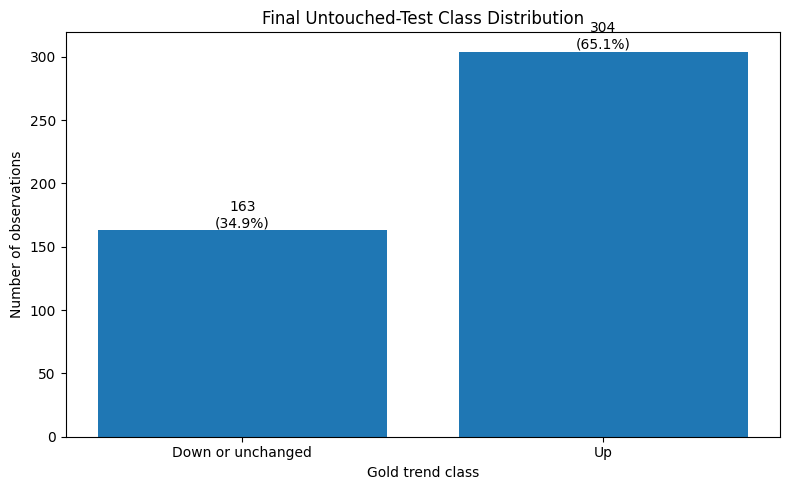

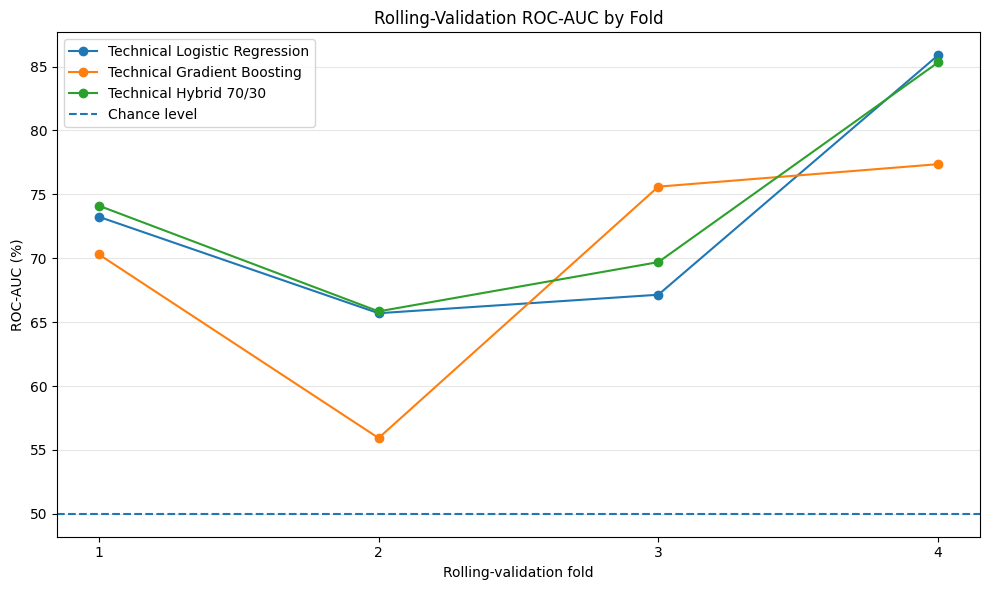

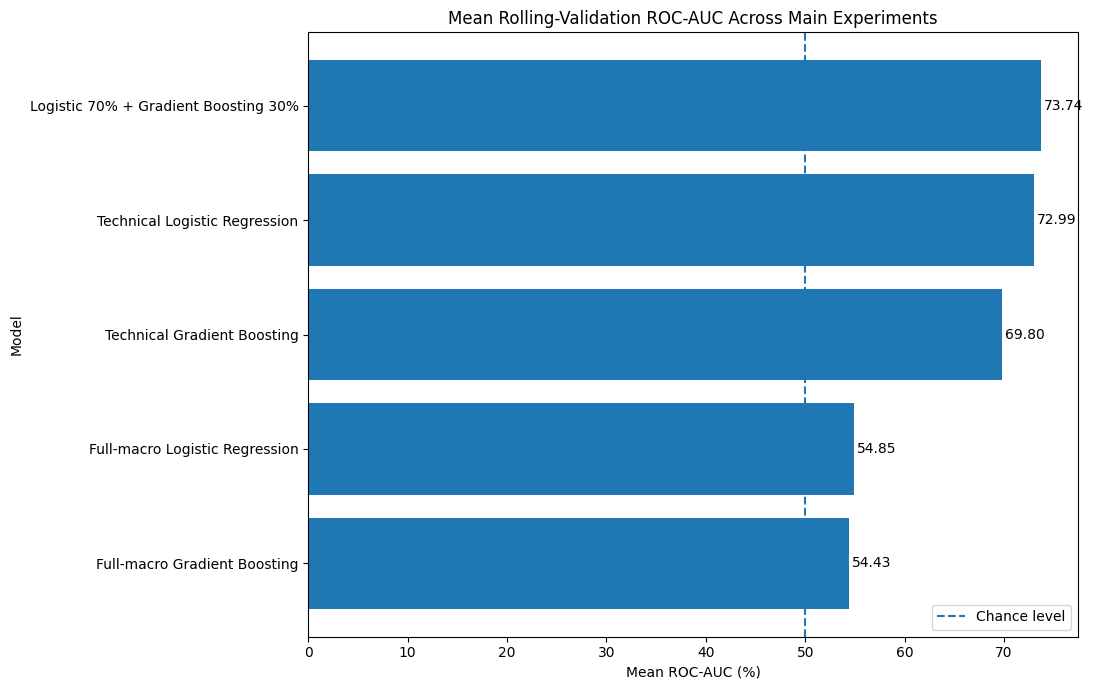

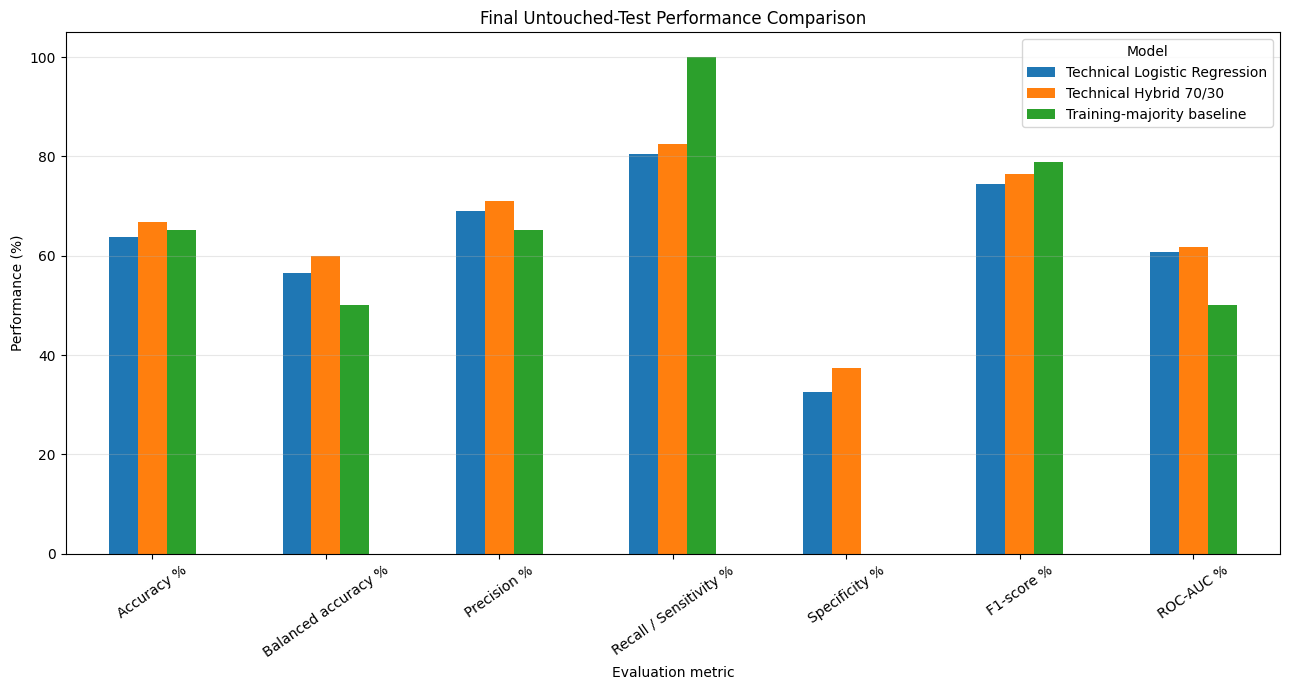

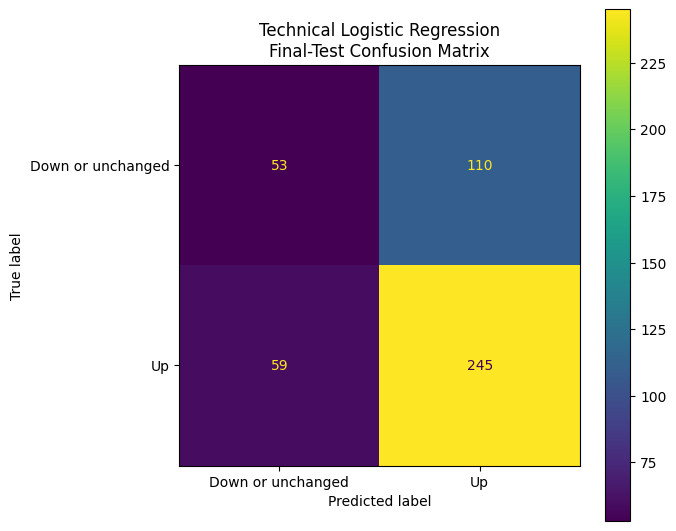

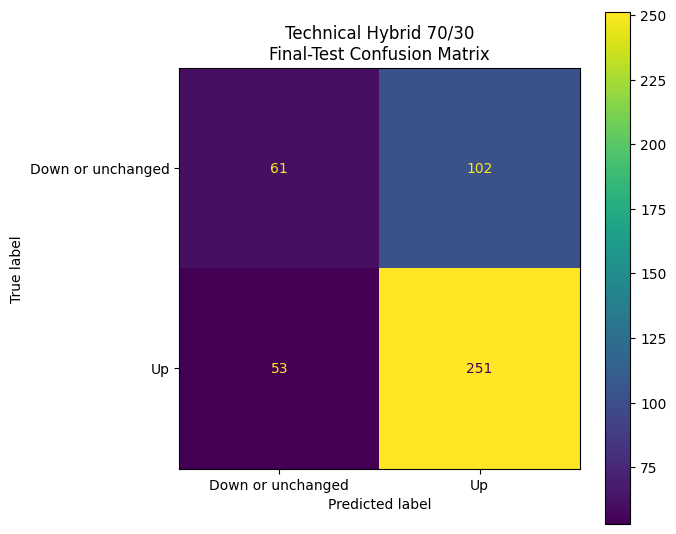

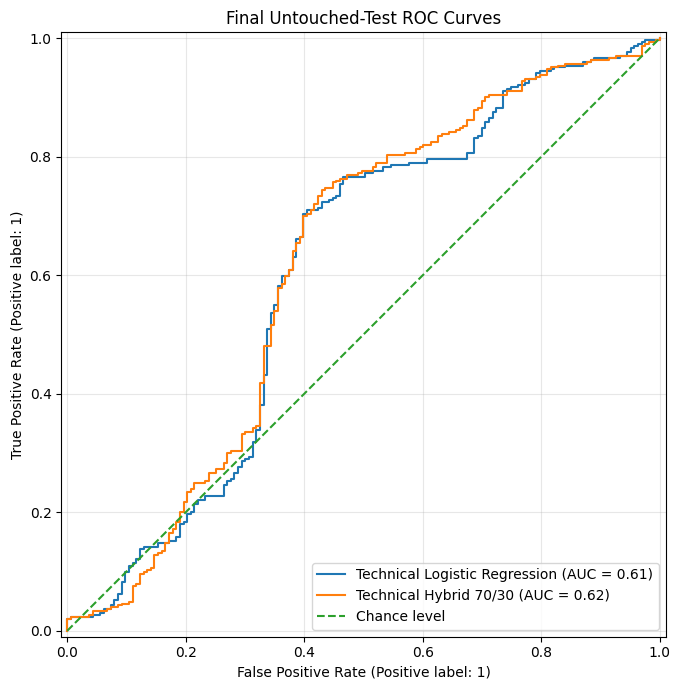

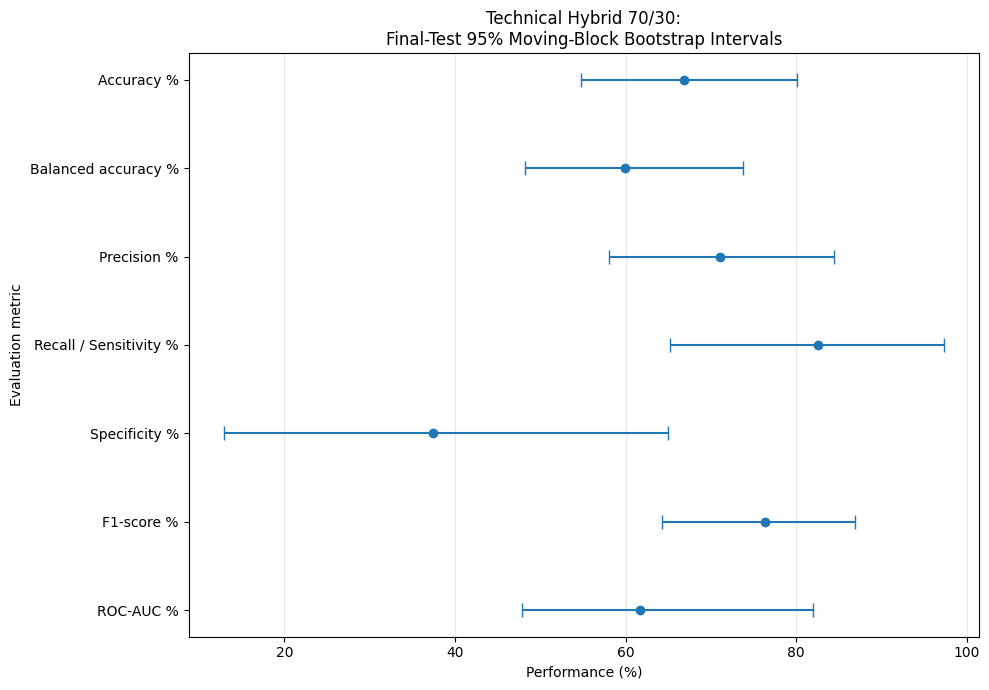

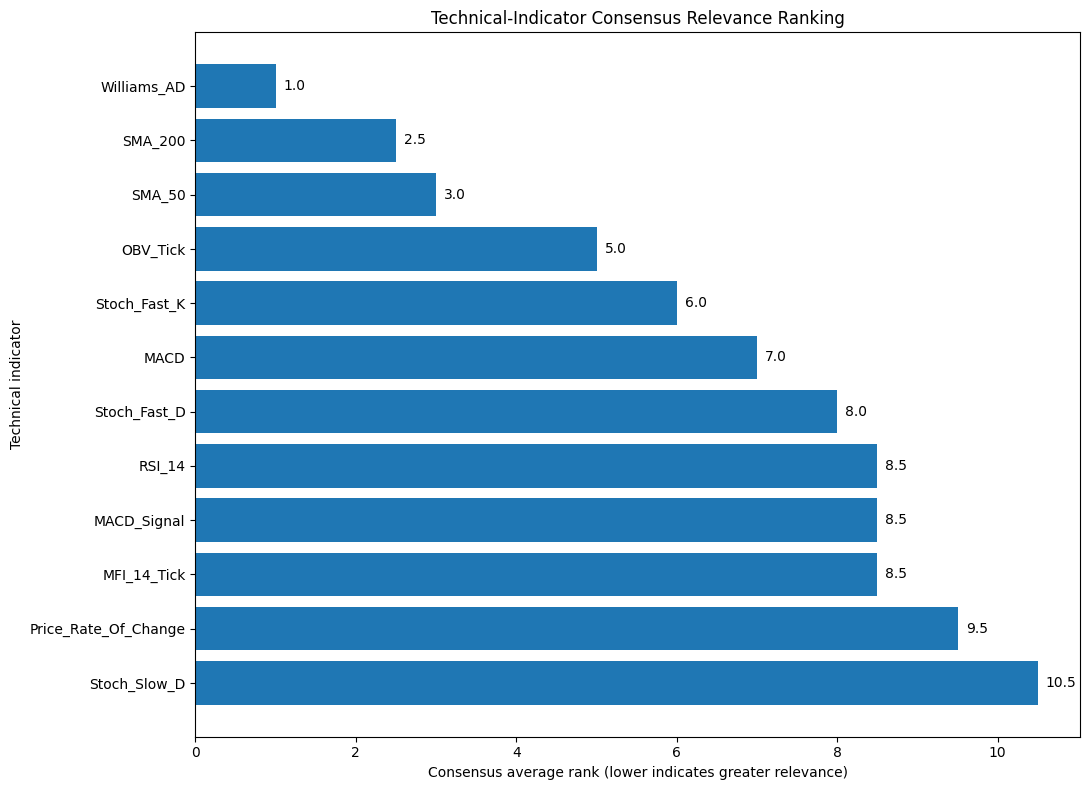

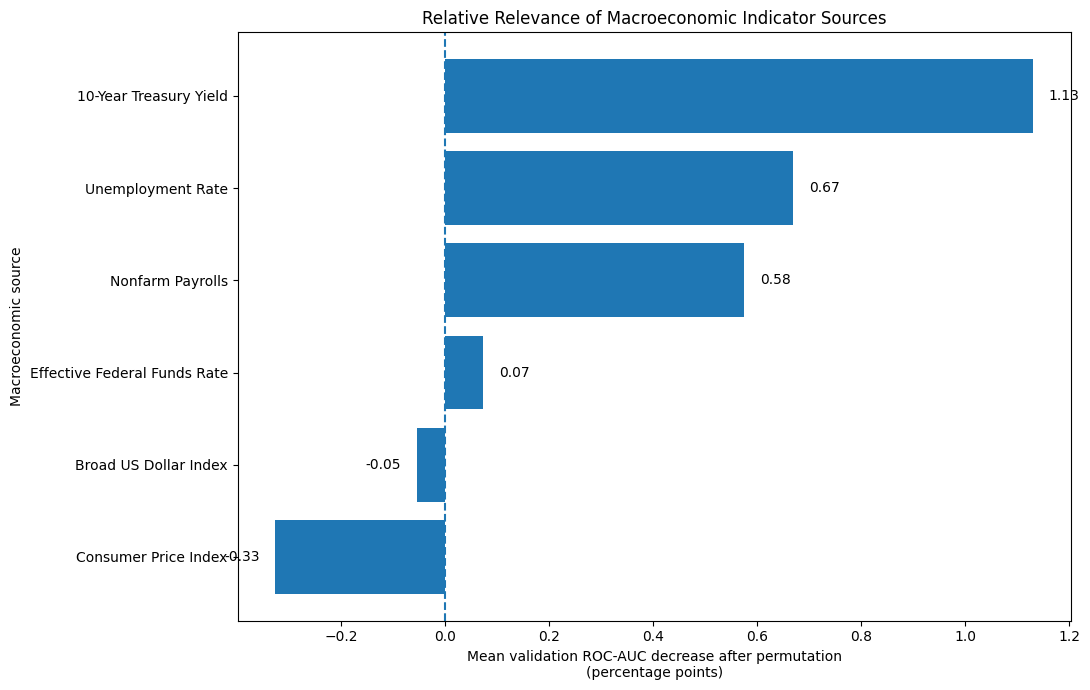


FINAL FIGURE GENERATION AUDIT


,Figure,File exists,File size KB
0,figure_01_final_test_class_distribution.png,True,98.06
1,figure_02_rolling_fold_roc_auc.png,True,231.28
2,figure_03_master_experiment_mean_roc_auc.png,True,175.76
3,figure_04_final_test_metric_comparison.png,True,231.75
4,figure_05_logistic_final_confusion_matrix.png,True,97.64
5,figure_06_hybrid_final_confusion_matrix.png,True,98.20
6,figure_07_final_test_roc_curves.png,True,169.51
7,figure_08_hybrid_bootstrap_confidence_interval...,True,148.72
8,figure_09_technical_indicator_consensus_rankin...,True,187.47
9,figure_10_macroeconomic_source_relevance.png,True,185.01



Figures generated: 10
Expected figures: 10
Missing figure files: 0
Zero-size figure files: 0

All figures were saved in:
final_figures

No model settings were changed during figure generation.


In [ ]:
# ============================================================
# STAGE 7 — STEP 3
# Generate and save publication-ready figures for Chapter Four
#
# No models are trained or modified in this step.
# All figures use previously consolidated locked results.
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)


# ------------------------------------------------------------
# 1. Create the output directory
# ------------------------------------------------------------

figure_directory = "final_figures"

os.makedirs(
    figure_directory,
    exist_ok=True
)


# ------------------------------------------------------------
# 2. Confirm required objects and columns
# ------------------------------------------------------------

required_figure_objects = [
    "common_full_test_data",
    "primary_target",
    "technical_relevance_model_audit",
    "hybrid_fold_auc_table",
    "master_experiment_summary",
    "final_test_results_summary",
    "final_test_predictions",
    "hybrid_bootstrap_summary",
    "technical_indicator_relevance_summary",
    "macroeconomic_source_summary_clean"
]


missing_figure_objects = [
    object_name
    for object_name in required_figure_objects
    if object_name not in globals()
]


if len(missing_figure_objects) > 0:

    raise NameError(
        "The following required objects are missing: "
        + ", ".join(missing_figure_objects)
    )


required_prediction_columns = [
    "Actual_Target",
    "Logistic_Normalized_Score",
    "Logistic_Prediction",
    "Hybrid_70_30_Score",
    "Hybrid_Prediction"
]


missing_prediction_columns = [
    column
    for column in required_prediction_columns
    if column not in final_test_predictions.columns
]


if len(missing_prediction_columns) > 0:

    raise ValueError(
        "The final prediction table is missing: "
        + ", ".join(missing_prediction_columns)
    )


print("FINAL FIGURE GENERATION")
print("=" * 95)

print(
    "Figure directory:",
    figure_directory
)

print(
    "Final-test observations:",
    len(final_test_predictions)
)


saved_figure_paths = []


# ============================================================
# FIGURE 1
# Final-test class distribution
# ============================================================

final_test_class_counts = (
    common_full_test_data[
        primary_target
    ]
    .value_counts()
    .reindex(
        [0, 1],
        fill_value=0
    )
)


figure_path = os.path.join(
    figure_directory,
    "figure_01_final_test_class_distribution.png"
)


fig, ax = plt.subplots(
    figsize=(8, 5)
)


bars = ax.bar(
    [
        "Down or unchanged",
        "Up"
    ],
    final_test_class_counts.values
)


ax.set_title(
    "Final Untouched-Test Class Distribution"
)

ax.set_xlabel(
    "Gold trend class"
)

ax.set_ylabel(
    "Number of observations"
)


for bar, count in zip(
    bars,
    final_test_class_counts.values
):

    percentage = (
        count
        /
        final_test_class_counts.sum()
        *
        100
    )

    ax.text(
        bar.get_x()
        +
        bar.get_width() / 2,

        bar.get_height(),

        f"{count}\n({percentage:.1f}%)",

        ha="center",
        va="bottom"
    )


fig.tight_layout()

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

saved_figure_paths.append(
    figure_path
)


# ============================================================
# FIGURE 2
# Rolling-fold ROC-AUC comparison
# ============================================================

rolling_auc_figure_data = (
    technical_relevance_model_audit[
        [
            "Fold",
            "Logistic ROC-AUC %",
            "Gradient Boosting ROC-AUC %"
        ]
    ]
    .merge(
        hybrid_fold_auc_table,
        on="Fold",
        how="inner",
        validate="one_to_one"
    )
)


figure_path = os.path.join(
    figure_directory,
    "figure_02_rolling_fold_roc_auc.png"
)


fig, ax = plt.subplots(
    figsize=(10, 6)
)


ax.plot(
    rolling_auc_figure_data["Fold"],
    rolling_auc_figure_data[
        "Logistic ROC-AUC %"
    ],
    marker="o",
    label="Technical Logistic Regression"
)


ax.plot(
    rolling_auc_figure_data["Fold"],
    rolling_auc_figure_data[
        "Gradient Boosting ROC-AUC %"
    ],
    marker="o",
    label="Technical Gradient Boosting"
)


ax.plot(
    rolling_auc_figure_data["Fold"],
    rolling_auc_figure_data[
        "Hybrid ROC-AUC %"
    ],
    marker="o",
    label="Technical Hybrid 70/30"
)


ax.axhline(
    50,
    linestyle="--",
    label="Chance level"
)


ax.set_title(
    "Rolling-Validation ROC-AUC by Fold"
)

ax.set_xlabel(
    "Rolling-validation fold"
)

ax.set_ylabel(
    "ROC-AUC (%)"
)

ax.set_xticks(
    rolling_auc_figure_data["Fold"]
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.3
)


fig.tight_layout()

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

saved_figure_paths.append(
    figure_path
)


# ============================================================
# FIGURE 3
# Mean rolling ROC-AUC across main experiments
# ============================================================

experiment_plot_data = (
    master_experiment_summary
    .sort_values(
        "Mean ROC-AUC %",
        ascending=True
    )
)


figure_path = os.path.join(
    figure_directory,
    "figure_03_master_experiment_mean_roc_auc.png"
)


fig, ax = plt.subplots(
    figsize=(11, 7)
)


bars = ax.barh(
    experiment_plot_data["Model"],
    experiment_plot_data[
        "Mean ROC-AUC %"
    ]
)


ax.axvline(
    50,
    linestyle="--",
    label="Chance level"
)


ax.set_title(
    "Mean Rolling-Validation ROC-AUC Across Main Experiments"
)

ax.set_xlabel(
    "Mean ROC-AUC (%)"
)

ax.set_ylabel(
    "Model"
)

ax.legend()


for bar, value in zip(
    bars,
    experiment_plot_data[
        "Mean ROC-AUC %"
    ]
):

    ax.text(
        value + 0.3,
        bar.get_y()
        +
        bar.get_height() / 2,

        f"{value:.2f}",

        va="center"
    )


fig.tight_layout()

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

saved_figure_paths.append(
    figure_path
)


# ============================================================
# FIGURE 4
# Final-test metric comparison
# ============================================================

final_metric_columns = [
    "Accuracy %",
    "Balanced accuracy %",
    "Precision %",
    "Recall / Sensitivity %",
    "Specificity %",
    "F1-score %",
    "ROC-AUC %"
]


final_metric_plot_data = (

    final_test_results_summary
    .set_index("Model")[
        final_metric_columns
    ]
    .transpose()
)


figure_path = os.path.join(
    figure_directory,
    "figure_04_final_test_metric_comparison.png"
)


ax = final_metric_plot_data.plot(
    kind="bar",
    figsize=(13, 7)
)


ax.set_title(
    "Final Untouched-Test Performance Comparison"
)

ax.set_xlabel(
    "Evaluation metric"
)

ax.set_ylabel(
    "Performance (%)"
)

ax.set_ylim(
    0,
    105
)

ax.tick_params(
    axis="x",
    rotation=35
)

ax.legend(
    title="Model",
    loc="upper right"
)

ax.grid(
    axis="y",
    alpha=0.3
)


fig = ax.get_figure()

fig.tight_layout()

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

saved_figure_paths.append(
    figure_path
)


# ============================================================
# FIGURE 5
# Logistic Regression final confusion matrix
# ============================================================

figure_path = os.path.join(
    figure_directory,
    "figure_05_logistic_final_confusion_matrix.png"
)


fig, ax = plt.subplots(
    figsize=(7, 6)
)


ConfusionMatrixDisplay.from_predictions(

    final_test_predictions[
        "Actual_Target"
    ],

    final_test_predictions[
        "Logistic_Prediction"
    ],

    labels=[
        0,
        1
    ],

    display_labels=[
        "Down or unchanged",
        "Up"
    ],

    values_format="d",

    ax=ax
)


ax.set_title(
    "Technical Logistic Regression\nFinal-Test Confusion Matrix"
)


fig.tight_layout()

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

saved_figure_paths.append(
    figure_path
)


# ============================================================
# FIGURE 6
# Hybrid final confusion matrix
# ============================================================

figure_path = os.path.join(
    figure_directory,
    "figure_06_hybrid_final_confusion_matrix.png"
)


fig, ax = plt.subplots(
    figsize=(7, 6)
)


ConfusionMatrixDisplay.from_predictions(

    final_test_predictions[
        "Actual_Target"
    ],

    final_test_predictions[
        "Hybrid_Prediction"
    ],

    labels=[
        0,
        1
    ],

    display_labels=[
        "Down or unchanged",
        "Up"
    ],

    values_format="d",

    ax=ax
)


ax.set_title(
    "Technical Hybrid 70/30\nFinal-Test Confusion Matrix"
)


fig.tight_layout()

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

saved_figure_paths.append(
    figure_path
)


# ============================================================
# FIGURE 7
# Final-test ROC curves
# ============================================================

figure_path = os.path.join(
    figure_directory,
    "figure_07_final_test_roc_curves.png"
)


fig, ax = plt.subplots(
    figsize=(8, 7)
)


RocCurveDisplay.from_predictions(

    final_test_predictions[
        "Actual_Target"
    ],

    final_test_predictions[
        "Logistic_Normalized_Score"
    ],

    name="Technical Logistic Regression",

    ax=ax
)


RocCurveDisplay.from_predictions(

    final_test_predictions[
        "Actual_Target"
    ],

    final_test_predictions[
        "Hybrid_70_30_Score"
    ],

    name="Technical Hybrid 70/30",

    ax=ax
)


ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Chance level"
)


ax.set_title(
    "Final Untouched-Test ROC Curves"
)

ax.legend(
    loc="lower right"
)

ax.grid(
    alpha=0.3
)


fig.tight_layout()

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

saved_figure_paths.append(
    figure_path
)


# ============================================================
# FIGURE 8
# Hybrid block-bootstrap confidence intervals
# ============================================================

bootstrap_plot_data = (
    hybrid_bootstrap_summary
    .copy()
    .iloc[::-1]
    .reset_index(drop=True)
)


bootstrap_lower_error = (
    bootstrap_plot_data[
        "Point estimate"
    ]
    -
    bootstrap_plot_data[
        "95% CI lower"
    ]
)


bootstrap_upper_error = (
    bootstrap_plot_data[
        "95% CI upper"
    ]
    -
    bootstrap_plot_data[
        "Point estimate"
    ]
)


figure_path = os.path.join(
    figure_directory,
    "figure_08_hybrid_bootstrap_confidence_intervals.png"
)


fig, ax = plt.subplots(
    figsize=(10, 7)
)


ax.errorbar(

    bootstrap_plot_data[
        "Point estimate"
    ],

    np.arange(
        len(bootstrap_plot_data)
    ),

    xerr=np.vstack(
        [
            bootstrap_lower_error,
            bootstrap_upper_error
        ]
    ),

    fmt="o",
    capsize=5
)


ax.set_yticks(
    np.arange(
        len(bootstrap_plot_data)
    )
)

ax.set_yticklabels(
    bootstrap_plot_data[
        "Metric"
    ]
)


ax.set_title(
    "Technical Hybrid 70/30:\n"
    "Final-Test 95% Moving-Block Bootstrap Intervals"
)

ax.set_xlabel(
    "Performance (%)"
)

ax.set_ylabel(
    "Evaluation metric"
)

ax.grid(
    axis="x",
    alpha=0.3
)


fig.tight_layout()

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

saved_figure_paths.append(
    figure_path
)


# ============================================================
# FIGURE 9
# Technical-indicator consensus ranking
# ============================================================

technical_relevance_plot_data = (
    technical_indicator_relevance_summary
    .sort_values(
        "Consensus average rank",
        ascending=False
    )
)


figure_path = os.path.join(
    figure_directory,
    "figure_09_technical_indicator_consensus_ranking.png"
)


fig, ax = plt.subplots(
    figsize=(11, 8)
)


bars = ax.barh(

    technical_relevance_plot_data[
        "Feature"
    ],

    technical_relevance_plot_data[
        "Consensus average rank"
    ]
)


ax.set_title(
    "Technical-Indicator Consensus Relevance Ranking"
)

ax.set_xlabel(
    "Consensus average rank (lower indicates greater relevance)"
)

ax.set_ylabel(
    "Technical indicator"
)


for bar, rank_value in zip(

    bars,

    technical_relevance_plot_data[
        "Consensus average rank"
    ]
):

    ax.text(
        rank_value + 0.1,
        bar.get_y()
        +
        bar.get_height() / 2,

        f"{rank_value:.1f}",

        va="center"
    )


fig.tight_layout()

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

saved_figure_paths.append(
    figure_path
)


# ============================================================
# FIGURE 10
# Macroeconomic-source relative relevance
# ============================================================

macro_source_plot_data = (
    macroeconomic_source_summary_clean
    .sort_values(
        "Mean_permutation_AUC_decrease",
        ascending=True
    )
)


figure_path = os.path.join(
    figure_directory,
    "figure_10_macroeconomic_source_relevance.png"
)


fig, ax = plt.subplots(
    figsize=(11, 7)
)


bars = ax.barh(

    macro_source_plot_data[
        "Macro source"
    ],

    macro_source_plot_data[
        "Mean_permutation_AUC_decrease"
    ]
)


ax.axvline(
    0,
    linestyle="--"
)


ax.set_title(
    "Relative Relevance of Macroeconomic Indicator Sources"
)

ax.set_xlabel(
    "Mean validation ROC-AUC decrease after permutation\n"
    "(percentage points)"
)

ax.set_ylabel(
    "Macroeconomic source"
)


for bar, value in zip(

    bars,

    macro_source_plot_data[
        "Mean_permutation_AUC_decrease"
    ]
):

    horizontal_alignment = (
        "left"
        if value >= 0
        else "right"
    )

    text_offset = (
        0.03
        if value >= 0
        else -0.03
    )

    ax.text(
        value + text_offset,
        bar.get_y()
        +
        bar.get_height() / 2,

        f"{value:.2f}",

        va="center",
        ha=horizontal_alignment
    )


fig.tight_layout()

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

saved_figure_paths.append(
    figure_path
)


# ============================================================
# 3. Save figure-source tables
# ============================================================

rolling_auc_figure_data.to_csv(
    os.path.join(
        figure_directory,
        "figure_02_source_data.csv"
    ),
    index=False
)


final_metric_plot_data.to_csv(
    os.path.join(
        figure_directory,
        "figure_04_source_data.csv"
    )
)


bootstrap_plot_data.to_csv(
    os.path.join(
        figure_directory,
        "figure_08_source_data.csv"
    ),
    index=False
)


technical_relevance_plot_data.to_csv(
    os.path.join(
        figure_directory,
        "figure_09_source_data.csv"
    ),
    index=False
)


macro_source_plot_data.to_csv(
    os.path.join(
        figure_directory,
        "figure_10_source_data.csv"
    ),
    index=False
)


# ============================================================
# 4. Final figure-generation audit
# ============================================================

figure_audit_rows = []


for figure_path in saved_figure_paths:

    figure_audit_rows.append({

        "Figure":
            os.path.basename(
                figure_path
            ),

        "File exists":
            os.path.exists(
                figure_path
            ),

        "File size KB":
            (
                os.path.getsize(
                    figure_path
                )
                /
                1024
                if os.path.exists(
                    figure_path
                )
                else np.nan
            )
    })


final_figure_audit = pd.DataFrame(
    figure_audit_rows
)


print("\nFINAL FIGURE GENERATION AUDIT")
print("=" * 105)

display(
    final_figure_audit.round(2)
)


print(
    "\nFigures generated:",
    len(final_figure_audit)
)

print(
    "Expected figures:",
    10
)

print(
    "Missing figure files:",
    int(
        (
            final_figure_audit[
                "File exists"
            ] == False
        ).sum()
    )
)

print(
    "Zero-size figure files:",
    int(
        (
            final_figure_audit[
                "File size KB"
            ] <= 0
        ).sum()
    )
)


print(
    "\nAll figures were saved in:"
)

print(
    figure_directory
)


print(
    "\nNo model settings were changed "
    "during figure generation."
)

In [ ]:
# ============================================================
# STAGE 7 — STEP 4
# Create the final reporting and results package
#
# The package contains:
# - Consolidated tables
# - Indicator-relevance results
# - Final-test predictions
# - Bootstrap results
# - Figures and figure-source data
# - Locked model configuration
# - File-integrity manifest
#
# No model training, tuning or modification occurs here.
# ============================================================

import os
import glob
import json
import shutil
import hashlib
import zipfile

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Define the package folders
# ------------------------------------------------------------

package_root = "GOLD_FINAL_RESULTS_PACKAGE"

package_folders = {
    "tables": os.path.join(package_root, "tables"),
    "relevance": os.path.join(package_root, "indicator_relevance"),
    "predictions": os.path.join(package_root, "predictions"),
    "bootstrap": os.path.join(package_root, "bootstrap"),
    "figures": os.path.join(package_root, "figures"),
    "configuration": os.path.join(package_root, "configuration")
}


# Remove an earlier incomplete version, if one exists.
if os.path.exists(package_root):
    shutil.rmtree(package_root)


for folder_path in package_folders.values():
    os.makedirs(
        folder_path,
        exist_ok=True
    )


print("FINAL REPORTING PACKAGE CREATION")
print("=" * 100)

print(
    "Package root:",
    package_root
)


# ------------------------------------------------------------
# 2. Confirm required notebook objects
# ------------------------------------------------------------

required_package_objects = [

    "dataset_period_summary",
    "hybrid_fold_auc_table",
    "master_experiment_summary",
    "final_test_results_summary",
    "hybrid_bootstrap_summary",
    "paired_bootstrap_results_summary",

    "technical_indicator_relevance_summary",
    "technical_logistic_relevance_by_fold",
    "technical_gradient_relevance_by_fold",

    "macroeconomic_feature_relevance_summary",
    "macro_source_relevance_summary",
    "macro_logistic_relevance_by_fold",
    "macro_gradient_relevance_by_fold",

    "final_test_predictions",
    "technical_feature_columns",
    "primary_target",

    "common_full_pretest_data",
    "common_final_purge_data",
    "common_full_test_data"
]


missing_package_objects = [

    object_name
    for object_name in required_package_objects
    if object_name not in globals()
]


if len(missing_package_objects) > 0:

    raise NameError(
        "The following required objects are missing: "
        + ", ".join(missing_package_objects)
        + ". Run the earlier notebook cells first."
    )


print(
    "All required package objects are available."
)


# ============================================================
# 3. EXPORT CONSOLIDATED REPORTING TABLES
# ============================================================

reporting_tables = {

    "dataset_period_summary.csv":
        dataset_period_summary,

    "hybrid_fold_auc_table.csv":
        hybrid_fold_auc_table,

    "master_experiment_summary.csv":
        master_experiment_summary,

    "final_test_results_summary.csv":
        final_test_results_summary
}


for filename, dataframe in reporting_tables.items():

    dataframe.to_csv(
        os.path.join(
            package_folders["tables"],
            filename
        ),
        index=False
    )


# ============================================================
# 4. EXPORT INDICATOR-RELEVANCE TABLES
# ============================================================

relevance_tables = {

    "technical_indicator_relevance_summary.csv":
        technical_indicator_relevance_summary,

    "technical_logistic_relevance_by_fold.csv":
        technical_logistic_relevance_by_fold,

    "technical_gradient_relevance_by_fold.csv":
        technical_gradient_relevance_by_fold,

    "macroeconomic_feature_relevance_summary.csv":
        macroeconomic_feature_relevance_summary,

    "macroeconomic_source_relevance_summary.csv":
        macro_source_relevance_summary,

    "macro_logistic_relevance_by_fold.csv":
        macro_logistic_relevance_by_fold,

    "macro_gradient_relevance_by_fold.csv":
        macro_gradient_relevance_by_fold
}


for filename, dataframe in relevance_tables.items():

    dataframe.to_csv(
        os.path.join(
            package_folders["relevance"],
            filename
        ),
        index=False
    )


# ============================================================
# 5. EXPORT FINAL-TEST PREDICTIONS
# ============================================================

final_test_predictions.to_csv(

    os.path.join(
        package_folders["predictions"],
        "final_test_predictions.csv"
    ),

    index=False
)


# ============================================================
# 6. EXPORT BOOTSTRAP RESULTS
# ============================================================

bootstrap_tables = {

    "hybrid_bootstrap_confidence_intervals.csv":
        hybrid_bootstrap_summary,

    "paired_block_bootstrap_comparisons.csv":
        paired_bootstrap_results_summary
}


for filename, dataframe in bootstrap_tables.items():

    dataframe.to_csv(
        os.path.join(
            package_folders["bootstrap"],
            filename
        ),
        index=False
    )


# ============================================================
# 7. COPY ALL FINAL FIGURES AND THEIR SOURCE DATA
# ============================================================

figure_source_directory = "final_figures"


if not os.path.exists(figure_source_directory):

    raise FileNotFoundError(
        "The final_figures directory was not found. "
        "Run Stage 7 — Step 3 first."
    )


figure_files_to_copy = glob.glob(
    os.path.join(
        figure_source_directory,
        "*"
    )
)


for source_file in figure_files_to_copy:

    if os.path.isfile(source_file):

        shutil.copy2(
            source_file,
            os.path.join(
                package_folders["figures"],
                os.path.basename(source_file)
            )
        )


# ============================================================
# 8. CREATE THE LOCKED CONFIGURATION FILE
# ============================================================

def make_json_safe(value):
    """
    Convert pandas and NumPy values into JSON-compatible types.
    """

    if isinstance(value, pd.Timestamp):
        return value.isoformat()

    if isinstance(value, np.integer):
        return int(value)

    if isinstance(value, np.floating):
        return float(value)

    if isinstance(value, np.bool_):
        return bool(value)

    if pd.isna(value):
        return None

    return value


# Retrieve the exact stored thresholds from the results table.
logistic_result_row = (
    final_test_results_summary[
        final_test_results_summary["Model"]
        == "Technical Logistic Regression"
    ]
    .iloc[0]
)


hybrid_result_row = (
    final_test_results_summary[
        final_test_results_summary["Model"]
        == "Technical Hybrid 70/30"
    ]
    .iloc[0]
)


final_configuration = {

    "project":
        "Gold trend forecasting",

    "asset":
        "XAU/USD",

    "forecast_horizon_trading_days":
        20,

    "target_column":
        primary_target,

    "target_definition":
        (
            "Up when the XAU/USD closing price twenty trading "
            "days later exceeds the current closing price; "
            "down or unchanged otherwise."
        ),

    "final_hybrid":
        "Technical Logistic Regression 70% + Technical Gradient Boosting 30%",

    "hybrid_contains_macroeconomic_features":
        False,

    "logistic_weight":
        0.70,

    "gradient_boosting_weight":
        0.30,

    "logistic_threshold":
        make_json_safe(
            logistic_result_row["Threshold"]
        ),

    "hybrid_threshold":
        make_json_safe(
            hybrid_result_row["Threshold"]
        ),

    "technical_features":
        list(technical_feature_columns),

    "number_of_technical_features":
        len(technical_feature_columns),

    "pretest_training_rows":
        len(common_full_pretest_data),

    "pretest_training_start":
        make_json_safe(
            common_full_pretest_data["Date"].min()
        ),

    "pretest_training_end":
        make_json_safe(
            common_full_pretest_data["Date"].max()
        ),

    "final_purge_rows":
        len(common_final_purge_data),

    "final_purge_start":
        make_json_safe(
            common_final_purge_data["Date"].min()
        ),

    "final_purge_end":
        make_json_safe(
            common_final_purge_data["Date"].max()
        ),

    "final_test_rows":
        len(common_full_test_data),

    "final_test_start":
        make_json_safe(
            common_full_test_data["Date"].min()
        ),

    "final_test_end":
        make_json_safe(
            common_full_test_data["Date"].max()
        ),

    "final_hybrid_test_metrics_percent": {

        "accuracy":
            make_json_safe(
                hybrid_result_row["Accuracy %"]
            ),

        "balanced_accuracy":
            make_json_safe(
                hybrid_result_row[
                    "Balanced accuracy %"
                ]
            ),

        "precision":
            make_json_safe(
                hybrid_result_row["Precision %"]
            ),

        "recall_sensitivity":
            make_json_safe(
                hybrid_result_row[
                    "Recall / Sensitivity %"
                ]
            ),

        "specificity":
            make_json_safe(
                hybrid_result_row["Specificity %"]
            ),

        "f1_score":
            make_json_safe(
                hybrid_result_row["F1-score %"]
            ),

        "roc_auc":
            make_json_safe(
                hybrid_result_row["ROC-AUC %"]
            )
    },

    "modelling_status":
        "Locked",

    "test_period_status":
        "Opened once for final evaluation",

    "post_test_model_changes":
        False
}


configuration_path = os.path.join(
    package_folders["configuration"],
    "final_locked_configuration.json"
)


with open(
    configuration_path,
    "w",
    encoding="utf-8"
) as configuration_file:

    json.dump(
        final_configuration,
        configuration_file,
        indent=4,
        ensure_ascii=False
    )


# ============================================================
# 9. CREATE A README FILE
# ============================================================

readme_text = """
GOLD TREND FORECASTING — FINAL RESULTS PACKAGE

Forecast target
---------------
The target indicates whether XAU/USD closes higher after twenty
trading days than on the current date.

Selected final model
--------------------
70% Technical Logistic Regression
30% Technical Gradient Boosting

The final hybrid does not contain macroeconomic variables.

Macroeconomic indicators were investigated through macro-only
models, early fusion, late fusion, release-event features,
regime features and interaction terms. They did not provide a
stable improvement over technical indicators.

Folder contents
---------------
tables/
    Consolidated modelling and final-test result tables.

indicator_relevance/
    Fold-level and consensus relevance results for technical and
    macroeconomic indicators.

predictions/
    Locked final-test predictions for the 2023–2024 test period.

bootstrap/
    Moving-block bootstrap confidence intervals and paired model
    comparisons.

figures/
    Publication-ready Chapter Four figures and their source data.

configuration/
    Locked model weights, thresholds, features and date ranges.

Important
---------
The final test period has been opened. The model weights,
thresholds, features and hyperparameters must not be changed
based on the final-test results.
""".strip()


readme_path = os.path.join(
    package_root,
    "README.txt"
)


with open(
    readme_path,
    "w",
    encoding="utf-8"
) as readme_file:

    readme_file.write(
        readme_text
    )


# ============================================================
# 10. CREATE A SHA-256 FILE MANIFEST
# ============================================================

def calculate_sha256(file_path):
    """
    Calculate the SHA-256 checksum of a file.
    """

    sha256_hash = hashlib.sha256()

    with open(
        file_path,
        "rb"
    ) as file_to_hash:

        for data_block in iter(
            lambda: file_to_hash.read(65536),
            b""
        ):

            sha256_hash.update(data_block)

    return sha256_hash.hexdigest()


manifest_rows = []


for root_directory, _, filenames in os.walk(
    package_root
):

    for filename in filenames:

        full_path = os.path.join(
            root_directory,
            filename
        )

        relative_path = os.path.relpath(
            full_path,
            package_root
        )

        manifest_rows.append({

            "Relative path":
                relative_path,

            "File size bytes":
                os.path.getsize(
                    full_path
                ),

            "SHA256":
                calculate_sha256(
                    full_path
                )
        })


file_manifest = (
    pd.DataFrame(
        manifest_rows
    )
    .sort_values(
        "Relative path"
    )
    .reset_index(drop=True)
)


manifest_path = os.path.join(
    package_root,
    "file_manifest.csv"
)


file_manifest.to_csv(
    manifest_path,
    index=False
)


# ============================================================
# 11. CREATE THE ZIP ARCHIVE
# ============================================================

zip_filename = (
    "GOLD_FINAL_RESULTS_PACKAGE.zip"
)


if os.path.exists(zip_filename):
    os.remove(zip_filename)


with zipfile.ZipFile(
    zip_filename,
    mode="w",
    compression=zipfile.ZIP_DEFLATED
) as zip_file:

    for root_directory, _, filenames in os.walk(
        package_root
    ):

        for filename in filenames:

            full_path = os.path.join(
                root_directory,
                filename
            )

            archive_path = os.path.relpath(
                full_path,
                os.path.dirname(package_root)
            )

            zip_file.write(
                full_path,
                archive_path
            )


# ============================================================
# 12. FINAL PACKAGE AUDIT
# ============================================================

package_audit_rows = []


for folder_name, folder_path in package_folders.items():

    folder_files = [

        file_path
        for file_path in glob.glob(
            os.path.join(
                folder_path,
                "*"
            )
        )
        if os.path.isfile(file_path)
    ]

    package_audit_rows.append({

        "Folder":
            folder_name,

        "Folder exists":
            os.path.exists(folder_path),

        "Number of files":
            len(folder_files),

        "Total size KB":
            sum(
                os.path.getsize(file_path)
                for file_path in folder_files
            ) / 1024
    })


final_package_audit = pd.DataFrame(
    package_audit_rows
)


print("\nFINAL REPORTING PACKAGE AUDIT")
print("=" * 105)

display(
    final_package_audit.round(2)
)


print(
    "\nManifest file rows:",
    len(file_manifest)
)

print(
    "ZIP archive exists:",
    os.path.exists(zip_filename)
)

print(
    "ZIP archive size MB:",
    round(
        os.path.getsize(zip_filename)
        / (1024 ** 2),
        2
    )
)

print(
    "Missing package folders:",
    int(
        (
            final_package_audit[
                "Folder exists"
            ] == False
        ).sum()
    )
)

print(
    "Empty package folders:",
    int(
        (
            final_package_audit[
                "Number of files"
            ] == 0
        ).sum()
    )
)


print("\nCreated package folder:")

print(
    package_root
)


print("\nCreated ZIP archive:")

print(
    zip_filename
)


print(
    "\nNo models, features, thresholds, weights or "
    "hyperparameters were changed."
)

FINAL REPORTING PACKAGE CREATION
Package root: GOLD_FINAL_RESULTS_PACKAGE
All required package objects are available.

FINAL REPORTING PACKAGE AUDIT


,Folder,Folder exists,Number of files,Total size KB
0,tables,True,4,2.18
1,relevance,True,7,39.19
2,predictions,True,1,52.29
3,bootstrap,True,2,2.42
4,figures,True,15,1628.85
5,configuration,True,1,1.75



Manifest file rows: 31
ZIP archive exists: True
ZIP archive size MB: 1.27
Missing package folders: 0
Empty package folders: 0

Created package folder:
GOLD_FINAL_RESULTS_PACKAGE

Created ZIP archive:
GOLD_FINAL_RESULTS_PACKAGE.zip

No models, features, thresholds, weights or hyperparameters were changed.


In [ ]:
# ============================================================
# STAGE 7 — STEP 5A
# Download the final results package before restarting Colab
# ============================================================

from google.colab import files

files.download(
    "GOLD_FINAL_RESULTS_PACKAGE.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# STAGE 7 — STEP 5B
# FINAL CLEAN-RUN REPRODUCIBILITY AUDIT
#
# This cell verifies that the principal locked results were
# reproduced after running the notebook in a fresh runtime.
# It does not train, tune or modify any model.
# ============================================================

import os
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# Helper function for storing audit results
# ------------------------------------------------------------

reproducibility_checks = []


def record_check(check_name, observed, expected, passed):
    reproducibility_checks.append({
        "Check": check_name,
        "Observed": observed,
        "Expected": expected,
        "Result": "PASS" if passed else "FAIL"
    })


# ------------------------------------------------------------
# 1. Required-object audit
# ------------------------------------------------------------

required_objects = [
    "common_full_pretest_data",
    "common_final_purge_data",
    "common_full_test_data",
    "final_test_predictions",
    "final_test_results_summary",
    "technical_indicator_relevance_summary",
    "macroeconomic_feature_relevance_summary",
    "final_figure_audit",
    "file_manifest"
]


missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]


record_check(
    "Required notebook objects",
    len(missing_objects),
    0,
    len(missing_objects) == 0
)


if len(missing_objects) > 0:
    raise NameError(
        "Missing required objects: "
        + ", ".join(missing_objects)
    )


# ------------------------------------------------------------
# 2. Dataset-period checks
# ------------------------------------------------------------

record_check(
    "Pre-test rows",
    len(common_full_pretest_data),
    1980,
    len(common_full_pretest_data) == 1980
)

record_check(
    "Final purge rows",
    len(common_final_purge_data),
    20,
    len(common_final_purge_data) == 20
)

record_check(
    "Final test rows",
    len(common_full_test_data),
    467,
    len(common_full_test_data) == 467
)


record_check(
    "Pre-test start date",
    str(common_full_pretest_data["Date"].min().date()),
    "2015-02-02",
    pd.Timestamp(
        common_full_pretest_data["Date"].min()
    ).normalize() == pd.Timestamp("2015-02-02")
)

record_check(
    "Pre-test end date",
    str(common_full_pretest_data["Date"].max().date()),
    "2023-01-13",
    pd.Timestamp(
        common_full_pretest_data["Date"].max()
    ).normalize() == pd.Timestamp("2023-01-13")
)

record_check(
    "Final test start date",
    str(common_full_test_data["Date"].min().date()),
    "2023-02-13",
    pd.Timestamp(
        common_full_test_data["Date"].min()
    ).normalize() == pd.Timestamp("2023-02-13")
)

record_check(
    "Final test end date",
    str(common_full_test_data["Date"].max().date()),
    "2024-12-02",
    pd.Timestamp(
        common_full_test_data["Date"].max()
    ).normalize() == pd.Timestamp("2024-12-02")
)


# ------------------------------------------------------------
# 3. Final-prediction integrity checks
# ------------------------------------------------------------

record_check(
    "Final prediction rows",
    len(final_test_predictions),
    467,
    len(final_test_predictions) == 467
)

record_check(
    "Duplicate final prediction dates",
    final_test_predictions["Date"].duplicated().sum(),
    0,
    final_test_predictions["Date"].duplicated().sum() == 0
)

record_check(
    "Missing final prediction values",
    final_test_predictions.isna().sum().sum(),
    0,
    final_test_predictions.isna().sum().sum() == 0
)


# ------------------------------------------------------------
# 4. Retrieve the locked final hybrid row
# ------------------------------------------------------------

hybrid_row = (
    final_test_results_summary[
        final_test_results_summary["Model"]
        == "Technical Hybrid 70/30"
    ]
    .iloc[0]
)


expected_hybrid_metrics = {
    "Accuracy %": 66.809,
    "Balanced accuracy %": 59.995,
    "Precision %": 71.105,
    "Recall / Sensitivity %": 82.566,
    "Specificity %": 37.423,
    "F1-score %": 76.408,
    "ROC-AUC %": 61.705
}


for metric_name, expected_value in expected_hybrid_metrics.items():

    observed_value = float(
        hybrid_row[metric_name]
    )

    passed = np.isclose(
        observed_value,
        expected_value,
        atol=0.01
    )

    record_check(
        f"Hybrid {metric_name}",
        round(observed_value, 3),
        expected_value,
        passed
    )


# ------------------------------------------------------------
# 5. Confusion-matrix count checks
# ------------------------------------------------------------

expected_confusion_counts = {
    "True negatives": 61,
    "False positives": 102,
    "False negatives": 53,
    "True positives": 251,
    "Predicted Down": 114,
    "Predicted Up": 353
}


for column_name, expected_value in expected_confusion_counts.items():

    observed_value = int(
        hybrid_row[column_name]
    )

    record_check(
        f"Hybrid {column_name}",
        observed_value,
        expected_value,
        observed_value == expected_value
    )


# ------------------------------------------------------------
# 6. Indicator-ranking checks
# ------------------------------------------------------------

observed_top_five_technical = (
    technical_indicator_relevance_summary
    .head(5)["Feature"]
    .tolist()
)


expected_top_five_technical = [
    "Williams_AD",
    "SMA_200",
    "SMA_50",
    "OBV_Tick",
    "Stoch_Fast_K"
]


record_check(
    "Top five technical indicators",
    str(observed_top_five_technical),
    str(expected_top_five_technical),
    observed_top_five_technical
    == expected_top_five_technical
)


observed_top_three_macro = (
    macroeconomic_feature_relevance_summary
    .head(3)["Feature"]
    .tolist()
)


expected_top_three_macro = [
    "Unemployment_Change_12M_Points",
    "DGS10_Level_Lag1",
    "Payroll_Growth_12M_Pct"
]


record_check(
    "Top three macroeconomic features",
    str(observed_top_three_macro),
    str(expected_top_three_macro),
    observed_top_three_macro
    == expected_top_three_macro
)


# ------------------------------------------------------------
# 7. Figure and reporting-package checks
# ------------------------------------------------------------

record_check(
    "Generated figure count",
    len(final_figure_audit),
    10,
    len(final_figure_audit) == 10
)

record_check(
    "Missing figure files",
    int(
        (
            final_figure_audit["File exists"] == False
        ).sum()
    ),
    0,
    (
        final_figure_audit["File exists"] == False
    ).sum() == 0
)

record_check(
    "Manifest rows",
    len(file_manifest),
    31,
    len(file_manifest) == 31
)

record_check(
    "Final ZIP archive exists",
    os.path.exists(
        "GOLD_FINAL_RESULTS_PACKAGE.zip"
    ),
    True,
    os.path.exists(
        "GOLD_FINAL_RESULTS_PACKAGE.zip"
    )
)

record_check(
    "Final ZIP archive is non-empty",
    (
        os.path.getsize(
            "GOLD_FINAL_RESULTS_PACKAGE.zip"
        )
        if os.path.exists(
            "GOLD_FINAL_RESULTS_PACKAGE.zip"
        )
        else 0
    ),
    "Greater than 0 bytes",
    (
        os.path.exists(
            "GOLD_FINAL_RESULTS_PACKAGE.zip"
        )
        and
        os.path.getsize(
            "GOLD_FINAL_RESULTS_PACKAGE.zip"
        ) > 0
    )
)


# ------------------------------------------------------------
# 8. Display the reproducibility audit
# ------------------------------------------------------------

final_reproducibility_audit = pd.DataFrame(
    reproducibility_checks
)


print("FINAL CLEAN-RUN REPRODUCIBILITY AUDIT")
print("=" * 115)

display(
    final_reproducibility_audit
)


passed_checks = int(
    (
        final_reproducibility_audit["Result"]
        == "PASS"
    ).sum()
)

failed_checks = int(
    (
        final_reproducibility_audit["Result"]
        == "FAIL"
    ).sum()
)


print("\nREPRODUCIBILITY SUMMARY")
print("=" * 80)

print(
    "Total checks:",
    len(final_reproducibility_audit)
)

print(
    "Passed checks:",
    passed_checks
)

print(
    "Failed checks:",
    failed_checks
)


if failed_checks == 0:

    print(
        "\nFINAL REPRODUCIBILITY STATUS: PASS"
    )

    print(
        "The complete modelling and reporting pipeline "
        "was reproduced successfully in a fresh runtime."
    )

else:

    print(
        "\nFINAL REPRODUCIBILITY STATUS: FAIL"
    )

    failed_check_names = (
        final_reproducibility_audit[
            final_reproducibility_audit["Result"]
            == "FAIL"
        ]["Check"]
        .tolist()
    )

    print(
        "Failed checks:",
        failed_check_names
    )

    raise AssertionError(
        "The clean-run reproducibility audit contains "
        "one or more failed checks."
    )


print(
    "\nNo model settings were changed during "
    "the reproducibility audit."
)

FINAL CLEAN-RUN REPRODUCIBILITY AUDIT


,Check,Observed,Expected,Result
0,Required notebook objects,0,0,PASS
1,Pre-test rows,1980,1980,PASS
2,Final purge rows,20,20,PASS
3,Final test rows,467,467,PASS
4,Pre-test start date,2015-02-02,2015-02-02,PASS
5,Pre-test end date,2023-01-13,2023-01-13,PASS
6,Final test start date,2023-02-13,2023-02-13,PASS
7,Final test end date,2024-12-02,2024-12-02,PASS
8,Final prediction rows,467,467,PASS
9,Duplicate final prediction dates,0,0,PASS



REPRODUCIBILITY SUMMARY
Total checks: 31
Passed checks: 31
Failed checks: 0

FINAL REPRODUCIBILITY STATUS: PASS
The complete modelling and reporting pipeline was reproduced successfully in a fresh runtime.

No model settings were changed during the reproducibility audit.


# STAGE 8 — RESEARCH PROTOTYPE DASHBOARD

This section exports the locked technical forecasting model and develops a
proof-of-concept dashboard for generating twenty-trading-day XAU/USD trend
predictions.

The prototype does not retrain, tune or modify the final model.

In [ ]:
# ============================================================
# STAGE 8 — STEP 1
# Dashboard model-export readiness audit
#
# This checks whether all fitted models, preprocessing objects,
# score-normalisation values and locked configuration settings
# required by the dashboard are available in memory.
#
# No model is retrained or modified.
# ============================================================

import pandas as pd


required_dashboard_objects = [

    # Locked fitted models
    "final_logistic_model",
    "final_logistic_scaler",
    "final_gradient_model",

    # Score-normalisation parameters
    "final_logistic_training_mean",
    "final_logistic_training_std",
    "final_gradient_training_mean",
    "final_gradient_training_std",

    # Locked hybrid configuration
    "locked_logistic_weight",
    "locked_gradient_weight",
    "locked_logistic_threshold",
    "locked_hybrid_threshold",

    # Feature and data information
    "technical_feature_columns",
    "final_training_data",
    "final_test_data",
    "final_test_predictions",

    # Indicator-relevance results
    "technical_indicator_relevance_summary"
]


dashboard_readiness_rows = []


for object_name in required_dashboard_objects:

    object_available = (
        object_name in globals()
    )

    dashboard_readiness_rows.append({

        "Required object":
            object_name,

        "Available":
            object_available,

        "Object type":
            (
                type(globals()[object_name]).__name__
                if object_available
                else "Missing"
            )
    })


dashboard_export_readiness_audit = pd.DataFrame(
    dashboard_readiness_rows
)


print("DASHBOARD MODEL-EXPORT READINESS AUDIT")
print("=" * 90)

display(
    dashboard_export_readiness_audit
)


missing_dashboard_objects = (
    dashboard_export_readiness_audit[
        dashboard_export_readiness_audit[
            "Available"
        ] == False
    ]["Required object"]
    .tolist()
)


print("\nREADINESS SUMMARY")
print("=" * 70)

print(
    "Required objects:",
    len(required_dashboard_objects)
)

print(
    "Available objects:",
    int(
        dashboard_export_readiness_audit[
            "Available"
        ].sum()
    )
)

print(
    "Missing objects:",
    len(missing_dashboard_objects)
)


if len(missing_dashboard_objects) == 0:

    print(
        "\nDASHBOARD EXPORT STATUS: READY"
    )

    print(
        "The locked model can now be exported "
        "without retraining."
    )

else:

    print(
        "\nDASHBOARD EXPORT STATUS: NOT READY"
    )

    print(
        "Missing objects:",
        missing_dashboard_objects
    )

    print(
        "The notebook runtime must be restored before export."
    )


print(
    "\nNo models or configuration settings "
    "were changed during this audit."
)

DASHBOARD MODEL-EXPORT READINESS AUDIT


,Required object,Available,Object type
0,final_logistic_model,True,LogisticRegression
1,final_logistic_scaler,True,StandardScaler
2,final_gradient_model,True,GradientBoostingClassifier
3,final_logistic_training_mean,True,float64
4,final_logistic_training_std,True,float64
5,final_gradient_training_mean,True,float64
6,final_gradient_training_std,True,float64
7,locked_logistic_weight,True,float
8,locked_gradient_weight,True,float
9,locked_logistic_threshold,True,float



READINESS SUMMARY
Required objects: 16
Available objects: 16
Missing objects: 0

DASHBOARD EXPORT STATUS: READY
The locked model can now be exported without retraining.

No models or configuration settings were changed during this audit.


In [ ]:
# ============================================================
# STAGE 8 — STEP 2
# Export the locked technical hybrid for the dashboard
#
# Bundle contents:
# - Fitted Logistic Regression model
# - Fitted Logistic Regression scaler
# - Fitted Gradient Boosting model
# - Score-normalisation parameters
# - Locked hybrid weights and thresholds
# - Exact ordered technical-feature list
# - Historical input statistics
# - Top supporting indicators
# - Reference final-test cases
#
# No model is retrained or modified.
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Create the prototype-export directory
# ------------------------------------------------------------

prototype_export_directory = "gold_dashboard_prototype"

artifact_directory = os.path.join(
    prototype_export_directory,
    "artifacts"
)

os.makedirs(
    artifact_directory,
    exist_ok=True
)


bundle_path = os.path.join(
    artifact_directory,
    "gold_hybrid_model_bundle.joblib"
)


# ------------------------------------------------------------
# 2. Confirm the locked feature order
# ------------------------------------------------------------

dashboard_feature_columns = list(
    technical_feature_columns
)


print("LOCKED DASHBOARD FEATURE ORDER")
print("=" * 80)

for feature_number, feature_name in enumerate(
    dashboard_feature_columns,
    start=1
):
    print(
        f"{feature_number}. {feature_name}"
    )


if len(dashboard_feature_columns) != 12:
    raise ValueError(
        "The dashboard expected 12 technical features, "
        f"but found {len(dashboard_feature_columns)}."
    )


# ------------------------------------------------------------
# 3. Create historical feature statistics
#
# These values will provide:
# - sensible dashboard defaults;
# - historical-range warnings;
# - basic context for entered indicator values.
# ------------------------------------------------------------

feature_statistics_rows = []


for feature_name in dashboard_feature_columns:

    feature_values = (
        final_training_data[feature_name]
        .astype(float)
    )

    feature_statistics_rows.append({

        "Feature":
            feature_name,

        "Minimum":
            feature_values.min(),

        "First quartile":
            feature_values.quantile(0.25),

        "Median":
            feature_values.median(),

        "Mean":
            feature_values.mean(),

        "Third quartile":
            feature_values.quantile(0.75),

        "Maximum":
            feature_values.max(),

        "Standard deviation":
            feature_values.std(),

        "Training observations":
            feature_values.notna().sum()
    })


dashboard_feature_statistics = pd.DataFrame(
    feature_statistics_rows
)


# ------------------------------------------------------------
# 4. Store the five supporting indicators
# ------------------------------------------------------------

dashboard_supporting_indicators = (
    technical_indicator_relevance_summary
    .head(5)["Feature"]
    .tolist()
)


# ------------------------------------------------------------
# 5. Create human-readable feature labels and groups
# ------------------------------------------------------------

dashboard_feature_labels = {

    "RSI_14":
        "Relative Strength Index (14)",

    "Stoch_Fast_K":
        "Fast Stochastic %K",

    "Stoch_Fast_D":
        "Fast Stochastic %D",

    "Stoch_Slow_D":
        "Slow Stochastic %D",

    "MACD":
        "Moving Average Convergence Divergence",

    "MACD_Signal":
        "MACD Signal",

    "Price_Rate_Of_Change":
        "Price Rate of Change",

    "OBV_Tick":
        "Tick-volume On-Balance Volume",

    "SMA_50":
        "50-day Simple Moving Average",

    "SMA_200":
        "200-day Simple Moving Average",

    "MFI_14_Tick":
        "Tick-volume Money Flow Index (14)",

    "Williams_AD":
        "Williams Accumulation/Distribution"
}


dashboard_feature_groups = {

    "Momentum indicators": [
        "RSI_14",
        "Stoch_Fast_K",
        "Stoch_Fast_D",
        "Stoch_Slow_D",
        "Price_Rate_Of_Change",
        "MFI_14_Tick"
    ],

    "Trend indicators": [
        "MACD",
        "MACD_Signal",
        "SMA_50",
        "SMA_200"
    ],

    "Volume and accumulation indicators": [
        "OBV_Tick",
        "Williams_AD"
    ]
}


# Confirm every model feature has a display label.
missing_feature_labels = [

    feature_name
    for feature_name in dashboard_feature_columns
    if feature_name not in dashboard_feature_labels
]


if len(missing_feature_labels) > 0:
    raise ValueError(
        "Missing dashboard labels for: "
        + ", ".join(missing_feature_labels)
    )


# ------------------------------------------------------------
# 6. Create deterministic reference cases
#
# These will later be used to verify that the Streamlit
# dashboard reproduces notebook scores and predictions.
# ------------------------------------------------------------

reference_source = (
    final_test_data[
        ["Date"] + dashboard_feature_columns
    ]
    .merge(
        final_test_predictions[
            [
                "Date",
                "Actual_Target",
                "Logistic_Normalized_Score",
                "Gradient_Boosting_Normalized_Score",
                "Hybrid_70_30_Score",
                "Logistic_Prediction",
                "Hybrid_Prediction"
            ]
        ],
        on="Date",
        how="inner",
        validate="one_to_one"
    )
    .sort_values("Date")
    .reset_index(drop=True)
)


reference_indices = sorted(
    set([
        0,
        1,
        len(reference_source) // 2,
        len(reference_source) - 2,
        len(reference_source) - 1
    ])
)


dashboard_reference_cases = (
    reference_source
    .iloc[reference_indices]
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 7. Construct the complete model bundle
# ------------------------------------------------------------

gold_dashboard_model_bundle = {

    # ----------------------------------------
    # Project metadata
    # ----------------------------------------
    "project_name":
        "Gold 20-Trading-Day Trend Forecasting Prototype",

    "asset":
        "XAU/USD",

    "forecast_horizon_trading_days":
        20,

    "target_definition":
        (
            "Up when the XAU/USD closing price twenty trading "
            "days later exceeds the current closing price; "
            "Down or unchanged otherwise."
        ),

    # ----------------------------------------
    # Locked fitted modelling objects
    # ----------------------------------------
    "logistic_model":
        final_logistic_model,

    "logistic_scaler":
        final_logistic_scaler,

    "gradient_boosting_model":
        final_gradient_model,

    # ----------------------------------------
    # Exact feature configuration
    # ----------------------------------------
    "feature_columns":
        dashboard_feature_columns,

    "feature_labels":
        dashboard_feature_labels,

    "feature_groups":
        dashboard_feature_groups,

    "feature_statistics":
        dashboard_feature_statistics,

    "supporting_indicators":
        dashboard_supporting_indicators,

    # ----------------------------------------
    # Score-normalisation parameters
    # ----------------------------------------
    "logistic_training_mean":
        float(final_logistic_training_mean),

    "logistic_training_std":
        float(final_logistic_training_std),

    "gradient_training_mean":
        float(final_gradient_training_mean),

    "gradient_training_std":
        float(final_gradient_training_std),

    # ----------------------------------------
    # Locked decision configuration
    # ----------------------------------------
    "logistic_weight":
        float(locked_logistic_weight),

    "gradient_boosting_weight":
        float(locked_gradient_weight),

    "logistic_threshold":
        float(locked_logistic_threshold),

    "hybrid_threshold":
        float(locked_hybrid_threshold),

    "selected_model_name":
        (
            "Technical Hybrid: 70% Logistic Regression "
            "+ 30% Gradient Boosting"
        ),

    "contains_macroeconomic_features":
        False,

    # ----------------------------------------
    # Training-period metadata
    # ----------------------------------------
    "training_rows":
        int(len(final_training_data)),

    "training_start":
        pd.Timestamp(
            final_training_data["Date"].min()
        ),

    "training_end":
        pd.Timestamp(
            final_training_data["Date"].max()
        ),

    # ----------------------------------------
    # Dashboard validation cases
    # ----------------------------------------
    "reference_cases":
        dashboard_reference_cases,

    # ----------------------------------------
    # Academic-use statement
    # ----------------------------------------
    "disclaimer":
        (
            "This prototype is an academic decision-support "
            "demonstration and does not constitute financial "
            "or trading advice."
        )
}


# ------------------------------------------------------------
# 8. Save the bundle
# ------------------------------------------------------------

joblib.dump(
    gold_dashboard_model_bundle,
    bundle_path,
    compress=3
)


# ------------------------------------------------------------
# 9. Reload the bundle independently
#
# This verifies that the saved artifact is readable and has
# not depended solely on in-memory references.
# ------------------------------------------------------------

reloaded_dashboard_bundle = joblib.load(
    bundle_path
)


# ------------------------------------------------------------
# 10. Bundle-content audit
# ------------------------------------------------------------

required_bundle_keys = [

    "project_name",
    "asset",
    "forecast_horizon_trading_days",
    "target_definition",

    "logistic_model",
    "logistic_scaler",
    "gradient_boosting_model",

    "feature_columns",
    "feature_labels",
    "feature_groups",
    "feature_statistics",
    "supporting_indicators",

    "logistic_training_mean",
    "logistic_training_std",
    "gradient_training_mean",
    "gradient_training_std",

    "logistic_weight",
    "gradient_boosting_weight",
    "logistic_threshold",
    "hybrid_threshold",

    "selected_model_name",
    "contains_macroeconomic_features",

    "training_rows",
    "training_start",
    "training_end",

    "reference_cases",
    "disclaimer"
]


bundle_audit_rows = []


for bundle_key in required_bundle_keys:

    key_available = (
        bundle_key in reloaded_dashboard_bundle
    )

    bundle_audit_rows.append({

        "Bundle key":
            bundle_key,

        "Available":
            key_available,

        "Value type":
            (
                type(
                    reloaded_dashboard_bundle[bundle_key]
                ).__name__
                if key_available
                else "Missing"
            )
    })


dashboard_bundle_audit = pd.DataFrame(
    bundle_audit_rows
)


print("\nDASHBOARD MODEL-BUNDLE AUDIT")
print("=" * 95)

display(
    dashboard_bundle_audit
)


# ------------------------------------------------------------
# 11. Configuration summary
# ------------------------------------------------------------

dashboard_bundle_configuration_summary = pd.DataFrame({

    "Setting": [

        "Model bundle path",
        "Feature count",
        "Supporting-indicator count",
        "Reference-case count",

        "Logistic weight",
        "Gradient Boosting weight",

        "Logistic threshold",
        "Hybrid threshold",

        "Contains macroeconomic features",
        "Training rows",
        "Training start",
        "Training end"
    ],

    "Value": [

        bundle_path,
        len(
            reloaded_dashboard_bundle[
                "feature_columns"
            ]
        ),

        len(
            reloaded_dashboard_bundle[
                "supporting_indicators"
            ]
        ),

        len(
            reloaded_dashboard_bundle[
                "reference_cases"
            ]
        ),

        reloaded_dashboard_bundle[
            "logistic_weight"
        ],

        reloaded_dashboard_bundle[
            "gradient_boosting_weight"
        ],

        reloaded_dashboard_bundle[
            "logistic_threshold"
        ],

        reloaded_dashboard_bundle[
            "hybrid_threshold"
        ],

        reloaded_dashboard_bundle[
            "contains_macroeconomic_features"
        ],

        reloaded_dashboard_bundle[
            "training_rows"
        ],

        reloaded_dashboard_bundle[
            "training_start"
        ],

        reloaded_dashboard_bundle[
            "training_end"
        ]
    ]
})


print("\nEXPORTED DASHBOARD CONFIGURATION")
print("=" * 95)

display(
    dashboard_bundle_configuration_summary
)


# ------------------------------------------------------------
# 12. Final export audit
# ------------------------------------------------------------

missing_bundle_keys = [

    bundle_key
    for bundle_key in required_bundle_keys
    if bundle_key not in reloaded_dashboard_bundle
]


print("\nDASHBOARD MODEL-EXPORT AUDIT")
print("=" * 85)

print(
    "Bundle file exists:",
    os.path.exists(bundle_path)
)

print(
    "Bundle file size KB:",
    round(
        os.path.getsize(bundle_path) / 1024,
        2
    )
)

print(
    "Required bundle keys:",
    len(required_bundle_keys)
)

print(
    "Available bundle keys:",
    (
        len(required_bundle_keys)
        -
        len(missing_bundle_keys)
    )
)

print(
    "Missing bundle keys:",
    len(missing_bundle_keys)
)

print(
    "Exported feature count:",
    len(
        reloaded_dashboard_bundle[
            "feature_columns"
        ]
    )
)

print(
    "Expected feature count:",
    12
)

print(
    "Feature order matches locked model:",
    reloaded_dashboard_bundle[
        "feature_columns"
    ] == list(technical_feature_columns)
)

print(
    "Exported model contains macroeconomic features:",
    reloaded_dashboard_bundle[
        "contains_macroeconomic_features"
    ]
)


if (
    os.path.exists(bundle_path)
    and len(missing_bundle_keys) == 0
    and len(
        reloaded_dashboard_bundle[
            "feature_columns"
        ]
    ) == 12
    and reloaded_dashboard_bundle[
        "feature_columns"
    ] == list(technical_feature_columns)
):

    print(
        "\nDASHBOARD MODEL EXPORT STATUS: PASS"
    )

else:

    print(
        "\nDASHBOARD MODEL EXPORT STATUS: FAIL"
    )

    raise AssertionError(
        "The dashboard model bundle did not pass "
        "the export audit."
    )


print(
    "\nNo model was retrained or modified during export."
)

LOCKED DASHBOARD FEATURE ORDER
1. RSI_14
2. Stoch_Fast_K
3. Stoch_Fast_D
4. Stoch_Slow_D
5. MACD
6. MACD_Signal
7. Price_Rate_Of_Change
8. OBV_Tick
9. SMA_50
10. SMA_200
11. MFI_14_Tick
12. Williams_AD

DASHBOARD MODEL-BUNDLE AUDIT


,Bundle key,Available,Value type
0,project_name,True,str
1,asset,True,str
2,forecast_horizon_trading_days,True,int
3,target_definition,True,str
4,logistic_model,True,LogisticRegression
5,logistic_scaler,True,StandardScaler
6,gradient_boosting_model,True,GradientBoostingClassifier
7,feature_columns,True,list
8,feature_labels,True,dict
9,feature_groups,True,dict



EXPORTED DASHBOARD CONFIGURATION


,Setting,Value
0,Model bundle path,gold_dashboard_prototype/artifacts/gold_hybrid...
1,Feature count,12
2,Supporting-indicator count,5
3,Reference-case count,5
4,Logistic weight,0.7
5,Gradient Boosting weight,0.3
6,Logistic threshold,-1.048851
7,Hybrid threshold,-1.048717
8,Contains macroeconomic features,False
9,Training rows,1980



DASHBOARD MODEL-EXPORT AUDIT
Bundle file exists: True
Bundle file size KB: 105.13
Required bundle keys: 27
Available bundle keys: 27
Missing bundle keys: 0
Exported feature count: 12
Expected feature count: 12
Feature order matches locked model: True
Exported model contains macroeconomic features: False

DASHBOARD MODEL EXPORT STATUS: PASS

No model was retrained or modified during export.
